In [1]:
!sudo apt-get update -qq
!sudo apt-get install -y texlive-latex-extra texlive-fonts-recommended dvipng cm-super


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cm-super-minimal dvisvgm fonts-lato fonts-lmodern fonts-texgyre
  libapache-pom-java libcommons-logging-java libcommons-parent-java
  libfontbox-java libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern pfb2t1c2pfb preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-recommended texlive-pictures texlive-plain-generic tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  libavalon-framework-java libcommons-loggin

In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation
import warnings
from scipy.stats import mannwhitneyu
from scipy.stats import gaussian_kde
from __future__ import annotations
import os, re, math
from typing import Iterable, Set, Dict, Tuple, Sequence, List
from polars import selectors as cs
import polars as pl
from itertools import combinations
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.cm as cm
from scipy.stats import spearmanr
from matplotlib_venn import venn3
from matplotlib.patches import Patch

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

%config HistoryManager.enabled = False
warnings.filterwarnings('ignore')


In [3]:
# THESIS STYLE FOR PLOT
def apply_thesis_style(use_tex: bool = True,
                       legend_position: str = "upper right",
                       legend_outside: bool = False):
    """
    Applies a uniform style (Matplotlib + Seaborn) consistent with LaTeX
    and defines `place_legend()` to position legends consistently.

    Parameters
    ----------
    use_tex : bool
        If True, enables LaTeX text rendering (requires TeX installed).
    legend_position : str
        DEFAULT position for legends: 'upper right', 'upper left',
        'lower right', 'lower left', 'center', 'best' (also accepts 'top/bottom').
    legend_outside : bool
        If True, the default legend is outside the plot (to the right).
    """

    # --- Normalize default position ---
    def _normalize_pos(pos: str) -> str:
        if not isinstance(pos, str):
            return "upper right"
        key = pos.strip().lower().replace("top", "upper").replace("bottom", "lower")
        mapping = {
            "upper right": "upper right",
            "upper left":  "upper left",
            "lower right": "lower right",
            "lower left":  "lower left",
            "center":      "center",
            "best":        "best",
        }
        return mapping.get(key, "upper right")

    _default_loc = _normalize_pos(legend_position)

    # --- Seaborn theme + rcParams consistent with thesis ---
    sns.set_theme(style="whitegrid", context="notebook")
    mpl.rcParams.update({
        # Typography
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "Latin Modern Roman", "Times New Roman"],
        "mathtext.fontset": "cm",
        "text.usetex": bool(use_tex),

        # Sizes
        "figure.figsize": (6.8, 4.5),
        "font.size": 8.5,          # generic text (plt.text, etc.)
        "axes.labelsize": 10.5,    # axis labels
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9.5,
        "legend.title_fontsize": 9.5,

        # Axes look
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.facecolor": "white",
        "axes.edgecolor": "#D0D0D0",
        "axes.linewidth": 0.8,

        # Legend style (default; can be overridden by place_legend)
        "legend.frameon": True,
        "legend.facecolor": "white",
        "legend.edgecolor": "#D0D0D0",
        "legend.loc": _default_loc,
        "legend.framealpha": 1.0,
        "legend.handlelength": 1.8,
        "legend.handletextpad": 0.6,
        "legend.borderpad": 0.4,
        "legend.borderaxespad": 0.8,
    })

    def place_legend(ax=None,
                     position: str | None = None,
                     outside: bool | None = None,
                     fontsize: float | None = None):
        """
        Places the legend on an axis with consistent thesis style.

        Parameters
        ----------
        ax : matplotlib.axes.Axes, optional
            Axis on which to place the legend (default: current axis).
        position : str | None
            'upper right', 'upper left', 'lower right', 'lower left', 'center', 'best'.
            If None, uses the default position passed to apply_thesis_style().
            Spaces/caps tolerated; 'top/bottom' mapped to 'upper/lower'.
        outside : bool | None
            If True, places the legend outside the plot (to the right).
            If None, uses the default value passed to apply_thesis_style().
        fontsize : float | None
            To change the legend font size only in this plot.
        """

        if ax is None:
            ax = plt.gca()

        # Normalize requested position or use global default
        loc_val = _default_loc
        if isinstance(position, str):
            key = position.strip().lower().replace("top", "upper").replace("bottom", "lower")
            loc_map = {
                "upper right": "upper right",
                "upper left":  "upper left",
                "lower right": "lower right",
                "lower left":  "lower left",
                "center":      "center",
                "best":        "best",
            }
            loc_val = loc_map.get(key, _default_loc)

        # outside: if None, inherit from default; otherwise use override
        outside = (legend_outside if outside is None else bool(outside))

        # Build kwargs consistent with rcParams
        legend_kwargs = dict(
            loc=loc_val,
            frameon=True,
            facecolor="white",
            edgecolor=mpl.rcParams["legend.edgecolor"],
            framealpha=1.0,
            fontsize=mpl.rcParams["legend.fontsize"] if fontsize is None else fontsize,
            handlelength=1.8,
            handletextpad=0.6,
            borderpad=0.4,
            fancybox=False,
        )

        if outside:
            legend_kwargs.update({
                "bbox_to_anchor": (1.02, 1.0),
                "borderaxespad": 0.0,
            })

        leg = ax.legend(**legend_kwargs)
        if leg is not None:
            leg.get_frame().set_linewidth(0.8)
            leg.get_frame().set_edgecolor(mpl.rcParams["legend.edgecolor"])
            leg.get_frame().set_facecolor("white")
        return ax

    # Export the helper to the global notebook/script namespace
    globals()["place_legend"] = place_legend
    

In [5]:
# ============================================================
# STEP 0–1 — LOAD → filter labels {0,1} → drop blacklist CpGs
#          → split 0.8/0.2 stratified → Edgar(β) on TRAIN only
#          → apply Edgar-selected CpGs to TRAIN+TEST (no leakage)
# ============================================================

import numpy as np
import polars as pl
from sklearn.model_selection import train_test_split

# -----------------------------
# CONFIG (edit only these)
# -----------------------------
BETA_PATH = "/kaggle/input/datasets/rovieramariella/gse69914-parquet/GSE69914.parquet"

BLACKLIST_PATH = "/kaggle/input/datasets/rovieramariella/removed-cpgs-all-filters-summary-gse69914/removed_cpgs_all_filters_summary_gse69914.csv"
BLACKLIST_CPG_COL = "CpG_ID"

ID_COL = "id_tissue"
LABEL_COL = "label"
LABELS_USE = [0, 1]

TEST_SIZE = 0.20
RANDOM_STATE = 42

# Edgar (β)
R_BETA_CUTOFF = 0.05

# -----------------------------
# HELPERS
# -----------------------------
def compute_r_beta_edgar(beta_df: pl.DataFrame, label_col: str, label_values, cpg_cols):
    """
    Edgar-like variability: r_beta = Q90 - Q10 computed on subset with label in label_values.
    """
    subset = beta_df.filter(pl.col(label_col).is_in(label_values))
    subset_cpg = subset.select(cpg_cols)
    q90 = subset_cpg.select(pl.all().quantile(0.90)).to_numpy()[0, :]
    q10 = subset_cpg.select(pl.all().quantile(0.10)).to_numpy()[0, :]
    return q90 - q10

# -----------------------------
# STEP 0 — LOAD + FILTER LABELS + DROP BLACKLIST CpGs
# -----------------------------
print("=" * 90)
print("STEP 0 — LOAD + filter labels {0,1} + drop blacklist CpGs")
print("=" * 90)

# blacklist CpGs
bl = pl.read_csv(BLACKLIST_PATH)
black_cpgs_set = set(
    bl.select(pl.col(BLACKLIST_CPG_COL).cast(pl.Utf8)).unique().to_series().to_list()
)
print(f"Blacklist CpGs: {len(black_cpgs_set):,}")

# load beta parquet
beta = (
    pl.read_parquet(BETA_PATH)
    .filter(pl.col(LABEL_COL).is_in(LABELS_USE))
    .with_columns([
        pl.col(ID_COL).cast(pl.Utf8),
        pl.col(LABEL_COL).cast(pl.Int64),
    ])
)

# CpG columns: keep only cg/ch + ID/LABEL
cpg_cols_all = [c for c in beta.columns if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))]
cpg_cols_set = set(cpg_cols_all)

# drop blacklist CpGs
to_drop_blacklist = [c for c in cpg_cols_all if c in black_cpgs_set]

# drop any other unexpected string columns (safety, keeps only ID, LABEL, CpGs)
to_drop_other = [
    c for c in beta.columns
    if isinstance(c, str) and (c not in cpg_cols_set) and (c not in (ID_COL, LABEL_COL))
]

beta = beta.drop(to_drop_blacklist + to_drop_other)

print(f"After label filter + drops: shape={beta.shape}")
print(f"CpGs kept (pre-split): {len([c for c in beta.columns if isinstance(c, str) and (c.startswith('cg') or c.startswith('ch'))]):,}")

# -----------------------------
# STEP 1 — SPLIT + EDGAR TRAIN-ONLY + APPLY TO BOTH
# -----------------------------
print("\n" + "=" * 90)
print("STEP 1 — split 0.8/0.2 stratified + Edgar(β) train-only + apply CpGs to train/test")
print("=" * 90)

y_all = beta.select(LABEL_COL).to_numpy().ravel().astype(int)
idx_all = np.arange(beta.height)

tr_idx, te_idx = train_test_split(
    idx_all,
    test_size=TEST_SIZE,
    stratify=y_all,
    random_state=RANDOM_STATE
)

# build split frames without copying CpG matrices yet
beta_idx = beta.with_row_count("_row_id")
beta_tr = beta_idx.filter(pl.col("_row_id").is_in(tr_idx.tolist())).drop("_row_id")
beta_te = beta_idx.filter(pl.col("_row_id").is_in(te_idx.tolist())).drop("_row_id")

print(f"Split sizes: train={beta_tr.height} | test={beta_te.height}")

# Edgar on TRAIN ONLY
cpg_cols_train = [c for c in beta_tr.columns if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))]
r_beta = compute_r_beta_edgar(beta_tr, LABEL_COL, LABELS_USE, cpg_cols_train)

mask_keep = r_beta >= R_BETA_CUTOFF
cpg_cols_edgar = [cpg_cols_train[i] for i in range(len(cpg_cols_train)) if mask_keep[i]]

print(f"Edgar cutoff r_beta >= {R_BETA_CUTOFF}")
print(f"CpGs before Edgar: {len(cpg_cols_train):,}")
print(f"CpGs after  Edgar: {len(cpg_cols_edgar):,}  (dropped {len(cpg_cols_train) - len(cpg_cols_edgar):,})")

# Apply Edgar-selected CpGs to BOTH train and test (no leakage)
beta_tr = beta_tr.select([ID_COL, LABEL_COL] + cpg_cols_edgar)
beta_te = beta_te.select([ID_COL, LABEL_COL] + cpg_cols_edgar)

# Optionally expose matrices
B_train = beta_tr.select(cpg_cols_edgar).to_numpy().astype(np.float32)
B_test  = beta_te.select(cpg_cols_edgar).to_numpy().astype(np.float32)
y_train = beta_tr.select(LABEL_COL).to_numpy().ravel().astype(int)
y_test  = beta_te.select(LABEL_COL).to_numpy().ravel().astype(int)

print(f"Final matrices: B_train={B_train.shape} | B_test={B_test.shape}")
print("Done.")


STEP 0 — LOAD + filter labels {0,1} + drop blacklist CpGs
Blacklist CpGs: 234,029
After label filter + drops: shape=(92, 251485)
CpGs kept (pre-split): 251,483

STEP 1 — split 0.8/0.2 stratified + Edgar(β) train-only + apply CpGs to train/test
Split sizes: train=73 | test=19
Edgar cutoff r_beta >= 0.05
CpGs before Edgar: 251,483
CpGs after  Edgar: 151,380  (dropped 100,103)
Final matrices: B_train=(73, 151380) | B_test=(19, 151380)
Done.


BLOCK A — Edgar r_beta cutoff diagnostics
r_beta: min=0.0039  max=0.9805  median=0.0772

  → Cutoff DATA-DRIVEN (gomito): 0.0058
    Rimosse: 48  |  Tenute: 251,435  (100.0%)

  Confronto con cutoff manuali:
    cutoff=0.010  →  rimosse=3,503  tenute=247,980  (98.6%)
    cutoff=0.020  →  rimosse=38,592  tenute=212,891  (84.7%)
    cutoff=0.050  →  rimosse=100,103  tenute=151,380  (60.2%) ← originale
    cutoff=0.100  →  rimosse=140,464  tenute=111,019  (44.1%)

  DECISIONE: scegli il valore da usare in R_BETA_CUTOFF nella cella STEP 0-1


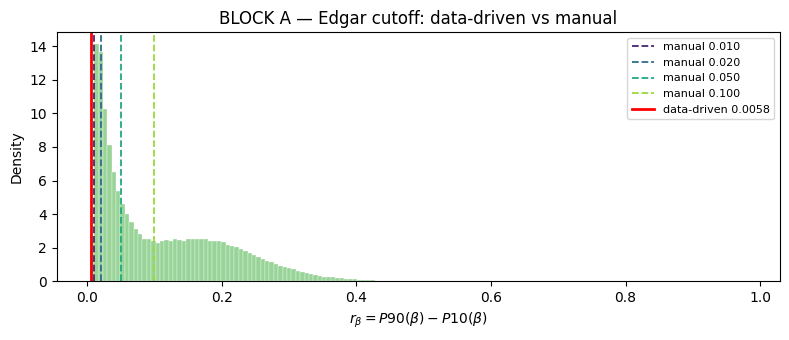


>>> Valore suggerito da usare in R_BETA_CUTOFF: 0.005832416471093893
>>> Confrontalo con il tuo 0.05 e scegli tu.


In [5]:
# ============================================================
# DIAGNOSTIC BLOCKS — da runnare PRIMA delle celle originali
# per vedere i valori data-driven PRIMA di decidere
# ============================================================
# Struttura:
#   BLOCK A — Edgar r_beta cutoff (da runnare dopo STEP 1, prima del filtro Edgar)
#   BLOCK B — Variance filter cutoff (da runnare dopo beta->M, prima del var filter)
#   BLOCK C — |ΔM| cutoff (da runnare dopo STEP 3 score, prima del filtro candidati)
#   BLOCK D — SCORE biologico (sostituzione completa della parte score in STEP 3)
# ============================================================


# ╔══════════════════════════════════════════════════════════╗
# ║  BLOCK A — Edgar r_beta cutoff automatico               ║
# ║  DOVE: metti questa cella DOPO la cella STEP 0-1        ║
# ║  (dopo che r_beta è stato calcolato, prima del filtro)  ║
# ╚══════════════════════════════════════════════════════════╝

def diagnose_edgar_cutoff(r_beta, candidate_cutoffs=[0.01, 0.02, 0.05, 0.10]):
    """
    Mostra il cutoff data-driven (gomito) e quante CpG vengono rimosse
    per ogni cutoff candidato. Decidi tu quale usare.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    try:
        from kneed import KneeLocator
        r_sorted = np.sort(r_beta)
        x = np.arange(len(r_sorted))
        kl = KneeLocator(x, r_sorted, curve="concave", direction="increasing")
        knee_val = float(r_sorted[kl.knee]) if kl.knee is not None else None
    except ImportError:
        print("kneed non disponibile — installa con: !pip install kneed -q")
        knee_val = None

    print("=" * 60)
    print("BLOCK A — Edgar r_beta cutoff diagnostics")
    print("=" * 60)
    print(f"r_beta: min={r_beta.min():.4f}  max={r_beta.max():.4f}"
          f"  median={np.median(r_beta):.4f}")
    print()

    if knee_val is not None:
        n_rem = int((r_beta < knee_val).sum())
        n_keep = int((r_beta >= knee_val).sum())
        print(f"  → Cutoff DATA-DRIVEN (gomito): {knee_val:.4f}")
        print(f"    Rimosse: {n_rem:,}  |  Tenute: {n_keep:,}  ({100*n_keep/len(r_beta):.1f}%)")
    else:
        print("  → Cutoff data-driven: NON calcolato (kneed mancante)")
    print()
    print("  Confronto con cutoff manuali:")
    for c in candidate_cutoffs:
        n_rem = int((r_beta < c).sum())
        n_keep = int((r_beta >= c).sum())
        marker = " ← originale" if c == 0.05 else ""
        print(f"    cutoff={c:.3f}  →  rimosse={n_rem:,}  tenute={n_keep:,}"
              f"  ({100*n_keep/len(r_beta):.1f}%){marker}")
    print()
    print("  DECISIONE: scegli il valore da usare in R_BETA_CUTOFF nella cella STEP 0-1")
    print("=" * 60)

    # plot
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(r_beta, bins=150, density=True, alpha=0.8, color="#7FC97F",
            edgecolor="white", linewidth=0.3)
    colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(candidate_cutoffs)))
    for c, col in zip(candidate_cutoffs, colors):
        ax.axvline(c, linestyle="--", linewidth=1.3, color=col, label=f"manual {c:.3f}")
    if knee_val is not None:
        ax.axvline(knee_val, linestyle="-", linewidth=2.0,
                   color="red", label=f"data-driven {knee_val:.4f}")
    ax.set_xlabel(r"$r_\beta = P90(\beta) - P10(\beta)$")
    ax.set_ylabel("Density")
    ax.set_title("BLOCK A — Edgar cutoff: data-driven vs manual")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    return knee_val

# RUNNA così (dopo STEP 0-1):
!pip install kneed -q
edgar_cutoff_suggested = diagnose_edgar_cutoff(r_beta)
print(f"\n>>> Valore suggerito da usare in R_BETA_CUTOFF: {edgar_cutoff_suggested}")
print(">>> Confrontalo con il tuo 0.05 e scegli tu.")


Edgar(β) variability on TRAIN — Q90−Q10 distribution with 3 cutoffs

Saved plot to: plots_outputs/GSE69914_edgar_variability.pdf


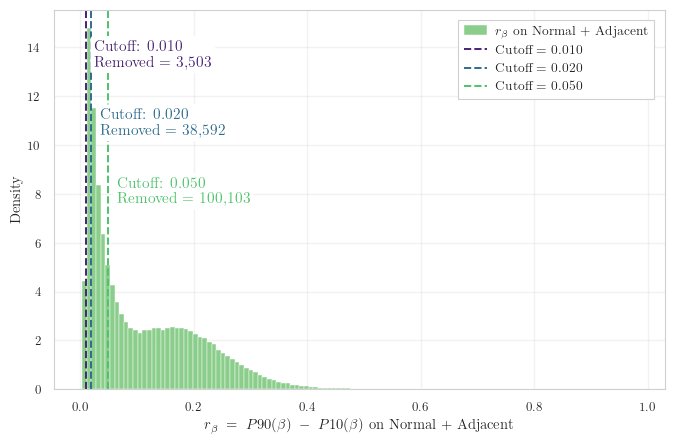

In [6]:
# -----------------------------
# PLOT — Edgar(β) variability (train-only) — white background only (no border)
# -----------------------------

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\nEdgar(β) variability on TRAIN — Q90−Q10 distribution with 3 cutoffs\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

r_beta = np.asarray(r_beta, dtype=float)

cutoffs = [0.010, 0.020, 0.050]

HIST_COLOR = "#7FC97F"

LINE_COLORS = {
    0.010: plt.cm.viridis(0.10),
    0.020: plt.cm.viridis(0.35),
    0.050: plt.cm.viridis(0.72),
}

HIST_LABEL = r"$r_\beta$ on Normal + Adjacent"
XLABEL = r"$r_\beta \;=\; P90(\beta)\;-\;P10(\beta)$ on Normal + Adjacent"

fig, ax = plt.subplots()

ax.hist(
    r_beta,
    bins=120,
    density=True,
    alpha=0.90,
    color=HIST_COLOR,
    edgecolor="white",
    linewidth=0.35,
    label=HIST_LABEL,
    zorder=1,
)

ymax = ax.get_ylim()[1]
X_SHIFT = 0.015

for i, c in enumerate(cutoffs):
    col = LINE_COLORS[c]

    ax.axvline(
        c,
        linestyle="--",
        linewidth=1.4,
        color=col,
        label=rf"Cutoff = {c:0.3f}",
        zorder=2,
    )

    removed = int((r_beta < c).sum())

    ax.text(
        c + X_SHIFT,
        ymax * (0.92 - 0.18 * i),
        f"Cutoff: {c:0.3f}\nRemoved = {removed:,}",
        color=col,
        fontsize=11.0,
        fontweight="semibold",
        ha="left",
        va="top",
        zorder=5,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            linewidth=0,
            alpha=1.0,
        ),
    )

ax.set_xlabel(XLABEL)
ax.set_ylabel("Density")

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF) — after fig exists
# -----------------------------
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

pdf_path = OUTDIR / "GSE69914_edgar_variability.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()



STEP 2 — β→M + variance filter (drop lowest 2% SD) train-only
After M-transform: M_train=(73, 151380) | M_test=(19, 151380)
BLOCK B — Variance filter cutoff diagnostics
SD(M): min=0.1300  max=10.2463  median=0.6700

  → Nessuna valle trovata — distribuzione unimodale
    Suggerimento: usa drop_frac=0.02 (originale)

  Confronto con frazioni manuali:
    drop_frac=1.00%  SD_thr=0.3068  rimosse=1,514  tenute=149,866
    drop_frac=2.00%  SD_thr=0.3412  rimosse=3,028  tenute=148,352 ← originale
    drop_frac=5.00%  SD_thr=0.3963  rimosse=7,569  tenute=143,811
    drop_frac=10.00%  SD_thr=0.4508  rimosse=15,138  tenute=136,242

  DECISIONE: scegli il valore da usare in VAR_DROP_FRAC nella cella STEP 2


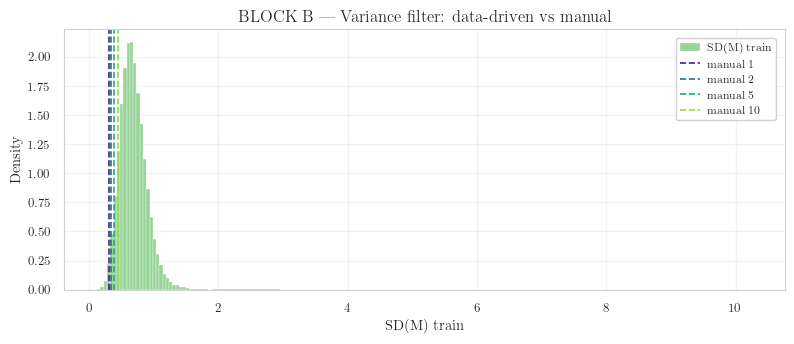


>>> Valore suggerito per VAR_DROP_FRAC: None
>>> Confrontalo con il tuo 0.02 e scegli tu.


In [7]:
# -----------------------------
# STEP 2 — M-transform + variance filter (train-only)
#   - beta -> M (post-Edgar)
#   - drop lowest-variance 2% in TRAIN only (optional/off if Edgar is aggressive)
# -----------------------------

# CONFIG (add/override)
EPS_M = 1e-6
VAR_DROP_FRAC = 0.02          # drop lowest 2% by variance/SD
APPLY_VAR_FILTER = True       # set False if Edgar already aggressive

def beta_to_m(beta_arr: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    b = np.clip(beta_arr, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def soft_sd_filter(X, cols, drop_frac):
    sd = X.std(axis=0, ddof=1)
    thr = np.quantile(sd, drop_frac)
    keep = sd >= thr
    return X[:, keep], cols[keep], sd[keep], keep

print("\n" + "=" * 90)
print("STEP 2 — β→M + variance filter (drop lowest 2% SD) train-only")
print("=" * 90)

# (assumes from STEP 1 you have: B_train, B_test, beta_tr, beta_te, cpg_cols_edgar)
cols_full = np.array(cpg_cols_edgar, dtype=object)

# β → M
M_train = beta_to_m(B_train, eps=EPS_M).astype(np.float32)
M_test  = beta_to_m(B_test,  eps=EPS_M).astype(np.float32)
print(f"After M-transform: M_train={M_train.shape} | M_test={M_test.shape}")

# ╔══════════════════════════════════════════════════════════╗
# ║  BLOCK B — Variance filter cutoff automatico            ║
# ║  DOVE: metti questa cella DOPO beta->M (inizio STEP 2)  ║
# ║  ma PRIMA del filtro soft_sd_filter                     ║
# ╚══════════════════════════════════════════════════════════╝

def diagnose_var_cutoff(M_train, candidate_fracs=[0.01, 0.02, 0.05, 0.10]):
    """
    Mostra il cutoff variance data-driven (prima valle della distribuzione SD)
    e quante CpG vengono rimosse per ogni frazione candidata.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.signal import find_peaks

    sd = M_train.std(axis=0, ddof=1)

    # cerca prima valle
    hist_vals, bin_edges = np.histogram(sd, bins=300)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    valleys, props = find_peaks(-hist_vals, prominence=hist_vals.max() * 0.05)

    if len(valleys) > 0:
        valley_sd = float(bin_centers[valleys[0]])
        frac_at_valley = float((sd < valley_sd).mean())
    else:
        valley_sd = None
        frac_at_valley = None

    print("=" * 60)
    print("BLOCK B — Variance filter cutoff diagnostics")
    print("=" * 60)
    print(f"SD(M): min={sd.min():.4f}  max={sd.max():.4f}  median={np.median(sd):.4f}")
    print()

    if valley_sd is not None:
        n_rem = int((sd < valley_sd).sum())
        n_keep = int((sd >= valley_sd).sum())
        print(f"  → Cutoff DATA-DRIVEN (prima valle): SD={valley_sd:.4f}")
        print(f"    Equivale a drop_frac={frac_at_valley:.3%}")
        print(f"    Rimosse: {n_rem:,}  |  Tenute: {n_keep:,}  ({100*n_keep/sd.size:.1f}%)")
    else:
        print("  → Nessuna valle trovata — distribuzione unimodale")
        print("    Suggerimento: usa drop_frac=0.02 (originale)")
    print()
    print("  Confronto con frazioni manuali:")
    for f in candidate_fracs:
        thr = float(np.quantile(sd, f))
        n_rem = int((sd < thr).sum())
        n_keep = sd.size - n_rem
        marker = " ← originale" if f == 0.02 else ""
        print(f"    drop_frac={f:.2%}  SD_thr={thr:.4f}  "
              f"rimosse={n_rem:,}  tenute={n_keep:,}{marker}")
    print()
    print("  DECISIONE: scegli il valore da usare in VAR_DROP_FRAC nella cella STEP 2")
    print("=" * 60)

    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(sd, bins=200, density=True, alpha=0.8, color="#7FC97F",
            edgecolor="white", linewidth=0.3, label="SD(M) train")
    if valley_sd is not None:
        ax.axvline(valley_sd, linestyle="-", linewidth=2.0,
                   color="red", label=f"data-driven (valle) {valley_sd:.4f}")
    colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(candidate_fracs)))
    for f, col in zip(candidate_fracs, colors):
        thr = float(np.quantile(sd, f))
        ax.axvline(thr, linestyle="--", linewidth=1.2, color=col,
                   label=f"manual {f:.0%} → {thr:.4f}")
    ax.set_xlabel("SD(M) train")
    ax.set_ylabel("Density")
    ax.set_title("BLOCK B — Variance filter: data-driven vs manual")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    return frac_at_valley

# RUNNA così (dopo beta->M, prima del filtro):
var_frac_suggested = diagnose_var_cutoff(M_train)
print(f"\n>>> Valore suggerito per VAR_DROP_FRAC: {var_frac_suggested}")
print(">>> Confrontalo con il tuo 0.02 e scegli tu.")


In [7]:
# -----------------------------
# STEP 2 — M-transform + variance filter (train-only)
#   - beta -> M (post-Edgar)
#   - drop lowest-variance 2% in TRAIN only (optional/off if Edgar is aggressive)
# -----------------------------

# CONFIG (add/override)
EPS_M = 1e-6
VAR_DROP_FRAC = 0.02          # drop lowest 2% by variance/SD
APPLY_VAR_FILTER = True       # set False if Edgar already aggressive

def beta_to_m(beta_arr: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    b = np.clip(beta_arr, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def soft_sd_filter(X, cols, drop_frac):
    sd = X.std(axis=0, ddof=1)
    thr = np.quantile(sd, drop_frac)
    keep = sd >= thr
    return X[:, keep], cols[keep], sd[keep], keep

print("\n" + "=" * 90)
print("STEP 2 — β→M + variance filter (drop lowest 2% SD) train-only")
print("=" * 90)

# (assumes from STEP 1 you have: B_train, B_test, beta_tr, beta_te, cpg_cols_edgar)
cols_full = np.array(cpg_cols_edgar, dtype=object)

# β → M
M_train = beta_to_m(B_train, eps=EPS_M).astype(np.float32)
M_test  = beta_to_m(B_test,  eps=EPS_M).astype(np.float32)
print(f"After M-transform: M_train={M_train.shape} | M_test={M_test.shape}")

# Variance/SD filter (train-only), optional
if APPLY_VAR_FILTER and (VAR_DROP_FRAC > 0):
    M_train_f, cols_f, sd_f, keep_mask = soft_sd_filter(M_train, cols_full, drop_frac=VAR_DROP_FRAC)
    M_test_f = M_test[:, keep_mask]

    print(f"Variance filter: drop_frac={VAR_DROP_FRAC:.2%}")
    print(f"CpGs before: {M_train.shape[1]:,} | after: {M_train_f.shape[1]:,}  (dropped {M_train.shape[1]-M_train_f.shape[1]:,})")

    # overwrite "current" matrices/cols for next steps
    M_train, M_test, cols_full = M_train_f, M_test_f, cols_f
else:
    print("Variance filter OFF (no CpGs removed).")

# keep aligned beta matrices too (needed later for |Δβ| gates)
# B_train/B_test remain post-Edgar; apply same keep_mask if variance filter ON
if APPLY_VAR_FILTER and (VAR_DROP_FRAC > 0):
    B_train = B_train[:, keep_mask]
    B_test  = B_test[:, keep_mask]
    cpg_cols_current = cols_full.copy()
else:
    cpg_cols_current = cols_full.copy()

print(f"Current aligned: B_train={B_train.shape} | M_train={M_train.shape} | CpGs={len(cpg_cols_current):,}")



STEP 2 — β→M + variance filter (drop lowest 2% SD) train-only
After M-transform: M_train=(73, 151380) | M_test=(19, 151380)
Variance filter: drop_frac=2.00%
CpGs before: 151,380 | after: 148,352  (dropped 3,028)
Current aligned: B_train=(73, 148352) | M_train=(73, 148352) | CpGs=148,352



STEP 2 — SD(M) distribution on TRAIN with variance cutoff (train-only): 2%

Saved plot to: plots_outputs/GSE69914_sdM_variance_filter.pdf


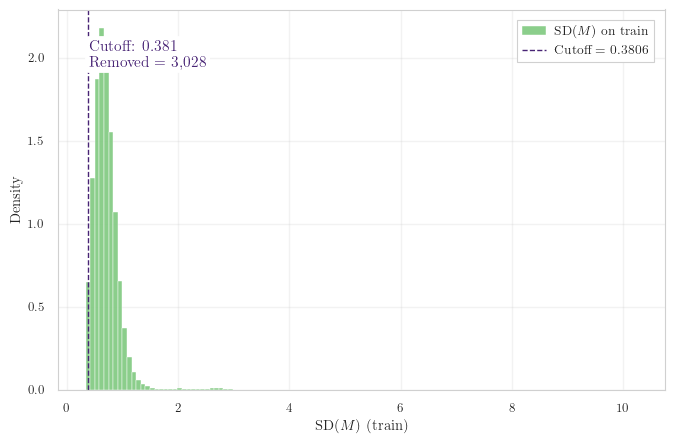

Kept = 145,324 / 148,352 CpGs (Removed = 3,028)


In [8]:
# =============================
# STEP 2 — PLOT: SD(M) distribution + 2% cutoff (train-only)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\nSTEP 2 — SD(M) distribution on TRAIN with variance cutoff (train-only): 2%\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

# Recompute pre-filter SD (identical to STEP 2 input)
M_train_pre = beta_to_m(B_train, eps=EPS_M).astype(np.float32)

sd_pre = M_train_pre.std(axis=0, ddof=1)
thr = float(np.quantile(sd_pre, VAR_DROP_FRAC))

total = int(sd_pre.size)
removed = int((~keep_mask).sum())
kept = total - removed

fig, ax = plt.subplots()

# Histogram (same green as Edgar)
HIST_COLOR = "#7FC97F"
ax.hist(
    sd_pre,
    bins=120,
    density=True,
    alpha=0.90,
    color=HIST_COLOR,
    edgecolor="white",
    linewidth=0.35,
    label=r"$\mathrm{SD}(M)$ on train",
    zorder=1,
)

# Cutoff line
cut_color = plt.cm.viridis(0.10)
ax.axvline(
    thr,
    linestyle="--",
    linewidth=1.0,
    color=cut_color,
    label=rf"Cutoff = {thr:.4f}",
    zorder=2,
)

ax.set_xlabel(r"$\mathrm{SD}(M)$ (train)")
ax.set_ylabel("Density")

# Annotation
X_SHIFT = 0.02
ymax = ax.get_ylim()[1]

ax.text(
    thr + X_SHIFT,
    ymax * 0.92,
    f"Cutoff: {thr:.3f}\nRemoved = {removed:,}",
    color=cut_color,
    fontsize=11,
    fontweight="semibold",
    ha="left",
    va="top",
    zorder=5,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="none",
        linewidth=0,
        alpha=1.0,
    ),
)

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF)
# -----------------------------
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

pdf_path = OUTDIR / "GSE69914_sdM_variance_filter.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

print(f"Kept = {kept:,} / {total:,} CpGs (Removed = {removed:,})")


In [9]:
# ============================================================
# STEP 2.5 — Bio-weight (DA METTERE TRA STEP2 e STEP3)
# ============================================================

import pandas as pd
import numpy as np

MANIFEST_PATH_BIO = "/kaggle/input/datasets/rovieramariella/humanmethylation450-15017482-v1-2-manifest/humanmethylation450_15017482_v1-2_manifest.csv"

def load_manifest_bio(path: str) -> pd.DataFrame:
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if "IlmnID" in line.split(","):
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Header manifest non trovato (colonna IlmnID).")

    df = pd.read_csv(
        path,
        header=header_idx,
        engine="python",
        on_bad_lines="skip",
        usecols=["IlmnID", "Relation_to_UCSC_CpG_Island", "UCSC_RefGene_Group"],
    )
    df.columns = [c.strip() for c in df.columns]
    df["IlmnID"] = df["IlmnID"].astype(str).str.strip()
    return df

man_bio = load_manifest_bio(MANIFEST_PATH_BIO)

island_cpgs = set(man_bio.loc[man_bio["Relation_to_UCSC_CpG_Island"] == "Island", "IlmnID"])
promoter_cpgs = set(
    man_bio.loc[
        man_bio["UCSC_RefGene_Group"].fillna("").astype(str).str.contains("TSS", na=False),
        "IlmnID"
    ]
)

cols_bio = np.array(cpg_cols_current, dtype=object)

bio_weight = np.array([
    1.00 if (c in island_cpgs and c in promoter_cpgs) else
    0.70 if (c in island_cpgs) else
    0.50 if (c in promoter_cpgs) else
    0.20
    for c in cols_bio
], dtype=np.float32)

# normalizza in [0,1]
bio_weight_norm = (bio_weight - bio_weight.min()) / (bio_weight.max() - bio_weight.min())

# diagnostica
n_top    = int((bio_weight == 1.00).sum())
n_island = int((bio_weight == 0.70).sum())
n_prom   = int((bio_weight == 0.50).sum())
n_other  = int((bio_weight == 0.20).sum())

print(f"[BIO] CpG in isola CpG    : {len(island_cpgs):,}")
print(f"[BIO] CpG in promotore TSS: {len(promoter_cpgs):,}")
print(f"[BIO] Entrambi            : {len(island_cpgs & promoter_cpgs):,}")
print(f"\n[BIO] Distribuzione peso biologico su {len(cols_bio):,} CpG (post STEP2):")
print(f"  isola+TSS (1.00): {n_top:,}   ({100*n_top/len(cols_bio):.1f}%)")
print(f"  isola     (0.70): {n_island:,}   ({100*n_island/len(cols_bio):.1f}%)")
print(f"  promotore (0.50): {n_prom:,}   ({100*n_prom/len(cols_bio):.1f}%)")
print(f"  altro     (0.20): {n_other:,}   ({100*n_other/len(cols_bio):.1f}%)")


[BIO] CpG in isola CpG    : 150,254
[BIO] CpG in promotore TSS: 140,003
[BIO] Entrambi            : 63,426

[BIO] Distribuzione peso biologico su 148,352 CpG (post STEP2):
  isola+TSS (1.00): 7,884   (5.3%)
  isola     (0.70): 22,877   (15.4%)
  promotore (0.50): 26,840   (18.1%)
  altro     (0.20): 90,751   (61.2%)


In [10]:
# -----------------------------
# STEP 3 — Repeated Stratified K-Fold stability ranking (train-only, DIRECTIVE-COMPLIANT)
#   K=5, R=10
#   per split:
#     - compute MWU p-values on TRAIN-FOLD only
#     - compute |ΔM| and sign on TRAIN-FOLD only (for ranking)
#     - compute sign on VAL-FOLD (for stability check)
#   aggregate across splits:
#     score = 0.5*mean(rank_p_train) + 0.5*mean(rank_|ΔM|_train)
#     stability_sign = fraction of splits where sign_train == sign_val (and non-zero)
#     stability_sign >= 0.75
#     |ΔM| >= 0.15 (fallback 0.10 if too few candidates)
#   output: top 15k CpGs (candidates)
# -----------------------------

from sklearn.model_selection import RepeatedStratifiedKFold
from scipy.stats import mannwhitneyu

print("\n" + "=" * 90)
print("STEP 3 — RSKF stability ranking (K=5, R=10): score=0.5*rank_p + 0.5*rank_|ΔM|")
print("=" * 90)

# CONFIG
K_FOLDS = 5
R_REPEATS = 10
STABILITY_SIGN_MIN = 0.75
DELTA_M_THR_MAIN = 0.15
DELTA_M_THR_FALLBACK = 0.10
TOP_CANDIDATES = 15000
MIN_CANDIDATES_TARGET = 15000  # "collassa" if well below this

# Assumes available from STEP 2 (post-Edgar + optional var filter):
#   M_train (n_train, p), y_train (n_train,), cpg_cols_current (p,)
X = M_train
y = y_train
cols = np.array(cpg_cols_current, dtype=object)

n, p = X.shape
rkf = RepeatedStratifiedKFold(n_splits=K_FOLDS, n_repeats=R_REPEATS, random_state=RANDOM_STATE)
n_splits_total = K_FOLDS * R_REPEATS
print(f"Train: n={n} | p={p:,} | splits={n_splits_total} (K={K_FOLDS}, R={R_REPEATS})")

# accumulators for score
rank_p_sum = np.zeros(p, dtype=np.float64)
rank_dm_sum = np.zeros(p, dtype=np.float64)

# accumulators for sign stability (train vs val)
sign_agree_count = np.zeros(p, dtype=np.int32)   # count splits where sign_train == sign_val and both non-zero
sign_valid_count = np.zeros(p, dtype=np.int32)   # count splits where both classes present in train+val and signs non-zero

valid_splits_for_score = 0

def _ranks_ascending(values: np.ndarray) -> np.ndarray:
    """Return 1..p ranks, where smaller values -> smaller rank (best=1)."""
    order = np.argsort(values, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.int32)
    ranks[order] = np.arange(1, values.size + 1, dtype=np.int32)
    return ranks

def _ranks_descending(values: np.ndarray) -> np.ndarray:
    """Return 1..p ranks, where larger values -> smaller rank (best=1)."""
    order = np.argsort(-values, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.int32)
    ranks[order] = np.arange(1, values.size + 1, dtype=np.int32)
    return ranks

for split_id, (train_idx, val_idx) in enumerate(rkf.split(X, y), start=1):
    X_tr = X[train_idx]
    y_tr = y[train_idx]
    X_va = X[val_idx]
    y_va = y[val_idx]

    # ensure both classes present in both folds (should hold with stratification, but keep safe)
    tr0 = (y_tr == 0); tr1 = (y_tr == 1)
    va0 = (y_va == 0); va1 = (y_va == 1)
    if tr0.sum() == 0 or tr1.sum() == 0 or va0.sum() == 0 or va1.sum() == 0:
        continue

    X0_tr = X_tr[tr0]; X1_tr = X_tr[tr1]
    X0_va = X_va[va0]; X1_va = X_va[va1]

    # TRAIN-FOLD ΔM (signed + abs) used for ranking
    dM_tr = X1_tr.mean(axis=0) - X0_tr.mean(axis=0)
    abs_dM_tr = np.abs(dM_tr)

    # VAL-FOLD ΔM only for sign stability
    dM_va = X1_va.mean(axis=0) - X0_va.mean(axis=0)

    sign_tr = np.sign(dM_tr).astype(np.int8)  # -1,0,+1
    sign_va = np.sign(dM_va).astype(np.int8)

    # sign stability: count agreement where both non-zero
    nonzero = (sign_tr != 0) & (sign_va != 0)
    sign_valid_count += nonzero.astype(np.int32)
    sign_agree_count += (nonzero & (sign_tr == sign_va)).astype(np.int32)

    # MWU p-values on TRAIN-FOLD only
    # --- PREFILTER by |ΔM| to avoid MWU on all CpGs ---
    PREFILTER_TOP_DM = 50000   # you can tune (30k–70k reasonable)
    PRINT_EVERY = 1            # progress frequency
    
    # 1) prefilter indices by |ΔM| (train-fold)
    if PREFILTER_TOP_DM is not None and PREFILTER_TOP_DM < p:
        idx_pf = np.argpartition(-abs_dM_tr, PREFILTER_TOP_DM - 1)[:PREFILTER_TOP_DM]
    else:
        idx_pf = np.arange(p)
    
    # 2) MWU only on prefiltered CpGs
    pvals = np.ones(p, dtype=np.float64)  # default worst p-value
    for j in idx_pf:
        pvals[j] = mannwhitneyu(
            X0_tr[:, j], X1_tr[:, j],
            alternative="two-sided",
            method="asymptotic"
        ).pvalue


    # ranks per split (TRAIN-FOLD only)
    r_p = _ranks_ascending(pvals)       # best small p -> rank 1
    r_dm = _ranks_descending(abs_dM_tr) # best large |ΔM| -> rank 1

    rank_p_sum += r_p
    rank_dm_sum += r_dm
    valid_splits_for_score += 1

    if split_id % PRINT_EVERY == 0 or split_id == n_splits_total:
        print(f"  done split {split_id:>3}/{n_splits_total} | pf={idx_pf.size:,} | valid_for_score={valid_splits_for_score}")

if valid_splits_for_score == 0:
    raise RuntimeError("No valid splits computed in RSKF step (check labels / stratification).")

# aggregate score
#mean_rank_p = rank_p_sum / valid_splits_for_score
#mean_rank_dm = rank_dm_sum / valid_splits_for_score
#score = 0.5 * mean_rank_p + 0.5 * mean_rank_dm

mean_rank_p  = rank_p_sum  / valid_splits_for_score
mean_rank_dm = rank_dm_sum / valid_splits_for_score

# score statistico "come prima" (più basso = meglio)
score_stat = 0.5 * mean_rank_p + 0.5 * mean_rank_dm  # ~[1,p]

# componente biologica (più basso = meglio -> preferisco bio_weight alto)
# bio_weight_norm è già in [0,1]; penalizzo i CpG "non bio"
score_bio = 1.0 - bio_weight_norm  # [0,1]

# mix finale (consistente, senza doppie somme inutili)
W_BIO = 0.20
score = (1.0 - W_BIO) * score_stat + W_BIO * score_bio

print(f"\n[BIO] Integrated score with W_BIO={W_BIO}:")
print(f"  score_stat range: [{score_stat.min():.4f}, {score_stat.max():.4f}]")
print(f"  score      range: [{score.min():.4f}, {score.max():.4f}]")

# stability_sign = fraction of splits where sign_train == sign_val (only where both non-zero)
stability_sign = np.zeros(p, dtype=np.float64)
nz = sign_valid_count > 0
stability_sign[nz] = sign_agree_count[nz] / sign_valid_count[nz]
# if never valid (rare), keep 0 stability (will be filtered out)

# global ΔM estimate on full TRAIN (used for thresholding)
dM_full = X[y == 1].mean(axis=0) - X[y == 0].mean(axis=0)
abs_dM_full = np.abs(dM_full)

# candidate filter with fallback
thr = DELTA_M_THR_MAIN
mask_cand = (stability_sign >= STABILITY_SIGN_MIN) & (abs_dM_full >= thr)
n_cand = int(mask_cand.sum())
print(f"Candidates with |ΔM|>={thr:.2f} and stability_sign>={STABILITY_SIGN_MIN:.2f}: {n_cand:,}")

if n_cand < MIN_CANDIDATES_TARGET:
    thr = DELTA_M_THR_FALLBACK
    mask_cand = (stability_sign >= STABILITY_SIGN_MIN) & (abs_dM_full >= thr)
    n_cand = int(mask_cand.sum())
    print(f"Fallback |ΔM|>={thr:.2f}: candidates={n_cand:,}")

if n_cand == 0:
    raise RuntimeError("Step 3 produced 0 candidates even after fallback. Lower thresholds or inspect data.")

# pick top 15k by score (lower is better)
cand_idx = np.where(mask_cand)[0]
order = np.argsort(score[cand_idx], kind="mergesort")
cand_idx_sorted = cand_idx[order]
cand_idx_top = cand_idx_sorted[:min(TOP_CANDIDATES, cand_idx_sorted.size)]

cpg_candidates = cols[cand_idx_top]

# keep useful stats for later steps (region anchoring / reporting)
step3_stats = {
    "score": score[cand_idx_top],
    "score_stat": score_stat[cand_idx_top],
    "mean_rank_p": mean_rank_p[cand_idx_top],
    "mean_rank_abs_dM": mean_rank_dm[cand_idx_top],
    "stability_sign": stability_sign[cand_idx_top],
    "deltaM_full": dM_full[cand_idx_top],
    "abs_deltaM_full": abs_dM_full[cand_idx_top],
    "used_deltaM_thr": thr,
    "valid_splits_for_score": valid_splits_for_score,
    "sign_valid_splits": sign_valid_count[cand_idx_top],
}

print(f"Selected top candidates: {len(cpg_candidates):,} (target {TOP_CANDIDATES:,})")
print("Example:", cpg_candidates[:5].tolist())



STEP 3 — RSKF stability ranking (K=5, R=10): score=0.5*rank_p + 0.5*rank_|ΔM|
Train: n=73 | p=148,352 | splits=50 (K=5, R=10)
  done split   1/50 | pf=50,000 | valid_for_score=1
  done split   2/50 | pf=50,000 | valid_for_score=2
  done split   3/50 | pf=50,000 | valid_for_score=3
  done split   4/50 | pf=50,000 | valid_for_score=4
  done split   5/50 | pf=50,000 | valid_for_score=5
  done split   6/50 | pf=50,000 | valid_for_score=6
  done split   7/50 | pf=50,000 | valid_for_score=7
  done split   8/50 | pf=50,000 | valid_for_score=8
  done split   9/50 | pf=50,000 | valid_for_score=9
  done split  10/50 | pf=50,000 | valid_for_score=10
  done split  11/50 | pf=50,000 | valid_for_score=11
  done split  12/50 | pf=50,000 | valid_for_score=12
  done split  13/50 | pf=50,000 | valid_for_score=13
  done split  14/50 | pf=50,000 | valid_for_score=14
  done split  15/50 | pf=50,000 | valid_for_score=15
  done split  16/50 | pf=50,000 | valid_for_score=16
  done split  17/50 | pf=50,000 | 


STEP 3 — stability_sign distribution (train↔val agreement)

Saved plot to: plots_outputs/GSE69914_stability_sign_distribution.pdf


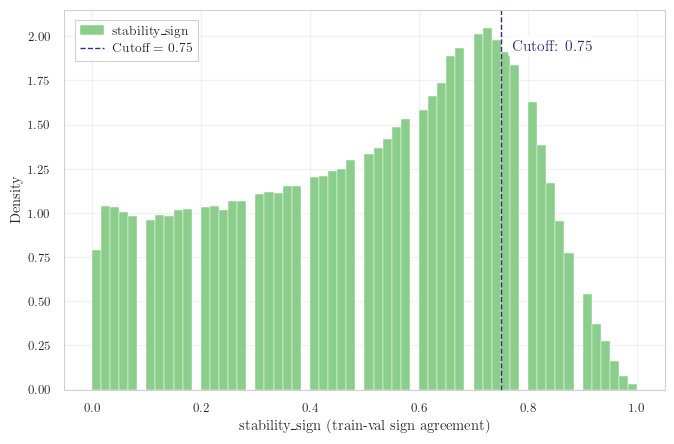

In [11]:
# =============================
# STEP 3 — PLOT: stability_sign distribution (train↔val agreement)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATASET_NAME = "GSE69914"   # <-- modifica se necessario

print("\nSTEP 3 — stability_sign distribution (train↔val agreement)\n")

apply_thesis_style(use_tex=True, legend_position="upper left", legend_outside=False)

fig, ax = plt.subplots()

HIST_COLOR = "#7FC97F"
CUT_COLOR = plt.cm.viridis(0.10)

ax.hist(
    stability_sign,
    bins=60,
    density=True,
    alpha=0.90,
    color=HIST_COLOR,
    edgecolor="white",
    linewidth=0.35,
    label="stability_sign",
    zorder=1,
)

ax.axvline(
    STABILITY_SIGN_MIN,
    linestyle="--",
    linewidth=1.0,
    color=CUT_COLOR,
    label=rf"Cutoff = {STABILITY_SIGN_MIN:.2f}",
    zorder=2,
)

ax.set_xlabel("stability_sign (train-val sign agreement)")
ax.set_ylabel("Density")

# annotation (white background only, no border)
ymax = ax.get_ylim()[1]
ax.text(
    STABILITY_SIGN_MIN + 0.02,
    ymax * 0.92,
    f"Cutoff: {STABILITY_SIGN_MIN:.2f}",
    color=CUT_COLOR,
    fontsize=11,
    fontweight="semibold",
    ha="left",
    va="top",
    zorder=5,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="none",
        linewidth=0,
        alpha=1.0,
    ),
)

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF)
# -----------------------------
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

pdf_path = OUTDIR / f"{DATASET_NAME}_stability_sign_distribution.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")

print(f"Saved plot to: {pdf_path}")

plt.show()



STEP 3 — RSKF score vs |ΔM| on TRAIN (candidates highlighted)

Saved plot to: plots_outputs/GSE69914_absDeltaM_vs_score.pdf


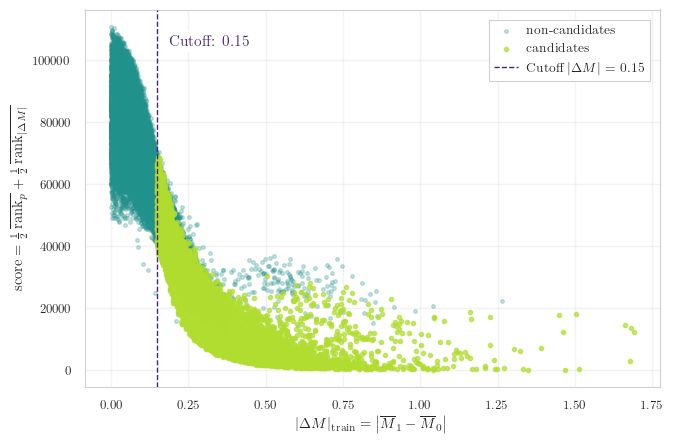

In [12]:
# =============================
# STEP 3 — PLOT: RSKF score vs |ΔM| (viridis coherent palette)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\nSTEP 3 — RSKF score vs |ΔM| on TRAIN (candidates highlighted)\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

score = np.asarray(score, dtype=float)
abs_dM_full = np.asarray(abs_dM_full, dtype=float)
mask_cand = np.asarray(mask_cand, dtype=bool)

idx_cand = np.where(mask_cand)[0]
idx_non = np.where(~mask_cand)[0]

MAX_NON = 25000
if idx_non.size > MAX_NON:
    rng = np.random.default_rng(RANDOM_STATE)
    idx_non = rng.choice(idx_non, size=MAX_NON, replace=False)

# --- VIRIDIS PALETTE ---
c_non   = plt.cm.viridis(0.50)  # verde medio/scuro (tolte)
c_cand  = plt.cm.viridis(0.88)  # giallo-verde chiaro (tenute)
c_line  = plt.cm.viridis(0.10)  # verde scuro (cutoff)

fig, ax = plt.subplots()

ax.scatter(
    abs_dM_full[idx_non],
    score[idx_non],
    s=7,
    alpha=0.25,
    color=c_non,
    label="non-candidates",
    zorder=1,
)

ax.scatter(
    abs_dM_full[idx_cand],
    score[idx_cand],
    s=9,
    alpha=0.70,
    color=c_cand,
    label="candidates",
    zorder=2,
)

ax.axvline(
    thr,
    linestyle="--",
    linewidth=1.0,
    color=c_line,
    label=rf"Cutoff $|\Delta M|$ = {thr:.2f}",
    zorder=3,
)

ax.set_xlabel(r"$|\Delta M|_{\mathrm{train}} = \left|\overline{M}_{1} - \overline{M}_{0}\right|$")
ax.set_ylabel(
    r"$\mathrm{score} = \frac{1}{2}\,\overline{\mathrm{rank}_{p}} + \frac{1}{2}\,\overline{\mathrm{rank}_{|\Delta M|}}$"
)

# Annotazione cutoff stile Edgar
ymax = ax.get_ylim()[1]
x_text = thr + 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0])

ax.text(
    x_text,
    ymax * 0.93,
    f"Cutoff: {thr:.2f}",
    color=c_line,
    fontsize=11,
    fontweight="semibold",
    ha="left",
    va="top",
    zorder=5,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="none",
        linewidth=0,
        alpha=1.0,
    ),
)

place_legend(ax)
fig.tight_layout()

OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)
pdf_path = OUTDIR / f"{DATASET_NAME}_absDeltaM_vs_score.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()


In [13]:
# =============================
# STEP 3 — CHECK: Spearman corr(score, |ΔM|) on TRAIN
#   tells you if the score is basically dominated by effect size
# =============================

import numpy as np
from scipy.stats import spearmanr

print("\nSTEP 3 — Spearman correlation between score and |ΔM| (full train)\n")

# Assumes from STEP 3 you have:
#   score        : np.ndarray (len p)
#   abs_dM_full  : np.ndarray (len p)
#   mask_cand    : np.ndarray bool (len p)  [optional]
#   cpg_cols_current : list/array CpG ids (len p) [optional]

score_arr = np.asarray(score, dtype=float)
absdm_arr = np.asarray(abs_dM_full, dtype=float)

# Safety: remove NaNs/Infs if any
ok = np.isfinite(score_arr) & np.isfinite(absdm_arr)
score_ok = score_arr[ok]
absdm_ok = absdm_arr[ok]

# Spearman on all CpGs
rho_all, p_all = spearmanr(score_ok, absdm_ok)

print(f"[ALL CpGs] Spearman rho(score, |ΔM|) = {rho_all:.4f} | p-value = {p_all:.3e} | n = {score_ok.size:,}")

# Optional: Spearman on candidates only (after stability + |ΔM| thresholds)
if "mask_cand" in globals():
    mask = np.asarray(mask_cand, dtype=bool)
    mask = mask & ok
    if mask.sum() > 10:
        rho_c, p_c = spearmanr(score_arr[mask], absdm_arr[mask])
        print(f"[CANDIDATES] Spearman rho(score, |ΔM|) = {rho_c:.4f} | p-value = {p_c:.3e} | n = {int(mask.sum()):,}")
    else:
        print("[CANDIDATES] not enough points to compute reliably.")

# Optional: quick diagnostic interpretation
if np.isfinite(rho_all):
    if abs(rho_all) > 0.90:
        print("Interpretation: |rho|>0.90 ⇒ score is (almost) monotone in |ΔM| → ranking dominated by effect size.")
    elif abs(rho_all) > 0.70:
        print("Interpretation: 0.70<|rho|<=0.90 ⇒ strong link: effect size is a major driver, MWU still contributes.")
    else:
        print("Interpretation: |rho|<=0.70 ⇒ MWU ranks contribute materially beyond effect size.")



STEP 3 — Spearman correlation between score and |ΔM| (full train)

[ALL CpGs] Spearman rho(score, |ΔM|) = -0.8684 | p-value = 0.000e+00 | n = 148,352
[CANDIDATES] Spearman rho(score, |ΔM|) = -0.9199 | p-value = 0.000e+00 | n = 26,014
Interpretation: 0.70<|rho|<=0.90 ⇒ strong link: effect size is a major driver, MWU still contributes.


In [14]:
# -----------------------------
# STEP 3b — Region anchoring su CpG islands (DIRECTIVE-COMPLIANT)
#   region_score = median(score) × fraction_stable
#   fraction_stable >= 0.6, >= 2 CpG per regione
#   top-m (m=2-3) per regione -> Pool A [anchored]
#   resto -> Pool B [non-anchored]
#
# NOTE (aderenza):
# - "fraction_stable" qui è calcolata su CpG che rispettano i vincoli di STEP 3:
#     stability_sign >= 0.75  AND  |ΔM| >= thr_usato_in_step3
#   (thr_usato_in_step3 = 0.15 oppure 0.10 se fallback)
# -----------------------------

import numpy as np
import polars as pl

print("\n" + "=" * 90)
print("STEP 3b — Region anchoring su CpG islands")
print("=" * 90)

# CONFIG
MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/humanmethylation450-15017482-v1-2-manifest/humanmethylation450_15017482_v1-2_manifest.csv"
MANIFEST_CPG_COL = "IlmnID"
MANIFEST_ISLAND_NAME_COL = "UCSC_CpG_Islands_Name"
MANIFEST_REL_COL = "Relation_to_UCSC_CpG_Island"

ANCHOR_CONTEXT = {"Island"}        # anchoring strictly on islands
FRACTION_STABLE_MIN = 0.60
MIN_CPGS_PER_REGION = 2
TOP_M_PER_REGION = 3               # set 2 or 3

# Assumes from STEP 3:
#   cpg_candidates : (n_cand,)
#   step3_stats["score"] : (n_cand,)   lower is better
#   step3_stats["stability_sign"] : (n_cand,)
#   step3_stats["abs_deltaM_full"] : (n_cand,)
#   step3_stats["used_deltaM_thr"] : scalar (0.15 or 0.10)
cand = np.array(cpg_candidates, dtype=object)
cand_score = np.array(step3_stats["score"], dtype=float)
cand_stab  = np.array(step3_stats["stability_sign"], dtype=float)
cand_absdM = np.array(step3_stats["abs_deltaM_full"], dtype=float)
thr_used   = float(step3_stats["used_deltaM_thr"])

if not (cand.shape[0] == cand_score.shape[0] == cand_stab.shape[0] == cand_absdM.shape[0]):
    raise RuntimeError("STEP 3b: candidate arrays are misaligned (cpg_candidates vs step3_stats).")

# Define CpG-level "stable" flag per STEP 3 directive (within the candidate set)
stable_cpg_flag = (cand_stab >= STABILITY_SIGN_MIN) & (cand_absdM >= thr_used)

print(f"Candidates: {cand.size:,}")
print(f"ΔM threshold used in STEP 3: {thr_used:.2f}")
print(f"Stable CpGs inside candidates (stab>=0.75 AND |ΔM|>=thr): {int(stable_cpg_flag.sum()):,}")

# -----------------------------
# A) Build CpG -> island mapping (only Island context and named islands)
# -----------------------------
def load_manifest_with_real_header(path: str) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        start_row = None
        for i, line in enumerate(f):
            if line.startswith("IlmnID"):
                start_row = i
                break
    if start_row is None:
        raise ValueError(f"Non trovo header 'IlmnID' in: {path}")
    return pd.read_csv(path, skiprows=start_row, low_memory=False)

mf = load_manifest_with_real_header(MANIFEST_PATH)

# Keep only required columns
mf = mf[[MANIFEST_CPG_COL, MANIFEST_ISLAND_NAME_COL, MANIFEST_REL_COL]].copy()

mf.columns = ["cpg", "island", "rel"]

mf["cpg"] = mf["cpg"].astype(str)
mf["island"] = mf["island"].fillna("").astype(str).str.strip()
mf["rel"] = mf["rel"].fillna("").astype(str).str.strip()

# Filter strictly Island context + named islands
mf_island = mf[
    (mf["rel"].isin(list(ANCHOR_CONTEXT))) &
    (mf["island"] != "")
]

# CpG -> island dictionary
cpg_to_island = dict(zip(mf_island["cpg"], mf_island["island"]))

# map candidates to islands
island_id = np.array([cpg_to_island.get(c, None) for c in cand], dtype=object)
in_island = island_id != None
print(f"Mapped to named CpG islands (context={ANCHOR_CONTEXT}): {int(in_island.sum()):,}")

# -----------------------------
# B) Group by island, compute region_score and pick top-m CpGs per selected region
# -----------------------------
island_to_idx = {}
for i, rid in enumerate(island_id):
    if rid is None:
        continue
    island_to_idx.setdefault(rid, []).append(i)

region_rows = []
poolA_idx = []

for rid, idxs in island_to_idx.items():
    idxs = np.array(idxs, dtype=int)

    # constraint: >= 2 CpGs per region
    if idxs.size < MIN_CPGS_PER_REGION:
        continue

    # fraction_stable computed on STEP3 "stable" definition
    frac_stable = float(stable_cpg_flag[idxs].mean())
    if frac_stable < FRACTION_STABLE_MIN:
        continue

    # region_score = median(score) * fraction_stable
    med_score = float(np.median(cand_score[idxs]))
    region_score = med_score * frac_stable

    # top-m per region by candidate score (lower better)
    order = np.argsort(cand_score[idxs], kind="mergesort")
    chosen = idxs[order[:min(TOP_M_PER_REGION, idxs.size)]]
    poolA_idx.extend(chosen.tolist())

    region_rows.append((rid, idxs.size, frac_stable, med_score, region_score, chosen.size))

poolA_idx = np.array(sorted(set(poolA_idx)), dtype=int)

# -----------------------------
# C) Final pools
# -----------------------------
poolA_cpgs = cand[poolA_idx]  # anchored

maskA = np.zeros(cand.size, dtype=bool)
maskA[poolA_idx] = True
poolB_cpgs = cand[~maskA]     # non-anchored

print(f"Selected regions (pass constraints): {len(region_rows):,}")
print(f"Pool A (anchored) CpGs: {poolA_cpgs.size:,}  (top-m={TOP_M_PER_REGION} per region)")
print(f"Pool B (non-anchored) CpGs: {poolB_cpgs.size:,}")

region_summary = (
    pl.DataFrame(
        region_rows,
        schema=["island_id", "n_cpgs", "fraction_stable", "median_score", "region_score", "picked_m"]
    ).sort("region_score")
)

print("Top 5 regions by region_score (lower is better):")
print(region_summary.head(5))

# Outputs:
#   poolA_cpgs, poolB_cpgs, region_summary



STEP 3b — Region anchoring su CpG islands
Candidates: 15,000
ΔM threshold used in STEP 3: 0.15
Stable CpGs inside candidates (stab>=0.75 AND |ΔM|>=thr): 15,000
Mapped to named CpG islands (context={'Island'}): 5,059
Selected regions (pass constraints): 1,025
Pool A (anchored) CpGs: 2,475  (top-m=3 per region)
Pool B (non-anchored) CpGs: 12,525
Top 5 regions by region_score (lower is better):
shape: (5, 6)
┌──────────────────────────┬────────┬─────────────────┬──────────────┬──────────────┬──────────┐
│ island_id                ┆ n_cpgs ┆ fraction_stable ┆ median_score ┆ region_score ┆ picked_m │
│ ---                      ┆ ---    ┆ ---             ┆ ---          ┆ ---          ┆ ---      │
│ str                      ┆ i64    ┆ f64             ┆ f64          ┆ f64          ┆ i64      │
╞══════════════════════════╪════════╪═════════════════╪══════════════╪══════════════╪══════════╡
│ chr7:127671158-127672853 ┆ 3      ┆ 1.0             ┆ 362.192      ┆ 362.192      ┆ 3        │
│ chr12:

In [15]:
from pathlib import Path
import polars as pl

# CONFIG
DATASET = "GSE69914"   # cambia: GSE287331 / GSE69914
OUTDIR = Path("./region_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# (opzionale ma consigliato) ordina e forza schema stabile
region_summary_out = (
    region_summary
    .select([
        "island_id",
        "n_cpgs",
        "fraction_stable",
        "median_score",
        "region_score",
        "picked_m",
    ])
    .with_columns([
        pl.col("island_id").cast(pl.Utf8),
        pl.col("n_cpgs").cast(pl.Int64),
        pl.col("picked_m").cast(pl.Int64),
        pl.col("fraction_stable").cast(pl.Float64),
        pl.col("median_score").cast(pl.Float64),
        pl.col("region_score").cast(pl.Float64),
    ])
    .sort(["region_score", "island_id"])
)

csv_path = OUTDIR / f"{DATASET}_region_summary.csv"
parq_path = OUTDIR / f"{DATASET}_region_summary.parquet"

region_summary_out.write_csv(csv_path)
region_summary_out.write_parquet(parq_path)

print(f"Saved CSV:   {csv_path}")
print(f"Saved PARQ:  {parq_path}")
print(f"Rows: {region_summary_out.height:,}")


Saved CSV:   region_outputs/GSE69914_region_summary.csv
Saved PARQ:  region_outputs/GSE69914_region_summary.parquet
Rows: 1,025



STEP 3b — Region anchoring: selected regions = 1,025

Saved plot to: plots_outputs/GSE69914_region_score_distribution.pdf


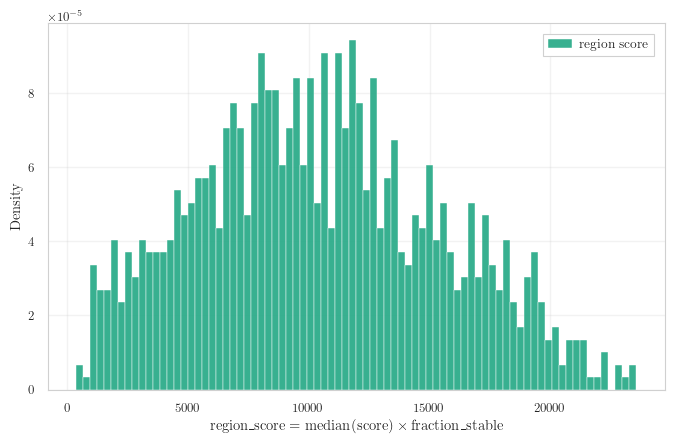

In [16]:
# =============================
# STEP 3b — PLOT: Region_score distribution (selected regions)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


print(f"\nSTEP 3b — Region anchoring: selected regions = {len(region_summary):,}\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

# extract region_score
rs = region_summary.select("region_score").to_numpy().ravel().astype(float)

fig, ax = plt.subplots()

# histogram (viridis mid-green)
hist_color = plt.cm.viridis(0.60)

ax.hist(
    rs,
    bins=80,
    density=True,
    alpha=0.90,
    color=hist_color,
    edgecolor="white",
    linewidth=0.35,
    label=r"$\mathrm{region \; score}$",
)

ax.set_xlabel(r"$\mathrm{region\_score} = \mathrm{median}(\mathrm{score}) \times \mathrm{fraction\_stable}$")
ax.set_ylabel("Density")

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF)
# -----------------------------
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

pdf_path = OUTDIR / f"{DATASET_NAME}_region_score_distribution.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")

print(f"Saved plot to: {pdf_path}")

plt.show()


In [17]:
# -----------------------------
# STEP 4 — Correlation clustering separato (DIRECTIVE-COMPLIANT)
#   Pool A: |r| >= 0.85  -> connected components -> 1 CpG/cluster (best STEP3 score)
#   Pool B: |r| >= 0.85  -> connected components -> 1 CpG/cluster (best STEP3 score)
#   Output: unione dei rappresentanti (A prima di B, unique)
#
# NOTE (aderenza):
# - correlazioni calcolate SOLO su TRAIN (M_train)
# - "miglior score" = minimo STEP3 score (0.5·mean(rank_p)+0.5·mean(rank_|ΔM|))
# - cluster = componenti connesse del grafo soglia |r|>=thr
# -----------------------------

import numpy as np

print("\n" + "=" * 90)
print("STEP 4 — Correlation clustering separato (Pool A, Pool B) |r|>=0.85")
print("=" * 90)

# CONFIG
CORR_CLUSTER_THR = 0.85

# Assumes from previous steps:
#   - M_train : (n_train, p_all)  TRAIN matrix in M-space (post STEP 2)
#   - cpg_cols_current : (p_all,) CpG names aligned to columns of M_train
#   - cpg_candidates : (n_cand,) top candidates from STEP 3
#   - step3_stats["score"] aligned to cpg_candidates (lower is better)
#   - poolA_cpgs, poolB_cpgs from STEP 3b

cols_all = np.array(cpg_cols_current, dtype=object)
col_to_j = {c: j for j, c in enumerate(cols_all)}

cand = np.array(cpg_candidates, dtype=object)
cand_score = np.array(step3_stats["score"], dtype=float)

# Map CpG -> STEP3 score (used to pick representative)
score_map = {c: s for c, s in zip(cand, cand_score)}

def _build_Z(pool_cpgs: np.ndarray):
    """
    Return standardized TRAIN matrix Z for pool CpGs and the ordered CpG list (aligned to Z columns).
    Standardization is per-CpG on TRAIN only.
    """
    pool = np.array([c for c in pool_cpgs if c in col_to_j], dtype=object)
    if pool.size == 0:
        return np.empty((M_train.shape[0], 0), dtype=np.float32), pool

    jj = np.array([col_to_j[c] for c in pool], dtype=int)
    Xp = M_train[:, jj].astype(np.float32, copy=False)

    mu = Xp.mean(axis=0)
    sd = Xp.std(axis=0, ddof=1) + 1e-12
    Z = (Xp - mu) / sd
    return Z, pool

def _connected_components_from_corr(Z: np.ndarray, thr: float):
    """
    Graph on CpGs where edge(i,j)=1 if |corr(i,j)|>=thr.
    Connected components = clusters.
    corr computed on standardized TRAIN data: C = (Z^T Z)/(n-1).
    """
    p = Z.shape[1]
    if p == 0:
        return []
    if p == 1:
        return [[0]]

    n = Z.shape[0]
    C = (Z.T @ Z) / (n - 1)
    A = (np.abs(C) >= thr)
    np.fill_diagonal(A, True)

    visited = np.zeros(p, dtype=bool)
    comps = []
    for i in range(p):
        if visited[i]:
            continue
        stack = [i]
        visited[i] = True
        comp = []
        while stack:
            u = stack.pop()
            comp.append(u)
            nbrs = np.where(A[u])[0]
            for v in nbrs:
                if not visited[v]:
                    visited[v] = True
                    stack.append(v)
        comps.append(comp)
    return comps

def _pick_rep_by_best_score(pool_order: np.ndarray, comps):
    """Pick 1 CpG per component by minimal STEP3 score (lower is better)."""
    reps = []
    for comp in comps:
        members = pool_order[np.array(comp, dtype=int)]
        scores = np.array([score_map.get(c, np.inf) for c in members], dtype=float)
        best = members[int(np.argmin(scores))]
        reps.append(best)
    return np.array(reps, dtype=object)

def cluster_pool(pool_name: str, pool_cpgs: np.ndarray, thr: float):
    Z, pool_order = _build_Z(pool_cpgs)
    print(f"{pool_name}: CpGs in pool={pool_order.size:,}")

    if pool_order.size == 0:
        return np.array([], dtype=object), np.array([], dtype=int)

    comps = _connected_components_from_corr(Z, thr=thr)
    reps = _pick_rep_by_best_score(pool_order, comps)

    sizes = np.array([len(c) for c in comps], dtype=int)
    print(f"{pool_name}: clusters={len(comps):,} | reps={reps.size:,} | "
          f"median_cluster_size={int(np.median(sizes))} | max_cluster_size={int(sizes.max())}")
    return reps, sizes

# Separate clustering as per directive
reps_A, sizes_A = cluster_pool("Pool A (anchored)", poolA_cpgs, thr=CORR_CLUSTER_THR)
reps_B, sizes_B = cluster_pool("Pool B (non-anchored)", poolB_cpgs, thr=CORR_CLUSTER_THR)

# Union of representatives (A first, then B), unique
reps_union = np.array(list(dict.fromkeys(np.concatenate([reps_A, reps_B]).tolist())), dtype=object)

print(f"Union representatives: {reps_union.size:,} (A={reps_A.size:,}, B={reps_B.size:,})")

# Outputs for STEP 5:
#   reps_A, reps_B, reps_union



STEP 4 — Correlation clustering separato (Pool A, Pool B) |r|>=0.85
Pool A (anchored): CpGs in pool=2,475
Pool A (anchored): clusters=1,893 | reps=1,893 | median_cluster_size=1 | max_cluster_size=348
Pool B (non-anchored): CpGs in pool=12,525
Pool B (non-anchored): clusters=10,420 | reps=10,420 | median_cluster_size=1 | max_cluster_size=1203
Union representatives: 12,313 (A=1,893, B=10,420)


[OK] Saved PDF → figures/step4/GSE69914_cluster_size_ccdf_loglog_r0.85.pdf


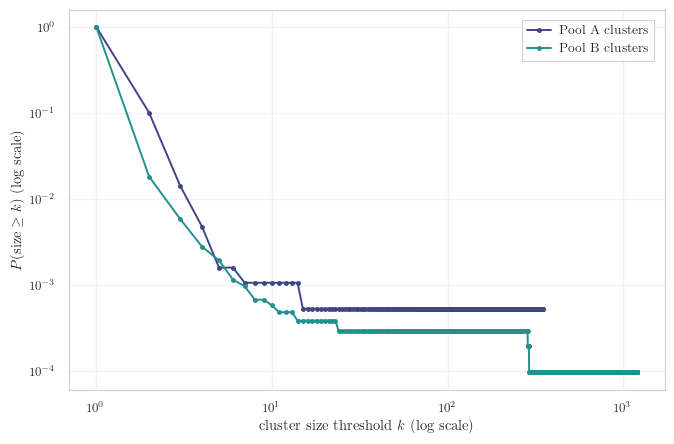

Correlation clustering tail (CCDF), $|r|\geq 0.85$


In [18]:
# =============================
# STEP 4 — PLOT (CCDF log-log, Viridis): Cluster size tail (Pool A vs Pool B)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

def ccdf_from_sizes(sizes: np.ndarray):
    sizes = np.asarray(sizes, dtype=int)
    sizes = sizes[sizes >= 1]
    if sizes.size == 0:
        return np.array([], dtype=int), np.array([], dtype=float)

    max_k = int(sizes.max())
    ks = np.arange(1, max_k + 1, dtype=int)

    hist = np.bincount(sizes, minlength=max_k + 1)
    tail_counts = np.cumsum(hist[::-1])[::-1]
    ccdf = tail_counts[ks] / float(sizes.size)
    return ks, ccdf

kA, ccdfA = ccdf_from_sizes(sizes_A)
kB, ccdfB = ccdf_from_sizes(sizes_B)

if ccdfA.size == 0 and ccdfB.size == 0:
    raise ValueError("Both sizes_A and sizes_B are empty.")

# --- Viridis colors ---
cmap = plt.cm.viridis
color_A = cmap(0.2)
color_B = cmap(0.5)

fig, ax = plt.subplots()

if ccdfA.size:
    ax.plot(kA, ccdfA,
            marker="o", markersize=2.5, linewidth=1.4,
            color=color_A, label="Pool A clusters")

if ccdfB.size:
    ax.plot(kB, ccdfB,
            marker="o", markersize=2.5, linewidth=1.4,
            color=color_B, label="Pool B clusters")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("cluster size threshold $k$ (log scale)")
ax.set_ylabel(r"$P(\mathrm{size}\geq k)$ (log scale)")


place_legend(ax)
fig.tight_layout()

OUT_DIR = Path("figures/step4")
OUT_DIR.mkdir(parents=True, exist_ok=True)
pdf_path = OUT_DIR / f"GSE69914_cluster_size_ccdf_loglog_r{CORR_CLUSTER_THR:.2f}.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(f"[OK] Saved PDF → {pdf_path}")

plt.show()
print(f"Correlation clustering tail (CCDF), $|r|\geq {CORR_CLUSTER_THR:.2f}$")


In [19]:
# -----------------------------
# STEP 5 — Diversificazione soft + greedy (DIRECTIVE-COMPLIANT)
#   Vincoli (soft, target):
#     - chr <= 20% (sul K target, non dinamico su n_next)
#     - contesto <= 65% (sul K target, non dinamico su n_next)
#     - max 15 CpG / 500kb (vincolo spaziale hard finché non si rilassa)
#   Allentamento: spaziale -> contesto -> chr
# -----------------------------

import numpy as np
import polars as pl

print("\n" + "=" * 90)
print("STEP 5 — Diversification greedy with soft constraints + relaxation (spatial→context→chr)")
print("=" * 90)

# CONFIG
K_TARGET = 5000
CHR_MAX_FRAC = 0.08
CTX_MAX_FRAC = 0.65
WIN_BP = 500_000
MAX_PER_WIN = 15

MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/humanmethylation450-15017482-v1-2-manifest/humanmethylation450_15017482_v1-2_manifest.csv"
MANIFEST_CPG_COL = "IlmnID"
MANIFEST_CHR_COL = "CHR"
MANIFEST_POS_COL = "MAPINFO"
MANIFEST_CTX_COL = "Relation_to_UCSC_CpG_Island"

# Assumes:
#   reps_union : (n_reps,)
#   score_map  : dict CpG -> STEP3 score (lower is better)
reps = np.array(reps_union, dtype=object)
if reps.size == 0:
    raise RuntimeError("STEP 5: reps_union is empty.")

# -----------------------------
# A) Manifest mapping CpG -> chr, pos, context
# -----------------------------
# -----------------------------
# Manifest load (robust) + mapping reps
# -----------------------------
mf_pd = load_manifest_with_real_header(MANIFEST_PATH)

# Convert to Polars and normalize the needed columns
mf = pl.from_pandas(mf_pd).select([
    pl.col(MANIFEST_CPG_COL).cast(pl.Utf8).alias("cpg"),
    pl.col(MANIFEST_CHR_COL).cast(pl.Utf8).alias("chr"),
    pl.col(MANIFEST_POS_COL).cast(pl.Int64).alias("pos"),
    pl.col(MANIFEST_CTX_COL).cast(pl.Utf8).alias("ctx"),
]).with_columns([
    pl.col("cpg").fill_null("").str.strip_chars(),
    pl.col("chr").fill_null("").str.strip_chars(),
    pl.col("ctx").fill_null("OpenSea").str.strip_chars(),
])

# Filter only reps
mf = mf.filter(pl.col("cpg").is_in(reps.tolist()))

# Build maps
cpg_to_chr = dict(zip(mf["cpg"].to_list(), mf["chr"].to_list()))
cpg_to_pos = dict(zip(mf["cpg"].to_list(), mf["pos"].to_list()))
cpg_to_ctx = dict(zip(mf["cpg"].to_list(), mf["ctx"].to_list()))

# Keep only reps that map to chr+pos
mapped = []
for c in reps:
    ch = cpg_to_chr.get(c, "")
    ps = cpg_to_pos.get(c, None)
    if ch == "" or ps is None:
        continue
    mapped.append(c)

mapped = np.array(mapped, dtype=object)  # se ti serve come array

print(f"Reps union: {reps.size:,}")
print(f"Mapped reps (chr+pos available): {mapped.size:,}")
if mapped.size == 0:
    raise RuntimeError("STEP 5: No CpGs have manifest chr/pos mapping.")

# -----------------------------
# B) Greedy order by STEP3 score (lower better)
# -----------------------------
scores = np.array([score_map.get(c, np.inf) for c in mapped], dtype=float)
order = np.argsort(scores, kind="mergesort")
cand = mapped[order]
cand_scores = scores[order]

# -----------------------------
# C) Diversification greedy with staged relaxation (budgets on K_TARGET)
# -----------------------------
def diversify_greedy_budgets(
    cand_cpgs: np.ndarray,
    cand_scores: np.ndarray,
    k_target: int,
    enforce_spatial: bool,
    enforce_context: bool,
    enforce_chr: bool,
):
    selected = []
    chr_counts = {}
    ctx_counts = {}
    win_counts = {}  # (chr, win_id) -> count

    # budgets computed vs final K target (directive intent)
    chr_budget = int(np.floor(CHR_MAX_FRAC * k_target))
    ctx_budget = int(np.floor(CTX_MAX_FRAC * k_target))
    chr_budget = max(chr_budget, 1)
    ctx_budget = max(ctx_budget, 1)

    def _ok_chr(ch):
        if not enforce_chr:
            return True
        return (chr_counts.get(ch, 0) + 1) <= chr_budget

    def _ok_ctx(ctx):
        if not enforce_context:
            return True
        return (ctx_counts.get(ctx, 0) + 1) <= ctx_budget

    def _ok_spatial(ch, pos):
        if not enforce_spatial:
            return True
        win_id = int(pos // WIN_BP)
        return (win_counts.get((ch, win_id), 0) + 1) <= MAX_PER_WIN

    for c, s in zip(cand_cpgs, cand_scores):
        if len(selected) >= k_target:
            break

        ch = cpg_to_chr.get(c, "")
        pos = cpg_to_pos.get(c, None)
        ctx = cpg_to_ctx.get(c, "OpenSea")
        if ch == "" or pos is None:
            continue

        if not _ok_spatial(ch, pos):
            continue
        if not _ok_ctx(ctx):
            continue
        if not _ok_chr(ch):
            continue

        # accept
        selected.append(c)
        chr_counts[ch] = chr_counts.get(ch, 0) + 1
        ctx_counts[ctx] = ctx_counts.get(ctx, 0) + 1
        win_id = int(pos // WIN_BP)
        win_counts[(ch, win_id)] = win_counts.get((ch, win_id), 0) + 1

    return np.array(selected, dtype=object), chr_counts, ctx_counts, win_counts, chr_budget, ctx_budget

stages = [
    ("strict",        True,  True,  True),
    ("relax_spatial", False, True,  True),
    ("relax_context", False, False, True),
    ("relax_chr",     False, False, False),
]

selected_final = None
stage_used = None
diag = None

k_eff = min(K_TARGET, cand.size)

for name, e_sp, e_ctx, e_chr in stages:
    sel, chr_ct, ctx_ct, win_ct, chr_budget, ctx_budget = diversify_greedy_budgets(
        cand, cand_scores,
        k_target=k_eff,
        enforce_spatial=e_sp,
        enforce_context=e_ctx,
        enforce_chr=e_chr,
    )
    print(f"Stage={name:>13} | selected={sel.size:,} / {k_eff:,} | chr_budget={chr_budget} | ctx_budget={ctx_budget}")
    selected_final = sel
    stage_used = name
    diag = (chr_ct, ctx_ct, win_ct)
    if sel.size >= k_eff:
        break

selected_diverse = selected_final
print(f"Final selected after diversification: {selected_diverse.size:,} | stage_used={stage_used}")

chr_ct, ctx_ct, win_ct = diag
top_chr = sorted(chr_ct.items(), key=lambda x: -x[1])[:5]
top_ctx = sorted(ctx_ct.items(), key=lambda x: -x[1])[:5]
print("Top 5 chr counts:", top_chr)
print("Top 5 ctx counts:", top_ctx)

# Output for STEP 6:
#   selected_diverse



STEP 5 — Diversification greedy with soft constraints + relaxation (spatial→context→chr)
Reps union: 12,313
Mapped reps (chr+pos available): 12,313
Stage=       strict | selected=5,000 / 5,000 | chr_budget=400 | ctx_budget=3250
Final selected after diversification: 5,000 | stage_used=strict
Top 5 chr counts: [('1', 400), ('2', 376), ('8', 325), ('7', 324), ('6', 315)]
Top 5 ctx counts: [('Island', 2151), ('OpenSea', 1342), ('N_Shore', 712), ('S_Shore', 506), ('N_Shelf', 150)]


[OK] Saved PDF → figures/step5/GSE69914_chromosome_share_diversified_K5000_maxfrac0.08.pdf


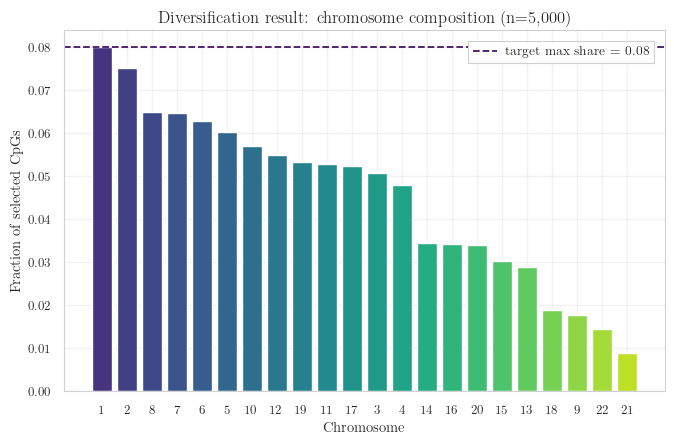

In [20]:
# =============================
# STEP 5 — PLOT: Chromosome share (Viridis + vertical labels)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

sel = np.array(selected_diverse, dtype=object)
chrs = np.array([cpg_to_chr.get(c, "") for c in sel], dtype=object)
chrs = chrs[chrs != ""]

# counts and fractions
uniq, cnt = np.unique(chrs, return_counts=True)
frac = cnt / cnt.sum()

# sort descending
ordr = np.argsort(-frac)
uniq, cnt, frac = uniq[ordr], cnt[ordr], frac[ordr]

# --- Viridis colors ---
cmap = plt.cm.viridis
colors = cmap(np.linspace(0.15, 0.90, len(uniq)))

fig, ax = plt.subplots()
ax.bar(np.arange(len(uniq)), frac, color=colors)

ax.axhline(CHR_MAX_FRAC,
           linestyle="--",
           linewidth=1.3,
           color=cmap(0.05),
           label=rf"target max share = {CHR_MAX_FRAC:.2f}")

ax.set_xticks(np.arange(len(uniq)))
ax.set_xticklabels(uniq, rotation=0, ha="center")

ax.set_ylabel("Fraction of selected CpGs")
ax.set_xlabel("Chromosome")
ax.set_title(f"Diversification result: chromosome composition (n={len(sel):,})")

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE PDF
# -----------------------------
OUT_DIR = Path("figures/step5")
OUT_DIR.mkdir(parents=True, exist_ok=True)

dataset_tag = DATASET_NAME if "DATASET_NAME" in globals() else "GSE69914"

pdf_path = OUT_DIR / f"{dataset_tag}_chromosome_share_diversified_K{K_TARGET}_maxfrac{CHR_MAX_FRAC:.2f}.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")

print(f"[OK] Saved PDF → {pdf_path}")

plt.show()


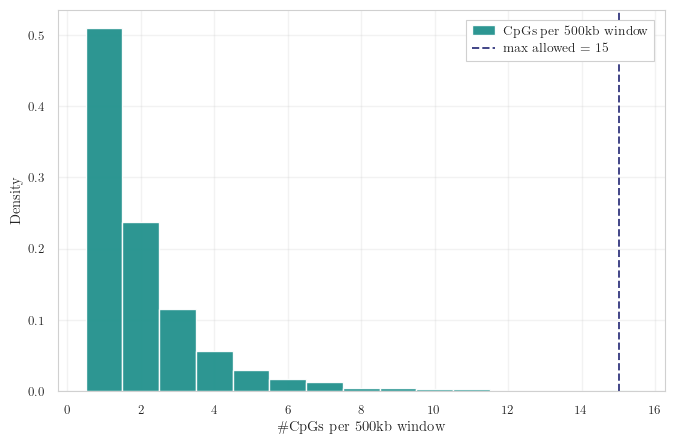

[Spatial density] windows=2373 | max_in_window=15 | violations(cnt>MAX_PER_WIN)=0
Saved as: SpatialDensityConstraint_GSE69914.pdf


In [21]:
# =============================
# STEP 5 — Spatial density constraint check
# Save as: SpatialDensityConstraint_<DATASET_NAME>.pdf
# =============================

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib import cm

DATASET_NAME = "GSE69914"

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

sel = np.array(selected_diverse, dtype=object)

pairs = []
for c in sel:
    ch = cpg_to_chr.get(c, "")
    ps = cpg_to_pos.get(c, None)
    if (ch == "") or (ps is None):
        continue
    win = int(int(ps) // int(WIN_BP))
    pairs.append((str(ch), win))

if len(pairs) == 0:
    raise RuntimeError("No mapped CpGs for spatial window check.")

cnt = np.array(list(Counter(pairs).values()), dtype=int)

color_main = cm.viridis(0.5)
color_line = cm.viridis(0.2)

fig, ax = plt.subplots()

bins = np.arange(1, cnt.max() + 2) - 0.5
ax.hist(cnt,
        bins=bins,
        density=True,
        alpha=0.95,
        color=color_main,
        label=f"CpGs per {WIN_BP//1000}kb window")

ax.axvline(int(MAX_PER_WIN),
           linestyle="--",
           linewidth=1.4,
           color=color_line,
           label=rf"max allowed = {int(MAX_PER_WIN)}")

ax.set_xlabel(f"\#CpGs per {WIN_BP//1000}kb window")
ax.set_ylabel("Density")

place_legend(ax)
fig.tight_layout()

# ---- SAVE ----
plot_name = "SpatialDensityConstraint"
fname = f"{plot_name}_{DATASET_NAME}.pdf"
fig.savefig(fname, bbox_inches="tight")

plt.show()

print(f"[Spatial density] windows={cnt.size} | max_in_window={cnt.max()} | violations(cnt>MAX_PER_WIN)={int(np.sum(cnt > MAX_PER_WIN))}")
print(f"Saved as: {fname}")


In [22]:
# -----------------------------
# STEP 6 — Final K selection
#   K = 5000 (take first K from STEP 5 output order)
# -----------------------------

K_FINAL = 5000

# Assumes from STEP 5:
#   selected_diverse : CpG list in chosen greedy order (best-first under constraints)
final_cpgs = np.array(selected_diverse, dtype=object)[:min(K_FINAL, len(selected_diverse))]

print("\n" + "=" * 90)
print(f"STEP 6 — Final CpG set: K={K_FINAL} (got {final_cpgs.size:,})")
print("=" * 90)

# Outputs for downstream modeling:
#   final_cpgs



STEP 6 — Final CpG set: K=5000 (got 5,000)


In [29]:
# =============================
# EXPORT — final 5000 CpGs
# =============================

import numpy as np
import polars as pl
from pathlib import Path
from datetime import datetime

# Assumes:
#   final_cpgs : np.ndarray (K=5000) from STEP 6

RUN_TAG = "gse69914_fs_v1_5000"   # cambia come vuoi
OUTDIR = Path("./fs_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

final_cpgs = np.array(final_cpgs, dtype=object)

# basic checks
if final_cpgs.size == 0:
    raise RuntimeError("final_cpgs is empty. Check STEP 6.")
if len(np.unique(final_cpgs)) != final_cpgs.size:
    raise RuntimeError("final_cpgs contains duplicates.")

ts = datetime.now().strftime("%Y%m%d_%H%M%S")

# TXT (one per line)
txt_path = OUTDIR / f"final_cpgs_K{final_cpgs.size}_{RUN_TAG}_{ts}.txt"
with open(txt_path, "w") as f:
    for c in final_cpgs:
        f.write(f"{c}\n")

# CSV
csv_path = OUTDIR / f"final_cpgs_K{final_cpgs.size}_{RUN_TAG}_{ts}.csv"
pl.DataFrame({"CpG_ID": final_cpgs}).write_csv(csv_path)

print("Saved CpGs TXT:", txt_path)
print("Saved CpGs CSV:", csv_path)
print("K =", final_cpgs.size)
print("Example:", final_cpgs[:5].tolist())


Saved CpGs TXT: fs_outputs/final_cpgs_K5000_gse69914_fs_v1_5000_20260221_095202.txt
Saved CpGs CSV: fs_outputs/final_cpgs_K5000_gse69914_fs_v1_5000_20260221_095202.csv
K = 5000
Example: ['cg09296001', 'cg08774368', 'cg17812788', 'cg04711162', 'cg27616661']


In [31]:
import numpy as np

# colonne attuali (post STEP precedenti)
cols = np.array(cpg_cols_current, dtype=object)

# set per lookup veloce
cols_set = set(cols)

# filtra solo CpG effettivamente presenti
final_cpg_present = [c for c in final_cpgs if c in cols_set]

if len(final_cpg_present) == 0:
    raise ValueError("Nessuna CpG di final_cpg è presente in cpg_cols_current.")

if len(final_cpg_present) < len(final_cpgs):
    print(f"Attenzione: {len(final_cpg) - len(final_cpg_present)} CpG non trovate e rimosse.")

# indici corrispondenti
idx = np.array([np.where(cols == c)[0][0] for c in final_cpg_present])

# subset matrici
X_train = M_train[:, idx]
X_test  = M_test[:,  idx]

print("Nuove shape:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


Nuove shape:
X_train: (73, 5000)
X_test : (19, 5000)



------------------------------------------------------------------------------------------
CLASSIFIER_MODE = svm_grid
------------------------------------------------------------------------------------------
Best C: 0.001
Best CV AUC: 0.8917

METRICS (test) — LinearSVC(grid C; best=0.001):
AUC         = 0.6333
BAcc        = 0.5778
Precision   = 0.5556
Recall      = 0.5556
F1-score    = 0.5556
PR-AUC      = 0.6597
Specificity = 0.6000
MCC         = 0.1556

Confusion matrix [labels 0,1]:
[[6 4]
 [4 5]]

Classification report:
              precision    recall  f1-score   support

           0     0.6000    0.6000    0.6000        10
           1     0.5556    0.5556    0.5556         9

    accuracy                         0.5789        19
   macro avg     0.5778    0.5778    0.5778        19
weighted avg     0.5789    0.5789    0.5789        19


ROC — LinearSVC(grid C; best=0.001) on final FS CpGs (K=5,000) | dataset=GSE69914
Saved plot to: fs_outputs/GSE69914_svm_grid_ROC_finalFS.pd

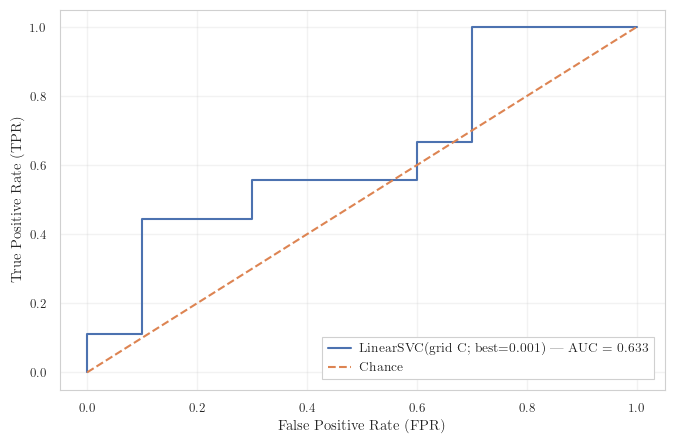


COEF CHECK:
best_coef shape = (5000,) | finite = True


In [33]:
# -----------------------------
# 2) CLASSIFIER (3 options) + METRICS + ROC PLOT
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score, classification_report,
    average_precision_score, matthews_corrcoef, roc_curve
)

# Models
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# -----------------------------
# CONFIG (choose one)
# -----------------------------
# "ridge" | "svm_grid" | "logreg_enet"
CLASSIFIER_MODE = "logreg_enet"

# Shared
RANDOM_STATE = globals().get("RANDOM_STATE", 42)

# SVM grid
SVM_MAX_ITER = globals().get("SVM_MAX_ITER", 10000)
SVM_C_GRID   = globals().get("SVM_C_GRID", [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0])
SVM_CV_SPLITS = globals().get("SVM_CV_SPLITS", 5)

# Ridge
RIDGE_ALPHA = 0.0001 

# LogReg ElasticNet
LOGREG_C        = globals().get("LOGREG_C", 0.1)
LOGREG_L1_RATIO = globals().get("LOGREG_L1_RATIO", 0.5)
LOGREG_MAX_ITER = globals().get("LOGREG_MAX_ITER", 5000)

print("\n" + "-" * 90)
print(f"CLASSIFIER_MODE = {CLASSIFIER_MODE}")
print("-" * 90)


# -----------------------------
# Helper: metrics + prints
# -----------------------------
def eval_and_print(y_true, score, pred, *, name="model"):
    auc  = roc_auc_score(y_true, score)
    bacc = balanced_accuracy_score(y_true, pred)
    cm   = confusion_matrix(y_true, pred, labels=[0, 1])

    precision = precision_score(y_true, pred, zero_division=0)
    recall    = recall_score(y_true, pred, zero_division=0)
    f1        = f1_score(y_true, pred, zero_division=0)
    pr_auc    = average_precision_score(y_true, score)
    mcc       = matthews_corrcoef(y_true, pred)

    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp + 1e-12)

    print(f"\nMETRICS (test) — {name}:")
    print(f"AUC         = {auc:.4f}")
    print(f"BAcc        = {bacc:.4f}")
    print(f"Precision   = {precision:.4f}")
    print(f"Recall      = {recall:.4f}")
    print(f"F1-score    = {f1:.4f}")
    print(f"PR-AUC      = {pr_auc:.4f}")
    print(f"Specificity = {specificity:.4f}")
    print(f"MCC         = {mcc:.4f}")

    print("\nConfusion matrix [labels 0,1]:")
    print(cm)

    print("\nClassification report:")
    print(classification_report(y_true, pred, digits=4, zero_division=0))

    out = {
        "auc": auc, "bacc": bacc, "precision": precision, "recall": recall, "f1": f1,
        "pr_auc": pr_auc, "specificity": specificity, "mcc": mcc, "cm": cm
    }
    return out

def get_linear_coef(pipe):
    """
    Returns 1D coef vector aligned to feature columns (same order as X_train),
    assuming final estimator exposes coef_.
    """
    # Pipeline last step name can differ; robust:
    est = pipe.steps[-1][1]
    if not hasattr(est, "coef_"):
        return None
    c = est.coef_
    c = np.asarray(c)
    if c.ndim == 2 and c.shape[0] == 1:
        c = c.ravel()
    elif c.ndim == 2 and c.shape[0] > 1:
        # multiclass fallback (shouldn't happen here)
        c = c.mean(axis=0)
    return c.astype(np.float64, copy=False)

# -----------------------------
# Build the chosen model
# -----------------------------
if CLASSIFIER_MODE == "ridge":
    model_name = f"Ridge(alpha={RIDGE_ALPHA})"
    clf = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", RidgeClassifier(alpha=RIDGE_ALPHA, class_weight="balanced", random_state=RANDOM_STATE)),
    ])
    clf.fit(X_train, y_train)
    score = clf.decision_function(X_test)
    pred  = clf.predict(X_test)

elif CLASSIFIER_MODE == "svm_grid":
    # train-only CV for C
    base = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("svm", LinearSVC(class_weight="balanced", max_iter=SVM_MAX_ITER, random_state=RANDOM_STATE)),
    ])
    param_grid = {"svm__C": list(SVM_C_GRID)}
    cv = StratifiedKFold(n_splits=SVM_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    gs = GridSearchCV(
        estimator=base,
        param_grid=param_grid,
        cv=cv,
        scoring="roc_auc",
        refit=True,
        n_jobs=-1
    )
    gs.fit(X_train, y_train)

    bestC = gs.best_params_["svm__C"]
    model_name = f"LinearSVC(grid C; best={bestC})"
    print(f"Best C: {bestC}")
    print(f"Best CV AUC: {gs.best_score_:.4f}")

    clf = gs.best_estimator_
    score = clf.decision_function(X_test)
    pred  = clf.predict(X_test)

elif CLASSIFIER_MODE == "logreg_enet":
    model_name = f"LogReg(ENet; C={LOGREG_C}, l1_ratio={LOGREG_L1_RATIO})"
    clf = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=LOGREG_L1_RATIO,
            C=LOGREG_C,
            class_weight="balanced",
            max_iter=LOGREG_MAX_ITER,
            random_state=RANDOM_STATE
        )),
    ])
    clf.fit(X_train, y_train)
    score = clf.decision_function(X_test)
    pred  = clf.predict(X_test)

else:
    raise ValueError("CLASSIFIER_MODE must be one of: 'ridge' | 'svm_grid' | 'logreg_enet'")

# -----------------------------
# Metrics
# -----------------------------
metrics = eval_and_print(y_test, score, pred, name=model_name)

# -----------------------------
# ROC plot (thesis style) + SAVE PDF
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, score)
auc = metrics["auc"]

apply_thesis_style(use_tex=True, legend_position="lower right", legend_outside=False)
fig_roc, ax = plt.subplots(figsize=(6.8, 4.5))

ax.plot(fpr, tpr, label=rf"{model_name} | AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", label="Chance")

ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")

print(f"\nROC — {model_name} on final FS CpGs (K={X_train.shape[1]:,}) | dataset={DATASET_NAME}")

place_legend(ax)
fig_roc.tight_layout()

pdf_path = OUTDIR / f"{DATASET_NAME}_{CLASSIFIER_MODE}_ROC_finalFS.pdf"
fig_roc.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

# -----------------------------
# Outputs you may reuse later (knapsack-friendly)
# -----------------------------
best_model = clf
best_name  = model_name
best_score = score
best_pred  = pred
best_coef  = get_linear_coef(clf)  # 1D array aligned with final_cpgs order (i.e., X_train columns)

print("\nCOEF CHECK:")
if best_coef is None:
    print("WARNING: model has no coef_ (unexpected for these 3 options).")
else:
    print(f"best_coef shape = {best_coef.shape} | finite = {np.isfinite(best_coef).all()}")
    


------------------------------------------------------------------------------------------
CLASSIFIER_MODE = svm_grid
------------------------------------------------------------------------------------------

[GRID] Best params:
  svm__C: 1.0
[GRID] Best CV AUC: 0.9035

[GRID] Top-10 configs by mean CV AUC:
  mean=0.9035 ± 0.0711 | {'svm__C': 1.0}
  mean=0.9030 ± 0.0711 | {'svm__C': 5.0}
  mean=0.8990 ± 0.0723 | {'svm__C': 0.5}
  mean=0.8946 ± 0.0776 | {'svm__C': 0.1}
  mean=0.8935 ± 0.0788 | {'svm__C': 0.05}
  mean=0.8923 ± 0.0786 | {'svm__C': 0.01}
  mean=0.8916 ± 0.0798 | {'svm__C': 0.001}

[MODEL] All params (Pipeline.get_params):
  memory: None
  scaler: StandardScaler()
  scaler__copy: True
  scaler__with_mean: True
  scaler__with_std: True
  steps: [('scaler', StandardScaler()), ('svm', LinearSVC(class_weight='balanced', dual=False, max_iter=10000, random_state=42))]
  svm: LinearSVC(class_weight='balanced', dual=False, max_iter=10000, random_state=42)
  svm__C: 1.0
  svm__cla

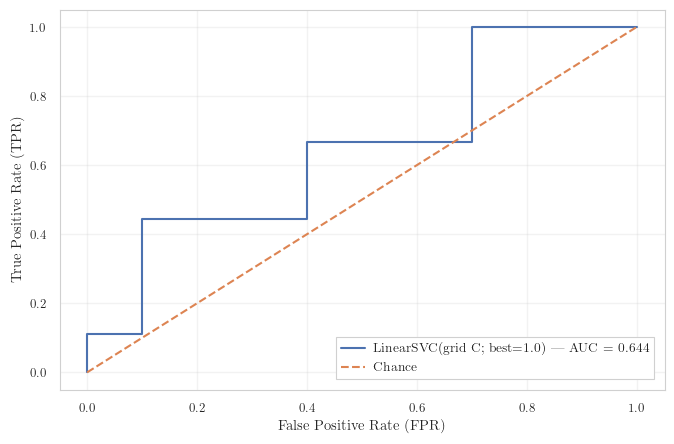


COEF CHECK:
best_coef shape = (5000,) | finite = True


In [38]:
# -----------------------------
# 2) CLASSIFIER (3 options) + METRICS + ROC PLOT
#   Modes:
#     - "svm_grid"     : LinearSVC + GridSearchCV(C) with RepeatedStratifiedKFold
#     - "logreg_l2_grid": LogisticRegression(L2) + GridSearchCV(C) with RepeatedStratifiedKFold
#     - "ridge_grid"   : RidgeClassifier + GridSearchCV(alpha) with RepeatedStratifiedKFold
#
#   Extras:
#     - prints best params + top-10 configs
#     - outputs coef aligned with X_train columns
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score, classification_report,
    average_precision_score, matthews_corrcoef, roc_curve
)

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV

# -----------------------------
# CONFIG (choose one)
# -----------------------------
# "svm_grid" | "logreg_l2_grid" | "ridge_grid"
CLASSIFIER_MODE = "svm_grid"

RANDOM_STATE = globals().get("RANDOM_STATE", 42)

# CV (more stable for small-n)
CV_SPLITS  = globals().get("CV_SPLITS", 5)
CV_REPEATS = globals().get("CV_REPEATS", 10)

# SVM
SVM_MAX_ITER = globals().get("SVM_MAX_ITER", 20000)
SVM_C_GRID = globals().get(
    "SVM_C_GRID",
    [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0, 3.0, 10.0]
)

# LogReg L2
LOGREG_MAX_ITER = globals().get("LOGREG_MAX_ITER", 10000)
LOGREG_C_GRID = globals().get(
    "LOGREG_C_GRID",
    [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0, 3.0, 10.0]
)
# solver: liblinear is very stable for small-n binary
LOGREG_SOLVER = globals().get("LOGREG_SOLVER", "liblinear")

# Ridge
RIDGE_ALPHA_GRID = globals().get(
    "RIDGE_ALPHA_GRID",
    [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0, 3.0, 10.0]
)

print("\n" + "-" * 90)
print(f"CLASSIFIER_MODE = {CLASSIFIER_MODE}")
print("-" * 90)

# -----------------------------
# Helper: metrics + prints
# -----------------------------
def eval_and_print(y_true, score, pred, *, name="model"):
    auc  = roc_auc_score(y_true, score)
    bacc = balanced_accuracy_score(y_true, pred)
    cm   = confusion_matrix(y_true, pred, labels=[0, 1])

    precision = precision_score(y_true, pred, zero_division=0)
    recall    = recall_score(y_true, pred, zero_division=0)
    f1        = f1_score(y_true, pred, zero_division=0)
    pr_auc    = average_precision_score(y_true, score)
    mcc       = matthews_corrcoef(y_true, pred)

    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp + 1e-12)

    print(f"\nMETRICS (test) — {name}:")
    print(f"AUC         = {auc:.4f}")
    print(f"BAcc        = {bacc:.4f}")
    print(f"Precision   = {precision:.4f}")
    print(f"Recall      = {recall:.4f}")
    print(f"F1-score    = {f1:.4f}")
    print(f"PR-AUC      = {pr_auc:.4f}")
    print(f"Specificity = {specificity:.4f}")
    print(f"MCC         = {mcc:.4f}")

    print("\nConfusion matrix [labels 0,1]:")
    print(cm)

    print("\nClassification report:")
    print(classification_report(y_true, pred, digits=4, zero_division=0))

    out = {
        "auc": auc, "bacc": bacc, "precision": precision, "recall": recall, "f1": f1,
        "pr_auc": pr_auc, "specificity": specificity, "mcc": mcc, "cm": cm
    }
    return out

def get_linear_coef(pipe):
    """Return 1D coef vector aligned to X_train columns."""
    est = pipe.steps[-1][1]
    if not hasattr(est, "coef_"):
        return None
    c = np.asarray(est.coef_)
    if c.ndim == 2 and c.shape[0] == 1:
        c = c.ravel()
    elif c.ndim == 2 and c.shape[0] > 1:
        c = c.mean(axis=0)
    return c.astype(np.float64, copy=False)

def print_grid_summary(gs, top_k=10):
    print("\n[GRID] Best params:")
    for k, v in gs.best_params_.items():
        print(f"  {k}: {v}")
    print(f"[GRID] Best CV AUC: {gs.best_score_:.4f}")

    res = gs.cv_results_
    order = np.argsort(res["mean_test_score"])[::-1]
    print(f"\n[GRID] Top-{top_k} configs by mean CV AUC:")
    for i in order[:top_k]:
        params = res["params"][i]
        mean = res["mean_test_score"][i]
        std  = res["std_test_score"][i]
        print(f"  mean={mean:.4f} ± {std:.4f} | {params}")

# -----------------------------
# CV object
# -----------------------------
cv = RepeatedStratifiedKFold(
    n_splits=CV_SPLITS,
    n_repeats=CV_REPEATS,
    random_state=RANDOM_STATE
)

# -----------------------------
# Build + fit the chosen model
# -----------------------------
if CLASSIFIER_MODE == "svm_grid":
    base = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("svm", LinearSVC(
            class_weight="balanced",
            max_iter=SVM_MAX_ITER,
            random_state=RANDOM_STATE,
            dual=False,  # better when n_samples > n_features (often post-FS)
        )),
    ])
    param_grid = {"svm__C": list(SVM_C_GRID)}
    gs = GridSearchCV(base, param_grid, cv=cv, scoring="roc_auc", refit=True, n_jobs=-1)
    gs.fit(X_train, y_train)

    model_name = f"LinearSVC(grid C; best={gs.best_params_['svm__C']})"
    print_grid_summary(gs, top_k=10)

    clf = gs.best_estimator_
    print("\n[MODEL] All params (Pipeline.get_params):")
    all_params = clf.get_params(deep=True)
    for k in sorted(all_params.keys()):
        print(f"  {k}: {all_params[k]}")
    score = clf.decision_function(X_test)
    pred  = clf.predict(X_test)

elif CLASSIFIER_MODE == "logreg_l2_grid":
    base = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("lr", LogisticRegression(
            penalty="l2",
            solver=LOGREG_SOLVER,
            class_weight="balanced",
            max_iter=LOGREG_MAX_ITER,
            random_state=RANDOM_STATE
        )),
    ])
    param_grid = {"lr__C": list(LOGREG_C_GRID)}
    gs = GridSearchCV(base, param_grid, cv=cv, scoring="roc_auc", refit=True, n_jobs=-1)
    gs.fit(X_train, y_train)

    model_name = f"LogReg(L2 grid C; best={gs.best_params_['lr__C']})"
    print_grid_summary(gs, top_k=10)

    clf = gs.best_estimator_
    print("\n[MODEL] All params (Pipeline.get_params):")
    all_params = clf.get_params(deep=True)
    for k in sorted(all_params.keys()):
        print(f"  {k}: {all_params[k]}")
    score = clf.decision_function(X_test)
    pred  = clf.predict(X_test)

elif CLASSIFIER_MODE == "ridge_grid":
    # NOTE: RidgeClassifier uses alpha (regularization strength).
    # We still scale features for stability.
    base = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("ridge", RidgeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        )),
    ])
    param_grid = {"ridge__alpha": list(RIDGE_ALPHA_GRID)}
    gs = GridSearchCV(base, param_grid, cv=cv, scoring="roc_auc", refit=True, n_jobs=-1)
    gs.fit(X_train, y_train)

    model_name = f"Ridge(grid alpha; best={gs.best_params_['ridge__alpha']})"
    print_grid_summary(gs, top_k=10)

    clf = gs.best_estimator_
    print("\n[MODEL] All params (Pipeline.get_params):")
    all_params = clf.get_params(deep=True)
    for k in sorted(all_params.keys()):
        print(f"  {k}: {all_params[k]}")
    score = clf.decision_function(X_test)
    pred  = clf.predict(X_test)

else:
    raise ValueError("CLASSIFIER_MODE must be one of: 'svm_grid' | 'logreg_l2_grid' | 'ridge_grid'")

# -----------------------------
# Metrics
# -----------------------------
metrics = eval_and_print(y_test, score, pred, name=model_name)

# -----------------------------
# ROC plot (thesis style) + SAVE PDF
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, score)
auc = metrics["auc"]

apply_thesis_style(use_tex=True, legend_position="lower right", legend_outside=False)
fig_roc, ax = plt.subplots(figsize=(6.8, 4.5))

ax.plot(fpr, tpr, label=rf"{model_name} | AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", label="Chance")

ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")

print(f"\nROC — {model_name} on final FS CpGs (K={X_train.shape[1]:,}) | dataset={DATASET_NAME}")

place_legend(ax)
fig_roc.tight_layout()

pdf_path = OUTDIR / f"{DATASET_NAME}_{CLASSIFIER_MODE}_ROC_finalFS.pdf"
fig_roc.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

# -----------------------------
# Outputs you may reuse later
# -----------------------------
best_model = clf
best_name  = model_name
best_score = score
best_pred  = pred
best_coef  = get_linear_coef(clf)  # aligned with X_train columns (your final CpG order)

print("\nCOEF CHECK:")
if best_coef is None:
    print("WARNING: model has no coef_ (unexpected for these linear models).")
else:
    print(f"best_coef shape = {best_coef.shape} | finite = {np.isfinite(best_coef).all()}")
    

PCA 2D shapes: (73, 2) (19, 2)
Explained var (2 PCs): 0.31447494


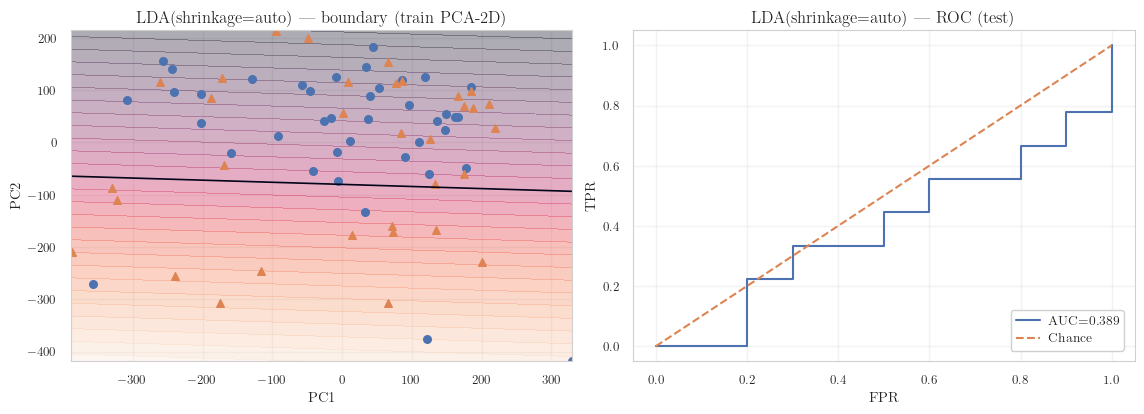

     LDA(shrinkage=auto) | TEST AUC = 0.3889


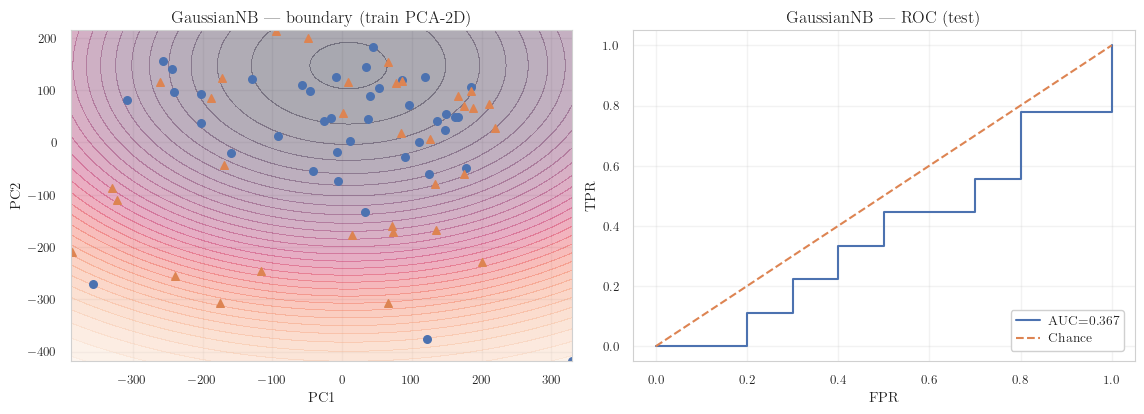

              GaussianNB | TEST AUC = 0.3667


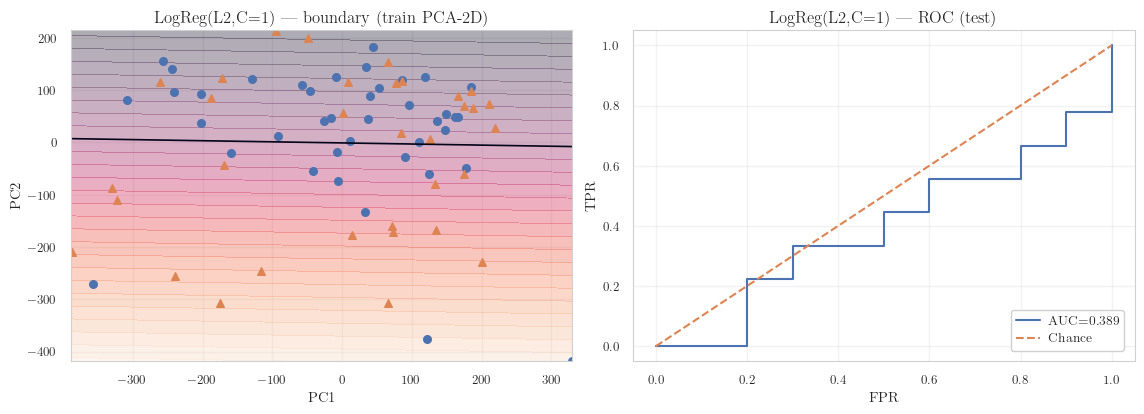

          LogReg(L2,C=1) | TEST AUC = 0.3889


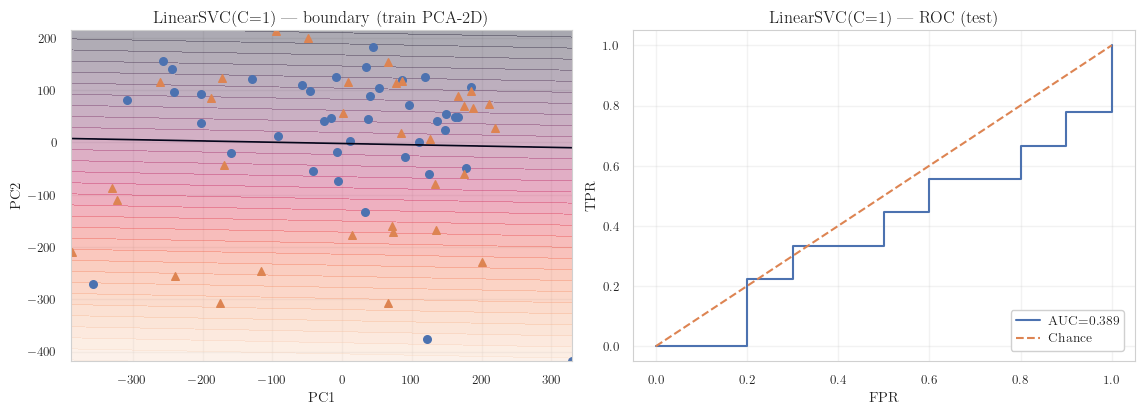

          LinearSVC(C=1) | TEST AUC = 0.3889


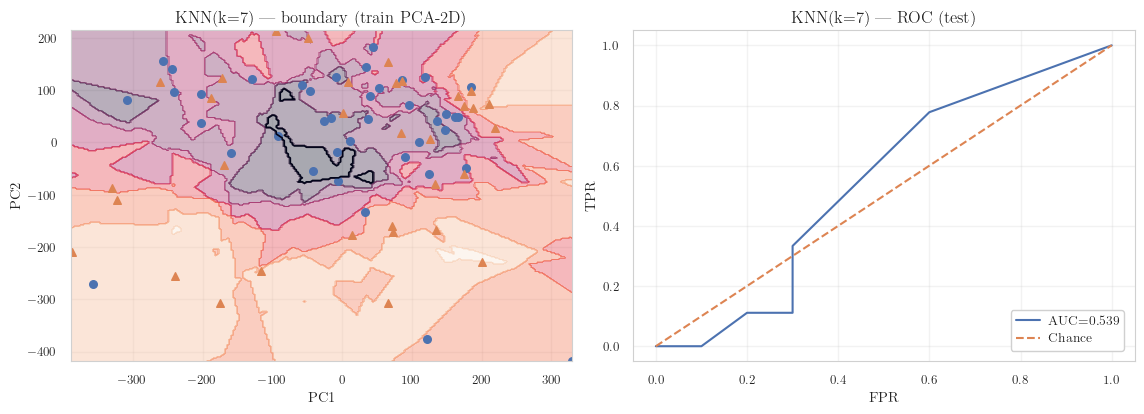

                KNN(k=7) | TEST AUC = 0.5389


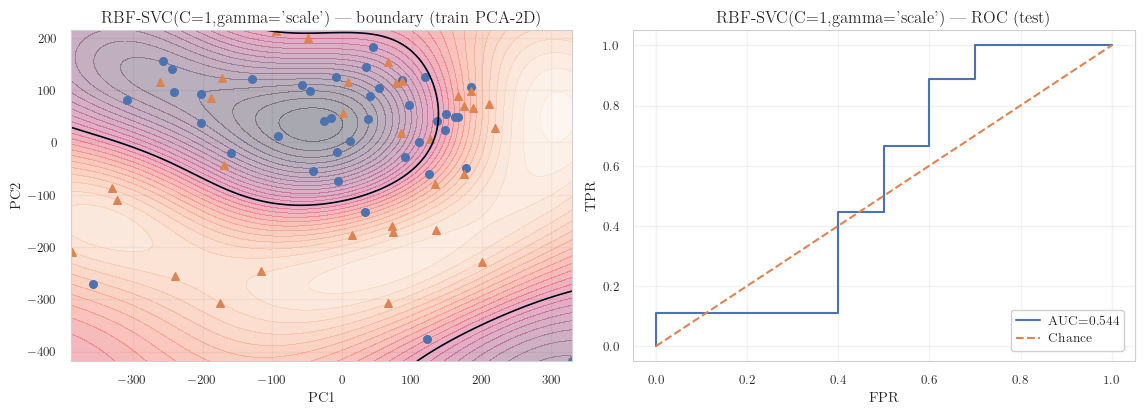

RBF-SVC(C=1,gamma='scale') | TEST AUC = 0.5444


In [41]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier

# -----------------------------
# 1) Build PCA-2D view (train-only)
# -----------------------------
scaler_2d = StandardScaler(with_mean=True, with_std=True)
pca = PCA(n_components=2, random_state=RANDOM_STATE)

Z_train = pca.fit_transform(scaler_2d.fit_transform(M_train))
Z_test  = pca.transform(scaler_2d.transform(M_test))

print("PCA 2D shapes:", Z_train.shape, Z_test.shape)
print("Explained var (2 PCs):", pca.explained_variance_ratio_.sum())

# -----------------------------
# 2) Models in 2D (for boundary visualization)
# -----------------------------
models = {
    "LDA(shrinkage=auto)": LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"),
    "GaussianNB": GaussianNB(),
    "LogReg(L2,C=1)": LogisticRegression(penalty="l2", solver="liblinear", C=1.0, class_weight="balanced", random_state=RANDOM_STATE),
    "LinearSVC(C=1)": LinearSVC(C=1.0, class_weight="balanced", max_iter=20000, random_state=RANDOM_STATE),
    "KNN(k=7)": KNeighborsClassifier(n_neighbors=7),
    "RBF-SVC(C=1,gamma='scale')": SVC(C=1.0, kernel="rbf", gamma="scale", class_weight="balanced", probability=False, random_state=RANDOM_STATE),
}

def get_score(model, X):
    # prefer decision_function; else proba; else signed prediction
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    # fallback
    return model.predict(X).astype(float)

def plot_boundary(ax, model, Z, y, title):
    # mesh
    x_min, x_max = Z[:, 0].min() - 1.0, Z[:, 0].max() + 1.0
    y_min, y_max = Z[:, 1].min() - 1.0, Z[:, 1].max() + 1.0
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    s = get_score(model, grid).reshape(xx.shape)

    # decision surface
    ax.contourf(xx, yy, s, levels=30, alpha=0.35)
    ax.contour(xx, yy, s, levels=[0.0], linewidths=1.2)

    # points
    ax.scatter(Z[y == 0, 0], Z[y == 0, 1], s=30, marker="o", label="0")
    ax.scatter(Z[y == 1, 0], Z[y == 1, 1], s=30, marker="^", label="1")

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

# -----------------------------
# 3) Fit, evaluate, plot
# -----------------------------
for name, model in models.items():
    model.fit(Z_train, y_train)

    score_te = get_score(model, Z_test)
    auc_te = roc_auc_score(y_test, score_te)

    fpr, tpr, _ = roc_curve(y_test, score_te)

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

    # Boundary (PCA 2D)
    plot_boundary(axes[0], model, Z_train, y_train, f"{name} | boundary (train PCA-2D)")

    # ROC (test)
    axes[1].plot(fpr, tpr, label=f"AUC={auc_te:.3f}")
    axes[1].plot([0, 1], [0, 1], linestyle="--", label="Chance")
    axes[1].set_title(f"{name} | ROC (test)")
    axes[1].set_xlabel("FPR")
    axes[1].set_ylabel("TPR")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"{name:>24} | TEST AUC = {auc_te:.4f}")


MODEL ZOO (full-dim training) | K=5,000 | n_train=73 | n_test=19

[GRID] LinearSVC(grid C)
  best_params: {'svm__C': 1.0}
  best_CV_AUC: 0.9035

[MODEL] All final pipeline parameters:
  memory: None
  scaler: StandardScaler()
  scaler__copy: True
  scaler__with_mean: True
  scaler__with_std: True
  steps: [('scaler', StandardScaler()), ('svm', LinearSVC(class_weight='balanced', dual=False, max_iter=10000, random_state=42))]
  svm: LinearSVC(class_weight='balanced', dual=False, max_iter=10000, random_state=42)
  svm__C: 1.0
  svm__class_weight: balanced
  svm__dual: False
  svm__fit_intercept: True
  svm__intercept_scaling: 1
  svm__loss: squared_hinge
  svm__max_iter: 10000
  svm__multi_class: ovr
  svm__penalty: l2
  svm__random_state: 42
  svm__tol: 0.0001
  svm__verbose: 0
  transform_input: None
  verbose: False
  TEST AUC: 0.6444


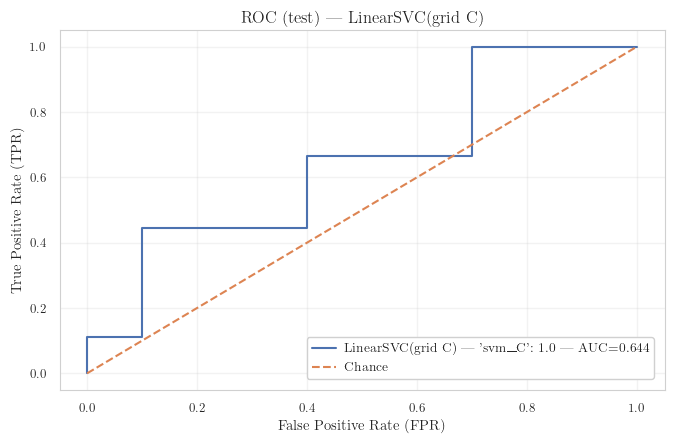

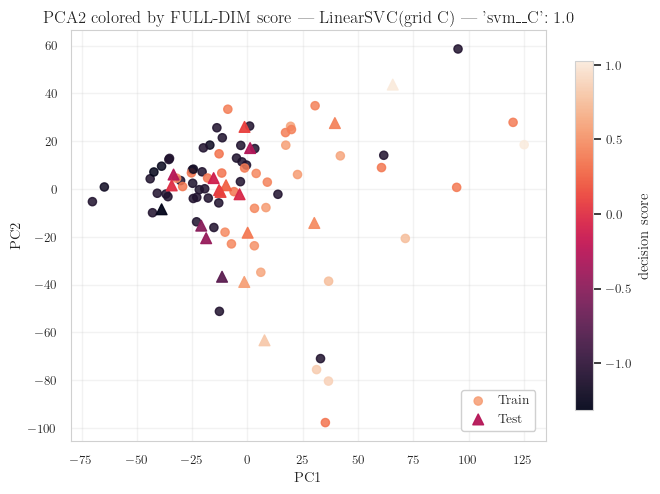

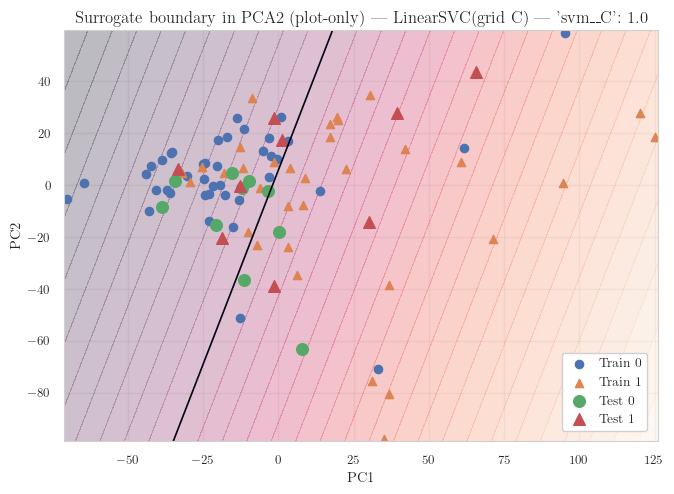


[GRID] LogReg L2 (grid C)
  best_params: {'lr__C': 10.0}
  best_CV_AUC: 0.8929

[MODEL] All final pipeline parameters:
  lr: LogisticRegression(C=10.0, class_weight='balanced', max_iter=5000,
                   random_state=42, solver='liblinear')
  lr__C: 10.0
  lr__class_weight: balanced
  lr__dual: False
  lr__fit_intercept: True
  lr__intercept_scaling: 1
  lr__l1_ratio: None
  lr__max_iter: 5000
  lr__multi_class: deprecated
  lr__n_jobs: None
  lr__penalty: l2
  lr__random_state: 42
  lr__solver: liblinear
  lr__tol: 0.0001
  lr__verbose: 0
  lr__warm_start: False
  memory: None
  scaler: StandardScaler()
  scaler__copy: True
  scaler__with_mean: True
  scaler__with_std: True
  steps: [('scaler', StandardScaler()), ('lr', LogisticRegression(C=10.0, class_weight='balanced', max_iter=5000,
                   random_state=42, solver='liblinear'))]
  transform_input: None
  verbose: False
  TEST AUC: 0.6333


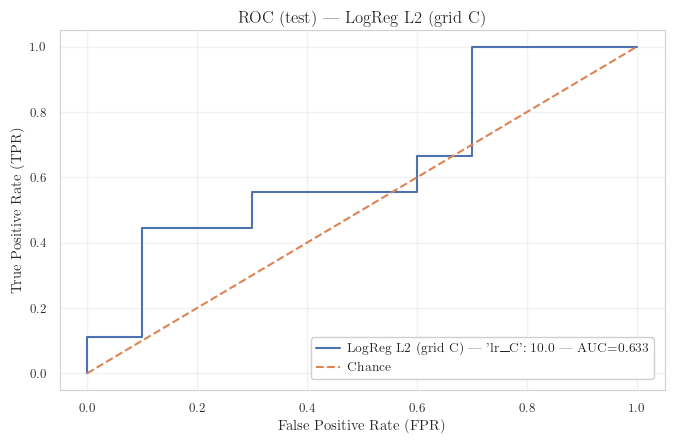

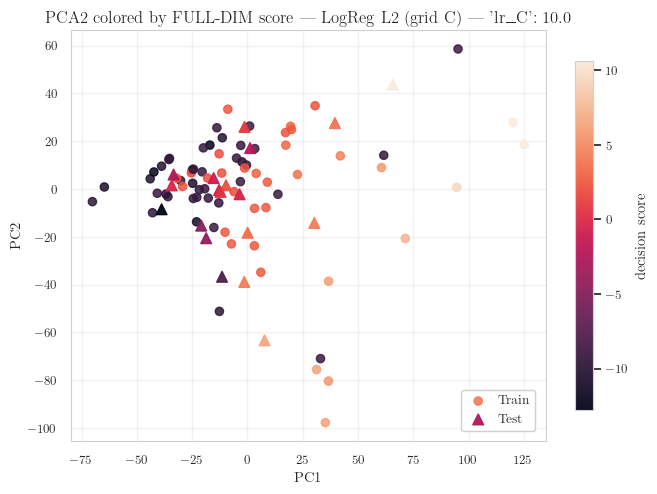

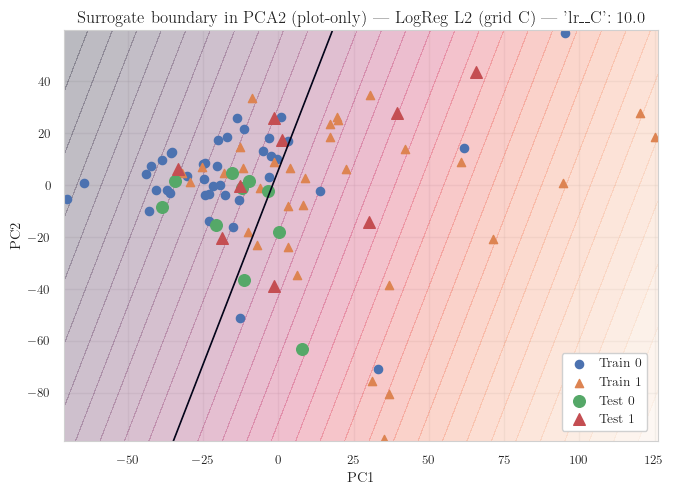

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.60661e-10): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.62913e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.16678e-10): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sk


[GRID] Ridge (grid alpha)
  best_params: {'ridge__alpha': 0.0001}
  best_CV_AUC: 0.9064

[MODEL] All final pipeline parameters:
  memory: None
  ridge: RidgeClassifier(alpha=0.0001, class_weight='balanced', random_state=42)
  ridge__alpha: 0.0001
  ridge__class_weight: balanced
  ridge__copy_X: True
  ridge__fit_intercept: True
  ridge__max_iter: None
  ridge__positive: False
  ridge__random_state: 42
  ridge__solver: auto
  ridge__tol: 0.0001
  scaler: StandardScaler()
  scaler__copy: True
  scaler__with_mean: True
  scaler__with_std: True
  steps: [('scaler', StandardScaler()), ('ridge', RidgeClassifier(alpha=0.0001, class_weight='balanced', random_state=42))]
  transform_input: None
  verbose: False
  TEST AUC: 0.6222


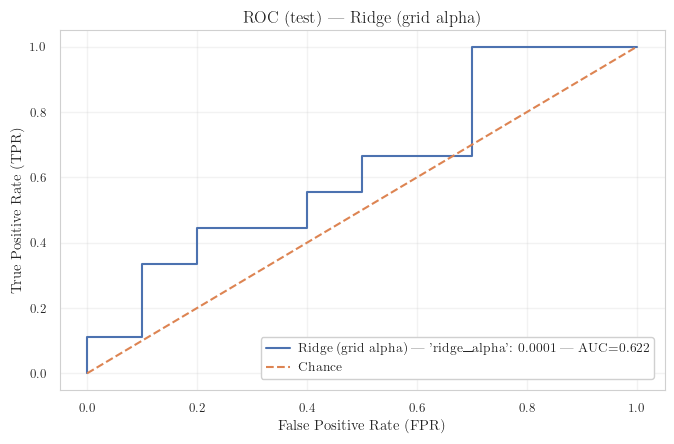

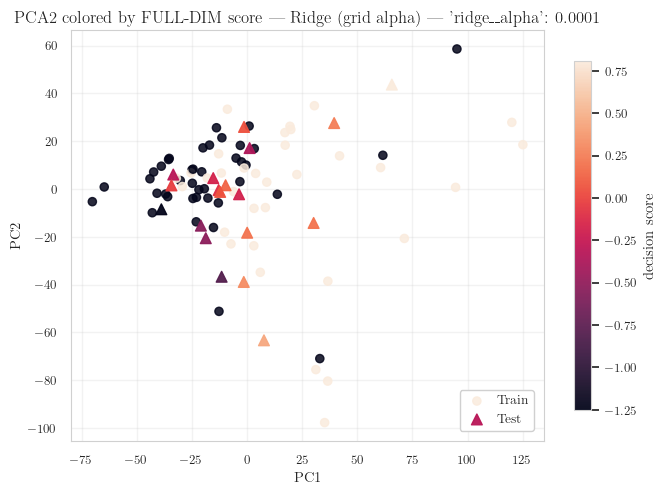

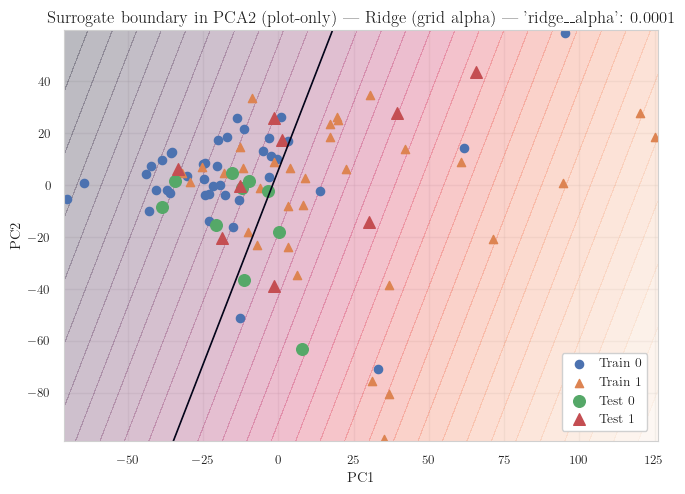


[MODEL] All final pipeline parameters:
  lda: LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
  lda__covariance_estimator: None
  lda__n_components: None
  lda__priors: None
  lda__shrinkage: auto
  lda__solver: lsqr
  lda__store_covariance: False
  lda__tol: 0.0001
  memory: None
  scaler: StandardScaler()
  scaler__copy: True
  scaler__with_mean: True
  scaler__with_std: True
  steps: [('scaler', StandardScaler()), ('lda', LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'))]
  transform_input: None
  verbose: False

[FIT] LDA(shrinkage=auto) (no grid)
  TEST AUC: 0.6222


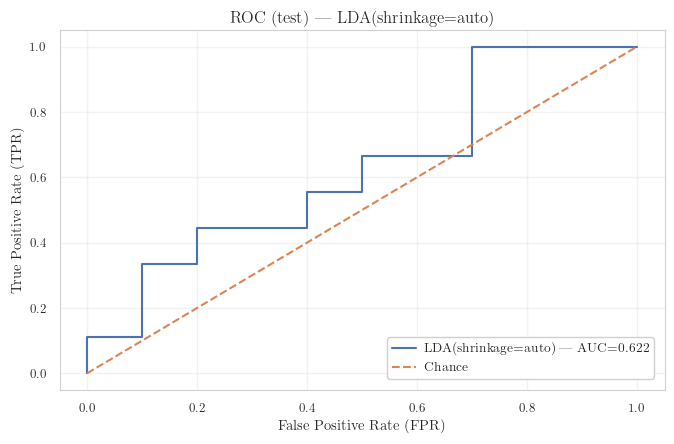

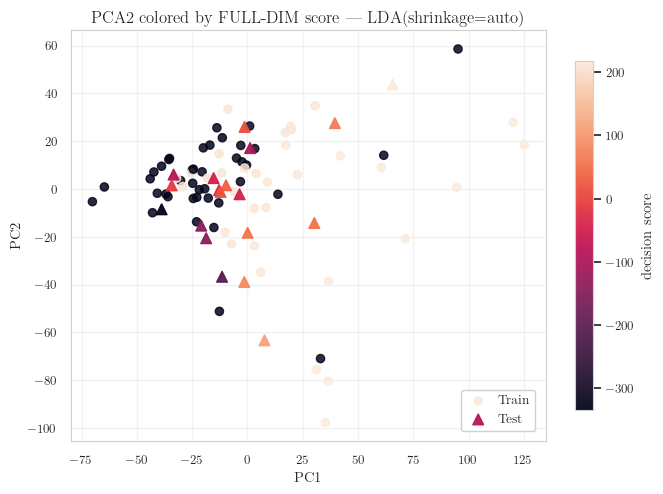

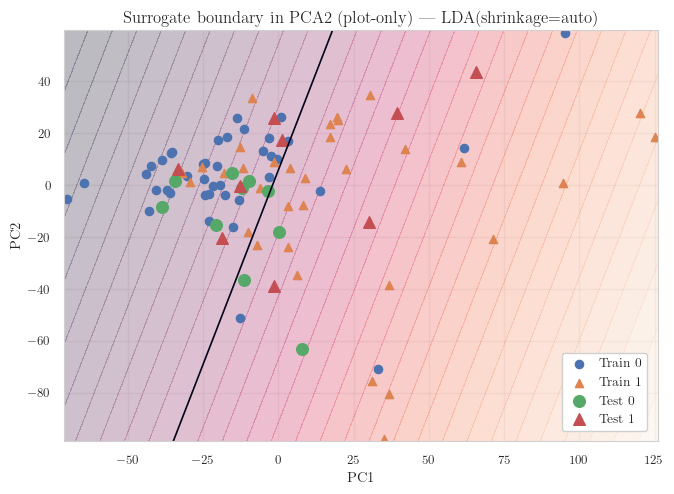


[MODEL] All final pipeline parameters:
  gnb: GaussianNB()
  gnb__priors: None
  gnb__var_smoothing: 1e-09
  memory: None
  scaler: StandardScaler()
  scaler__copy: True
  scaler__with_mean: True
  scaler__with_std: True
  steps: [('scaler', StandardScaler()), ('gnb', GaussianNB())]
  transform_input: None
  verbose: False

[FIT] GaussianNB (no grid)
  TEST AUC: 0.6667


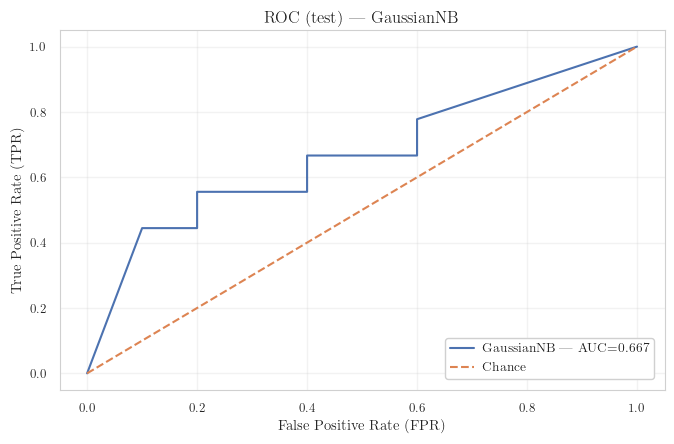

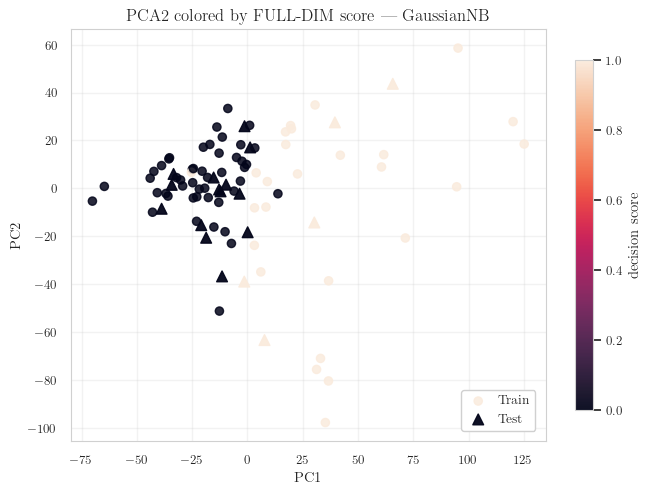

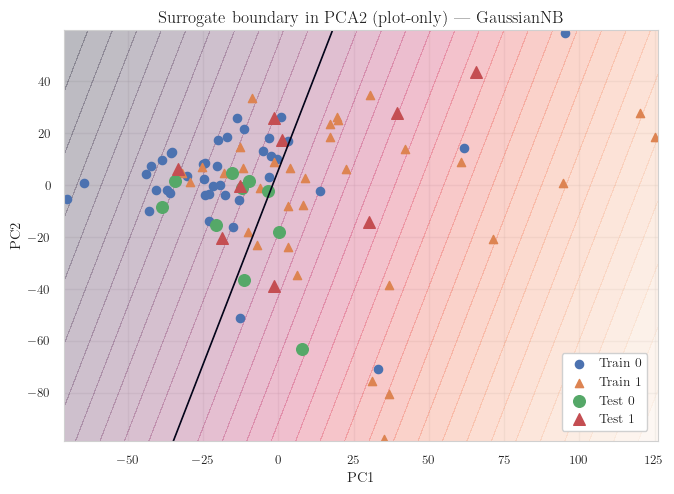


[GRID] KNN(grid k)
  best_params: {'knn__n_neighbors': 21}
  best_CV_AUC: 0.8152

[MODEL] All final pipeline parameters:
  knn: KNeighborsClassifier(n_neighbors=21)
  knn__algorithm: auto
  knn__leaf_size: 30
  knn__metric: minkowski
  knn__metric_params: None
  knn__n_jobs: None
  knn__n_neighbors: 21
  knn__p: 2
  knn__weights: uniform
  memory: None
  scaler: StandardScaler()
  scaler__copy: True
  scaler__with_mean: True
  scaler__with_std: True
  steps: [('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=21))]
  transform_input: None
  verbose: False
  TEST AUC: 0.8000


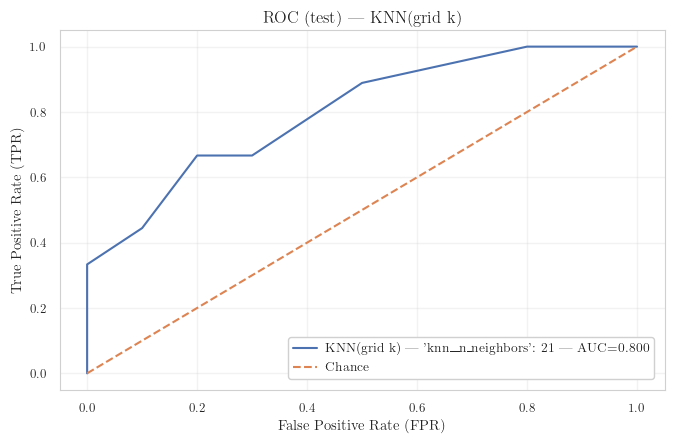

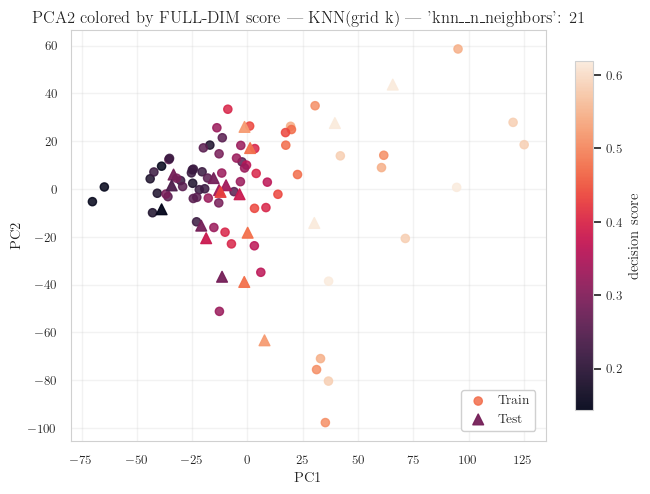

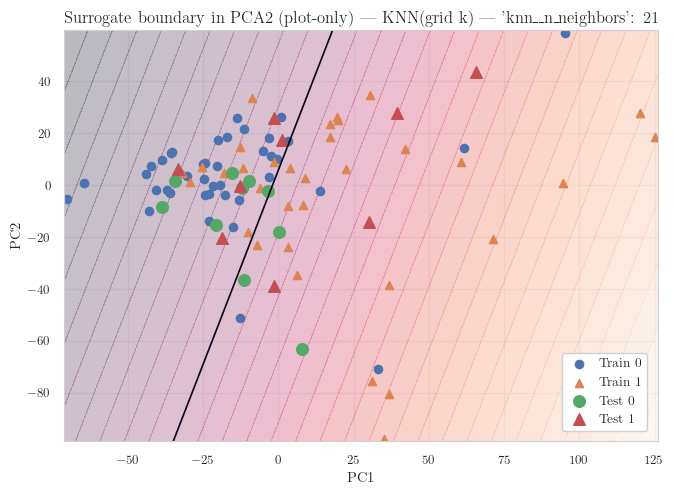


[GRID] RBF-SVC(grid C,gamma)
  best_params: {'rbf__C': 3.0, 'rbf__gamma': 'scale'}
  best_CV_AUC: 0.8817

[MODEL] All final pipeline parameters:
  memory: None
  rbf: SVC(C=3.0, class_weight='balanced', random_state=42)
  rbf__C: 3.0
  rbf__break_ties: False
  rbf__cache_size: 200
  rbf__class_weight: balanced
  rbf__coef0: 0.0
  rbf__decision_function_shape: ovr
  rbf__degree: 3
  rbf__gamma: scale
  rbf__kernel: rbf
  rbf__max_iter: -1
  rbf__probability: False
  rbf__random_state: 42
  rbf__shrinking: True
  rbf__tol: 0.001
  rbf__verbose: False
  scaler: StandardScaler()
  scaler__copy: True
  scaler__with_mean: True
  scaler__with_std: True
  steps: [('scaler', StandardScaler()), ('rbf', SVC(C=3.0, class_weight='balanced', random_state=42))]
  transform_input: None
  verbose: False
  TEST AUC: 0.6778


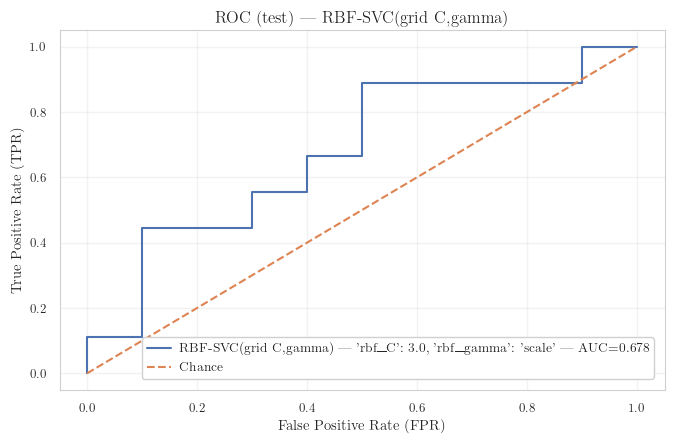

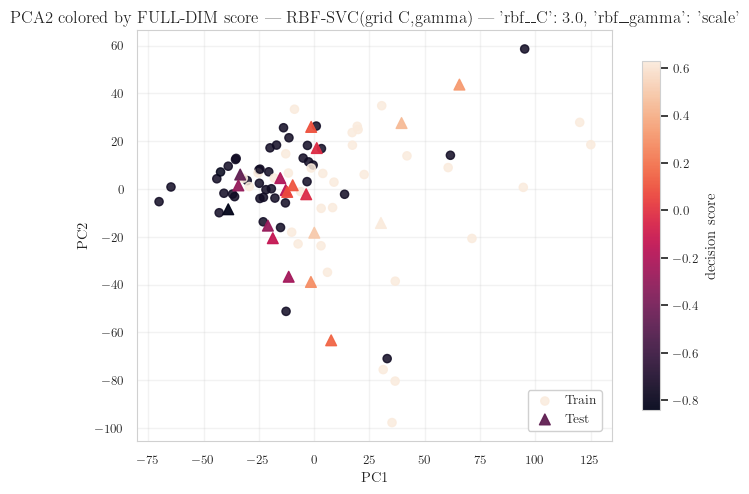

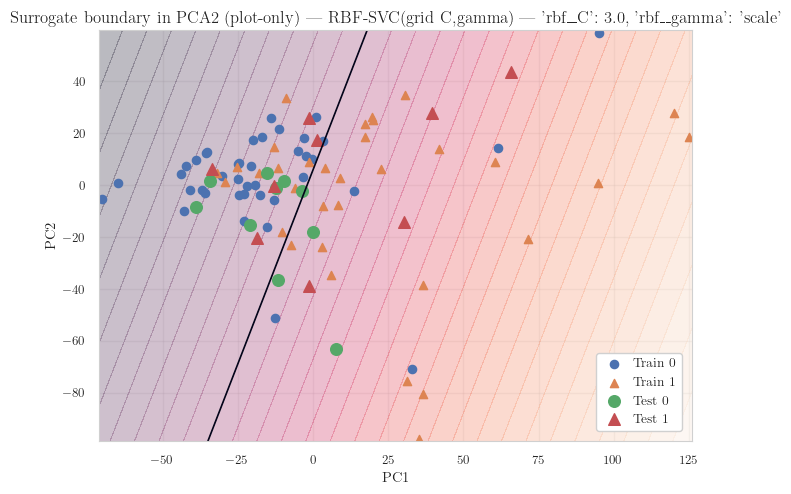


------------------------------------------------------------------------------------------
SUMMARY (sorted by TEST AUC):
0.8000  |  KNN(grid k)
0.6778  |  RBF-SVC(grid C,gamma)
0.6667  |  GaussianNB
0.6444  |  LinearSVC(grid C)
0.6333  |  LogReg L2 (grid C)
0.6222  |  Ridge (grid alpha)
0.6222  |  LDA(shrinkage=auto)
------------------------------------------------------------------------------------------


In [44]:
# ============================================================
# FULL-DIM MODEL ZOO + PCA VISUALIZATION (train-only PCA)
#   - Train/evaluate models on FULL feature space (X_train)
#   - PCA is used ONLY for visualization
#   - Optional PCA2 surrogate boundary (plot-only) per model
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

# -----------------------------
# CONFIG
# -----------------------------
RANDOM_STATE = globals().get("RANDOM_STATE", 42)

CV_SPLITS  = globals().get("CV_SPLITS", 5)
CV_REPEATS = globals().get("CV_REPEATS", 10)

# grids (keep modest to avoid overfitting tuning on small-n)
SVM_C_GRID = globals().get("SVM_C_GRID", [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0, 3.0, 10.0])
LOGREG_C_GRID = globals().get("LOGREG_C_GRID", [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0, 3.0, 10.0])
RIDGE_ALPHA_GRID = globals().get("RIDGE_ALPHA_GRID", [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0, 3.0, 10.0])

KNN_K_GRID = globals().get("KNN_K_GRID", [3, 5, 7, 9, 11, 15, 21])

RBF_C_GRID = globals().get("RBF_C_GRID", [0.1, 0.3, 1.0, 3.0, 10.0])
RBF_GAMMA_GRID = globals().get("RBF_GAMMA_GRID", ["scale", 0.001, 0.01, 0.1, 1.0])

SVM_MAX_ITER = globals().get("SVM_MAX_ITER", 20000)
LOGREG_MAX_ITER = globals().get("LOGREG_MAX_ITER", 10000)

# Visualization
SHOW_SURROGATE_BOUNDARY = True    # boundary in PCA2 is plot-only surrogate
MESH_N = 220                      # reduce to 150 if you want faster

# -----------------------------
# Helpers
# -----------------------------
def decision_score(model, X):
    """Get continuous score for AUC/ROC (prefers decision_function)."""
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        return np.asarray(s).ravel()
    if hasattr(model, "predict_proba"):
        p = model.predict_proba(X)[:, 1]
        return np.asarray(p).ravel()
    # fallback
    return model.predict(X).astype(float)

def fit_grid(name, base_estimator, param_grid, cv, Xtr, ytr):
    gs = GridSearchCV(base_estimator, param_grid, cv=cv, scoring="roc_auc", refit=True, n_jobs=-1)
    gs.fit(Xtr, ytr)
    best = gs.best_estimator_
    print(f"\n[GRID] {name}")
    print("  best_params:", gs.best_params_)
    print(f"  best_CV_AUC: {gs.best_score_:.4f}")
    return best, gs

def plot_pca_views(model_full, model_name, Xtr, ytr, Xte, yte, *, mesh_n=MESH_N, show_boundary=True):
    # PCA train-only on scaled space for visualization
    scaler_vis = StandardScaler()
    Xtr_s = scaler_vis.fit_transform(Xtr)
    Xte_s = scaler_vis.transform(Xte)

    pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
    Ztr = pca2.fit_transform(Xtr_s)
    Zte = pca2.transform(Xte_s)

    # FULL-DIM scores used for coloring
    s_tr = decision_score(model_full, Xtr)
    s_te = decision_score(model_full, Xte)

    # Scatter colored by full model score
    fig, ax = plt.subplots(figsize=(6.8, 5.0))
    sc1 = ax.scatter(Ztr[:, 0], Ztr[:, 1], c=s_tr, s=35, marker="o", alpha=0.85, label="Train")
    sc2 = ax.scatter(Zte[:, 0], Zte[:, 1], c=s_te, s=60, marker="^", alpha=0.95, label="Test")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"PCA2 colored by FULL-DIM score | {model_name}")
    ax.legend()
    fig.colorbar(sc2, ax=ax, shrink=0.85, label="decision score")
    fig.tight_layout()
    plt.show()

    if not show_boundary:
        return

    # Surrogate boundary on PCA2 (plot-only)
    # Use a simple surrogate that supports decision_function/proba
    surrogate = LogisticRegression(
        penalty="l2", solver="liblinear", C=1.0, class_weight="balanced",
        max_iter=LOGREG_MAX_ITER, random_state=RANDOM_STATE
    )
    surrogate.fit(Ztr, ytr)

    x_min, x_max = Ztr[:, 0].min() - 1.0, Ztr[:, 0].max() + 1.0
    y_min, y_max = Ztr[:, 1].min() - 1.0, Ztr[:, 1].max() + 1.0
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, mesh_n),
                         np.linspace(y_min, y_max, mesh_n))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = decision_score(surrogate, grid).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(6.8, 5.0))
    ax.contourf(xx, yy, zz, levels=30, alpha=0.28)
    ax.contour(xx, yy, zz, levels=[0.0], linewidths=1.2)

    ax.scatter(Ztr[ytr == 0, 0], Ztr[ytr == 0, 1], s=35, marker="o", label="Train 0")
    ax.scatter(Ztr[ytr == 1, 0], Ztr[ytr == 1, 1], s=35, marker="^", label="Train 1")
    ax.scatter(Zte[yte == 0, 0], Zte[yte == 0, 1], s=70, marker="o", label="Test 0")
    ax.scatter(Zte[yte == 1, 0], Zte[yte == 1, 1], s=70, marker="^", label="Test 1")

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"Surrogate boundary in PCA2 (plot-only) | {model_name}")
    ax.legend()
    fig.tight_layout()
    plt.show()

# -----------------------------
# CV object
# -----------------------------
cv = RepeatedStratifiedKFold(n_splits=CV_SPLITS, n_repeats=CV_REPEATS, random_state=RANDOM_STATE)

# -----------------------------
# Define model zoo (FULL-DIM)
# -----------------------------
# IMPORTANT: all models use scaling where appropriate (SVM, LR, KNN, RBF).
# NB and LDA can work without scaling, but scaling is fine and consistent.

zoo = []

# 1) Linear SVM (grid C)
svm_base = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(class_weight="balanced", max_iter=SVM_MAX_ITER, random_state=RANDOM_STATE, dual=False)),
])
zoo.append(("LinearSVC(grid C)", svm_base, {"svm__C": SVM_C_GRID}, True))

# 2) Logistic Regression L2 (grid C)
lr_base = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        penalty="l2", solver="liblinear", class_weight="balanced",
        max_iter=LOGREG_MAX_ITER, random_state=RANDOM_STATE
    )),
])
zoo.append(("LogReg L2 (grid C)", lr_base, {"lr__C": LOGREG_C_GRID}, True))

# 3) RidgeClassifier (grid alpha)
ridge_base = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
])
zoo.append(("Ridge (grid alpha)", ridge_base, {"ridge__alpha": RIDGE_ALPHA_GRID}, True))

# 4) LDA shrinkage (no grid needed)
lda = Pipeline([
    ("scaler", StandardScaler()),  # optional; keep consistent
    ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
])
zoo.append(("LDA(shrinkage=auto)", lda, None, True))

# 5) GaussianNB (no grid)
gnb = Pipeline([
    ("scaler", StandardScaler()),  # optional; fine
    ("gnb", GaussianNB()),
])
zoo.append(("GaussianNB", gnb, None, True))

# 6) KNN (grid k)
knn_base = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier()),
])
zoo.append(("KNN(grid k)", knn_base, {"knn__n_neighbors": KNN_K_GRID}, True))

# 7) RBF SVC (grid C,gamma) — keep modest grid
rbf_base = Pipeline([
    ("scaler", StandardScaler()),
    ("rbf", SVC(kernel="rbf", class_weight="balanced", probability=False, random_state=RANDOM_STATE)),
])
zoo.append(("RBF-SVC(grid C,gamma)", rbf_base, {"rbf__C": RBF_C_GRID, "rbf__gamma": RBF_GAMMA_GRID}, True))

# -----------------------------
# Run all models: FULL-DIM train/eval + PCA visualization
# -----------------------------
results = []

print("\n" + "=" * 90)
print(f"MODEL ZOO (full-dim training) | K={X_train.shape[1]:,} | n_train={X_train.shape[0]} | n_test={X_test.shape[0]}")
print("=" * 90)

for name, est, grid, do_pca in zoo:
    if grid is not None:
        best_model, gs = fit_grid(name, est, grid, cv, X_train, y_train)
        model_name = f"{name} | {gs.best_params_}"
        print("\n[MODEL] All final pipeline parameters:")
        all_params = best_model.get_params(deep=True)
        for k in sorted(all_params.keys()):
            print(f"  {k}: {all_params[k]}")
    else:
        best_model = est
        best_model.fit(X_train, y_train)
        model_name = name
        print("\n[MODEL] All final pipeline parameters:")
        all_params = best_model.get_params(deep=True)
        for k in sorted(all_params.keys()):
            print(f"  {k}: {all_params[k]}")
        print(f"\n[FIT] {name} (no grid)")

    # FULL-DIM test metrics (AUC)
    s_te = decision_score(best_model, X_test)
    auc_te = roc_auc_score(y_test, s_te)
    fpr, tpr, _ = roc_curve(y_test, s_te)

    print(f"  TEST AUC: {auc_te:.4f}")

    # ROC plot
    fig, ax = plt.subplots(figsize=(6.8, 4.5))
    ax.plot(fpr, tpr, label=f"{model_name} | AUC={auc_te:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", label="Chance")
    ax.set_xlabel("False Positive Rate (FPR)")
    ax.set_ylabel("True Positive Rate (TPR)")
    ax.set_title(f"ROC (test) — {name}")
    ax.legend()
    fig.tight_layout()
    plt.show()

    # PCA visualization + surrogate boundary (plot-only)
    if do_pca:
        plot_pca_views(best_model, model_name, X_train, y_train, X_test, y_test,
                       mesh_n=MESH_N, show_boundary=SHOW_SURROGATE_BOUNDARY)

    results.append((name, auc_te))

# Summary
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)
print("\n" + "-" * 90)
print("SUMMARY (sorted by TEST AUC):")
for name, auc_te in results_sorted:
    print(f"{auc_te:.4f}  |  {name}")
print("-" * 90)

In [43]:
# ============================================================
# KNN FULL-DIM GRID SEARCH (robust version)
# ============================================================

import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score

# -----------------------------
# CONFIG
# -----------------------------
RANDOM_STATE = globals().get("RANDOM_STATE", 42)
CV_SPLITS  = globals().get("CV_SPLITS", 5)
CV_REPEATS = globals().get("CV_REPEATS", 10)

# sensible grid for small-n high-p
KNN_K_GRID = globals().get("KNN_K_GRID", [3,5,7,9,11,15,21])
KNN_WEIGHTS = ["uniform", "distance"]
KNN_METRICS = ["minkowski", "cosine"]
KNN_P = [1, 2]   # only used if metric="minkowski"

print("\n" + "="*90)
print("KNN GRID SEARCH (FULL-DIM)")
print("="*90)
print(f"K = {X_train.shape[1]:,} | n_train = {X_train.shape[0]} | n_test = {X_test.shape[0]}")

# -----------------------------
# Pipeline
# -----------------------------
knn_base = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": KNN_K_GRID,
    "knn__weights": KNN_WEIGHTS,
    "knn__metric": KNN_METRICS,
    "knn__p": KNN_P,   # ignored if metric != minkowski
}

cv = RepeatedStratifiedKFold(
    n_splits=CV_SPLITS,
    n_repeats=CV_REPEATS,
    random_state=RANDOM_STATE
)

gs = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    refit=True,
    n_jobs=-1
)

gs.fit(X_train, y_train)

best_model = gs.best_estimator_

# -----------------------------
# Best CV results
# -----------------------------
print("\n[GRID] Best params:")
for k, v in gs.best_params_.items():
    print(f"  {k}: {v}")

print(f"[GRID] Best CV AUC: {gs.best_score_:.4f}")

# -----------------------------
# Top 10 configs
# -----------------------------
res = gs.cv_results_
order = np.argsort(res["mean_test_score"])[::-1]

print("\n[GRID] Top-10 configs by mean CV AUC:")
for i in order[:10]:
    params = res["params"][i]
    mean = res["mean_test_score"][i]
    std  = res["std_test_score"][i]
    print(f"  mean={mean:.4f} ± {std:.4f} | {params}")

# -----------------------------
# Test performance (FULL-DIM)
# -----------------------------
if hasattr(best_model, "predict_proba"):
    score_test = best_model.predict_proba(X_test)[:, 1]
else:
    score_test = best_model.predict(X_test).astype(float)

auc_test = roc_auc_score(y_test, score_test)
print(f"\n[TEST] AUC = {auc_test:.4f}")

# -----------------------------
# Print ALL final hyperparameters
# -----------------------------
print("\n[MODEL] All final pipeline parameters:")
all_params = best_model.get_params(deep=True)
for k in sorted(all_params.keys()):
    print(f"  {k}: {all_params[k]}")

print("\nDone.")


KNN GRID SEARCH (FULL-DIM)
K = 5,000 | n_train = 73 | n_test = 19

[GRID] Best params:
  knn__metric: cosine
  knn__n_neighbors: 15
  knn__p: 1
  knn__weights: distance
[GRID] Best CV AUC: 0.8412

[GRID] Top-10 configs by mean CV AUC:
  mean=0.8412 ± 0.1027 | {'knn__metric': 'cosine', 'knn__n_neighbors': 15, 'knn__p': 1, 'knn__weights': 'distance'}
  mean=0.8412 ± 0.1027 | {'knn__metric': 'cosine', 'knn__n_neighbors': 15, 'knn__p': 2, 'knn__weights': 'distance'}
  mean=0.8357 ± 0.0965 | {'knn__metric': 'cosine', 'knn__n_neighbors': 21, 'knn__p': 2, 'knn__weights': 'distance'}
  mean=0.8357 ± 0.0965 | {'knn__metric': 'cosine', 'knn__n_neighbors': 21, 'knn__p': 1, 'knn__weights': 'distance'}
  mean=0.8345 ± 0.0945 | {'knn__metric': 'minkowski', 'knn__n_neighbors': 21, 'knn__p': 2, 'knn__weights': 'distance'}
  mean=0.8305 ± 0.1063 | {'knn__metric': 'cosine', 'knn__n_neighbors': 15, 'knn__p': 2, 'knn__weights': 'uniform'}
  mean=0.8305 ± 0.1063 | {'knn__metric': 'cosine', 'knn__n_neighbo

In [45]:
# ============================================================
# KNN FULL-DIM GRID SEARCH (ALL hyperparams you listed) + SAVE BEST MODEL
#   - Uses RepeatedStratifiedKFold CV
#   - Grid includes: n_neighbors, weights, metric, p
#   - Uses *separated* param grids for minkowski vs cosine (correct handling of p)
#   - Prints: best params, best CV AUC, top-10 configs, TEST AUC, ALL final params
#   - Saves best_model to disk so you can reuse it on other datasets
# ============================================================

import numpy as np
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score

# -----------------------------
# CONFIG
# -----------------------------
RANDOM_STATE = globals().get("RANDOM_STATE", 42)
CV_SPLITS  = globals().get("CV_SPLITS", 5)
CV_REPEATS = globals().get("CV_REPEATS", 10)

# hyperparams you gave before
KNN_K_GRID  = globals().get("KNN_K_GRID",  [3, 5, 7, 9, 11, 15, 21])
KNN_WEIGHTS = globals().get("KNN_WEIGHTS", ["uniform", "distance"])
KNN_METRICS = globals().get("KNN_METRICS", ["minkowski", "cosine"])
KNN_P       = globals().get("KNN_P",       [1, 2])  # only meaningful for minkowski

# where to save
OUTDIR = globals().get("OUTDIR", None)  # if you already have OUTDIR Path
MODEL_SAVE_PATH = None
if OUTDIR is not None:
    try:
        MODEL_SAVE_PATH = str(OUTDIR / "best_knn_full_dim.joblib")
    except Exception:
        MODEL_SAVE_PATH = "best_knn_full_dim.joblib"
else:
    MODEL_SAVE_PATH = "best_knn_full_dim.joblib"

print("\n" + "=" * 90)
print("KNN GRID SEARCH (FULL-DIM) — ALL given hyperparameters")
print("=" * 90)
print(f"K = {X_train.shape[1]:,} | n_train = {X_train.shape[0]} | n_test = {X_test.shape[0]}")
print(f"Save path: {MODEL_SAVE_PATH}")

# -----------------------------
# Pipeline
# -----------------------------
knn_base = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# -----------------------------
# Param grid (correctly split minkowski vs cosine)
#   This guarantees the "default-like" config can be selected:
#     weights=uniform, metric=minkowski, p=2, n_neighbors=21
# -----------------------------
param_grid = [
    {
        "knn__n_neighbors": KNN_K_GRID,
        "knn__weights": KNN_WEIGHTS,
        "knn__metric": ["minkowski"],
        "knn__p": KNN_P,
    },
    {
        "knn__n_neighbors": KNN_K_GRID,
        "knn__weights": KNN_WEIGHTS,
        "knn__metric": ["cosine"],
        # no p here (not applicable)
    }
]

cv = RepeatedStratifiedKFold(
    n_splits=CV_SPLITS,
    n_repeats=CV_REPEATS,
    random_state=RANDOM_STATE
)

gs = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    refit=True,
    n_jobs=-1,
    return_train_score=False
)

gs.fit(X_train, y_train)

best_model = gs.best_estimator_

# -----------------------------
# Best CV results
# -----------------------------
print("\n[GRID] Best params:")
for k, v in gs.best_params_.items():
    print(f"  {k}: {v}")
print(f"[GRID] Best CV AUC: {gs.best_score_:.4f}")

# -----------------------------
# Top-10 configs
# -----------------------------
res = gs.cv_results_
order = np.argsort(res["mean_test_score"])[::-1]

print("\n[GRID] Top-10 configs by mean CV AUC:")
for i in order[:10]:
    params = res["params"][i]
    mean = res["mean_test_score"][i]
    std  = res["std_test_score"][i]
    print(f"  mean={mean:.4f} ± {std:.4f} | {params}")

# -----------------------------
# Test performance (FULL-DIM)
# -----------------------------
# KNN supports predict_proba by default.
score_test = best_model.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, score_test)
print(f"\n[TEST] AUC = {auc_test:.4f}")

# -----------------------------
# Print ALL final hyperparameters
# -----------------------------
print("\n[MODEL] All final pipeline parameters:")
all_params = best_model.get_params(deep=True)
for k in sorted(all_params.keys()):
    print(f"  {k}: {all_params[k]}")

# -----------------------------
# Save best model for reuse on other datasets
# -----------------------------
joblib.dump(best_model, MODEL_SAVE_PATH)
print(f"\nSaved best_model to: {MODEL_SAVE_PATH}")

# Keep in memory too
BEST_KNN_MODEL = best_model
print("\nAlso available as variable: BEST_KNN_MODEL")
print("\nDone.")


KNN GRID SEARCH (FULL-DIM) — ALL given hyperparameters
K = 5,000 | n_train = 73 | n_test = 19
Save path: fs_outputs/best_knn_full_dim.joblib

[GRID] Best params:
  knn__metric: cosine
  knn__n_neighbors: 15
  knn__weights: distance
[GRID] Best CV AUC: 0.8412

[GRID] Top-10 configs by mean CV AUC:
  mean=0.8412 ± 0.1027 | {'knn__metric': 'cosine', 'knn__n_neighbors': 15, 'knn__weights': 'distance'}
  mean=0.8357 ± 0.0965 | {'knn__metric': 'cosine', 'knn__n_neighbors': 21, 'knn__weights': 'distance'}
  mean=0.8345 ± 0.0945 | {'knn__metric': 'minkowski', 'knn__n_neighbors': 21, 'knn__p': 2, 'knn__weights': 'distance'}
  mean=0.8305 ± 0.1063 | {'knn__metric': 'cosine', 'knn__n_neighbors': 15, 'knn__weights': 'uniform'}
  mean=0.8301 ± 0.0982 | {'knn__metric': 'cosine', 'knn__n_neighbors': 11, 'knn__weights': 'distance'}
  mean=0.8284 ± 0.0945 | {'knn__metric': 'minkowski', 'knn__n_neighbors': 5, 'knn__p': 2, 'knn__weights': 'distance'}
  mean=0.8280 ± 0.0979 | {'knn__metric': 'cosine', 'k

In [46]:
# ============================================================
# TRAIN KNN with fixed hyperparameters (your chosen config)
#   - scaler + KNN(n_neighbors=21, weights=uniform, metric=minkowski, p=2)
#   - fits on X_train/y_train
#   - evaluates on X_test/y_test
#   - prints ALL hyperparameters
#   - saves model for reuse on other datasets
# ============================================================

import numpy as np
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score

print("\n" + "="*90)
print("TRAIN FIXED KNN (k=21, uniform, minkowski p=2) — FULL-DIM")
print("="*90)
print(f"K = {X_train.shape[1]:,} | n_train = {X_train.shape[0]} | n_test = {X_test.shape[0]}")

# Fixed hyperparameters (as you requested)
knn_fixed = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("knn", KNeighborsClassifier(
        n_neighbors=21,
        weights="uniform",
        metric="minkowski",
        p=2,
        algorithm="auto",
        leaf_size=30,
        n_jobs=None
    ))
])

# Fit
knn_fixed.fit(X_train, y_train)

# Test AUC
score_test = knn_fixed.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, score_test)
print(f"\n[TEST] AUC = {auc_test:.4f}")

# Print ALL hyperparameters
print("\n[MODEL] All final pipeline parameters:")
all_params = knn_fixed.get_params(deep=True)
for k in sorted(all_params.keys()):
    print(f"  {k}: {all_params[k]}")

# Save
OUTDIR = globals().get("OUTDIR", None)
if OUTDIR is not None:
    try:
        save_path = OUTDIR / "knn_fixed_k21_uniform_minkowski_p2.joblib"
        save_path = str(save_path)
    except Exception:
        save_path = "knn_fixed_k21_uniform_minkowski_p2.joblib"
else:
    save_path = "knn_fixed_k21_uniform_minkowski_p2.joblib"

joblib.dump(knn_fixed, save_path)
print(f"\nSaved model to: {save_path}")

# Keep a handle for later reuse in-notebook
BEST_KNN_FIXED = knn_fixed
print("Model available as: BEST_KNN_FIXED")


TRAIN FIXED KNN (k=21, uniform, minkowski p=2) — FULL-DIM
K = 5,000 | n_train = 73 | n_test = 19

[TEST] AUC = 0.8000

[MODEL] All final pipeline parameters:
  knn: KNeighborsClassifier(n_neighbors=21)
  knn__algorithm: auto
  knn__leaf_size: 30
  knn__metric: minkowski
  knn__metric_params: None
  knn__n_jobs: None
  knn__n_neighbors: 21
  knn__p: 2
  knn__weights: uniform
  memory: None
  scaler: StandardScaler()
  scaler__copy: True
  scaler__with_mean: True
  scaler__with_std: True
  steps: [('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=21))]
  transform_input: None
  verbose: False

Saved model to: fs_outputs/knn_fixed_k21_uniform_minkowski_p2.joblib
Model available as: BEST_KNN_FIXED



------------------------------------------------------------------------------------------
CLASSIFIER_MODE = ridge_grid
------------------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.60661e-10): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.62913e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_u


[GRID] Best params:
  ridge__alpha: 0.0001
[GRID] Best CV AUC: 0.9064

[GRID] Top-10 configs by mean CV AUC:
  mean=0.9064 ± 0.0674 | {'ridge__alpha': 1.0}
  mean=0.9064 ± 0.0674 | {'ridge__alpha': 3.0}
  mean=0.9064 ± 0.0674 | {'ridge__alpha': 0.03}
  mean=0.9064 ± 0.0674 | {'ridge__alpha': 0.1}
  mean=0.9064 ± 0.0674 | {'ridge__alpha': 0.3}
  mean=0.9064 ± 0.0674 | {'ridge__alpha': 0.003}
  mean=0.9064 ± 0.0674 | {'ridge__alpha': 0.001}
  mean=0.9064 ± 0.0674 | {'ridge__alpha': 0.0003}
  mean=0.9064 ± 0.0674 | {'ridge__alpha': 0.01}
  mean=0.9064 ± 0.0674 | {'ridge__alpha': 0.0001}

[MODEL] All params (Pipeline.get_params):
  memory: None
  ridge: RidgeClassifier(alpha=0.0001, class_weight='balanced', random_state=42)
  ridge__alpha: 0.0001
  ridge__class_weight: balanced
  ridge__copy_X: True
  ridge__fit_intercept: True
  ridge__max_iter: None
  ridge__positive: False
  ridge__random_state: 42
  ridge__solver: auto
  ridge__tol: 0.0001
  scaler: StandardScaler()
  scaler__copy: Tr

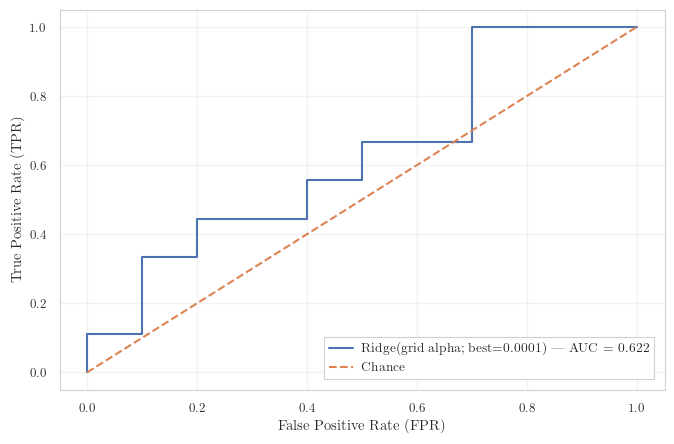


COEF CHECK:
best_coef shape = (5000,) | finite = True


In [39]:
# -----------------------------
# 2) CLASSIFIER (3 options) + METRICS + ROC PLOT
#   Modes:
#     - "svm_grid"     : LinearSVC + GridSearchCV(C) with RepeatedStratifiedKFold
#     - "logreg_l2_grid": LogisticRegression(L2) + GridSearchCV(C) with RepeatedStratifiedKFold
#     - "ridge_grid"   : RidgeClassifier + GridSearchCV(alpha) with RepeatedStratifiedKFold
#
#   Extras:
#     - prints best params + top-10 configs
#     - outputs coef aligned with X_train columns
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score, classification_report,
    average_precision_score, matthews_corrcoef, roc_curve
)

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV

# -----------------------------
# CONFIG (choose one)
# -----------------------------
# "svm_grid" | "logreg_l2_grid" | "ridge_grid"
CLASSIFIER_MODE = "ridge_grid"

RANDOM_STATE = globals().get("RANDOM_STATE", 42)

# CV (more stable for small-n)
CV_SPLITS  = globals().get("CV_SPLITS", 5)
CV_REPEATS = globals().get("CV_REPEATS", 10)

# SVM
SVM_MAX_ITER = globals().get("SVM_MAX_ITER", 20000)
SVM_C_GRID = globals().get(
    "SVM_C_GRID",
    [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0, 3.0, 10.0]
)

# LogReg L2
LOGREG_MAX_ITER = globals().get("LOGREG_MAX_ITER", 10000)
LOGREG_C_GRID = globals().get(
    "LOGREG_C_GRID",
    [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0, 3.0, 10.0]
)
# solver: liblinear is very stable for small-n binary
LOGREG_SOLVER = globals().get("LOGREG_SOLVER", "liblinear")

# Ridge
RIDGE_ALPHA_GRID = globals().get(
    "RIDGE_ALPHA_GRID",
    [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0, 3.0, 10.0]
)

print("\n" + "-" * 90)
print(f"CLASSIFIER_MODE = {CLASSIFIER_MODE}")
print("-" * 90)

# -----------------------------
# Helper: metrics + prints
# -----------------------------
def eval_and_print(y_true, score, pred, *, name="model"):
    auc  = roc_auc_score(y_true, score)
    bacc = balanced_accuracy_score(y_true, pred)
    cm   = confusion_matrix(y_true, pred, labels=[0, 1])

    precision = precision_score(y_true, pred, zero_division=0)
    recall    = recall_score(y_true, pred, zero_division=0)
    f1        = f1_score(y_true, pred, zero_division=0)
    pr_auc    = average_precision_score(y_true, score)
    mcc       = matthews_corrcoef(y_true, pred)

    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp + 1e-12)

    print(f"\nMETRICS (test) — {name}:")
    print(f"AUC         = {auc:.4f}")
    print(f"BAcc        = {bacc:.4f}")
    print(f"Precision   = {precision:.4f}")
    print(f"Recall      = {recall:.4f}")
    print(f"F1-score    = {f1:.4f}")
    print(f"PR-AUC      = {pr_auc:.4f}")
    print(f"Specificity = {specificity:.4f}")
    print(f"MCC         = {mcc:.4f}")

    print("\nConfusion matrix [labels 0,1]:")
    print(cm)

    print("\nClassification report:")
    print(classification_report(y_true, pred, digits=4, zero_division=0))

    out = {
        "auc": auc, "bacc": bacc, "precision": precision, "recall": recall, "f1": f1,
        "pr_auc": pr_auc, "specificity": specificity, "mcc": mcc, "cm": cm
    }
    return out

def get_linear_coef(pipe):
    """Return 1D coef vector aligned to X_train columns."""
    est = pipe.steps[-1][1]
    if not hasattr(est, "coef_"):
        return None
    c = np.asarray(est.coef_)
    if c.ndim == 2 and c.shape[0] == 1:
        c = c.ravel()
    elif c.ndim == 2 and c.shape[0] > 1:
        c = c.mean(axis=0)
    return c.astype(np.float64, copy=False)

def print_grid_summary(gs, top_k=10):
    print("\n[GRID] Best params:")
    for k, v in gs.best_params_.items():
        print(f"  {k}: {v}")
    print(f"[GRID] Best CV AUC: {gs.best_score_:.4f}")

    res = gs.cv_results_
    order = np.argsort(res["mean_test_score"])[::-1]
    print(f"\n[GRID] Top-{top_k} configs by mean CV AUC:")
    for i in order[:top_k]:
        params = res["params"][i]
        mean = res["mean_test_score"][i]
        std  = res["std_test_score"][i]
        print(f"  mean={mean:.4f} ± {std:.4f} | {params}")

# -----------------------------
# CV object
# -----------------------------
cv = RepeatedStratifiedKFold(
    n_splits=CV_SPLITS,
    n_repeats=CV_REPEATS,
    random_state=RANDOM_STATE
)

# -----------------------------
# Build + fit the chosen model
# -----------------------------
if CLASSIFIER_MODE == "svm_grid":
    base = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("svm", LinearSVC(
            class_weight="balanced",
            max_iter=SVM_MAX_ITER,
            random_state=RANDOM_STATE,
            dual=False,  # better when n_samples > n_features (often post-FS)
        )),
    ])
    param_grid = {"svm__C": list(SVM_C_GRID)}
    gs = GridSearchCV(base, param_grid, cv=cv, scoring="roc_auc", refit=True, n_jobs=-1)
    gs.fit(X_train, y_train)

    model_name = f"LinearSVC(grid C; best={gs.best_params_['svm__C']})"
    print_grid_summary(gs, top_k=10)

    clf = gs.best_estimator_
    print("\n[MODEL] All params (Pipeline.get_params):")
    all_params = clf.get_params(deep=True)
    for k in sorted(all_params.keys()):
        print(f"  {k}: {all_params[k]}")
    score = clf.decision_function(X_test)
    pred  = clf.predict(X_test)

elif CLASSIFIER_MODE == "logreg_l2_grid":
    base = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("lr", LogisticRegression(
            penalty="l2",
            solver=LOGREG_SOLVER,
            class_weight="balanced",
            max_iter=LOGREG_MAX_ITER,
            random_state=RANDOM_STATE
        )),
    ])
    param_grid = {"lr__C": list(LOGREG_C_GRID)}
    gs = GridSearchCV(base, param_grid, cv=cv, scoring="roc_auc", refit=True, n_jobs=-1)
    gs.fit(X_train, y_train)

    model_name = f"LogReg(L2 grid C; best={gs.best_params_['lr__C']})"
    print_grid_summary(gs, top_k=10)

    clf = gs.best_estimator_
    print("\n[MODEL] All params (Pipeline.get_params):")
    all_params = clf.get_params(deep=True)
    for k in sorted(all_params.keys()):
        print(f"  {k}: {all_params[k]}")
    score = clf.decision_function(X_test)
    pred  = clf.predict(X_test)

elif CLASSIFIER_MODE == "ridge_grid":
    # NOTE: RidgeClassifier uses alpha (regularization strength).
    # We still scale features for stability.
    base = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("ridge", RidgeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        )),
    ])
    param_grid = {"ridge__alpha": list(RIDGE_ALPHA_GRID)}
    gs = GridSearchCV(base, param_grid, cv=cv, scoring="roc_auc", refit=True, n_jobs=-1)
    gs.fit(X_train, y_train)

    model_name = f"Ridge(grid alpha; best={gs.best_params_['ridge__alpha']})"
    print_grid_summary(gs, top_k=10)

    clf = gs.best_estimator_
    print("\n[MODEL] All params (Pipeline.get_params):")
    all_params = clf.get_params(deep=True)
    for k in sorted(all_params.keys()):
        print(f"  {k}: {all_params[k]}")
    score = clf.decision_function(X_test)
    pred  = clf.predict(X_test)

else:
    raise ValueError("CLASSIFIER_MODE must be one of: 'svm_grid' | 'logreg_l2_grid' | 'ridge_grid'")

# -----------------------------
# Metrics
# -----------------------------
metrics = eval_and_print(y_test, score, pred, name=model_name)

# -----------------------------
# ROC plot (thesis style) + SAVE PDF
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, score)
auc = metrics["auc"]

apply_thesis_style(use_tex=True, legend_position="lower right", legend_outside=False)
fig_roc, ax = plt.subplots(figsize=(6.8, 4.5))

ax.plot(fpr, tpr, label=rf"{model_name} | AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", label="Chance")

ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")

print(f"\nROC — {model_name} on final FS CpGs (K={X_train.shape[1]:,}) | dataset={DATASET_NAME}")

place_legend(ax)
fig_roc.tight_layout()

pdf_path = OUTDIR / f"{DATASET_NAME}_{CLASSIFIER_MODE}_ROC_finalFS.pdf"
fig_roc.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

# -----------------------------
# Outputs you may reuse later
# -----------------------------
best_model = clf
best_name  = model_name
best_score = score
best_pred  = pred
best_coef  = get_linear_coef(clf)  # aligned with X_train columns (your final CpG order)

print("\nCOEF CHECK:")
if best_coef is None:
    print("WARNING: model has no coef_ (unexpected for these linear models).")
else:
    print(f"best_coef shape = {best_coef.shape} | finite = {np.isfinite(best_coef).all()}")
    


------------------------------------------------------------------------------------------
CLASSIFIER_MODE = logreg_l2_grid
------------------------------------------------------------------------------------------

[GRID] Best params:
  lr__C: 10.0
[GRID] Best CV AUC: 0.8929

[GRID] Top-10 configs by mean CV AUC:
  mean=0.8929 ± 0.0774 | {'lr__C': 10.0}
  mean=0.8920 ± 0.0793 | {'lr__C': 1.0}
  mean=0.8913 ± 0.0795 | {'lr__C': 0.3}
  mean=0.8912 ± 0.0792 | {'lr__C': 3.0}
  mean=0.8910 ± 0.0792 | {'lr__C': 0.1}
  mean=0.8905 ± 0.0805 | {'lr__C': 0.01}
  mean=0.8898 ± 0.0801 | {'lr__C': 0.03}
  mean=0.8876 ± 0.0838 | {'lr__C': 0.003}
  mean=0.8824 ± 0.0855 | {'lr__C': 0.001}
  mean=0.8666 ± 0.0874 | {'lr__C': 0.0003}

[MODEL] All params (Pipeline.get_params):
  lr: LogisticRegression(C=10.0, class_weight='balanced', max_iter=5000,
                   random_state=42, solver='liblinear')
  lr__C: 10.0
  lr__class_weight: balanced
  lr__dual: False
  lr__fit_intercept: True
  lr__intercep

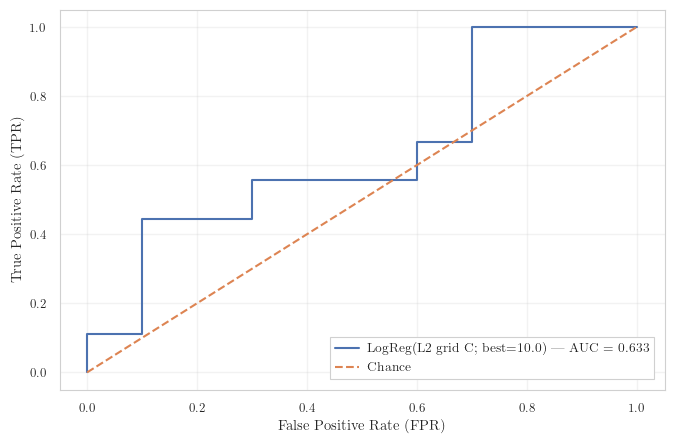


COEF CHECK:
best_coef shape = (5000,) | finite = True


In [40]:
# -----------------------------
# 2) CLASSIFIER (3 options) + METRICS + ROC PLOT
#   Modes:
#     - "svm_grid"     : LinearSVC + GridSearchCV(C) with RepeatedStratifiedKFold
#     - "logreg_l2_grid": LogisticRegression(L2) + GridSearchCV(C) with RepeatedStratifiedKFold
#     - "ridge_grid"   : RidgeClassifier + GridSearchCV(alpha) with RepeatedStratifiedKFold
#
#   Extras:
#     - prints best params + top-10 configs
#     - outputs coef aligned with X_train columns
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score, classification_report,
    average_precision_score, matthews_corrcoef, roc_curve
)

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV

# -----------------------------
# CONFIG (choose one)
# -----------------------------
# "svm_grid" | "logreg_l2_grid" | "ridge_grid"
CLASSIFIER_MODE = "logreg_l2_grid"

RANDOM_STATE = globals().get("RANDOM_STATE", 42)

# CV (more stable for small-n)
CV_SPLITS  = globals().get("CV_SPLITS", 5)
CV_REPEATS = globals().get("CV_REPEATS", 10)

# SVM
SVM_MAX_ITER = globals().get("SVM_MAX_ITER", 20000)
SVM_C_GRID = globals().get(
    "SVM_C_GRID",
    [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0, 3.0, 10.0]
)

# LogReg L2
LOGREG_MAX_ITER = globals().get("LOGREG_MAX_ITER", 10000)
LOGREG_C_GRID = globals().get(
    "LOGREG_C_GRID",
    [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0, 3.0, 10.0]
)
# solver: liblinear is very stable for small-n binary
LOGREG_SOLVER = globals().get("LOGREG_SOLVER", "liblinear")

# Ridge
RIDGE_ALPHA_GRID = globals().get(
    "RIDGE_ALPHA_GRID",
    [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0, 3.0, 10.0]
)

print("\n" + "-" * 90)
print(f"CLASSIFIER_MODE = {CLASSIFIER_MODE}")
print("-" * 90)

# -----------------------------
# Helper: metrics + prints
# -----------------------------
def eval_and_print(y_true, score, pred, *, name="model"):
    auc  = roc_auc_score(y_true, score)
    bacc = balanced_accuracy_score(y_true, pred)
    cm   = confusion_matrix(y_true, pred, labels=[0, 1])

    precision = precision_score(y_true, pred, zero_division=0)
    recall    = recall_score(y_true, pred, zero_division=0)
    f1        = f1_score(y_true, pred, zero_division=0)
    pr_auc    = average_precision_score(y_true, score)
    mcc       = matthews_corrcoef(y_true, pred)

    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp + 1e-12)

    print(f"\nMETRICS (test) — {name}:")
    print(f"AUC         = {auc:.4f}")
    print(f"BAcc        = {bacc:.4f}")
    print(f"Precision   = {precision:.4f}")
    print(f"Recall      = {recall:.4f}")
    print(f"F1-score    = {f1:.4f}")
    print(f"PR-AUC      = {pr_auc:.4f}")
    print(f"Specificity = {specificity:.4f}")
    print(f"MCC         = {mcc:.4f}")

    print("\nConfusion matrix [labels 0,1]:")
    print(cm)

    print("\nClassification report:")
    print(classification_report(y_true, pred, digits=4, zero_division=0))

    out = {
        "auc": auc, "bacc": bacc, "precision": precision, "recall": recall, "f1": f1,
        "pr_auc": pr_auc, "specificity": specificity, "mcc": mcc, "cm": cm
    }
    return out

def get_linear_coef(pipe):
    """Return 1D coef vector aligned to X_train columns."""
    est = pipe.steps[-1][1]
    if not hasattr(est, "coef_"):
        return None
    c = np.asarray(est.coef_)
    if c.ndim == 2 and c.shape[0] == 1:
        c = c.ravel()
    elif c.ndim == 2 and c.shape[0] > 1:
        c = c.mean(axis=0)
    return c.astype(np.float64, copy=False)

def print_grid_summary(gs, top_k=10):
    print("\n[GRID] Best params:")
    for k, v in gs.best_params_.items():
        print(f"  {k}: {v}")
    print(f"[GRID] Best CV AUC: {gs.best_score_:.4f}")

    res = gs.cv_results_
    order = np.argsort(res["mean_test_score"])[::-1]
    print(f"\n[GRID] Top-{top_k} configs by mean CV AUC:")
    for i in order[:top_k]:
        params = res["params"][i]
        mean = res["mean_test_score"][i]
        std  = res["std_test_score"][i]
        print(f"  mean={mean:.4f} ± {std:.4f} | {params}")

# -----------------------------
# CV object
# -----------------------------
cv = RepeatedStratifiedKFold(
    n_splits=CV_SPLITS,
    n_repeats=CV_REPEATS,
    random_state=RANDOM_STATE
)

# -----------------------------
# Build + fit the chosen model
# -----------------------------
if CLASSIFIER_MODE == "svm_grid":
    base = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("svm", LinearSVC(
            class_weight="balanced",
            max_iter=SVM_MAX_ITER,
            random_state=RANDOM_STATE,
            dual=False,  # better when n_samples > n_features (often post-FS)
        )),
    ])
    param_grid = {"svm__C": list(SVM_C_GRID)}
    gs = GridSearchCV(base, param_grid, cv=cv, scoring="roc_auc", refit=True, n_jobs=-1)
    gs.fit(X_train, y_train)

    model_name = f"LinearSVC(grid C; best={gs.best_params_['svm__C']})"
    print_grid_summary(gs, top_k=10)

    clf = gs.best_estimator_
    print("\n[MODEL] All params (Pipeline.get_params):")
    all_params = clf.get_params(deep=True)
    for k in sorted(all_params.keys()):
        print(f"  {k}: {all_params[k]}")
    score = clf.decision_function(X_test)
    pred  = clf.predict(X_test)

elif CLASSIFIER_MODE == "logreg_l2_grid":
    base = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("lr", LogisticRegression(
            penalty="l2",
            solver=LOGREG_SOLVER,
            class_weight="balanced",
            max_iter=LOGREG_MAX_ITER,
            random_state=RANDOM_STATE
        )),
    ])
    param_grid = {"lr__C": list(LOGREG_C_GRID)}
    gs = GridSearchCV(base, param_grid, cv=cv, scoring="roc_auc", refit=True, n_jobs=-1)
    gs.fit(X_train, y_train)

    model_name = f"LogReg(L2 grid C; best={gs.best_params_['lr__C']})"
    print_grid_summary(gs, top_k=10)

    clf = gs.best_estimator_
    print("\n[MODEL] All params (Pipeline.get_params):")
    all_params = clf.get_params(deep=True)
    for k in sorted(all_params.keys()):
        print(f"  {k}: {all_params[k]}")
    score = clf.decision_function(X_test)
    pred  = clf.predict(X_test)

elif CLASSIFIER_MODE == "ridge_grid":
    # NOTE: RidgeClassifier uses alpha (regularization strength).
    # We still scale features for stability.
    base = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("ridge", RidgeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        )),
    ])
    param_grid = {"ridge__alpha": list(RIDGE_ALPHA_GRID)}
    gs = GridSearchCV(base, param_grid, cv=cv, scoring="roc_auc", refit=True, n_jobs=-1)
    gs.fit(X_train, y_train)

    model_name = f"Ridge(grid alpha; best={gs.best_params_['ridge__alpha']})"
    print_grid_summary(gs, top_k=10)

    clf = gs.best_estimator_
    print("\n[MODEL] All params (Pipeline.get_params):")
    all_params = clf.get_params(deep=True)
    for k in sorted(all_params.keys()):
        print(f"  {k}: {all_params[k]}")
    score = clf.decision_function(X_test)
    pred  = clf.predict(X_test)

else:
    raise ValueError("CLASSIFIER_MODE must be one of: 'svm_grid' | 'logreg_l2_grid' | 'ridge_grid'")

# -----------------------------
# Metrics
# -----------------------------
metrics = eval_and_print(y_test, score, pred, name=model_name)

# -----------------------------
# ROC plot (thesis style) + SAVE PDF
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, score)
auc = metrics["auc"]

apply_thesis_style(use_tex=True, legend_position="lower right", legend_outside=False)
fig_roc, ax = plt.subplots(figsize=(6.8, 4.5))

ax.plot(fpr, tpr, label=rf"{model_name} | AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", label="Chance")

ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")

print(f"\nROC — {model_name} on final FS CpGs (K={X_train.shape[1]:,}) | dataset={DATASET_NAME}")

place_legend(ax)
fig_roc.tight_layout()

pdf_path = OUTDIR / f"{DATASET_NAME}_{CLASSIFIER_MODE}_ROC_finalFS.pdf"
fig_roc.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

# -----------------------------
# Outputs you may reuse later
# -----------------------------
best_model = clf
best_name  = model_name
best_score = score
best_pred  = pred
best_coef  = get_linear_coef(clf)  # aligned with X_train columns (your final CpG order)

print("\nCOEF CHECK:")
if best_coef is None:
    print("WARNING: model has no coef_ (unexpected for these linear models).")
else:
    print(f"best_coef shape = {best_coef.shape} | finite = {np.isfinite(best_coef).all()}")
    


------------------------------------------------------------------------------------------
CLASSIFIER_MODE = svm_grid
------------------------------------------------------------------------------------------
Best C: 1.0
Best CV AUC: 0.9035

METRICS (test) — LinearSVC(grid C; best=1.0):
AUC         = 0.6444
BAcc        = 0.5833
Precision   = 0.5455
Recall      = 0.6667
F1-score    = 0.6000
PR-AUC      = 0.6631
Specificity = 0.5000
MCC         = 0.1685

Confusion matrix [labels 0,1]:
[[5 5]
 [3 6]]

Classification report:
              precision    recall  f1-score   support

           0     0.6250    0.5000    0.5556        10
           1     0.5455    0.6667    0.6000         9

    accuracy                         0.5789        19
   macro avg     0.5852    0.5833    0.5778        19
weighted avg     0.5873    0.5789    0.5766        19


ROC — LinearSVC(grid C; best=1.0) on final FS CpGs (K=5,000) | dataset=GSE69914
Saved plot to: fs_outputs/GSE69914_svm_grid_ROC_finalFS.pdf


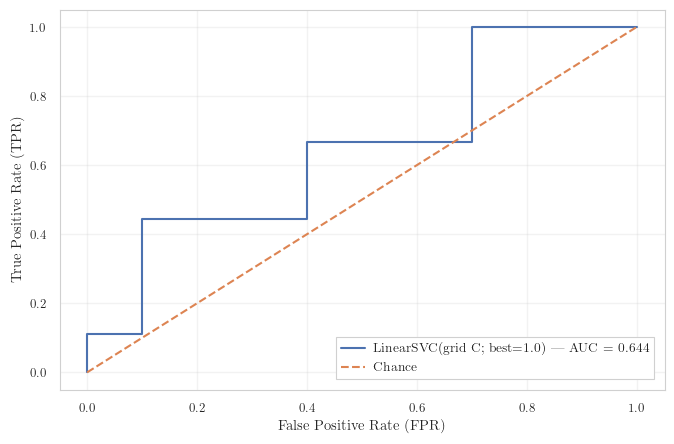


COEF CHECK:
best_coef shape = (5000,) | finite = True


In [35]:
# -----------------------------
# 2) CLASSIFIER (SVM) + METRICS + ROC PLOT  — MODDED for small-n (GSE69914)
#   Changes:
#   - RepeatedStratifiedKFold for more stable CV (reduces variance of best C)
#   - Expanded C grid (log-scale, includes smaller values)
#   - LinearSVC(dual=False) (better when n_samples > n_features; often true after FS)
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score, classification_report,
    average_precision_score, matthews_corrcoef, roc_curve
)

from sklearn.svm import LinearSVC
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV

# -----------------------------
# CONFIG
# -----------------------------
CLASSIFIER_MODE = "svm_grid"

RANDOM_STATE = globals().get("RANDOM_STATE", 42)
SVM_MAX_ITER = globals().get("SVM_MAX_ITER", 20000)

# Expanded grid (log-ish; includes smaller Cs since your bestC hit the minimum)
SVM_C_GRID = globals().get(
    "SVM_C_GRID",
    [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0, 3.0, 10.0]
)

# More stable CV for small-n
SVM_CV_SPLITS  = globals().get("SVM_CV_SPLITS", 5)
SVM_CV_REPEATS = globals().get("SVM_CV_REPEATS", 10)

print("\n" + "-" * 90)
print(f"CLASSIFIER_MODE = {CLASSIFIER_MODE}")
print("-" * 90)

# -----------------------------
# Helper: metrics + prints
# -----------------------------
def eval_and_print(y_true, score, pred, *, name="model"):
    auc  = roc_auc_score(y_true, score)
    bacc = balanced_accuracy_score(y_true, pred)
    cm   = confusion_matrix(y_true, pred, labels=[0, 1])

    precision = precision_score(y_true, pred, zero_division=0)
    recall    = recall_score(y_true, pred, zero_division=0)
    f1        = f1_score(y_true, pred, zero_division=0)
    pr_auc    = average_precision_score(y_true, score)
    mcc       = matthews_corrcoef(y_true, pred)

    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp + 1e-12)

    print(f"\nMETRICS (test) — {name}:")
    print(f"AUC         = {auc:.4f}")
    print(f"BAcc        = {bacc:.4f}")
    print(f"Precision   = {precision:.4f}")
    print(f"Recall      = {recall:.4f}")
    print(f"F1-score    = {f1:.4f}")
    print(f"PR-AUC      = {pr_auc:.4f}")
    print(f"Specificity = {specificity:.4f}")
    print(f"MCC         = {mcc:.4f}")

    print("\nConfusion matrix [labels 0,1]:")
    print(cm)

    print("\nClassification report:")
    print(classification_report(y_true, pred, digits=4, zero_division=0))

    out = {
        "auc": auc, "bacc": bacc, "precision": precision, "recall": recall, "f1": f1,
        "pr_auc": pr_auc, "specificity": specificity, "mcc": mcc, "cm": cm
    }
    return out

def get_linear_coef(pipe):
    est = pipe.steps[-1][1]
    if not hasattr(est, "coef_"):
        return None
    c = np.asarray(est.coef_)
    if c.ndim == 2 and c.shape[0] == 1:
        c = c.ravel()
    elif c.ndim == 2 and c.shape[0] > 1:
        c = c.mean(axis=0)
    return c.astype(np.float64, copy=False)

# -----------------------------
# SVM grid (MODDED)
# -----------------------------
base = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("svm", LinearSVC(
        class_weight="balanced",
        max_iter=SVM_MAX_ITER,
        random_state=RANDOM_STATE,
        dual=False,  # <-- key change for small feature sets
    )),
])

param_grid = {"svm__C": list(SVM_C_GRID)}

cv = RepeatedStratifiedKFold(
    n_splits=SVM_CV_SPLITS,
    n_repeats=SVM_CV_REPEATS,
    random_state=RANDOM_STATE
)

gs = GridSearchCV(
    estimator=base,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    refit=True,
    n_jobs=-1
)
gs.fit(X_train, y_train)

bestC = gs.best_params_["svm__C"]
model_name = f"LinearSVC(grid C; best={bestC})"
print(f"Best C: {bestC}")
print(f"Best CV AUC: {gs.best_score_:.4f}")

clf = gs.best_estimator_
score = clf.decision_function(X_test)
pred  = clf.predict(X_test)

# -----------------------------
# Metrics
# -----------------------------
metrics = eval_and_print(y_test, score, pred, name=model_name)

# -----------------------------
# ROC plot (thesis style) + SAVE PDF
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, score)
auc = metrics["auc"]

apply_thesis_style(use_tex=True, legend_position="lower right", legend_outside=False)
fig_roc, ax = plt.subplots(figsize=(6.8, 4.5))

ax.plot(fpr, tpr, label=rf"{model_name} | AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", label="Chance")

ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")

print(f"\nROC — {model_name} on final FS CpGs (K={X_train.shape[1]:,}) | dataset={DATASET_NAME}")

place_legend(ax)
fig_roc.tight_layout()

pdf_path = OUTDIR / f"{DATASET_NAME}_{CLASSIFIER_MODE}_ROC_finalFS.pdf"
fig_roc.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

# -----------------------------
# Outputs you may reuse later (knapsack-friendly)
# -----------------------------
best_model = clf
best_name  = model_name
best_score = score
best_pred  = pred
best_coef  = get_linear_coef(clf)  # aligned with X_train columns (i.e., final_cpg order)

print("\nCOEF CHECK:")
if best_coef is None:
    print("WARNING: model has no coef_ (unexpected).")
else:
    print(f"best_coef shape = {best_coef.shape} | finite = {np.isfinite(best_coef).all()}")

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
import numpy as np

def fit_ridge(alpha):
    m = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RidgeClassifier(alpha=alpha, class_weight="balanced", random_state=42)),
    ])
    m.fit(X_train, y_train)
    s = m.decision_function(X_test)
    p = m.predict(X_test)
    w = m.named_steps["clf"].coef_.ravel()
    b = m.named_steps["clf"].intercept_.item() if hasattr(m.named_steps["clf"], "intercept_") else np.nan
    return s, p, w, b

s1, p1, w1, b1 = fit_ridge(0.001)
s2, p2, w2, b2 = fit_ridge(100.0)

print("Same predictions?   ", np.array_equal(p1, p2))
print("Max |Δscore|        ", float(np.max(np.abs(s1 - s2))))
print("Corr(score1,score2) ", float(np.corrcoef(s1, s2)[0,1]))
print("Cosine(w1,w2)       ", float(np.dot(w1, w2) / (np.linalg.norm(w1)*np.linalg.norm(w2) + 1e-12)))

Same predictions?    True
Max |Δscore|         0.0011047720909118652
Corr(score1,score2)  0.9999997926991002
Cosine(w1,w2)        0.9999995827674866



------------------------------------------------------------------------------------------
RIDGE TUNING (alpha) — train-only CV
------------------------------------------------------------------------------------------
alpha grid: [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]
cv splits : 5


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.60661e-10): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.62913e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.16678e-10): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sk

Best alpha: 0.0001
Best CV AUC: 0.9030
Test AUC: 0.6222
Saved plot to: fs_outputs/GSE69914_ridge_alphaGrid_ROC_finalFS.pdf


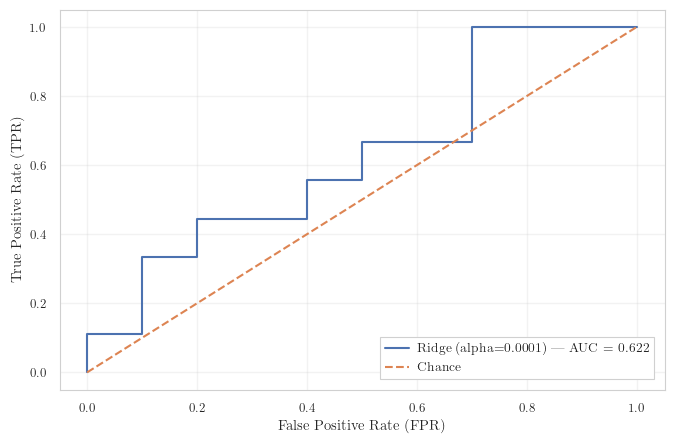

best_coef shape = (5000,)


In [34]:
# -----------------------------
# RIDGE — tuning alpha (train-only CV) + test metrics + ROC
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve

# ---- config
RIDGE_ALPHA_GRID = globals().get(
    "RIDGE_ALPHA_GRID",
    [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]
)
RIDGE_CV_SPLITS = globals().get("RIDGE_CV_SPLITS", 5)
RANDOM_STATE = globals().get("RANDOM_STATE", 42)

print("\n" + "-" * 90)
print("RIDGE TUNING (alpha) — train-only CV")
print("-" * 90)
print(f"alpha grid: {RIDGE_ALPHA_GRID}")
print(f"cv splits : {RIDGE_CV_SPLITS}")

# ---- base pipeline
ridge_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("clf", RidgeClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
])

# ---- CV
cv = StratifiedKFold(n_splits=RIDGE_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
gs = GridSearchCV(
    estimator=ridge_pipe,
    param_grid={"clf__alpha": list(RIDGE_ALPHA_GRID)},
    cv=cv,
    scoring="roc_auc",
    refit=True,
    n_jobs=-1
)

gs.fit(X_train, y_train)

best_alpha = gs.best_params_["clf__alpha"]
print(f"Best alpha: {best_alpha}")
print(f"Best CV AUC: {gs.best_score_:.4f}")

# ---- evaluate on test
ridge_best = gs.best_estimator_
score = ridge_best.decision_function(X_test)
pred  = ridge_best.predict(X_test)

auc_test = roc_auc_score(y_test, score)
print(f"Test AUC: {auc_test:.4f}")

# ---- ROC plot (reuse your thesis styling)
fpr, tpr, _ = roc_curve(y_test, score)
apply_thesis_style(use_tex=True, legend_position="lower right", legend_outside=False)
fig_roc, ax = plt.subplots(figsize=(6.8, 4.5))
ax.plot(fpr, tpr, label=rf"Ridge (alpha={best_alpha:g}) | AUC = {auc_test:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", label="Chance")
ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")
place_legend(ax)
fig_roc.tight_layout()

pdf_path = OUTDIR / f"{DATASET_NAME}_ridge_alphaGrid_ROC_finalFS.pdf"
fig_roc.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")
plt.show()

# ---- knapsack-friendly outputs
best_model = ridge_best
best_name  = f"Ridge(alpha={best_alpha:g})"
best_score = score
best_pred  = pred

# coef aligned with your X_train columns (final_cpgs order)
best_coef  = ridge_best.named_steps["clf"].coef_.ravel().astype(np.float64, copy=False)
print(f"best_coef shape = {best_coef.shape}")


SVM CHECK — final FS CpGs | train/test (no leakage) + ROC
SVM_C = 1.0
SVM_MAX_ITER = 10000
RANDOM_STATE = 42
Shapes: X_train=(73, 2000) | X_test=(19, 2000)
n_features (final) = 2,000

METRICS (test):
AUC         = 0.6556
BAcc        = 0.6278
Precision   = 0.6250
Recall      = 0.5556
F1-score    = 0.5882
PR-AUC      = 0.6227
Specificity = 0.7000
MCC         = 0.2584

Confusion matrix [labels 0,1]:
[[7 3]
 [4 5]]

Classification report:
              precision    recall  f1-score   support

           0     0.6364    0.7000    0.6667        10
           1     0.6250    0.5556    0.5882         9

    accuracy                         0.6316        19
   macro avg     0.6307    0.6278    0.6275        19
weighted avg     0.6310    0.6316    0.6295        19


ROC — Linear SVM on final FS CpGs (K=2,000) | dataset=GSE287331
Saved plot to: plots_outputs/GSE287331_svmcheck_ROC_finalFS.pdf


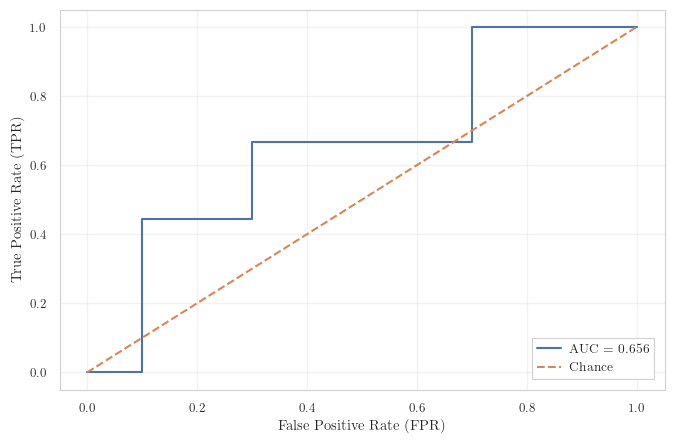

In [29]:
# =============================
# SVM CHECK — train/test on final FS CpGs + ROC plot (thesis style)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score, classification_report,
    average_precision_score, matthews_corrcoef, roc_curve
)

print("\n" + "=" * 90)
print("SVM CHECK — final FS CpGs | train/test (no leakage) + ROC")
print("=" * 90)

# -----------------------------
# REQUIRED INPUTS (must exist)
# -----------------------------
#   M_train, M_test               : post-Edgar + beta->M + (optional) variance filter
#   y_train, y_test
#   cpg_cols_current              : columns aligned to M_train/M_test
#   final_cpgs                    : final selected CpGs (e.g., K=5000) from your FS pipeline
#   SVM_C, SVM_MAX_ITER, RANDOM_STATE
#   apply_thesis_style, place_legend
#
# Optional:
#   DATASET_NAME (string) e.g. "GSE225845" for saving plots

DATASET_NAME = globals().get("DATASET_NAME", "GSE69914")  # set explicitly if you want
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Default hyperparameters (if not already defined)
# -----------------------------
SVM_C = globals().get("SVM_C", 1.0)
SVM_MAX_ITER = globals().get("SVM_MAX_ITER", 5000)
RANDOM_STATE = globals().get("RANDOM_STATE", 42)

print(f"SVM_C = {SVM_C}")
print(f"SVM_MAX_ITER = {SVM_MAX_ITER}")
print(f"RANDOM_STATE = {RANDOM_STATE}")

SVM_C = 0.5   # più regolarizzazione → meno overfitting
SVM_MAX_ITER = 10000
RANDOM_STATE = 42


# -----------------------------
# 1) Build matrices on final CpGs (aligned with current M space)
# -----------------------------
if "M_train" not in globals() or "M_test" not in globals():
    raise NameError("Missing M_train/M_test. Use the matrices produced by STEP 2 (post-Edgar + M-transform).")

cols_all = np.array(cpg_cols_current, dtype=object)
col_to_j = {c: j for j, c in enumerate(cols_all)}

final_cpgs = np.array(final_cpgs, dtype=object)
jj = np.array([col_to_j[c] for c in final_cpgs if c in col_to_j], dtype=int)

if jj.size == 0:
    raise RuntimeError("No final_cpgs found in cpg_cols_current. Check alignment / filtering masks.")

if jj.size != final_cpgs.size:
    missing = [c for c in final_cpgs.tolist() if c not in col_to_j]
    print(f"WARNING: {len(missing)} CpGs missing from current columns. Using {jj.size}/{final_cpgs.size}.")
    final_cpgs = np.array([c for c in final_cpgs.tolist() if c in col_to_j], dtype=object)

X_train = M_train[:, jj].astype(np.float32, copy=False)
X_test  = M_test[:,  jj].astype(np.float32, copy=False)

print(f"Shapes: X_train={X_train.shape} | X_test={X_test.shape}")
print(f"n_features (final) = {X_train.shape[1]:,}")

# -----------------------------
# 2) Linear SVM on M
# -----------------------------
svm = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("svm", LinearSVC(C=SVM_C, class_weight="balanced", max_iter=SVM_MAX_ITER, random_state=RANDOM_STATE)),
])

svm.fit(X_train, y_train)

score = svm.decision_function(X_test)
pred  = svm.predict(X_test)

auc  = roc_auc_score(y_test, score)
bacc = balanced_accuracy_score(y_test, pred)
cm   = confusion_matrix(y_test, pred, labels=[0, 1])

precision = precision_score(y_test, pred, zero_division=0)
recall    = recall_score(y_test, pred, zero_division=0)
f1        = f1_score(y_test, pred, zero_division=0)
pr_auc    = average_precision_score(y_test, score)
mcc       = matthews_corrcoef(y_test, pred)

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp + 1e-12)

print("\nMETRICS (test):")
print(f"AUC         = {auc:.4f}")
print(f"BAcc        = {bacc:.4f}")
print(f"Precision   = {precision:.4f}")
print(f"Recall      = {recall:.4f}")
print(f"F1-score    = {f1:.4f}")
print(f"PR-AUC      = {pr_auc:.4f}")
print(f"Specificity = {specificity:.4f}")
print(f"MCC         = {mcc:.4f}")

print("\nConfusion matrix [labels 0,1]:")
print(cm)

print("\nClassification report:")
print(classification_report(y_test, pred, digits=4, zero_division=0))

# -----------------------------
# 3) ROC plot (thesis style) + SAVE PDF
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, score)

apply_thesis_style(use_tex=True, legend_position="lower right", legend_outside=False)
fig_roc, ax = plt.subplots(figsize=(6.8, 4.5))

ax.plot(fpr, tpr, label=rf"AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", label="Chance")

ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")

# no plot title (print to screen instead)
print(f"\nROC — Linear SVM on final FS CpGs (K={X_train.shape[1]:,}) | dataset={DATASET_NAME}")

place_legend(ax)
fig_roc.tight_layout()

pdf_path = OUTDIR / f"{DATASET_NAME}_svmcheck_ROC_finalFS.pdf"
fig_roc.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

# Outputs you may reuse later:
#   svm, fig_roc, score, pred, (auc, bacc, precision, recall, f1, pr_auc, specificity, mcc), cm



FIG — PCA boundary with calibrated probability (train-only fit)

Dataset: GSE69914
SVM_C=0.5 | SVM_MAX_ITER=10000 | RANDOM_STATE=42
Saved plot to: plots_outputs/GSE69914_boundary_pca_prob_calibrated.pdf


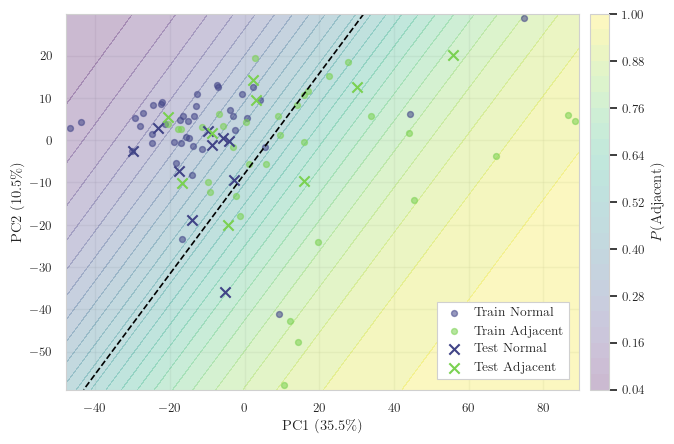

SVM boundary in PCA space | AUC=0.656


In [30]:
# =========================
# FIG — Boundary in PCA space + colorbar (calibrated probability)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA
from sklearn.calibration import CalibratedClassifierCV

# -----------------------------
# CHECK REQUIRED MATRICES
# -----------------------------
if "X_train" not in globals() or "X_test" not in globals():
    raise RuntimeError("X_train / X_test not found. Run the SVM CHECK cell first.")

# -----------------------------
# CONFIG
# -----------------------------
DATASET_NAME = "GSE69914"
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

SVM_C = 0.5
SVM_MAX_ITER = 10000
RANDOM_STATE = 42

print("\nFIG — PCA boundary with calibrated probability (train-only fit)\n")
print(f"Dataset: {DATASET_NAME}")
print(f"SVM_C={SVM_C} | SVM_MAX_ITER={SVM_MAX_ITER} | RANDOM_STATE={RANDOM_STATE}")

# -----------------------------
# 1) Fit Linear SVM (train-only)
# -----------------------------
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(
        C=SVM_C,
        class_weight="balanced",
        max_iter=SVM_MAX_ITER,
        random_state=RANDOM_STATE
    )),
])

svm_pipe.fit(X_train, y_train)

# -----------------------------
# 2) Calibrate (train-only)
# -----------------------------
cal = CalibratedClassifierCV(estimator=svm_pipe, method="sigmoid", cv=3)
cal.fit(X_train, y_train)

# -----------------------------
# 3) PCA (fit ONLY on train)
# -----------------------------
pca_scaler = StandardScaler()
Xtr_std = pca_scaler.fit_transform(X_train)
Xte_std = pca_scaler.transform(X_test)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
Ztr = pca.fit_transform(Xtr_std)
Zte = pca.transform(Xte_std)

ve = pca.explained_variance_ratio_

# -----------------------------
# 4) Grid in PCA space
# -----------------------------
Z_all = np.vstack([Ztr, Zte])
x_min, x_max = Z_all[:,0].min()-1, Z_all[:,0].max()+1
y_min, y_max = Z_all[:,1].min()-1, Z_all[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 240),
    np.linspace(y_min, y_max, 240)
)

grid_pca = np.c_[xx.ravel(), yy.ravel()]
grid_std = pca.inverse_transform(grid_pca)
grid_orig = pca_scaler.inverse_transform(grid_std)

zz = cal.predict_proba(grid_orig)[:,1].reshape(xx.shape)

# -----------------------------
# 5) Plot
# -----------------------------
apply_thesis_style(use_tex=True, legend_position="lower right")

fig, ax = plt.subplots(figsize=(6.8, 4.5))

cf = ax.contourf(xx, yy, zz, levels=25, cmap="viridis", alpha=0.28)
ax.contour(xx, yy, zz, levels=[0.5], colors="black", linestyles="--", linewidths=1.2)

c0 = plt.cm.viridis(0.20)
c1 = plt.cm.viridis(0.80)

ax.scatter(Ztr[y_train==0,0], Ztr[y_train==0,1],
           s=18, alpha=0.55, c=[c0], label="Train Normal")

ax.scatter(Ztr[y_train==1,0], Ztr[y_train==1,1],
           s=18, alpha=0.55, c=[c1], label="Train Adjacent")

ax.scatter(Zte[y_test==0,0], Zte[y_test==0,1],
           s=55, marker="x", c=[c0], label="Test Normal")

ax.scatter(Zte[y_test==1,0], Zte[y_test==1,1],
           s=55, marker="x", c=[c1], label="Test Adjacent")

ax.set_xlabel(rf"$\mathrm{{PC1}}\ ({ve[0]*100:.1f}\%)$")
ax.set_ylabel(rf"$\mathrm{{PC2}}\ ({ve[1]*100:.1f}\%)$")

cbar = fig.colorbar(cf, ax=ax, fraction=0.045, pad=0.02)
cbar.set_label(r"$P(\mathrm{Adjacent})$")

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE
# -----------------------------
pdf_path = OUTDIR / f"{DATASET_NAME}_boundary_pca_prob_calibrated.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

print(f"SVM boundary in PCA space | AUC={auc:.3f}")


In [ ]:
# =========================
# FIG — Boundary in PCA space + colorbar (calibrated probability) — RIDGE (SAFE: 2D-only)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score

# -----------------------------
# CHECK REQUIRED MATRICES
# -----------------------------
if "X_train" not in globals() or "X_test" not in globals():
    raise RuntimeError("X_train / X_test not found. Run the classifier CHECK cell first.")

# -----------------------------
# CONFIG
# -----------------------------
DATASET_NAME = globals().get("DATASET_NAME", "GSE69914")
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

RIDGE_ALPHA  = globals().get("RIDGE_ALPHA", 1.0)
RANDOM_STATE = globals().get("RANDOM_STATE", 42)

CAL_METHOD = "sigmoid"   # "sigmoid" | "isotonic" (non consigliato con n piccolo)
CAL_CV     = 3           # train-only CV

GRID_N = 240             # puoi ridurre a 160 se vuoi più veloce/leggero

print("\nFIG — PCA boundary with calibrated probability (train-only) — RIDGE (2D-only)\n")
print(f"Dataset: {DATASET_NAME}")
print(f"RIDGE_ALPHA={RIDGE_ALPHA} | RANDOM_STATE={RANDOM_STATE} | CAL={CAL_METHOD}, cv={CAL_CV} | GRID_N={GRID_N}")

# -----------------------------
# 1) PCA (fit ONLY on train)
# -----------------------------
pca_scaler = StandardScaler()
Xtr_std = pca_scaler.fit_transform(X_train)
Xte_std = pca_scaler.transform(X_test)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
Ztr = pca.fit_transform(Xtr_std)   # train in 2D
Zte = pca.transform(Xte_std)       # test in 2D

ve = pca.explained_variance_ratio_

# -----------------------------
# 2) Fit Ridge in PCA space (train-only) + Calibrate in PCA space
# -----------------------------
ridge_2d = RidgeClassifier(
    alpha=RIDGE_ALPHA,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

cal = CalibratedClassifierCV(estimator=ridge_2d, method=CAL_METHOD, cv=CAL_CV)
cal.fit(Ztr, y_train)  # calibration is train-only (via CV on train)

# AUC in PCA space (test) — coerente col plot (non è il modello high-dim)
score_test_2d = cal.predict_proba(Zte)[:, 1]
auc_2d = roc_auc_score(y_test, score_test_2d)

# -----------------------------
# 3) Grid in PCA space → prob directly (NO inverse_transform)
# -----------------------------
Z_all = np.vstack([Ztr, Zte])
x_min, x_max = Z_all[:, 0].min() - 1, Z_all[:, 0].max() + 1
y_min, y_max = Z_all[:, 1].min() - 1, Z_all[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, GRID_N),
    np.linspace(y_min, y_max, GRID_N)
)

grid_pca = np.c_[xx.ravel(), yy.ravel()]              # (GRID_N^2, 2)
zz = cal.predict_proba(grid_pca)[:, 1].reshape(xx.shape)

# -----------------------------
# 4) Plot
# -----------------------------
apply_thesis_style(use_tex=True, legend_position="lower right")

fig, ax = plt.subplots(figsize=(6.8, 4.5))

cf = ax.contourf(xx, yy, zz, levels=25, cmap="viridis", alpha=0.28)
ax.contour(xx, yy, zz, levels=[0.5], colors="black", linestyles="--", linewidths=1.2)

c0 = plt.cm.viridis(0.20)
c1 = plt.cm.viridis(0.80)

ax.scatter(Ztr[y_train == 0, 0], Ztr[y_train == 0, 1],
           s=18, alpha=0.55, c=[c0], label="Train Normal")
ax.scatter(Ztr[y_train == 1, 0], Ztr[y_train == 1, 1],
           s=18, alpha=0.55, c=[c1], label="Train Adjacent")

ax.scatter(Zte[y_test == 0, 0], Zte[y_test == 0, 1],
           s=55, marker="x", c=[c0], label="Test Normal")
ax.scatter(Zte[y_test == 1, 0], Zte[y_test == 1, 1],
           s=55, marker="x", c=[c1], label="Test Adjacent")

ax.set_xlabel(rf"$\mathrm{{PC1}}\ ({ve[0]*100:.1f}\%)$")
ax.set_ylabel(rf"$\mathrm{{PC2}}\ ({ve[1]*100:.1f}\%)$")

cbar = fig.colorbar(cf, ax=ax, fraction=0.045, pad=0.02)
cbar.set_label(r"$P(\mathrm{Adjacent})$")

place_legend(ax)
fig.tight_layout()

pdf_path = OUTDIR / f"{DATASET_NAME}_boundary_pca_prob_calibrated_ridge_2D.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

print(f"Ridge (PCA-2D) boundary | AUC(2D test) = {auc_2d:.3f}")


FIG — PCA boundary with calibrated probability (train-only fit) — RIDGE

Dataset: GSE69914
RIDGE_ALPHA=1 | RANDOM_STATE=42 | CAL=sigmoid, cv=3


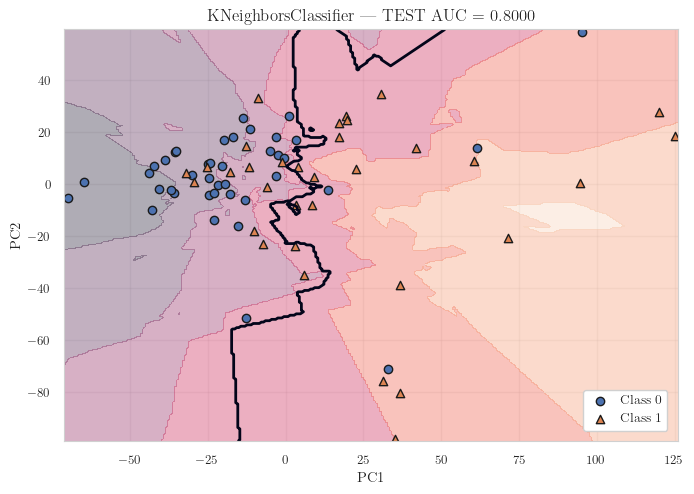

In [47]:
# ============================================================
# DECISION BOUNDARY (PCA-2D) — using already trained classifier
#   - model trained in FULL feature space
#   - PCA used only for visualization
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ------------------------------------------------------------
# Choose your trained model here
# ------------------------------------------------------------
clf = BEST_KNN_FIXED   # or BEST_KNN_MODEL or any trained pipeline

# ------------------------------------------------------------
# Compute TEST AUC in FULL-DIM (real performance)
# ------------------------------------------------------------
score_test = clf.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, score_test)

# ------------------------------------------------------------
# PCA fit on TRAIN only (for visualization)
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

pca = PCA(n_components=2, random_state=42)
Z_train = pca.fit_transform(X_train_scaled)

# ------------------------------------------------------------
# Train a lightweight copy of classifier in PCA-2D
# (for boundary visualization only)
# ------------------------------------------------------------
from sklearn.base import clone

clf_2d = clone(clf)
clf_2d.fit(Z_train, y_train)

# ------------------------------------------------------------
# Create meshgrid
# ------------------------------------------------------------
h = 0.02
x_min, x_max = Z_train[:, 0].min() - 1, Z_train[:, 0].max() + 1
y_min, y_max = Z_train[:, 1].min() - 1, Z_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = clf_2d.predict_proba(grid)[:, 1]
Z = Z.reshape(xx.shape)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

# decision surface
plt.contourf(xx, yy, Z, alpha=0.35)
plt.contour(xx, yy, Z, levels=[0.5], linewidths=2)

# training points
plt.scatter(
    Z_train[y_train == 0, 0],
    Z_train[y_train == 0, 1],
    marker="o",
    label="Class 0",
    edgecolor="k"
)

plt.scatter(
    Z_train[y_train == 1, 0],
    Z_train[y_train == 1, 1],
    marker="^",
    label="Class 1",
    edgecolor="k"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"{clf.named_steps['knn'].__class__.__name__} | TEST AUC = {auc_test:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
# ============================================================
# CROSS-DATASET EVAL — INTERSECTION on ACTUAL X_train columns (NO leakage)
#   Uses best_classifier (same hyperparams) and REFITS on each intersection slice
# ============================================================

import polars as pl
import numpy as np
from pathlib import Path
from datetime import datetime
import json

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, matthews_corrcoef
)

# -----------------------------
# CONFIG
# -----------------------------
EXTERNAL_DATASETS = {
    "GSE225845":  "/kaggle/input/datasets/rovieramariella/gse225845-parquet/GSE225845.parquet",
    "GSE287331":  "/kaggle/input/datasets/rovieramariella/3-gse287331-parquet/GSE287331_clean_imputed.parquet",
}

OUTDIR = Path("./cross_eval_from5k_intersection")
OUTDIR.mkdir(exist_ok=True)

# -----------------------------
# REQUIRED IN MEMORY
# -----------------------------
# X_train, X_test, y_train, y_test
# EPS_M
# LABEL_COL, LABELS_USE
# best_classifier  (sklearn estimator or Pipeline)
#
# One of these must match X_train columns (len == X_train.shape[1]):
#   cpg_cols_Xtrain OR final_cpgs OR cpg_cols_final OR cpg_cols_train_5k OR selected_5000_cpgs_in_order

if "BEST_KNN_FIXED" not in globals():
    raise NameError("best_classifier not found in globals(). Provide your trained/selected estimator as best_classifier.")
best_classifier = BEST_KNN_FIXED

def beta_to_m(beta_arr, eps):
    b = np.clip(beta_arr, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def compute_metrics(y, proba, pred):
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {
        "roc_auc": float(roc_auc_score(y, proba)),
        "balanced_accuracy": float(balanced_accuracy_score(y, pred)),
        "precision": float(precision_score(y, pred, zero_division=0)),
        "recall": float(recall_score(y, pred, zero_division=0)),
        "f1": float(f1_score(y, pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y, pred)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

# -----------------------------
# Pick the correct CpG list for X_train columns
# -----------------------------
X_train = np.asarray(X_train, float)
X_test  = np.asarray(X_test,  float)
y_train = np.asarray(y_train).ravel().astype(int)
y_test  = np.asarray(y_test).ravel().astype(int)

candidates = [
    "cpg_cols_Xtrain",
    "final_cpgs",
    "cpg_cols_final",
    "cpg_cols_train_5k",
    "selected_5000_cpgs_in_order",
    "selected_5000_cpgs",  # last resort
]

cpg_cols_5k = None
for name in candidates:
    if name in globals():
        tmp = list(globals()[name])
        if len(tmp) == X_train.shape[1]:
            cpg_cols_5k = tmp
            print(f"[OK] Using CpG column list: {name} (len={len(tmp)})")
            break

if cpg_cols_5k is None:
    raise NameError(
        "Non trovo la lista CpG che corrisponde alle colonne di X_train.\n"
        "Serve una lista di lunghezza X_train.shape[1] con i nomi CpG nell'ordine delle colonne.\n"
        "Esempi: final_cpgs / cpg_cols_final / cpg_cols_Xtrain / selected_5000_cpgs_in_order."
    )

cpg_to_idx_5k = {c: i for i, c in enumerate(cpg_cols_5k)}
print(f"[INFO] X_train shape={X_train.shape} | X_test shape={X_test.shape}")

# -----------------------------
# Report the hyperparameters of best_classifier (so you know what is being reused)
# -----------------------------
print("\n" + "-" * 90)
print("[INFO] best_classifier type:", type(best_classifier))
try:
    params = best_classifier.get_params(deep=True)
    print("[INFO] best_classifier params (deep):")
    for k in sorted(params.keys()):
        print(f"  {k}: {params[k]}")
except Exception as e:
    print("[WARN] Could not print best_classifier params:", repr(e))
print("-" * 90)

# ============================================================
# LOOP
# ============================================================
for dname, path in EXTERNAL_DATASETS.items():
    print("\n" + "=" * 70)
    print("External:", dname)
    print("=" * 70)

    beta_ext = (
        pl.read_parquet(path)
        .filter(pl.col(LABEL_COL).is_in(LABELS_USE))
        .with_columns(pl.col(LABEL_COL).cast(pl.Int64))
    )
    ext_cols = set(beta_ext.columns)

    # Intersection: (CpGs in X_train order) ∩ (external dataset columns)
    common_cpgs = [c for c in cpg_cols_5k if c in ext_cols]
    print("CpGs after intersection:", len(common_cpgs))

    if len(common_cpgs) < 20:
        print("Too few common CpGs. Skipping.")
        continue

    idx_common = np.array([cpg_to_idx_5k[c] for c in common_cpgs], dtype=int)

    # Slice current matrices (NO leakage)
    Xtr = X_train[:, idx_common].astype(np.float32, copy=False)
    Xte = X_test[:,  idx_common].astype(np.float32, copy=False)

    # External β -> M
    Bex = beta_ext.select(common_cpgs).to_numpy().astype(np.float32, copy=False)
    yex = beta_ext.select(LABEL_COL).to_numpy().ravel().astype(int)
    Xex = beta_to_m(Bex, EPS_M).astype(np.float32, copy=False)

    print("Shapes: train", Xtr.shape, "| test", Xte.shape, "| ext", Xex.shape)

    # --------------------------------------------------------
    # Refit best_classifier on Xtr (same hyperparams)
    # Optional: calibrate if estimator has no predict_proba
    # --------------------------------------------------------
    base = clone(best_classifier)

    has_proba = hasattr(base, "predict_proba")
    if not has_proba:
        # Calibrate to get probabilities for AUC and thresholds
        # Note: calibration CV is train-only => still no leakage
        clf = CalibratedClassifierCV(base, method="sigmoid", cv=3)
    else:
        clf = base

    clf.fit(Xtr, y_train)

    # INTERNAL (current test split)
    proba_te = clf.predict_proba(Xte)[:, 1]
    pred_te  = clf.predict(Xte)
    m_int = compute_metrics(y_test, proba_te, pred_te)

    # EXTERNAL
    proba_ex = clf.predict_proba(Xex)[:, 1]
    pred_ex  = clf.predict(Xex)
    m_ext = compute_metrics(yex, proba_ex, pred_ex)

    print("\nINTERNAL TEST:")
    print({k: round(v, 4) for k, v in m_int.items() if k not in ["tn", "fp", "fn", "tp"]})

    print("\nEXTERNAL TEST:", dname)
    print({k: round(v, 4) for k, v in m_ext.items() if k not in ["tn", "fp", "fn", "tp"]})


print("\nDONE.")

[OK] Using CpG column list: final_cpgs (len=5000)
[INFO] X_train shape=(73, 5000) | X_test shape=(19, 5000)

------------------------------------------------------------------------------------------
[INFO] best_classifier type: <class 'sklearn.pipeline.Pipeline'>
[INFO] best_classifier params (deep):
  knn: KNeighborsClassifier(n_neighbors=21)
  knn__algorithm: auto
  knn__leaf_size: 30
  knn__metric: minkowski
  knn__metric_params: None
  knn__n_jobs: None
  knn__n_neighbors: 21
  knn__p: 2
  knn__weights: uniform
  memory: None
  scaler: StandardScaler()
  scaler__copy: True
  scaler__with_mean: True
  scaler__with_std: True
  steps: [('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=21))]
  transform_input: None
  verbose: False
------------------------------------------------------------------------------------------

External: GSE225845
CpGs after intersection: 4614
Shapes: train (73, 4614) | test (19, 4614) | ext (253, 4614)

INTERNAL TEST:
{'roc_auc': 0.788

In [5]:
# ============================================================
# CROSS-DATASET EVAL — INTERSECTION on the ACTUAL 5k columns of X_train (NO leakage)
# ============================================================

import polars as pl
import numpy as np
from pathlib import Path
from datetime import datetime
import json

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, matthews_corrcoef
)

# -----------------------------
# CONFIG
# -----------------------------
EXTERNAL_DATASETS = {
    "GSE225845":  "/kaggle/input/datasets/rovieramariella/gse225845-parquet/GSE225845.parquet",
    "GSE287331": "/kaggle/input/datasets/rovieramariella/3-gse287331-parquet/GSE287331_clean_imputed.parquet",
}

OUTDIR = Path("./cross_eval_from5k_intersection")
OUTDIR.mkdir(exist_ok=True)

# -----------------------------
# REQUIRED IN MEMORY
# -----------------------------
# X_train, X_test, y_train, y_test
# EPS_M, SVM_C, SVM_MAX_ITER, RANDOM_STATE
# LABEL_COL, LABELS_USE
#
# And ONE of these must exist and match X_train columns (len == X_train.shape[1]):
#   cpg_cols_Xtrain OR final_cpgs OR cpg_cols_final OR cpg_cols_train_5k OR selected_5000_cpgs_in_order

def beta_to_m(beta_arr, eps):
    b = np.clip(beta_arr, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def compute_metrics(y, proba, pred):
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return {
        "roc_auc": float(roc_auc_score(y, proba)),
        "balanced_accuracy": float(balanced_accuracy_score(y, pred)),
        "precision": float(precision_score(y, pred, zero_division=0)),
        "recall": float(recall_score(y, pred, zero_division=0)),
        "f1": float(f1_score(y, pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y, pred)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

# -----------------------------
# Pick the correct CpG list for X_train columns
# -----------------------------
X_train = np.asarray(X_train, float)
X_test  = np.asarray(X_test, float)
y_train = np.asarray(y_train).ravel().astype(int)
y_test  = np.asarray(y_test).ravel().astype(int)

candidates = [
    "cpg_cols_Xtrain",
    "final_cpgs",
    "cpg_cols_final",
    "cpg_cols_train_5k",
    "selected_5000_cpgs_in_order",
    "selected_5000_cpgs",  # last resort
]

cpg_cols_5k = None
for name in candidates:
    if name in globals():
        tmp = list(globals()[name])
        if len(tmp) == X_train.shape[1]:
            cpg_cols_5k = tmp
            print(f"[OK] Using CpG column list: {name} (len={len(tmp)})")
            break

if cpg_cols_5k is None:
    raise NameError(
        "Non trovo la lista CpG che corrisponde alle colonne di X_train.\n"
        "Serve una lista di lunghezza X_train.shape[1] (cioè 5000) con i nomi CpG nell'ordine delle colonne.\n"
        "Esempi nomi attesi: final_cpgs / cpg_cols_final / cpg_cols_Xtrain / selected_5000_cpgs_in_order."
    )

cpg_to_idx_5k = {c: i for i, c in enumerate(cpg_cols_5k)}

print(f"[INFO] X_train shape={X_train.shape} | X_test shape={X_test.shape}")

# ============================================================
# LOOP
# ============================================================
for dname, path in EXTERNAL_DATASETS.items():
    print("\n" + "="*70)
    print("External:", dname)
    print("="*70)

    beta_ext = (
        pl.read_parquet(path)
        .filter(pl.col(LABEL_COL).is_in(LABELS_USE))
        .with_columns(pl.col(LABEL_COL).cast(pl.Int64))
    )
    ext_cols = set(beta_ext.columns)

    # Intersection: (5k actually used in X_train) ∩ (external)
    common_cpgs = [c for c in cpg_cols_5k if c in ext_cols]
    print("CpGs after intersection:", len(common_cpgs))

    if len(common_cpgs) < 20:
        print("Too few common CpGs. Skipping.")
        continue

    idx_common = np.array([cpg_to_idx_5k[c] for c in common_cpgs], dtype=int)

    # Slice current 5k matrices (safe indices)
    Xtr = X_train[:, idx_common].astype(np.float32)
    Xte = X_test[:,  idx_common].astype(np.float32)

    # External β -> M
    Bex = beta_ext.select(common_cpgs).to_numpy().astype(np.float32)
    yex = beta_ext.select(LABEL_COL).to_numpy().ravel().astype(int)
    Xex = beta_to_m(Bex, EPS_M).astype(np.float32)

    print("Shapes: train", Xtr.shape, "| test", Xte.shape, "| ext", Xex.shape)

    # Refit SVM (NO leakage)
    base_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", LinearSVC(
            C=SVM_C,
            class_weight="balanced",
            max_iter=SVM_MAX_ITER,
            random_state=RANDOM_STATE
        ))
    ])
    clf = CalibratedClassifierCV(base_pipe, method="sigmoid", cv=3)
    clf.fit(Xtr, y_train)

    # INTERNAL
    proba_te = clf.predict_proba(Xte)[:, 1]
    pred_te  = clf.predict(Xte)
    m_int = compute_metrics(y_test, proba_te, pred_te)

    # EXTERNAL
    proba_ex = clf.predict_proba(Xex)[:, 1]
    pred_ex  = clf.predict(Xex)
    m_ext = compute_metrics(yex, proba_ex, pred_ex)

    print("\nINTERNAL TEST:")
    print({k: round(v, 4) for k, v in m_int.items() if k not in ["tn","fp","fn","tp"]})

    print("\nEXTERNAL TEST:", dname)
    print({k: round(v, 4) for k, v in m_ext.items() if k not in ["tn","fp","fn","tp"]})

    # Save JSON
    run_tag = f"cross_from5k_{dname}_n{len(common_cpgs)}"
    payload = {
        "run_tag": run_tag,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "train_dataset": "CURRENT_TRAIN",
        "external_dataset": dname,
        "n_common_cpgs": int(len(common_cpgs)),
        "internal_metrics": m_int,
        "external_metrics": m_ext,
    }
    with open(OUTDIR / f"{run_tag}.json", "w") as f:
        json.dump(payload, f, indent=2)

    print("Saved:", OUTDIR / f"{run_tag}.json")

print("\nDONE.")


NameError: name 'M_train' is not defined

In [36]:
# ============================================================
# CROSS-DATASET EVAL — INTERSECTION on the ACTUAL columns of X_train (NO leakage) — RIDGE
# ============================================================

import polars as pl
import numpy as np
from pathlib import Path
from datetime import datetime
import json

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, matthews_corrcoef
)

# -----------------------------
# CONFIG
# -----------------------------
EXTERNAL_DATASETS = {
    "GSE225845": "/kaggle/input/datasets/rovieramariella/gse225845-parquet/GSE225845.parquet",
    "GSE287331": "/kaggle/input/datasets/rovieramariella/3-gse287331-parquet/GSE287331_clean_imputed.parquet",
}

OUTDIR = Path("./cross_eval_ridge_intersection")
OUTDIR.mkdir(exist_ok=True)

# Calibration (optional but consistent with your old cross-eval)
USE_CALIBRATION = True
CAL_METHOD = "sigmoid"
CAL_CV = 3

# Ridge hyperparam (use the same you used intra-dataset)
RIDGE_ALPHA = globals().get("RIDGE_ALPHA", 1.0)
RANDOM_STATE = globals().get("RANDOM_STATE", 42)

print("\n" + "=" * 90)
print("CROSS-DATASET EVAL — RIDGE | intersection on ACTUAL X_train columns (no leakage)")
print("=" * 90)
print(f"RIDGE_ALPHA={RIDGE_ALPHA} | USE_CALIBRATION={USE_CALIBRATION} ({CAL_METHOD}, cv={CAL_CV})")

# -----------------------------
# REQUIRED IN MEMORY
# -----------------------------
# X_train, X_test, y_train, y_test  (already built on your selected CpGs)
# EPS_M
# LABEL_COL, LABELS_USE
#
# AND one CpG list aligned with columns of X_train (len == X_train.shape[1]):
#   cpg_cols_Xtrain OR final_cpgs OR cpg_cols_final OR cpg_cols_train_5k OR selected_5000_cpgs_in_order ...

def beta_to_m(beta_arr, eps):
    b = np.clip(beta_arr, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def compute_metrics(y, proba, pred):
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {
        "roc_auc": float(roc_auc_score(y, proba)),
        "balanced_accuracy": float(balanced_accuracy_score(y, pred)),
        "precision": float(precision_score(y, pred, zero_division=0)),
        "recall": float(recall_score(y, pred, zero_division=0)),
        "f1": float(f1_score(y, pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y, pred)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

# -----------------------------
# Validate arrays
# -----------------------------
X_train = np.asarray(X_train, dtype=np.float32)
X_test  = np.asarray(X_test,  dtype=np.float32)
y_train = np.asarray(y_train).ravel().astype(int)
y_test  = np.asarray(y_test).ravel().astype(int)

print(f"[INFO] Shapes: X_train={X_train.shape} | X_test={X_test.shape}")

# -----------------------------
# Pick CpG list aligned to X_train columns
# -----------------------------
candidates = [
    "cpg_cols_Xtrain",
    "final_cpgs",
    "cpg_cols_final",
    "cpg_cols_train_5k",
    "selected_5000_cpgs_in_order",
    "selected_5000_cpgs",
    "cpg_cols_current",  # last fallback (only if already aligned to X_train)
]

cpg_cols_used = None
for name in candidates:
    if name in globals():
        tmp = list(globals()[name])
        if len(tmp) == X_train.shape[1]:
            cpg_cols_used = [str(x) for x in tmp]
            print(f"[OK] Using CpG column list: {name} (len={len(cpg_cols_used)})")
            break

if cpg_cols_used is None:
    raise NameError(
        "Non trovo la lista CpG allineata a X_train.\n"
        "Serve una lista di lunghezza X_train.shape[1] con i nomi CpG nell'ordine delle colonne.\n"
        "Esempi: final_cpgs / cpg_cols_final / cpg_cols_Xtrain / selected_5000_cpgs_in_order."
    )

cpg_to_idx = {c: i for i, c in enumerate(cpg_cols_used)}

# -----------------------------
# Build base RIDGE pipeline (refit per-intersection)
# -----------------------------
base_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("ridge", RidgeClassifier(alpha=RIDGE_ALPHA, class_weight="balanced", random_state=RANDOM_STATE)),
])

def fit_model(Xtr, ytr):
    if USE_CALIBRATION:
        clf = CalibratedClassifierCV(base_pipe, method=CAL_METHOD, cv=CAL_CV)
        clf.fit(Xtr, ytr)
        return clf
    else:
        base_pipe.fit(Xtr, ytr)
        return base_pipe

def predict_scores(clf, X):
    # If calibrated, use probabilities; else use decision_function (monotone)
    if hasattr(clf, "predict_proba"):
        proba = clf.predict_proba(X)[:, 1]
    else:
        proba = clf.decision_function(X)
    pred = clf.predict(X)
    return proba, pred

# ============================================================
# LOOP over external datasets
# ============================================================
for dname, path in EXTERNAL_DATASETS.items():
    print("\n" + "=" * 70)
    print("External:", dname)
    print("=" * 70)

    beta_ext = (
        pl.read_parquet(path)
        .filter(pl.col(LABEL_COL).is_in(LABELS_USE))
        .with_columns(pl.col(LABEL_COL).cast(pl.Int64))
    )

    ext_cols = set(beta_ext.columns)

    # Intersection: CpGs used in X_train ∩ external dataset columns
    common_cpgs = [c for c in cpg_cols_used if c in ext_cols]
    n_common = len(common_cpgs)
    print("CpGs after intersection:", n_common)

    if n_common < 20:
        print("Too few common CpGs. Skipping.")
        continue

    idx_common = np.array([cpg_to_idx[c] for c in common_cpgs], dtype=int)

    # Slice intra matrices to the common set
    Xtr = X_train[:, idx_common].astype(np.float32, copy=False)
    Xte = X_test[:,  idx_common].astype(np.float32, copy=False)

    # External β -> M (only on common CpGs)
    Bex = beta_ext.select(common_cpgs).to_numpy().astype(np.float32, copy=False)
    yex = beta_ext.select(LABEL_COL).to_numpy().ravel().astype(int)
    Xex = beta_to_m(Bex, EPS_M).astype(np.float32, copy=False)

    print("Shapes: train", Xtr.shape, "| test", Xte.shape, "| ext", Xex.shape)

    # Fit on train-only (no leakage)
    clf = fit_model(Xtr, y_train)

    # INTERNAL (held-out test from current dataset)
    s_te, p_te = predict_scores(clf, Xte)
    m_int = compute_metrics(y_test, s_te, p_te)

    # EXTERNAL
    s_ex, p_ex = predict_scores(clf, Xex)
    m_ext = compute_metrics(yex, s_ex, p_ex)

    print("\nINTERNAL TEST:")
    print({k: round(v, 4) for k, v in m_int.items() if k not in ["tn", "fp", "fn", "tp"]})

    print("\nEXTERNAL TEST:", dname)
    print({k: round(v, 4) for k, v in m_ext.items() if k not in ["tn", "fp", "fn", "tp"]})

    # Save JSON
    run_tag = f"cross_ridge_{dname}_n{n_common}"
    payload = {
        "run_tag": run_tag,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "train_dataset": "CURRENT_TRAIN",
        "external_dataset": dname,
        "n_common_cpgs": int(n_common),
        "ridge_alpha": float(RIDGE_ALPHA),
        "calibration": {"enabled": bool(USE_CALIBRATION), "method": CAL_METHOD, "cv": int(CAL_CV)},
        "internal_metrics": m_int,
        "external_metrics": m_ext,
        "common_cpgs_preview": common_cpgs[:25],  # small sanity log
    }

    with open(OUTDIR / f"{run_tag}.json", "w") as f:
        json.dump(payload, f, indent=2)

    print("Saved:", OUTDIR / f"{run_tag}.json")

print("\nDONE.")


CROSS-DATASET EVAL — RIDGE | intersection on ACTUAL X_train columns (no leakage)
RIDGE_ALPHA=1 | USE_CALIBRATION=True (sigmoid, cv=3)
[INFO] Shapes: X_train=(73, 2000) | X_test=(19, 2000)
[OK] Using CpG column list: final_cpgs (len=2000)

External: GSE225845
CpGs after intersection: 1836
Shapes: train (73, 1836) | test (19, 1836) | ext (253, 1836)

INTERNAL TEST:
{'roc_auc': 0.6444, 'balanced_accuracy': 0.6722, 'precision': 0.8, 'recall': 0.4444, 'f1': 0.5714, 'mcc': 0.3906}

EXTERNAL TEST: GSE225845
{'roc_auc': 0.621, 'balanced_accuracy': 0.5786, 'precision': 1.0, 'recall': 0.1571, 'f1': 0.2716, 'mcc': 0.2773}
Saved: cross_eval_ridge_intersection/cross_ridge_GSE225845_n1836.json

External: GSE287331
CpGs after intersection: 1662
Shapes: train (73, 1662) | test (19, 1662) | ext (242, 1662)

INTERNAL TEST:
{'roc_auc': 0.6222, 'balanced_accuracy': 0.5722, 'precision': 0.5714, 'recall': 0.4444, 'f1': 0.5, 'mcc': 0.1495}

EXTERNAL TEST: GSE287331
{'roc_auc': 0.2958, 'balanced_accuracy': 0

In [34]:
print("X_train shape:", X_train.shape)
print("n_features used by Ridge:", X_train.shape[1])
print("len(final_cpgs):", len(final_cpgs))

X_train shape: (73, 148352)
n_features used by Ridge: 148352
len(final_cpgs): 2000


In [35]:
col_to_idx = {c: i for i, c in enumerate(cpg_cols_current)}

idx_final = np.array([col_to_idx[c] for c in final_cpgs], dtype=int)

X_train = M_train[:, idx_final].astype(np.float32, copy=False)
X_test  = M_test[:,  idx_final].astype(np.float32, copy=False)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)

X_train shape: (73, 2000)
X_test  shape: (19, 2000)


In [ ]:
print("working")

In [53]:
!pip install pulp
import pulp

In [ ]:
# ============================================================
# CpG KNAPSACK POST-SVM — cella unica autocontenuta
#
# Flusso:
#   1. Estrae coef LinearSVC dalle 5000 CpG (final_cpgs)
#   2. Carica M_all / y_all dal parquet (norm+adj+tum)
#   3. Knapsack greedy sulle 5000 -> seleziona K=50
#      con valore = combinazione |coef_SVM| + |ΔM| + RSKF score
#   4. Valuta separazione norm-adj e norm-tum sulle 50 CpG
#
# Dipendenze richieste nello scope:
#   - final_cpgs          : np.ndarray (5000,)   — output STEP6
#   - cpg_cols_current    : np.ndarray (p,)       — colonne di M_train
#   - M_train, M_test     : matrici post STEP2
#   - y_train, y_test
#   - step3_stats         : dict "score", "abs_deltaM_full" allineati a cpg_candidates
#   - cpg_candidates      : np.ndarray (n_cand,)
#   - poolA_cpgs, poolB_cpgs (o None)
#   - cpg_to_chr          : dict CpG -> chr
#   - svm_pipe            : Pipeline già fittato (da cella SVM CHECK)
# ============================================================

import numpy as np
import polars as pl
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

# ──────────────────────────────────────────────
# CONFIG
# ──────────────────────────────────────────────
BETA_PATH    = "/kaggle/input/datasets/rovieramariella/gse69914-parquet/GSE69914.parquet"
ID_COL       = "id_tissue"
LABEL_COL    = "label"
LABELS_ALL   = [0, 1, 2]          # 0=norm, 1=adj, 2=tum

K            = 50                  # CpG da selezionare
N_POOL       = 500                 # top-N da final_cpgs per score RSKF
CHR_MAX      = 8                   # max CpG per cromosoma
CORR_THR     = 0.85                # soglia correlazione conflict edges
W_COEF       = 0.50                # peso |coef_SVM| nella funzione valore
W_DM         = 0.30                # peso |ΔM|
W_SCORE      = 0.20                # peso RSKF score (inverso)
K_A_min      = 30                  # min da Pool A (island-anchored)
K_B_max      = 20                  # max da Pool B
RANDOM_STATE = 42

# ──────────────────────────────────────────────
# 1. Estrai coef SVM dalle 5000 CpG (final_cpgs)
# ──────────────────────────────────────────────
# NOTA: il LinearSVC è stato fittato su X_train con 5000 colonne (final_cpgs),
# quindi coef_ ha size 5000 allineato a final_cpgs, NON a cpg_cols_current.

cols_all  = np.array(cpg_cols_current, dtype=object)
col_to_j  = {c: j for j, c in enumerate(cols_all.tolist())}

final_arr = np.array(final_cpgs, dtype=object)

raw_coef = np.array(svm_pipe.named_steps['svm'].coef_[0], dtype=float)
assert raw_coef.size == final_arr.size, \
    f"coef size {raw_coef.size} != final_cpgs size {final_arr.size}. " \
    f"Assicurati che svm_pipe sia stato fittato su X_train[:,final_cpgs]."

# coef_final è già allineato a final_arr (1:1)
coef_final = raw_coef

print(f"final_cpgs       : {final_arr.size}")
print(f"coef range       : [{coef_final.min():.4f}, {coef_final.max():.4f}]")
print(f"  pos coef (norm<adj ipermet.) : {(coef_final > 0).sum()}")
print(f"  neg coef (norm>adj ipomet.)  : {(coef_final < 0).sum()}")

# ──────────────────────────────────────────────
# 2. Carica M_all / y_all (norm + adj + tum)
# ──────────────────────────────────────────────
print("\nCaricamento dati completi (label 0,1,2)...")

beta_all = (
    pl.read_parquet(BETA_PATH)
    .filter(pl.col(LABEL_COL).is_in(LABELS_ALL))
)

y_all_pl  = beta_all.select(LABEL_COL).to_numpy().ravel().astype(int)
id_all_pl = beta_all.select(ID_COL).to_numpy().ravel()

# seleziona solo le colonne cpg (esclude metadata)
meta_cols = {ID_COL, LABEL_COL}
cpg_cols_parquet = [c for c in beta_all.columns if c not in meta_cols]

# allinea a cpg_cols_current (M_all deve avere stesse colonne di M_train)
# usa solo le CpG presenti in cpg_cols_current
common = [c for c in cpg_cols_parquet if c in col_to_j]
jj_common = np.array([col_to_j[c] for c in common], dtype=int)

M_all_beta = beta_all.select(common).to_numpy().astype(np.float32)

# beta -> M transform (stessa funzione del notebook)
EPS_M = 1e-6
def beta_to_m(b, eps=EPS_M):
    b = np.clip(b, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

M_all = beta_to_m(M_all_beta).astype(np.float32)

# costruisci mapping colonna per M_all
# M_all[:,i] corrisponde a common[i]
col_to_j_all = {c: i for i, c in enumerate(common)}

print(f"M_all shape      : {M_all.shape}")
print(f"y_all distrib    : " + str({int(v): int((y_all_pl == v).sum()) for v in np.unique(y_all_pl)}))

y_all = y_all_pl

# ──────────────────────────────────────────────
# 3. Allinea RSKF score e |ΔM| alle final_cpgs
# ──────────────────────────────────────────────
cand_arr   = np.array(cpg_candidates, dtype=object)
cand_score = np.array(step3_stats["score"],           dtype=float)
cand_absdM = np.array(step3_stats["abs_deltaM_full"], dtype=float)
cand_to_i  = {c: i for i, c in enumerate(cand_arr.tolist())}

# per le final_cpgs che sono in cpg_candidates
score_final = np.array([cand_score[cand_to_i[c]] if c in cand_to_i else np.nan
                         for c in final_arr], dtype=float)
absdM_final = np.array([cand_absdM[cand_to_i[c]] if c in cand_to_i else np.nan
                         for c in final_arr], dtype=float)

n_missing = int(np.isnan(score_final).sum())
if n_missing > 0:
    print(f"⚠ {n_missing} CpG di final_cpgs non trovate in cpg_candidates — score=nan, saranno penalizzate.")

# ──────────────────────────────────────────────
# 4. Costruisci pool knapsack (top-N per |coef_SVM|)
#    Usiamo |coef| come criterio principale di pre-selezione
#    perché siamo nel flusso "post-SVM"
# ──────────────────────────────────────────────
order_coef  = np.argsort(-np.abs(coef_final))   # maggior |coef| prima
pool_idx    = order_coef[:N_POOL]
pool_cpgs   = final_arr[pool_idx]
pool_coef   = coef_final[pool_idx]
pool_score  = score_final[pool_idx]
pool_absdM  = absdM_final[pool_idx]

print(f"\nPool knapsack    : {len(pool_cpgs)} CpGs (top |coef_SVM|)")
print(f"|coef| range     : [{np.abs(pool_coef).min():.4f}, {np.abs(pool_coef).max():.4f}]")

# ──────────────────────────────────────────────
# 5. Pool A / B nel pool
# ──────────────────────────────────────────────
_poolA_set = set(np.array(poolA_cpgs, dtype=object).tolist())
_poolB_set = set(np.array(poolB_cpgs, dtype=object).tolist()) if poolB_cpgs is not None else set()

poolA_in = [c for c in pool_cpgs if c in _poolA_set]
poolB_in = [c for c in pool_cpgs if c in _poolB_set]
K_A_use  = min(K_A_min, len(poolA_in))
K_B_use  = K_B_max

print(f"Pool A nel pool  : {len(poolA_in)}  (K_A_min usato: {K_A_use})")
print(f"Pool B nel pool  : {len(poolB_in)}  (K_B_max usato: {K_B_use})")

# ──────────────────────────────────────────────
# 6. Conflict edges (correlazione su M_train)
# ──────────────────────────────────────────────
_valid   = [c for c in pool_cpgs if c in col_to_j]
_jj_pool = np.array([col_to_j[c] for c in _valid], dtype=int)
_pv      = np.array(_valid, dtype=object)

if len(_valid) < len(pool_cpgs):
    _mask      = np.array([c in set(_valid) for c in pool_cpgs])
    pool_cpgs  = _pv
    pool_coef  = pool_coef[_mask]
    pool_score = pool_score[_mask]
    pool_absdM = pool_absdM[_mask]
    poolA_in   = [c for c in pool_cpgs if c in _poolA_set]
    poolB_in   = [c for c in pool_cpgs if c in _poolB_set]

Z  = M_train[:, _jj_pool].astype(np.float64)
Z  = (Z - Z.mean(0)) / (Z.std(0, ddof=1) + 1e-12)
C  = (Z.T @ Z) / (Z.shape[0] - 1)
_i, _j = np.where(np.triu(np.abs(C) >= CORR_THR, k=1))
conflict_edges = [(_pv[i], _pv[j]) for i, j in zip(_i, _j)]

_np = len(_pv)
print(f"\nConflict edges   : {len(conflict_edges):,} / {_np*(_np-1)//2:,} ({100*len(conflict_edges)/(_np*(_np-1)//2):.1f}%) a |r|>={CORR_THR}")

# ──────────────────────────────────────────────
# 7. Funzione valore (combinazione rank-normalizzata)
# ──────────────────────────────────────────────
n_p = len(pool_cpgs)

def rank_norm_asc(v):
    """rank normalizzato: più alto v -> rank più alto (in [0,1])"""
    v = np.where(np.isnan(v), v.min() - 1, v)   # nan -> penalizzato
    return np.argsort(np.argsort(v)) / (n_p - 1)

def rank_norm_desc(v):
    """rank normalizzato: più basso v -> rank più alto"""
    return 1.0 - rank_norm_asc(v)

r_coef  = rank_norm_asc(np.abs(pool_coef))    # |coef| alto = buono
r_dM    = rank_norm_asc(pool_absdM)            # |ΔM| alto = buono
r_score = rank_norm_desc(pool_score)           # score basso = buono

value = W_COEF * r_coef + W_DM * r_dM + W_SCORE * r_score
print(f"\nValore CpG       : min={value.min():.4f}  max={value.max():.4f}")

# ──────────────────────────────────────────────
# 8. Greedy knapsack con conflict edges
# ──────────────────────────────────────────────
chr_arr = np.array([cpg_to_chr.get(c, "") for c in pool_cpgs], dtype=object)
idx_of  = {c: i for i, c in enumerate(pool_cpgs.tolist())}

conflict_pairs = []
for a, b in conflict_edges:
    if a in idx_of and b in idx_of:
        ia, ib = idx_of[a], idx_of[b]
        if ia != ib:
            conflict_pairs.append((ia, ib))

cadj = [set() for _ in range(n_p)]
for ia, ib in conflict_pairs:
    cadj[ia].add(ib); cadj[ib].add(ia)

order    = np.argsort(-value)
selected, selset = [], set()
cnt_A = cnt_B = 0
chr_cnt = {}

def bad(i):
    ch = chr_arr[i]
    if ch != "" and chr_cnt.get(ch, 0) >= CHR_MAX: return True
    if pool_cpgs[i] in _poolB_set and cnt_B >= K_B_use: return True
    return any(j in selset for j in cadj[i])

def add(i):
    global cnt_A, cnt_B
    selected.append(i); selset.add(i)
    if pool_cpgs[i] in _poolA_set: cnt_A += 1
    if pool_cpgs[i] in _poolB_set: cnt_B += 1
    ch = chr_arr[i]
    if ch != "": chr_cnt[ch] = chr_cnt.get(ch, 0) + 1

def take(pred, n):
    done = 0
    for i in order:
        if len(selected) >= K or done >= n: break
        if i not in selset and not bad(i) and pred(i):
            add(i); done += 1

# fase 1: Pool A
take(lambda i: pool_cpgs[i] in _poolA_set, max(0, K_A_use - cnt_A))
if cnt_A < K_A_use:
    print(f"⚠ Pool A: raggiunto solo {cnt_A}/{K_A_use}. Aumenta N_POOL o abbassa K_A_min.")

# fase 2: riempimento libero
take(lambda i: True, K - len(selected))

if len(selected) != K:
    raise RuntimeError(f"Greedy: selezionato {len(selected)}/{K}. Rilassa CHR_MAX o CORR_THR.")

sel_idx       = np.array(selected, dtype=int)
selected_cpgs = pool_cpgs[sel_idx].tolist()

# ──────────────────────────────────────────────
# 9. Diagnostica selezione
# ──────────────────────────────────────────────
_cnt_A = sum(1 for c in selected_cpgs if c in _poolA_set)
_cnt_B = sum(1 for c in selected_cpgs if c in _poolB_set)
_chrs, _cnts = np.unique(chr_arr[sel_idx], return_counts=True)
_chr_str = "  ".join(f"chr{c}:{n}" for c, n in zip(_chrs, _cnts) if c != "")

print(f"\n{'='*60}")
print(f"  Selezionate  : {len(selected_cpgs)} / K={K}")
print(f"  Pool A       : {_cnt_A}  (min: {K_A_use})")
print(f"  Pool B       : {_cnt_B}  (max: {K_B_use})")
print(f"  mean|coef|   : {np.abs(pool_coef[sel_idx]).mean():.4f}")
print(f"  mean|ΔM|     : {pool_absdM[sel_idx].mean():.4f}")
print(f"  Cromosomi    : {_chr_str}")
print(f"{'='*60}")

# ──────────────────────────────────────────────
# 10. Valutazione separazione — SENZA leakage
#
# norm-adj : usa SOLO M_test/y_test (il 20% mai visto dalla FS)
# norm-tum : usa M_all filtrato label==2 + normal di M_test
#            (tumor mai usati in FS, normal dal test set)
# ──────────────────────────────────────────────
LABEL_NAMES = {0: "Normal", 1: "Adjacent", 2: "Tumor"}
RANDOM_STATE = 42

# allinea le 50 CpG a M_test (cpg_cols_current allineato a M_train/M_test)
jj_test = np.array([col_to_j[c] for c in selected_cpgs if c in col_to_j], dtype=int)

# allinea le 50 CpG a M_all (colonne di M_all = common)
jj_eval = np.array([col_to_j_all[c] for c in selected_cpgs if c in col_to_j_all], dtype=int)

eval_results = {}

# ── CASO 1: norm vs adj su M_test ──
lname = "Normal_vs_Adjacent (test set)"
mask  = np.isin(y_test, [0, 1])
X_p   = M_test[mask][:, jj_test]
y_p   = (y_test[mask] == 1).astype(int)

print(f"\n[EVAL] {lname}  n={X_p.shape[0]} (norm={( y_p==0).sum()}, adj={(y_p==1).sum()})")

if X_p.shape[0] >= 10 and y_p.sum() > 0 and (y_p == 0).sum() > 0:
    out = {}
    try:
        out["silhouette"] = float(silhouette_score(X_p, y_p, metric="euclidean"))
    except:
        out["silhouette"] = None
    try:
        X_sc = StandardScaler().fit_transform(X_p)
        lr   = LogisticRegression(C=1.0, class_weight="balanced",
                                  max_iter=1000, random_state=RANDOM_STATE)
        # con pochi campioni usa cv=3 o leave-one-out
        n_cv = min(5, y_p.sum(), (y_p==0).sum())
        aucs = cross_val_score(lr, X_sc, y_p, cv=n_cv, scoring="roc_auc")
        out["auc_mean"] = float(aucs.mean())
        out["auc_std"]  = float(aucs.std())
    except Exception as e:
        out["auc_mean"] = out["auc_std"] = None
        print(f"  AUC error: {e}")
    m0 = X_p[y_p==0].mean(0); m1 = X_p[y_p==1].mean(0)
    out["mean_abs_dM"] = float(np.abs(m1-m0).mean())
    try:
        pca = PCA(n_components=2, random_state=RANDOM_STATE)
        pca.fit(StandardScaler().fit_transform(X_p))
        out["pca_pc1"] = float(pca.explained_variance_ratio_[0])
    except:
        out["pca_pc1"] = None
    eval_results[lname] = out
    print(f"  Silhouette : {out['silhouette']:.4f}" if out['silhouette'] else "  Silhouette : N/A")
    print(f"  AUC CV     : {out['auc_mean']:.4f} ± {out['auc_std']:.4f}" if out['auc_mean'] else "  AUC CV : N/A")
    print(f"  mean|ΔM|   : {out['mean_abs_dM']:.4f}")
    print(f"  PCA PC1    : {out['pca_pc1']:.3f}" if out['pca_pc1'] else "  PCA PC1 : N/A")
else:
    print("  Campioni insufficienti nel test set per questa coppia.")
    print("  Verifica che y_test contenga sia label 0 che label 1.")

# ── CASO 2: norm vs tum (tumor mai visti + normal dal test set) ──
lname = "Normal_vs_Tumor (test norm + all tumor)"
mask_tum  = (y_all == 2)
mask_norm_test = (y_test == 0)

X_tum  = M_all[mask_tum][:, jj_eval]
X_norm = M_test[mask_norm_test][:, jj_test]

# verifica allineamento colonne (stesso ordine CpG)
# jj_test e jj_eval puntano alle stesse CpG ma in matrici diverse — ok se selected_cpgs è lo stesso
X_p = np.vstack([X_norm, X_tum])
y_p = np.array([0]*X_norm.shape[0] + [1]*X_tum.shape[0], dtype=int)

print(f"\n[EVAL] {lname}  n={X_p.shape[0]} (norm={X_norm.shape[0]}, tum={X_tum.shape[0]})")

if X_p.shape[0] >= 10 and y_p.sum() > 0:
    out = {}
    try:
        out["silhouette"] = float(silhouette_score(X_p, y_p, metric="euclidean"))
    except:
        out["silhouette"] = None
    try:
        X_sc = StandardScaler().fit_transform(X_p)
        lr   = LogisticRegression(C=1.0, class_weight="balanced",
                                  max_iter=1000, random_state=RANDOM_STATE)
        n_cv = min(5, y_p.sum(), (y_p==0).sum())
        aucs = cross_val_score(lr, X_sc, y_p, cv=n_cv, scoring="roc_auc")
        out["auc_mean"] = float(aucs.mean())
        out["auc_std"]  = float(aucs.std())
    except Exception as e:
        out["auc_mean"] = out["auc_std"] = None
        print(f"  AUC error: {e}")
    m0 = X_p[y_p==0].mean(0); m1 = X_p[y_p==1].mean(0)
    out["mean_abs_dM"] = float(np.abs(m1-m0).mean())
    try:
        pca = PCA(n_components=2, random_state=RANDOM_STATE)
        pca.fit(StandardScaler().fit_transform(X_p))
        out["pca_pc1"] = float(pca.explained_variance_ratio_[0])
    except:
        out["pca_pc1"] = None
    eval_results[lname] = out
    print(f"  Silhouette : {out['silhouette']:.4f}" if out['silhouette'] else "  Silhouette : N/A")
    print(f"  AUC CV     : {out['auc_mean']:.4f} ± {out['auc_std']:.4f}" if out['auc_mean'] else "  AUC CV : N/A")
    print(f"  mean|ΔM|   : {out['mean_abs_dM']:.4f}")
    print(f"  PCA PC1    : {out['pca_pc1']:.3f}" if out['pca_pc1'] else "  PCA PC1 : N/A")

print("\n[DONE] eval_results disponibile")
print("\n[DONE] Disponibili: selected_cpgs, sel_idx, eval_results, M_all, y_all")


In [ ]:
# ============================================================
# PLOT — Visualizzazione separazione sulle 50 CpG selezionate
# Richiede nello scope:
#   selected_cpgs, jj_test, jj_eval
#   M_test, y_test, M_all, y_all
#   col_to_j, col_to_j_all
#   apply_thesis_style, place_legend
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pathlib import Path

apply_thesis_style(use_tex=True, legend_outside=False)
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ── Palette coerente ──
C_NORM = plt.cm.viridis(0.15)
C_ADJ  = plt.cm.viridis(0.55)
C_TUM  = plt.cm.viridis(0.88)

# ── Costruisci dataset per ogni coppia ──
# norm-adj: solo test set
mask_na  = np.isin(y_test, [0, 1])
X_na     = M_test[mask_na][:, jj_test]
y_na     = y_test[mask_na]

# norm-tum: normal da test + tutti i tumor da M_all
mask_tum      = (y_all == 2)
mask_norm_te  = (y_test == 0)
X_nt = np.vstack([M_test[mask_norm_te][:, jj_test],
                  M_all[mask_tum][:, jj_eval]])
y_nt = np.array([0]*mask_norm_te.sum() + [2]*mask_tum.sum(), dtype=int)

# norm+adj+tum insieme (per heatmap completa)
X_all3 = np.vstack([
    M_test[mask_norm_te][:, jj_test],
    M_test[y_test == 1][:, jj_test],
    M_all[mask_tum][:, jj_eval],
])
y_all3 = np.array(
    [0]*mask_norm_te.sum() +
    [1]*(y_test == 1).sum() +
    [2]*mask_tum.sum(), dtype=int
)
label_str3 = np.array(["Normal"]*mask_norm_te.sum() +
                       ["Adjacent"]*(y_test==1).sum() +
                       ["Tumor"]*mask_tum.sum())

# ============================================================
# FIG 1 — PCA 2D: norm-adj (test) e norm-tum
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (X_p, y_p, title, pairs) in zip(axes, [
    (X_na,  y_na,  "Normal vs Adjacent (test set)",
     [(0, C_NORM, "Normal"), (1, C_ADJ, "Adjacent")]),
    (X_nt,  y_nt,  "Normal vs Tumor",
     [(0, C_NORM, "Normal"), (2, C_TUM, "Tumor")]),
]):
    Xsc = StandardScaler().fit_transform(X_p)
    pca = PCA(n_components=2, random_state=42)
    Z   = pca.fit_transform(Xsc)
    ve  = pca.explained_variance_ratio_

    for lab, col, lbl in pairs:
        mask = (y_p == lab)
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=[col], s=22, alpha=0.75, label=lbl, zorder=2)

    ax.set_xlabel(rf"PC1 ({ve[0]*100:.1f}\%)")
    ax.set_ylabel(rf"PC2 ({ve[1]*100:.1f}\%)")
    ax.set_title(title, fontsize=10)
    place_legend(ax)

fig.suptitle("PCA on 50 selected CpGs", fontsize=11, y=1.01)
fig.tight_layout()
pdf = OUTDIR / "50cpg_pca_norm_adj_tum.pdf"
fig.savefig(pdf, bbox_inches="tight")
print(f"Saved: {pdf}")
plt.show()

# ============================================================
# FIG 2 — Heatmap delle 50 CpG (norm+adj+tum, test set)
# ordine campioni per label, ordine CpG per |ΔM| norm-tum
# ============================================================
# sort CpG per |ΔM| norm vs tum
m0_nt = X_all3[y_all3 == 0].mean(0)
m2_nt = X_all3[y_all3 == 2].mean(0)
cpg_order = np.argsort(m2_nt - m0_nt)  # crescente: ipo- a sx, iper- a dx

# sort campioni per label
sample_order = np.argsort(y_all3)
X_heat = X_all3[sample_order][:, cpg_order]
y_heat = y_all3[sample_order]

# colori riga (label)
row_colors_vals = [C_NORM if l == 0 else C_ADJ if l == 1 else C_TUM for l in y_heat]
row_colors = np.array(row_colors_vals)

# z-score per colonna (per visualizzazione)
Xz = (X_heat - X_heat.mean(0)) / (X_heat.std(0) + 1e-12)

fig2, ax2 = plt.subplots(figsize=(12, 5))
im = ax2.imshow(Xz, aspect="auto", cmap="viridis",
                vmin=-2.5, vmax=2.5, interpolation="nearest")

# barre colorate per label a sinistra
n_norm = (y_heat == 0).sum()
n_adj  = (y_heat == 1).sum()
n_tum  = (y_heat == 2).sum()

for start, n, col, lbl in [
    (0,                 n_norm, C_NORM, "Normal"),
    (n_norm,            n_adj,  C_ADJ,  "Adjacent"),
    (n_norm + n_adj,    n_tum,  C_TUM,  "Tumor"),
]:
    ax2.barh(np.arange(start, start + n), [-1.5]*n,
             left=-2.5, color=col, height=1.0, label=lbl)

plt.colorbar(im, ax=ax2, label="M-value (z-score)", shrink=0.7)
ax2.set_xlabel("CpG (sorted by $\\Delta M$ norm$\\to$tum)")
ax2.set_ylabel("Samples")
ax2.set_title("Heatmap: 50 selected CpGs × samples (test set)", fontsize=10)
ax2.set_yticks([])
ax2.set_xticks([])
place_legend(ax2)
fig2.tight_layout()
pdf2 = OUTDIR / "50cpg_heatmap.pdf"
fig2.savefig(pdf2, bbox_inches="tight")
print(f"Saved: {pdf2}")
plt.show()

# ============================================================
# FIG 3 — Boxplot |ΔM| per le 50 CpG: norm-adj vs norm-tum
# ============================================================
m0_na = X_na[y_na == 0].mean(0)
m1_na = X_na[y_na == 1].mean(0)
dm_na = np.abs(m1_na - m0_na)

m0_nt2 = X_nt[y_nt == 0].mean(0)
m2_nt2 = X_nt[y_nt == 2].mean(0)
dm_nt = np.abs(m2_nt2 - m0_nt2)

fig3, ax3 = plt.subplots(figsize=(5, 4))
bp = ax3.boxplot([dm_na, dm_nt],
                 labels=["Normal vs Adjacent", "Normal vs Tumor"],
                 patch_artist=True,
                 medianprops=dict(color="black", linewidth=1.5))
bp["boxes"][0].set_facecolor(C_ADJ)
bp["boxes"][1].set_facecolor(C_TUM)

ax3.set_ylabel(r"$|\Delta M|$ per CpG")
ax3.set_title("Effect size on 50 CpGs", fontsize=10)
fig3.tight_layout()
pdf3 = OUTDIR / "50cpg_deltaM_boxplot.pdf"
fig3.savefig(pdf3, bbox_inches="tight")
print(f"Saved: {pdf3}")
plt.show()

print(f"\nSummary |ΔM|:")
print(f"  norm-adj : mean={dm_na.mean():.3f}  median={np.median(dm_na):.3f}  max={dm_na.max():.3f}")
print(f"  norm-tum : mean={dm_nt.mean():.3f}  median={np.median(dm_nt):.3f}  max={dm_nt.max():.3f}")


In [ ]:
import pandas as pd
from pathlib import Path

# --- PATH ---
CGC_PATH = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"

# Manifest EPIC (se sei su EPIC). Se stai su 450K, cambia manifest.
MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/humanmethylation450-15017482-v1-2-manifest/humanmethylation450_15017482_v1-2_manifest.csv"

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

# --- INPUT: 50 CpG dalla FS ---
selected_cpgs = [str(x) for x in list(selected_cpgs)]
print(f"Selected CpG: {len(selected_cpgs)}")

# --- LOAD COSMIC ---
cgc = pd.read_csv(CGC_PATH, sep="\t")

# --- FILTER BREAST (SOMATIC) ---
mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
cgc_breast = cgc.loc[mask_breast].copy()
genes_cgc_breast = set(cgc_breast["GENE_SYMBOL"].astype(str))

print(f"Geni COSMIC breast: {len(genes_cgc_breast)}")

# ============================================================
# CpG -> GENE(S) dal manifest
# ============================================================

def read_illumina_manifest_csv(path: str) -> pd.DataFrame:
    # trova header vero (riga che contiene IlmnID)
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if "IlmnID" in line.split(","):
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Manifest header not found (no 'IlmnID' line detected).")

    df = pd.read_csv(
        path,
        sep=",",
        header=header_idx,
        engine="python",
        on_bad_lines="skip",
    )
    df.columns = [c.strip() for c in df.columns]
    df = df.dropna(axis=1, how="all")
    return df

man = read_illumina_manifest_csv(MANIFEST_PATH)

# colonne standard EPIC: IlmnID e UCSC_RefGene_Name
if "IlmnID" not in man.columns:
    raise ValueError(f"Colonna IlmnID non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")
if "UCSC_RefGene_Name" not in man.columns:
    raise ValueError(f"Colonna UCSC_RefGene_Name non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")

# subset alle 50 CpG
m50 = man.loc[man["IlmnID"].isin(selected_cpgs), ["IlmnID", "UCSC_RefGene_Name"]].copy()
missing = sorted(set(selected_cpgs) - set(m50["IlmnID"].astype(str)))
print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs)}")
if missing:
    print(f"ATTENZIONE: CpG mancanti nel manifest: {len(missing)} (mostro max 15): {missing[:15]}")
    print("Se sono tante, stai usando il manifest sbagliato (EPIC vs 450K).")

# explode geni (campo separato da ';')
m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].astype(str).str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni associati alle 50 CpG (unique): {len(genes_50)}")

# salva mapping CpG->gene
m50.rename(columns={"IlmnID": "CpG"}).to_csv(OUTDIR / "cpg50_to_genes.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'cpg50_to_genes.tsv'}")

# ============================================================
# INTERSECTION: (GENES from 50 CpGs) ∩ (COSMIC breast)
# ============================================================

genes_overlap = sorted(genes_50 & genes_cgc_breast)
print(f"Geni in comune (genes_50CpG ∩ COSMIC breast): {len(genes_overlap)}")

# --- TABELLINA FINALE (gene-level, come il tuo) ---
table = (
    cgc_breast[cgc_breast["GENE_SYMBOL"].astype(str).isin(genes_overlap)]
    [["GENE_SYMBOL", "ROLE_IN_CANCER", "TIER", "TUMOUR_TYPES_SOMATIC"]]
    .drop_duplicates()
    .sort_values("GENE_SYMBOL")
)

display(table)

# opzionale: salva
table.to_csv(OUTDIR / "genes_overlap_COSMIC_breast_from_50cpg.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'genes_overlap_COSMIC_breast_from_50cpg.tsv'}")


In [ ]:
!pip install gprofiler-official -q
from gprofiler import GProfiler
import pandas as pd

gp = GProfiler(return_dataframe=True)

# ── STEP 1: costruisci background dai geni delle 5000 final_cpgs ──
m5000 = man.loc[man["IlmnID"].isin(final_cpgs.tolist()),
                ["IlmnID", "UCSC_RefGene_Name"]].copy()
m5000["GENE_SYMBOL"] = m5000["UCSC_RefGene_Name"].fillna("").str.split(";")
m5000 = m5000.explode("GENE_SYMBOL")
m5000["GENE_SYMBOL"] = m5000["GENE_SYMBOL"].str.strip()
background_genes = list(set(m5000["GENE_SYMBOL"]) - {""})
print(f"Background genes (5000 CpG): {len(background_genes)}")

# ── STEP 2: enrichment CON background corretto ──
results = gp.profile(
    organism='hsapiens',
    query=list(genes_50),
    background=background_genes,
    sources=['GO:BP', 'KEGG', 'REAC'],
    significance_threshold_method='fdr',
)
results_sig = results[results['p_value'] < 0.05].sort_values('p_value')
print(f"\nTermini significativi: {len(results_sig)}")
print(results_sig[['source','name','p_value','intersection_size']].head(20))

In [ ]:
# ============================================================
# ANNOTAZIONE 50 CpG — cella unica
# Richiede nello scope:
#   - selected_cpgs   : list di 50 CpG
#   - final_cpgs      : array 5000 CpG
#   - final_arr       : np.array delle 5000 CpG (allineato a coef_final)
#   - coef_final      : np.array dei coef SVM (allineato a final_arr)
#   - man             : DataFrame manifest già caricato
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

selected_cpgs_list = [str(x) for x in list(selected_cpgs)]
coef_map = dict(zip(final_arr.tolist(), coef_final.tolist()))

# ── 1. CpG -> gene dal manifest ──
m50 = man.loc[
    man["IlmnID"].isin(selected_cpgs_list),
    ["IlmnID", "UCSC_RefGene_Name"]
].copy()

print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs_list)}")
missing = set(selected_cpgs_list) - set(m50["IlmnID"].astype(str))
if missing:
    print(f"CpG NON trovate ({len(missing)}): {list(missing)[:10]}")
    print("Se sono molte -> manifest sbagliato (450K su dati EPIC)")

m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()
m50 = m50.rename(columns={"IlmnID": "CpG"})
m50["coef_svm"]  = m50["CpG"].map(coef_map)
m50["direction"] = m50["coef_svm"].apply(
    lambda x: "hypermethylated_in_adj" if (x is not None and x > 0)
              else "hypomethylated_in_adj" if (x is not None and x < 0)
              else "unknown"
)

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni unici associati alle 50 CpG: {len(genes_50)}")

# ── 2. Overlap con geni noti nel field cancerization ──
known_field_genes = {
    # lista originale
    'RASSF1', 'CDH1', 'APC', 'BRCA1', 'BRCA2',
    'CDKN2A', 'MLH1', 'GSTP1', 'DAPK1', 'RUNX3',
    'SFRP1', 'SFRP2', 'SFRP4', 'SFRP5', 'WIF1', 'DKK1', 'DKK3',
    'HOXA5', 'HOXA9', 'HOXA10', 'HOXB13',
    'TBX2', 'TBX3', 'TBX5',
    'TWIST1', 'TWIST2', 'SNAI1', 'SNAI2', 'ZEB1', 'ZEB2',
    'SLIT2', 'ROBO1', 'PCDH10', 'NDRG2',
    # aggiunte dai risultati
    'YAP1', 'KMT2A', 'XPC',        # dataset 2
    'DAB2IP', 'CCND2', 'RBPJ',     # dataset 3
    'DACT2', 'SMPD3',
}

hits = genes_50 & known_field_genes
print(f"\nGeni noti nel field cancerization: {len(hits)}")
if hits:
    print(f"  {sorted(hits)}")
    hits_df = m50[m50["GENE_SYMBOL"].isin(hits)][
        ["CpG", "GENE_SYMBOL", "direction", "coef_svm"]
    ].drop_duplicates().sort_values("GENE_SYMBOL")
    print(hits_df.to_string(index=False))
else:
    print("  Nessun gene noto trovato.")

# ── 3. Tabella completa per tesi ──
table_full = (
    m50[["CpG", "GENE_SYMBOL", "direction", "coef_svm"]]
    .drop_duplicates()
    .sort_values(["direction", "coef_svm"], ascending=[True, False])
)
print(f"\nTabella completa ({len(table_full)} righe):")
print(table_full.to_string(index=False))
table_full.to_csv(OUTDIR / "50cpg_annotated.tsv", sep="\t", index=False)
print(f"\nSalvato: {OUTDIR / '50cpg_annotated.tsv'}")

# ── 4. Sommario direzioni ──
n_hyper = (m50["direction"] == "hypermethylated_in_adj").sum()
n_hypo  = (m50["direction"] == "hypomethylated_in_adj").sum()
print(f"\nHypermethylated in Adjacent : {n_hyper}")
print(f"Hypomethylated in Adjacent  : {n_hypo}")

In [40]:
# ============================================================
# ANNOTAZIONE 50 CpG — cella unica
# Richiede nello scope:
#   - selected_cpgs   : list di 50 CpG
#   - final_cpgs      : array 5000 CpG
#   - final_arr       : np.array delle 5000 CpG (allineato a coef_final)
#   - coef_final      : np.array dei coef SVM (allineato a final_arr)
#   - man             : DataFrame manifest già caricato
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

selected_cpgs_list = [str(x) for x in list(final_cpgs)]
coef_map = dict(zip(final_arr.tolist(), coef_final.tolist()))

# ── 1. CpG -> gene dal manifest ──
m50 = man.loc[
    man["IlmnID"].isin(selected_cpgs_list),
    ["IlmnID", "UCSC_RefGene_Name"]
].copy()

print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs_list)}")
missing = set(selected_cpgs_list) - set(m50["IlmnID"].astype(str))
if missing:
    print(f"CpG NON trovate ({len(missing)}): {list(missing)[:10]}")
    print("Se sono molte -> manifest sbagliato (450K su dati EPIC)")

m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()
m50 = m50.rename(columns={"IlmnID": "CpG"})
m50["coef_svm"]  = m50["CpG"].map(coef_map)
m50["direction"] = m50["coef_svm"].apply(
    lambda x: "hypermethylated_in_adj" if (x is not None and x > 0)
              else "hypomethylated_in_adj" if (x is not None and x < 0)
              else "unknown"
)

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni unici associati alle 50 CpG: {len(genes_50)}")

# ── 2. Overlap con geni noti nel field cancerization ──
known_field_genes = {
    # lista originale
    'RASSF1', 'CDH1', 'APC', 'BRCA1', 'BRCA2',
    'CDKN2A', 'MLH1', 'GSTP1', 'DAPK1', 'RUNX3',
    'SFRP1', 'SFRP2', 'SFRP4', 'SFRP5', 'WIF1', 'DKK1', 'DKK3',
    'HOXA5', 'HOXA9', 'HOXA10', 'HOXB13',
    'TBX2', 'TBX3', 'TBX5',
    'TWIST1', 'TWIST2', 'SNAI1', 'SNAI2', 'ZEB1', 'ZEB2',
    'SLIT2', 'ROBO1', 'PCDH10', 'NDRG2',
    # aggiunte dai risultati
    'YAP1', 'KMT2A', 'XPC',        # dataset 2
    'DAB2IP', 'CCND2', 'RBPJ',     # dataset 3
    'DACT2', 'SMPD3',
}

hits = genes_50 & known_field_genes
print(f"\nGeni noti nel field cancerization: {len(hits)}")
if hits:
    print(f"  {sorted(hits)}")
    hits_df = m50[m50["GENE_SYMBOL"].isin(hits)][
        ["CpG", "GENE_SYMBOL", "direction", "coef_svm"]
    ].drop_duplicates().sort_values("GENE_SYMBOL")
    print(hits_df.to_string(index=False))
else:
    print("  Nessun gene noto trovato.")

# ── 3. Tabella completa per tesi ──
table_full = (
    m50[["CpG", "GENE_SYMBOL", "direction", "coef_svm"]]
    .drop_duplicates()
    .sort_values(["direction", "coef_svm"], ascending=[True, False])
)
print(f"\nTabella completa ({len(table_full)} righe):")
print(table_full.to_string(index=False))
table_full.to_csv(OUTDIR / "50cpg_annotated.tsv", sep="\t", index=False)
print(f"\nSalvato: {OUTDIR / '50cpg_annotated.tsv'}")

# ── 4. Sommario direzioni ──
n_hyper = (m50["direction"] == "hypermethylated_in_adj").sum()
n_hypo  = (m50["direction"] == "hypomethylated_in_adj").sum()
print(f"\nHypermethylated in Adjacent : {n_hyper}")
print(f"Hypomethylated in Adjacent  : {n_hypo}")

CpG trovate nel manifest: 2000 / 2000
Geni unici associati alle 50 CpG: 1263

Geni noti nel field cancerization: 16
  ['APC', 'BRCA2', 'CCND2', 'DAB2IP', 'DACT2', 'DKK3', 'GSTP1', 'HOXA10', 'HOXB13', 'PCDH10', 'RBPJ', 'SFRP2', 'SFRP5', 'SLIT2', 'TBX2', 'WIF1']
       CpG GENE_SYMBOL              direction  coef_svm
cg00190738         APC  hypomethylated_in_adj -0.006674
cg14479889         APC hypermethylated_in_adj  0.000571
cg26458617       BRCA2 hypermethylated_in_adj  0.007303
cg21462428       CCND2 hypermethylated_in_adj  0.006312
cg18566594       CCND2 hypermethylated_in_adj  0.011732
cg17296482       CCND2 hypermethylated_in_adj  0.009458
cg13801381       CCND2  hypomethylated_in_adj -0.000330
cg13575161       CCND2 hypermethylated_in_adj  0.007400
cg00814733       CCND2 hypermethylated_in_adj  0.004287
cg13391820       CCND2 hypermethylated_in_adj  0.000776
cg01407748      DAB2IP hypermethylated_in_adj  0.023890
cg05070558       DACT2 hypermethylated_in_adj  0.012221
cg19867649 

In [42]:
import pandas as pd
from pathlib import Path

# --- PATH ---
CGC_PATH = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"

# Manifest EPIC (se sei su EPIC). Se stai su 450K, cambia manifest.
MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/humanmethylation450-15017482-v1-2-manifest/humanmethylation450_15017482_v1-2_manifest.csv"
OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

# --- INPUT: 50 CpG dalla FS ---
selected_cpgs = [str(x) for x in list(final_cpgs)]
print(f"Selected CpG: {len(selected_cpgs)}")

# --- LOAD COSMIC ---
cgc = pd.read_csv(CGC_PATH, sep="\t")

# --- FILTER BREAST (SOMATIC) ---
mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
cgc_breast = cgc.loc[mask_breast].copy()
genes_cgc_breast = set(cgc_breast["GENE_SYMBOL"].astype(str))

print(f"Geni COSMIC breast: {len(genes_cgc_breast)}")

# ============================================================
# CpG -> GENE(S) dal manifest
# ============================================================

def read_illumina_manifest_csv(path: str) -> pd.DataFrame:
    # trova header vero (riga che contiene IlmnID)
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if "IlmnID" in line.split(","):
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Manifest header not found (no 'IlmnID' line detected).")

    df = pd.read_csv(
        path,
        sep=",",
        header=header_idx,
        engine="python",
        on_bad_lines="skip",
    )
    df.columns = [c.strip() for c in df.columns]
    df = df.dropna(axis=1, how="all")
    return df

man = read_illumina_manifest_csv(MANIFEST_PATH)

# colonne standard EPIC: IlmnID e UCSC_RefGene_Name
if "IlmnID" not in man.columns:
    raise ValueError(f"Colonna IlmnID non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")
if "UCSC_RefGene_Name" not in man.columns:
    raise ValueError(f"Colonna UCSC_RefGene_Name non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")

# subset alle 50 CpG
m50 = man.loc[man["IlmnID"].isin(selected_cpgs), ["IlmnID", "UCSC_RefGene_Name"]].copy()
missing = sorted(set(selected_cpgs) - set(m50["IlmnID"].astype(str)))
print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs)}")
if missing:
    print(f"ATTENZIONE: CpG mancanti nel manifest: {len(missing)} (mostro max 15): {missing[:15]}")
    print("Se sono tante, stai usando il manifest sbagliato (EPIC vs 450K).")

# explode geni (campo separato da ';')
m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].astype(str).str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni associati alle 50 CpG (unique): {len(genes_50)}")

# salva mapping CpG->gene
m50.rename(columns={"IlmnID": "CpG"}).to_csv(OUTDIR / "cpg50_to_genes.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'cpg50_to_genes.tsv'}")

# ============================================================
# INTERSECTION: (GENES from 50 CpGs) ∩ (COSMIC breast)
# ============================================================

genes_overlap = sorted(genes_50 & genes_cgc_breast)
print(f"Geni in comune (genes_50CpG ∩ COSMIC breast): {len(genes_overlap)}")

# --- TABELLINA FINALE (gene-level, come il tuo) ---
table = (
    cgc_breast[cgc_breast["GENE_SYMBOL"].astype(str).isin(genes_overlap)]
    [["GENE_SYMBOL", "ROLE_IN_CANCER", "TIER", "TUMOUR_TYPES_SOMATIC"]]
    .drop_duplicates()
    .sort_values("GENE_SYMBOL")
)

display(table)

# opzionale: salva
table.to_csv(OUTDIR / "genes_overlap_COSMIC_breast_from_50cpg.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'genes_overlap_COSMIC_breast_from_50cpg.tsv'}")


Selected CpG: 2000
Geni COSMIC breast: 44
CpG trovate nel manifest: 2000 / 2000
Geni associati alle 50 CpG (unique): 1263
Saved: post_fs_annotation/cpg50_to_genes.tsv
Geni in comune (genes_50CpG ∩ COSMIC breast): 3


,GENE_SYMBOL,ROLE_IN_CANCER,TIER,TUMOUR_TYPES_SOMATIC
50,BARD1,TSG,1,breast cancer
74,BRCA2,TSG,1,"breast, ovarian, pancreatic"
399,MAP2K4,"oncogene, TSG",1,"pancreatic, breast, colorectal"


Saved: post_fs_annotation/genes_overlap_COSMIC_breast_from_50cpg.tsv


In [44]:
print("woeking")

woeking


STEP 1 — Estrazione coef SVM
final_cpgs        : 2000
coef range        : [-0.0268, 0.0251]
  pos (ipermet.)  : 1037
  neg (ipomet.)   : 963

STEP 2 — Caricamento M_all (label 0,1,2)
M_all shape       : (397, 148352)
y_all distrib     : {0: 50, 1: 42, 2: 305}

STEP 4 — Pool top-2000 per |coef_SVM|
Pool effettivo    : 2000 CpG
|coef| range      : [0.0000, 0.0268]
Pool A nel pool   : 687  →  K_A_use = 25  (nominale 25)

STEP 6 — Conflict edges (correlazione su M_train)
Conflict edges    : 34 / 1,999,000 (0.00%) a |r|≥0.85

STEP 7 — Attributi genomici dal manifest
CpG con promotore : 1008
CpG in island     : 1053
Geni distinti pool: 1165  →  G_min_use = 25  (nominale 25)

f1 value range    : [0.0266, 0.9933]
f2 norm factor    : 125.0  (K×(2+η) = 50×2.5)

STEP 10 — Sweep μ

[μ=0.000] Solving MILP...
  Status     : Optimal
  f1         : 46.3582
  f2         : 82.5000  (f2_hat=0.6600)
  Δ(bio/clf) : 0.0000
  Jaccard(0) : 1.0000
  Promotori  : 31  |  Islands: 33  |  Geni: 37
  Saturato   : F

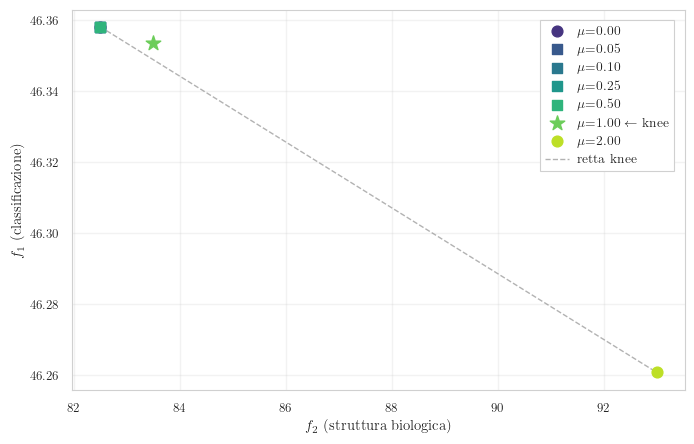

Salvato diagnostiche: knapsack_outputs/knapsack_sweep_diagnostics.pdf


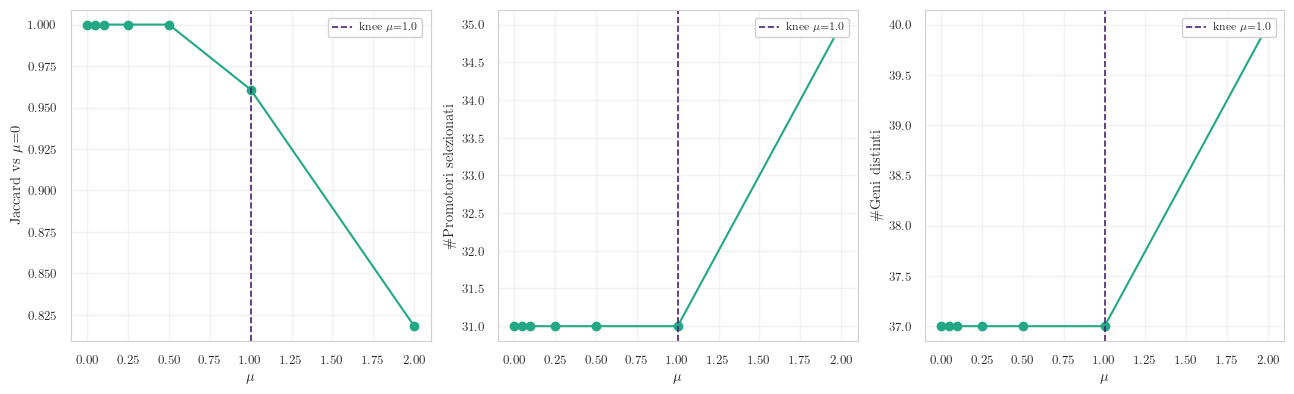

Salvato CSV sweep: knapsack_outputs/knapsack_sweep_summary.csv

STEP 15 — Evaluation separazione (50 CpG knee)

  [Normal vs Adjacent (test)]  n=19 (0=10, 1=9)
  Silhouette    : 0.0272
  AUC CV5       : 0.4000 ± 0.2550
  mean|ΔM|      : 0.5031
  PCA PC1       : 0.315

  [Normal vs Tumor]  n=315 (0=10, 1=305)
  Silhouette    : 0.0963
  AUC CV5       : 0.9934 ± 0.0096
  mean|ΔM|      : 1.5786
  PCA PC1       : 0.250

STEP 16 — Confronto μ=0 (pura classificazione) vs knee
                                      μ=0       knee
f1                                46.3582    46.3535
f2                                82.5000    83.5000
n_promoter                             31         31
n_island                               33         34
n_genes                                37         37
Jaccard(mu0, knee)                 0.9608

OUTPUT FINALE
  selected_cpgs_final : 50 CpG (knee, μ=1.0)
  sweep_results       : lista con tutte le run
  eval_results_final  : metriche separazione
  OUTDIR      

In [52]:
##### NUOVO MODELLO DELLO ZAIMO
# ============================================================
# CpG KNAPSACK — MILP bi-obiettivo con sweep su μ
#
# Modello:
#   max  f1(x) + μ * f2_hat(x, y)
#
#   f1(x)     = Σ v_i * x_i       (classificazione)
#              v_i = 0.5*c̃_i + 0.2*d̃_i + 0.3*s̃_i
#
#   f2(x,y)   = Σ_{i∈P} x_i       (promotori)
#             + Σ_{i∈L} x_i        (CpG islands)
#             + 0.5 * Σ_g y_g      (geni distinti)
#
#   f2_hat    = f2 / (K * (2 + 0.5))  ∈ [0, 1]
#
# Vincoli hard:
#   C1: Σ x_i = K
#   C2: x_i + x_j ≤ 1   ∀ (i,j) ∈ E  (conflict edges, |r| ≥ 0.85)
#   C3: Σ_{chr=c} x_i ≤ 10   ∀ c
#   C4: Σ_{i∈A} x_i ≥ K_A*  (adattivo: min(25, |A ∩ I|))
#   C5: x_i ≤ y_g   ∀ i: gene(i)=g
#   C6: Σ_{gene=g} x_i ≤ 2   ∀ g
#   C7: Σ_g y_g ≥ G_min*  (adattivo: min(25, |G|))
#
# Sweep μ ∈ {0, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0}
# Knee: distanza massima dalla retta (μ=0) → (max f2 osservato)
#
# Dipendenze nello scope (dal notebook):
#   final_cpgs, cpg_cols_current, M_train, M_test, y_train, y_test
#   step3_stats, cpg_candidates, poolA_cpgs, poolB_cpgs
#   cpg_to_chr, svm_pipe, man (manifest DataFrame)
#   apply_thesis_style, place_legend  (opzionale, per i plot)
# ============================================================

import numpy as np
import pandas as pd
import polars as pl
import pulp
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import silhouette_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA

# ─────────────────────────────────────────────────────────────
# CONFIG — modifica qui
# ─────────────────────────────────────────────────────────────
BETA_PATH    = "/kaggle/input/datasets/rovieramariella/gse69914-parquet/GSE69914.parquet"
ID_COL       = "id_tissue"
LABEL_COL    = "label"
LABELS_ALL   = [0, 1, 2]           # 0=Normal, 1=Adjacent, 2=Tumor

K            = 50                  # CpG da selezionare
N_POOL       = 2000                # top-N da final_cpgs per |coef|
CHR_MAX      = 10                  # C3: max CpG per cromosoma
CORR_THR     = 0.85                # C2: soglia correlazione conflict edges
ETA          = 0.5                 # peso geni in f2

W_COEF       = 0.5                 # peso |coef_SVM| in f1
W_DM         = 0.2                 # peso |ΔM| in f1 (abbassato per rischio doppio conteggio)
W_SCORE      = 0.3                 # peso RSKF score in f1

K_A_NOMINAL  = 25                  # C4: min Pool A (adattivo)
G_MIN_NOMINAL= 25                  # C7: min geni distinti (adattivo)
MAX_PER_GENE = 2                   # C6: max CpG per gene

CBC_TIME_LIMIT = 120               # secondi per ogni solve

MU_GRID = [0.0, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0]

EPS_M    = 1e-6
RANDOM_STATE = 42

OUTDIR = Path("./knapsack_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────
def beta_to_m(b, eps=EPS_M):
    b = np.clip(b, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def rank_norm_asc(v):
    """Rank normalizzato in [0,1]: valore più alto → rank più alto."""
    v = np.asarray(v, float)
    v2 = v.copy()
    if np.isnan(v2).any():
        v2 = np.where(np.isnan(v2), np.nanmin(v2) - 1.0, v2)
    r = np.argsort(np.argsort(v2))
    n = len(v2)
    return r / max(1, n - 1)

def rank_norm_desc(v):
    """Rank normalizzato: valore più basso → rank più alto."""
    return 1.0 - rank_norm_asc(v)

def parse_first_gene(g):
    """
    Estrae il primo gene dal campo manifest (es. "BRCA1;TP53" → "BRCA1").
    Restituisce None se intergenico o NaN.
    """
    if g is None:
        return None
    s = str(g).strip()
    if s == "" or s.lower() == "nan":
        return None
    for sep in [";", ","]:
        if sep in s:
            s = s.split(sep)[0].strip()
            break
    return s if s != "" else None

def in_promoter(feat):
    """True se il contesto genomico è promotoriale."""
    if feat is None:
        return False
    s = str(feat)
    return any(k in s for k in ["TSS200", "TSS1500", "1stExon", "5'UTR", "5UTR"])

def in_island(ctx):
    """True se il contesto è CpG Island."""
    if ctx is None:
        return False
    return "Island" in str(ctx) and "Shore" not in str(ctx) and "Shelf" not in str(ctx)

def jaccard(s1, s2):
    s1, s2 = set(s1), set(s2)
    if len(s1 | s2) == 0:
        return 1.0
    return len(s1 & s2) / len(s1 | s2)

def knee_index(f1_vals, f2_vals):
    """
    Distanza massima dalla retta che congiunge
    il punto con f2 minimo (μ=0) e quello con f2 massimo.
    Ignora i punti saturati (f2 identico al precedente).
    """
    f1 = np.array(f1_vals, float)
    f2 = np.array(f2_vals, float)

    # punti non saturati
    valid = np.ones(len(f2), dtype=bool)
    for i in range(1, len(f2)):
        if f2[i] == f2[i - 1]:
            valid[i] = False
    idx_v = np.where(valid)[0]
    if len(idx_v) < 2:
        return 0

    # normalizza in [0,1] × [0,1]
    f1_n = (f1[idx_v] - f1[idx_v].min()) / max(f1[idx_v].max() - f1[idx_v].min(), 1e-12)
    f2_n = (f2[idx_v] - f2[idx_v].min()) / max(f2[idx_v].max() - f2[idx_v].min(), 1e-12)

    # retta da primo a ultimo punto valido
    p0 = np.array([f2_n[0],  f1_n[0]])
    p1 = np.array([f2_n[-1], f1_n[-1]])
    d  = p1 - p0
    d_norm = d / max(np.linalg.norm(d), 1e-12)

    dists = []
    for i in range(len(idx_v)):
        p = np.array([f2_n[i], f1_n[i]])
        dists.append(np.linalg.norm((p - p0) - np.dot(p - p0, d_norm) * d_norm))

    return int(idx_v[np.argmax(dists)])


# ─────────────────────────────────────────────────────────────
# STEP 1 — Estrai coef SVM dalle 5000 CpG
# ─────────────────────────────────────────────────────────────
print("=" * 70)
print("STEP 1 — Estrazione coef SVM")
print("=" * 70)

cols_all = np.array(cpg_cols_current, dtype=object)
col_to_j = {c: j for j, c in enumerate(cols_all.tolist())}

final_arr = np.array(final_cpgs, dtype=object)

raw_coef = np.array(svm_pipe.named_steps['svm'].coef_[0], dtype=float)
assert raw_coef.size == final_arr.size, (
    f"coef size {raw_coef.size} != final_cpgs size {final_arr.size}. "
    "Assicurati che svm_pipe sia fittato su X_train[:, final_cpgs]."
)
coef_final = raw_coef

print(f"final_cpgs        : {final_arr.size}")
print(f"coef range        : [{coef_final.min():.4f}, {coef_final.max():.4f}]")
print(f"  pos (ipermet.)  : {(coef_final > 0).sum()}")
print(f"  neg (ipomet.)   : {(coef_final < 0).sum()}")

# ─────────────────────────────────────────────────────────────
# STEP 2 — Carica M_all (norm+adj+tum) per evaluation
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 2 — Caricamento M_all (label 0,1,2)")
print("=" * 70)

beta_all = (
    pl.read_parquet(BETA_PATH)
    .filter(pl.col(LABEL_COL).is_in(LABELS_ALL))
)
y_all  = beta_all.select(LABEL_COL).to_numpy().ravel().astype(int)
id_all = beta_all.select(ID_COL).to_numpy().ravel()

meta_cols_set   = {ID_COL, LABEL_COL}
cpg_cols_parquet = [c for c in beta_all.columns if c not in meta_cols_set]

common       = [c for c in cpg_cols_parquet if c in col_to_j]
M_all_beta   = beta_all.select(common).to_numpy().astype(np.float32)
M_all        = beta_to_m(M_all_beta).astype(np.float32)
col_to_j_all = {c: i for i, c in enumerate(common)}

print(f"M_all shape       : {M_all.shape}")
print(f"y_all distrib     : " + str({int(v): int((y_all == v).sum()) for v in np.unique(y_all)}))

# ─────────────────────────────────────────────────────────────
# STEP 3 — Allinea RSKF score e |ΔM| a final_cpgs
# ─────────────────────────────────────────────────────────────
cand_arr   = np.array(cpg_candidates, dtype=object)
cand_score = np.array(step3_stats["score"], dtype=float)
cand_absdM = np.array(step3_stats["abs_deltaM_full"], dtype=float)
cand_to_i  = {c: i for i, c in enumerate(cand_arr.tolist())}

score_final = np.array(
    [cand_score[cand_to_i[c]] if c in cand_to_i else np.nan for c in final_arr],
    dtype=float
)
absdM_final = np.array(
    [cand_absdM[cand_to_i[c]] if c in cand_to_i else np.nan for c in final_arr],
    dtype=float
)
n_miss = int(np.isnan(score_final).sum())
if n_miss > 0:
    print(f"⚠ {n_miss} CpG non trovate in cpg_candidates (score=nan, penalizzate).")

# ─────────────────────────────────────────────────────────────
# STEP 4 — Costruisci pool top-N per |coef|
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 4 — Pool top-{N_POOL} per |coef_SVM|")
print("=" * 70)

order_coef = np.argsort(-np.abs(coef_final))
pool_idx   = order_coef[:N_POOL]

pool_cpgs  = final_arr[pool_idx]
pool_coef  = coef_final[pool_idx]
pool_score = score_final[pool_idx]
pool_absdM = absdM_final[pool_idx]

# rimuovi CpG non presenti in M_train
valid_mask = np.array([c in col_to_j for c in pool_cpgs], dtype=bool)
if not valid_mask.all():
    n_drop = (~valid_mask).sum()
    print(f"  ⚠ Rimosse {n_drop} CpG non presenti in M_train.")
    pool_cpgs  = pool_cpgs[valid_mask]
    pool_coef  = pool_coef[valid_mask]
    pool_score = pool_score[valid_mask]
    pool_absdM = pool_absdM[valid_mask]

n_p = len(pool_cpgs)
print(f"Pool effettivo    : {n_p} CpG")
print(f"|coef| range      : [{np.abs(pool_coef).min():.4f}, {np.abs(pool_coef).max():.4f}]")

# ─────────────────────────────────────────────────────────────
# STEP 5 — Pool A / B nel pool
# ─────────────────────────────────────────────────────────────
_poolA_set = set(np.array(poolA_cpgs, dtype=object).tolist()) if poolA_cpgs is not None else set()
_poolB_set = set(np.array(poolB_cpgs, dtype=object).tolist()) if poolB_cpgs is not None else set()

poolA_in_pool = [c for c in pool_cpgs if c in _poolA_set]
poolB_in_pool = [c for c in pool_cpgs if c in _poolB_set]

# C4 adattivo
K_A_use = min(K_A_NOMINAL, len(poolA_in_pool))
print(f"Pool A nel pool   : {len(poolA_in_pool)}  →  K_A_use = {K_A_use}  (nominale {K_A_NOMINAL})")
if K_A_use < K_A_NOMINAL:
    print(f"  ⚠ K_A ridotto: solo {len(poolA_in_pool)} CpG Pool A nel pool top-{N_POOL}.")

# ─────────────────────────────────────────────────────────────
# STEP 6 — Conflict edges (correlazione su M_train)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 6 — Conflict edges (correlazione su M_train)")
print("=" * 70)

jj_pool = np.array([col_to_j[c] for c in pool_cpgs], dtype=int)
Z = M_train[:, jj_pool].astype(np.float64)
Z = (Z - Z.mean(0)) / (Z.std(0, ddof=1) + 1e-12)
C_corr = (Z.T @ Z) / (Z.shape[0] - 1)

i_u, j_u = np.where(np.triu(np.abs(C_corr) >= CORR_THR, k=1))
conflict_pairs = list(zip(i_u.tolist(), j_u.tolist()))

tot_pairs = n_p * (n_p - 1) // 2
print(f"Conflict edges    : {len(conflict_pairs):,} / {tot_pairs:,} "
      f"({100*len(conflict_pairs)/max(1,tot_pairs):.2f}%) a |r|≥{CORR_THR}")

# ─────────────────────────────────────────────────────────────
# STEP 7 — Attributi genomici dal manifest
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 7 — Attributi genomici dal manifest")
print("=" * 70)

# Usa il manifest 'man' già caricato nel notebook (cella 35/38)
# Colonne attese: IlmnID, UCSC_RefGene_Name, UCSC_RefGene_Group, Relation_to_UCSC_CpG_Island

man_sub = man.loc[
    man["IlmnID"].isin(pool_cpgs.tolist()),
    ["IlmnID", "UCSC_RefGene_Name", "UCSC_RefGene_Group", "Relation_to_UCSC_CpG_Island"]
].copy()
man_sub["IlmnID"] = man_sub["IlmnID"].astype(str)

# dizionari rapidi
cpg_gene_dict   = dict(zip(man_sub["IlmnID"], man_sub["UCSC_RefGene_Name"].fillna("")))
cpg_feat_dict   = dict(zip(man_sub["IlmnID"], man_sub["UCSC_RefGene_Group"].fillna("")))
cpg_island_dict = dict(zip(man_sub["IlmnID"], man_sub["Relation_to_UCSC_CpG_Island"].fillna("")))

# array per il pool
chr_arr    = np.array([cpg_to_chr.get(c, "") for c in pool_cpgs], dtype=object)
gene_arr   = np.array([parse_first_gene(cpg_gene_dict.get(c, None)) for c in pool_cpgs], dtype=object)
is_prom    = np.array([in_promoter(cpg_feat_dict.get(c, ""))   for c in pool_cpgs], dtype=int)
is_island  = np.array([in_island(cpg_island_dict.get(c, ""))   for c in pool_cpgs], dtype=int)

# geni annotati (solo non-None)
genes_pool = sorted({g for g in gene_arr.tolist() if g is not None})

# C7 adattivo
G_min_use = min(G_MIN_NOMINAL, len(genes_pool))
print(f"CpG con promotore : {is_prom.sum()}")
print(f"CpG in island     : {is_island.sum()}")
print(f"Geni distinti pool: {len(genes_pool)}  →  G_min_use = {G_min_use}  (nominale {G_MIN_NOMINAL})")

# ─────────────────────────────────────────────────────────────
# STEP 8 — Funzione valore f1 (rank-normalizzata, pool fisso)
# ─────────────────────────────────────────────────────────────
r_coef  = rank_norm_asc(np.abs(pool_coef))
r_dM    = rank_norm_asc(pool_absdM)
r_score = rank_norm_desc(pool_score)

value   = W_COEF * r_coef + W_DM * r_dM + W_SCORE * r_score

F2_NORM = float(K * (2 + ETA))  # upper bound deterministico di f2

print(f"\nf1 value range    : [{value.min():.4f}, {value.max():.4f}]")
print(f"f2 norm factor    : {F2_NORM:.1f}  (K×(2+η) = {K}×{2+ETA})")

# ─────────────────────────────────────────────────────────────
# STEP 9 — Funzione MILP per un dato μ
# ─────────────────────────────────────────────────────────────

def solve_milp(mu: float):
    """
    Risolve il MILP per un dato μ.
    Restituisce (selected_cpgs, f1_val, f2_val, status_str) oppure None se infeasible.
    """
    prob = pulp.LpProblem(f"CpG_Knapsack_mu{mu:.3f}", pulp.LpMaximize)

    # variabili CpG
    x = [pulp.LpVariable(f"x_{i}", cat="Binary") for i in range(n_p)]

    # variabili gene (y_g ∈ {0,1})
    y_g = {g: pulp.LpVariable(f"yg_{g.replace('-','_')}", cat="Binary") for g in genes_pool}

    # ── Obiettivo ──────────────────────────────────────────────
    f1_expr = pulp.lpSum(float(value[i]) * x[i] for i in range(n_p))
    f2_expr = (
        pulp.lpSum(x[i] for i in range(n_p) if is_prom[i])
        + pulp.lpSum(x[i] for i in range(n_p) if is_island[i])
        + ETA * pulp.lpSum(y_g[g] for g in genes_pool)
    )
    f2_hat  = f2_expr / F2_NORM

    prob += f1_expr + mu * f2_hat

    # ── C1: cardinalità ────────────────────────────────────────
    prob += pulp.lpSum(x) == K, "C1_cardinality"

    # ── C2: conflict edges ──────────────────────────────────────
    for idx, (i, j) in enumerate(conflict_pairs):
        prob += x[i] + x[j] <= 1, f"C2_conf_{idx}"

    # ── C3: max per cromosoma ───────────────────────────────────
    for ch in sorted(set(chr_arr.tolist()) - {""}):
        prob += pulp.lpSum(x[i] for i in range(n_p) if chr_arr[i] == ch) <= CHR_MAX, f"C3_chr_{ch}"

    # ── C4: Pool A min (adattivo) ────────────────────────────────
    if K_A_use > 0 and len(_poolA_set) > 0:
        prob += (
            pulp.lpSum(x[i] for i in range(n_p) if pool_cpgs[i] in _poolA_set)
            >= K_A_use, "C4_poolA_min"
        )

    # ── C5: link CpG → gene ─────────────────────────────────────
    for i in range(n_p):
        g = gene_arr[i]
        if g is not None and g in y_g:
            prob += x[i] <= y_g[g], f"C5_link_{i}"

    # ── C6: max CpG per gene ─────────────────────────────────────
    for g in genes_pool:
        idx_g = [i for i in range(n_p) if gene_arr[i] == g]
        if len(idx_g) > 0:
            prob += pulp.lpSum(x[i] for i in idx_g) <= MAX_PER_GENE, f"C6_maxgene_{g}"

    # ── C7: min geni distinti (adattivo) ─────────────────────────
    if G_min_use > 0:
        prob += pulp.lpSum(y_g[g] for g in genes_pool) >= G_min_use, "C7_min_genes"

    # ── Solve ────────────────────────────────────────────────────
    solver = pulp.PULP_CBC_CMD(msg=False, timeLimit=CBC_TIME_LIMIT)
    status = prob.solve(solver)
    status_str = pulp.LpStatus.get(status, str(status))

    obj_val = pulp.value(prob.objective)
    if obj_val is None or status_str not in ["Optimal", "Feasible"]:
        print(f"  [μ={mu:.3f}] Status={status_str} — INFEASIBLE/FAILED")
        return None

    sel_idx_milp = np.array([i for i in range(n_p) if (pulp.value(x[i]) or 0) > 0.5], dtype=int)
    if sel_idx_milp.size != K:
        print(f"  [μ={mu:.3f}] MILP ha selezionato {sel_idx_milp.size}/{K} — SKIP")
        return None

    # valori obiettivo reali
    f1_val  = float(sum(value[i] for i in sel_idx_milp))
    f2_val  = float(
        is_prom[sel_idx_milp].sum()
        + is_island[sel_idx_milp].sum()
        + ETA * len({gene_arr[i] for i in sel_idx_milp if gene_arr[i] is not None})
    )

    selected = pool_cpgs[sel_idx_milp].tolist()
    return selected, f1_val, f2_val, status_str, sel_idx_milp


# ─────────────────────────────────────────────────────────────
# STEP 10 — Sweep su μ
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 10 — Sweep μ")
print("=" * 70)

sweep_results = []
sel_mu0 = None   # set a μ=0 per Jaccard

for mu in MU_GRID:
    print(f"\n[μ={mu:.3f}] Solving MILP...")
    result = solve_milp(mu)
    if result is None:
        sweep_results.append({
            "mu": mu, "status": "FAILED",
            "f1": np.nan, "f2": np.nan, "f2_hat": np.nan,
            "delta": np.nan, "jaccard_vs_0": np.nan,
            "n_promoter": np.nan, "n_island": np.nan, "n_genes": np.nan,
            "selected": []
        })
        continue

    selected, f1_val, f2_val, status_str, sel_idx_milp = result

    if mu == 0.0:
        sel_mu0 = selected

    f2_hat_val = f2_val / F2_NORM
    delta_val  = (mu * f2_hat_val) / max(f1_val, 1e-12)
    jacc       = jaccard(selected, sel_mu0) if sel_mu0 is not None else 1.0

    n_prom  = int(is_prom[sel_idx_milp].sum())
    n_isl   = int(is_island[sel_idx_milp].sum())
    n_genes = len({gene_arr[i] for i in sel_idx_milp if gene_arr[i] is not None})

    # flag saturazione
    sat = False
    if len(sweep_results) > 0 and not np.isnan(sweep_results[-1]["f2"]):
        sat = (f2_val == sweep_results[-1]["f2"])

    sweep_results.append({
        "mu": mu, "status": status_str,
        "f1": f1_val, "f2": f2_val, "f2_hat": f2_hat_val,
        "delta": delta_val, "jaccard_vs_0": jacc,
        "n_promoter": n_prom, "n_island": n_isl, "n_genes": n_genes,
        "saturated": sat,
        "selected": selected
    })

    print(f"  Status     : {status_str}")
    print(f"  f1         : {f1_val:.4f}")
    print(f"  f2         : {f2_val:.4f}  (f2_hat={f2_hat_val:.4f})")
    print(f"  Δ(bio/clf) : {delta_val:.4f}")
    print(f"  Jaccard(0) : {jacc:.4f}")
    print(f"  Promotori  : {n_prom}  |  Islands: {n_isl}  |  Geni: {n_genes}")
    print(f"  Saturato   : {sat}")

# ─────────────────────────────────────────────────────────────
# STEP 11 — Selezione knee e diagnostiche
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 11 — Selezione knee")
print("=" * 70)

valid_res = [r for r in sweep_results if not np.isnan(r["f1"])]
f1_vals   = [r["f1"] for r in valid_res]
f2_vals   = [r["f2"] for r in valid_res]
mu_vals   = [r["mu"] for r in valid_res]

knee_idx   = knee_index(f1_vals, f2_vals)
knee_res   = valid_res[knee_idx]
knee_mu    = knee_res["mu"]

print(f"Knee selezionato  : μ = {knee_mu:.3f}")
print(f"  f1              : {knee_res['f1']:.4f}")
print(f"  f2              : {knee_res['f2']:.4f}  (f2_hat={knee_res['f2_hat']:.4f})")
print(f"  Jaccard vs μ=0  : {knee_res['jaccard_vs_0']:.4f}")
print(f"  Promotori       : {knee_res['n_promoter']}")
print(f"  Islands         : {knee_res['n_island']}")
print(f"  Geni distinti   : {knee_res['n_genes']}")

selected_cpgs_final = knee_res["selected"]
print(f"\nSet finale (knee) : {len(selected_cpgs_final)} CpG")

# ─────────────────────────────────────────────────────────────
# STEP 12 — Plot curva di trade-off
# ─────────────────────────────────────────────────────────────
try:
    apply_thesis_style(use_tex=True, legend_position="upper right")
except:
    pass

fig, ax = plt.subplots(figsize=(7, 4.5))

cmap = plt.cm.viridis
colors = cmap(np.linspace(0.15, 0.9, len(valid_res)))

for i, (r, col) in enumerate(zip(valid_res, colors)):
    marker = "*" if r["mu"] == knee_mu else ("s" if r.get("saturated") else "o")
    size   = 120 if r["mu"] == knee_mu else 60
    ax.scatter(r["f2"], r["f1"], color=col, marker=marker, s=size, zorder=3,
               label=f"$\mu$={r['mu']:.2f}" + (" $\leftarrow $ knee" if r["mu"] == knee_mu else ""))

# retta (μ=0) → (max f2 osservato)
p0 = np.array([f2_vals[0],  f1_vals[0]])
p1 = np.array([max(f2_vals), f1_vals[np.argmax(f2_vals)]])
ax.plot([p0[0], p1[0]], [p0[1], p1[1]], "--", color="gray", linewidth=1.0,
        alpha=0.6, label="retta knee")

ax.set_xlabel(r"$f_2$ (struttura biologica)")
ax.set_ylabel(r"$f_1$ (classificazione)")

try:
    place_legend(ax)
except:
    ax.legend(fontsize=8, ncol=2)

fig.tight_layout()
pdf_path = OUTDIR / "knapsack_tradeoff_curve.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"\nSalvato plot: {pdf_path}")
plt.show()

# ─────────────────────────────────────────────────────────────
# STEP 13 — Plot diagnostiche sweep (Jaccard, #promoter, #genes)
# ─────────────────────────────────────────────────────────────
fig2, axes = plt.subplots(1, 3, figsize=(13, 4))
mu_ax = [r["mu"] for r in valid_res]

for ax_i, (key, label) in zip(axes, [
    ("jaccard_vs_0", "Jaccard vs $\mu$=0"),
    ("n_promoter",   "\#Promotori selezionati"),
    ("n_genes",      "\#Geni distinti"),
]):
    vals = [r[key] for r in valid_res]
    ax_i.plot(mu_ax, vals, marker="o", color=cmap(0.6), linewidth=1.5)
    ax_i.axvline(knee_mu, linestyle="--", color=cmap(0.1), linewidth=1.2, label=f"knee $\mu$={knee_mu}")
    ax_i.set_xlabel(r"$\mu$")
    ax_i.set_ylabel(label)
    ax_i.legend(fontsize=8)

fig2.tight_layout()
pdf2 = OUTDIR / "knapsack_sweep_diagnostics.pdf"
fig2.savefig(pdf2, dpi=300, bbox_inches="tight")
print(f"Salvato diagnostiche: {pdf2}")
plt.show()

# ─────────────────────────────────────────────────────────────
# STEP 14 — Salva sweep summary CSV
# ─────────────────────────────────────────────────────────────
import csv

csv_path = OUTDIR / "knapsack_sweep_summary.csv"
fieldnames = ["mu", "status", "f1", "f2", "f2_hat", "delta",
              "jaccard_vs_0", "n_promoter", "n_island", "n_genes", "saturated"]

with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for r in sweep_results:
        writer.writerow({k: r.get(k, "") for k in fieldnames})

print(f"Salvato CSV sweep: {csv_path}")

# ─────────────────────────────────────────────────────────────
# STEP 15 — Valutazione separazione sulle 50 CpG (knee)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 15 — Evaluation separazione (50 CpG knee)")
print("=" * 70)

# allineamento indici
jj_test = np.array([col_to_j[c]     for c in selected_cpgs_final if c in col_to_j],     dtype=int)
jj_eval = np.array([col_to_j_all[c] for c in selected_cpgs_final if c in col_to_j_all], dtype=int)

def eval_pair(name, X, ybin):
    out = {}
    n0, n1 = int((ybin == 0).sum()), int((ybin == 1).sum())
    print(f"\n  [{name}]  n={X.shape[0]} (0={n0}, 1={n1})")
    if X.shape[0] < 10 or n0 == 0 or n1 == 0:
        print("  Campioni insufficienti.")
        return out

    try:
        out["silhouette"] = float(silhouette_score(X, ybin, metric="euclidean"))
        print(f"  Silhouette    : {out['silhouette']:.4f}")
    except Exception as e:
        out["silhouette"] = None
        print(f"  Silhouette    : N/A ({e})")

    try:
        Xsc  = StandardScaler().fit_transform(X)
        lr   = LogisticRegression(C=1.0, class_weight="balanced",
                                  max_iter=2000, random_state=RANDOM_STATE)
        n_cv = min(5, n0, n1)
        aucs = cross_val_score(lr, Xsc, ybin, cv=n_cv, scoring="roc_auc")
        out["auc_mean"] = float(aucs.mean())
        out["auc_std"]  = float(aucs.std())
        print(f"  AUC CV{n_cv}       : {out['auc_mean']:.4f} ± {out['auc_std']:.4f}")
    except Exception as e:
        out["auc_mean"] = out["auc_std"] = None
        print(f"  AUC CV        : N/A ({e})")

    m0, m1 = X[ybin == 0].mean(0), X[ybin == 1].mean(0)
    out["mean_abs_dM"] = float(np.abs(m1 - m0).mean())
    print(f"  mean|ΔM|      : {out['mean_abs_dM']:.4f}")

    try:
        pca = PCA(n_components=2, random_state=RANDOM_STATE)
        pca.fit(StandardScaler().fit_transform(X))
        out["pca_pc1"] = float(pca.explained_variance_ratio_[0])
        print(f"  PCA PC1       : {out['pca_pc1']:.3f}")
    except:
        out["pca_pc1"] = None

    return out

eval_results_final = {}

# Normal vs Adjacent (solo test set — no leakage)
mask_na = np.isin(y_test, [0, 1])
X_na    = M_test[mask_na][:, jj_test]
y_na    = (y_test[mask_na] == 1).astype(int)
eval_results_final["Normal_vs_Adjacent_test"] = eval_pair("Normal vs Adjacent (test)", X_na, y_na)

# Normal vs Tumor (test normals + tutti i tumor)
mask_tum      = (y_all == 2)
mask_norm_te  = (y_test == 0)
X_tum  = M_all[mask_tum][:, jj_eval]
X_norm = M_test[mask_norm_te][:, jj_test]
X_nt   = np.vstack([X_norm, X_tum])
y_nt   = np.array([0] * X_norm.shape[0] + [1] * X_tum.shape[0], dtype=int)
eval_results_final["Normal_vs_Tumor"] = eval_pair("Normal vs Tumor", X_nt, y_nt)

# ─────────────────────────────────────────────────────────────
# STEP 16 — Confronto μ=0 vs knee (se diversi)
# ─────────────────────────────────────────────────────────────
if knee_mu != 0.0 and sel_mu0 is not None:
    print("\n" + "=" * 70)
    print("STEP 16 — Confronto μ=0 (pura classificazione) vs knee")
    print("=" * 70)

    res_mu0 = next(r for r in valid_res if r["mu"] == 0.0)

    print(f"{'':30s} {'μ=0':>10s} {'knee':>10s}")
    print(f"{'f1':30s} {res_mu0['f1']:>10.4f} {knee_res['f1']:>10.4f}")
    print(f"{'f2':30s} {res_mu0['f2']:>10.4f} {knee_res['f2']:>10.4f}")
    print(f"{'n_promoter':30s} {res_mu0['n_promoter']:>10} {knee_res['n_promoter']:>10}")
    print(f"{'n_island':30s} {res_mu0['n_island']:>10} {knee_res['n_island']:>10}")
    print(f"{'n_genes':30s} {res_mu0['n_genes']:>10} {knee_res['n_genes']:>10}")
    print(f"{'Jaccard(mu0, knee)':30s} {jaccard(sel_mu0, selected_cpgs_final):>10.4f}")

# ─────────────────────────────────────────────────────────────
# OUTPUT FINALE
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("OUTPUT FINALE")
print("=" * 70)
print(f"  selected_cpgs_final : {len(selected_cpgs_final)} CpG (knee, μ={knee_mu})")
print(f"  sweep_results       : lista con tutte le run")
print(f"  eval_results_final  : metriche separazione")
print(f"  OUTDIR              : {OUTDIR}")
print("=" * 70)

In [53]:
import pandas as pd
from pathlib import Path

# --- PATH ---
CGC_PATH = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"

# Manifest EPIC (se sei su EPIC). Se stai su 450K, cambia manifest.
MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/humanmethylation450-15017482-v1-2-manifest/humanmethylation450_15017482_v1-2_manifest.csv"

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

# --- INPUT: 50 CpG dalla FS ---
selected_cpgs = [str(x) for x in list(selected_cpgs_final )]
print(f"Selected CpG: {len(selected_cpgs)}")

# --- LOAD COSMIC ---
cgc = pd.read_csv(CGC_PATH, sep="\t")

# --- FILTER BREAST (SOMATIC) ---
mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
cgc_breast = cgc.loc[mask_breast].copy()
genes_cgc_breast = set(cgc_breast["GENE_SYMBOL"].astype(str))

print(f"Geni COSMIC breast: {len(genes_cgc_breast)}")

# ============================================================
# CpG -> GENE(S) dal manifest
# ============================================================

def read_illumina_manifest_csv(path: str) -> pd.DataFrame:
    # trova header vero (riga che contiene IlmnID)
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if "IlmnID" in line.split(","):
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Manifest header not found (no 'IlmnID' line detected).")

    df = pd.read_csv(
        path,
        sep=",",
        header=header_idx,
        engine="python",
        on_bad_lines="skip",
    )
    df.columns = [c.strip() for c in df.columns]
    df = df.dropna(axis=1, how="all")
    return df

man = read_illumina_manifest_csv(MANIFEST_PATH)

# colonne standard EPIC: IlmnID e UCSC_RefGene_Name
if "IlmnID" not in man.columns:
    raise ValueError(f"Colonna IlmnID non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")
if "UCSC_RefGene_Name" not in man.columns:
    raise ValueError(f"Colonna UCSC_RefGene_Name non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")

# subset alle 50 CpG
m50 = man.loc[man["IlmnID"].isin(selected_cpgs), ["IlmnID", "UCSC_RefGene_Name"]].copy()
missing = sorted(set(selected_cpgs) - set(m50["IlmnID"].astype(str)))
print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs)}")
if missing:
    print(f"ATTENZIONE: CpG mancanti nel manifest: {len(missing)} (mostro max 15): {missing[:15]}")
    print("Se sono tante, stai usando il manifest sbagliato (EPIC vs 450K).")

# explode geni (campo separato da ';')
m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].astype(str).str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni associati alle 50 CpG (unique): {len(genes_50)}")

# salva mapping CpG->gene
m50.rename(columns={"IlmnID": "CpG"}).to_csv(OUTDIR / "cpg50_to_genes.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'cpg50_to_genes.tsv'}")

# ============================================================
# INTERSECTION: (GENES from 50 CpGs) ∩ (COSMIC breast)
# ============================================================

genes_overlap = sorted(genes_50 & genes_cgc_breast)
print(f"Geni in comune (genes_50CpG ∩ COSMIC breast): {len(genes_overlap)}")

# --- TABELLINA FINALE (gene-level, come il tuo) ---
table = (
    cgc_breast[cgc_breast["GENE_SYMBOL"].astype(str).isin(genes_overlap)]
    [["GENE_SYMBOL", "ROLE_IN_CANCER", "TIER", "TUMOUR_TYPES_SOMATIC"]]
    .drop_duplicates()
    .sort_values("GENE_SYMBOL")
)

display(table)

# opzionale: salva
table.to_csv(OUTDIR / "genes_overlap_COSMIC_breast_from_50cpg.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'genes_overlap_COSMIC_breast_from_50cpg.tsv'}")


Selected CpG: 50
Geni COSMIC breast: 44
CpG trovate nel manifest: 50 / 50
Geni associati alle 50 CpG (unique): 39
Saved: post_fs_annotation/cpg50_to_genes.tsv
Geni in comune (genes_50CpG ∩ COSMIC breast): 0


,GENE_SYMBOL,ROLE_IN_CANCER,TIER,TUMOUR_TYPES_SOMATIC


Saved: post_fs_annotation/genes_overlap_COSMIC_breast_from_50cpg.tsv


In [54]:
# ============================================================
# ANNOTAZIONE 50 CpG — cella unica
# Richiede nello scope:
#   - selected_cpgs   : list di 50 CpG
#   - final_cpgs      : array 5000 CpG
#   - final_arr       : np.array delle 5000 CpG (allineato a coef_final)
#   - coef_final      : np.array dei coef SVM (allineato a final_arr)
#   - man             : DataFrame manifest già caricato
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

selected_cpgs_list = [str(x) for x in list(selected_cpgs_final )]
coef_map = dict(zip(final_arr.tolist(), coef_final.tolist()))

# ── 1. CpG -> gene dal manifest ──
m50 = man.loc[
    man["IlmnID"].isin(selected_cpgs_list),
    ["IlmnID", "UCSC_RefGene_Name"]
].copy()

print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs_list)}")
missing = set(selected_cpgs_list) - set(m50["IlmnID"].astype(str))
if missing:
    print(f"CpG NON trovate ({len(missing)}): {list(missing)[:10]}")
    print("Se sono molte -> manifest sbagliato (450K su dati EPIC)")

m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()
m50 = m50.rename(columns={"IlmnID": "CpG"})
m50["coef_svm"]  = m50["CpG"].map(coef_map)
m50["direction"] = m50["coef_svm"].apply(
    lambda x: "hypermethylated_in_adj" if (x is not None and x > 0)
              else "hypomethylated_in_adj" if (x is not None and x < 0)
              else "unknown"
)

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni unici associati alle 50 CpG: {len(genes_50)}")

# ── 2. Overlap con geni noti nel field cancerization ──
known_field_genes = {
    # lista originale
    'RASSF1', 'CDH1', 'APC', 'BRCA1', 'BRCA2',
    'CDKN2A', 'MLH1', 'GSTP1', 'DAPK1', 'RUNX3',
    'SFRP1', 'SFRP2', 'SFRP4', 'SFRP5', 'WIF1', 'DKK1', 'DKK3',
    'HOXA5', 'HOXA9', 'HOXA10', 'HOXB13',
    'TBX2', 'TBX3', 'TBX5',
    'TWIST1', 'TWIST2', 'SNAI1', 'SNAI2', 'ZEB1', 'ZEB2',
    'SLIT2', 'ROBO1', 'PCDH10', 'NDRG2',
    # aggiunte dai risultati
    'YAP1', 'KMT2A', 'XPC',        # dataset 2
    'DAB2IP', 'CCND2', 'RBPJ',     # dataset 3
    'DACT2', 'SMPD3',
}

hits = genes_50 & known_field_genes
print(f"\nGeni noti nel field cancerization: {len(hits)}")
if hits:
    print(f"  {sorted(hits)}")
    hits_df = m50[m50["GENE_SYMBOL"].isin(hits)][
        ["CpG", "GENE_SYMBOL", "direction", "coef_svm"]
    ].drop_duplicates().sort_values("GENE_SYMBOL")
    print(hits_df.to_string(index=False))
else:
    print("  Nessun gene noto trovato.")

# ── 3. Tabella completa per tesi ──
table_full = (
    m50[["CpG", "GENE_SYMBOL", "direction", "coef_svm"]]
    .drop_duplicates()
    .sort_values(["direction", "coef_svm"], ascending=[True, False])
)
print(f"\nTabella completa ({len(table_full)} righe):")
print(table_full.to_string(index=False))
table_full.to_csv(OUTDIR / "50cpg_annotated.tsv", sep="\t", index=False)
print(f"\nSalvato: {OUTDIR / '50cpg_annotated.tsv'}")

# ── 4. Sommario direzioni ──
n_hyper = (m50["direction"] == "hypermethylated_in_adj").sum()
n_hypo  = (m50["direction"] == "hypomethylated_in_adj").sum()
print(f"\nHypermethylated in Adjacent : {n_hyper}")
print(f"Hypomethylated in Adjacent  : {n_hypo}")

CpG trovate nel manifest: 50 / 50
Geni unici associati alle 50 CpG: 39

Geni noti nel field cancerization: 3
  ['CCND2', 'DACT2', 'RBPJ']
       CpG GENE_SYMBOL              direction  coef_svm
cg17296482       CCND2 hypermethylated_in_adj  0.009458
cg18566594       CCND2 hypermethylated_in_adj  0.011732
cg05070558       DACT2 hypermethylated_in_adj  0.012221
cg22002629        RBPJ hypermethylated_in_adj  0.011967

Tabella completa (41 righe):
       CpG GENE_SYMBOL              direction  coef_svm
cg06509239        OSR1 hypermethylated_in_adj  0.018301
cg07062130      RPL10L hypermethylated_in_adj  0.017933
cg16262614          TF hypermethylated_in_adj  0.017157
cg05070558       DACT2 hypermethylated_in_adj  0.012221
cg08774368       CHST2 hypermethylated_in_adj  0.012082
cg22002629        RBPJ hypermethylated_in_adj  0.011967
cg18566594       CCND2 hypermethylated_in_adj  0.011732
cg27112264      ZNF814 hypermethylated_in_adj  0.011505
cg10623840      FAM43A hypermethylated_in_adj  0

In [58]:
print("working")

working


STEP 1 — Estrazione coef SVM
final_cpgs        : 2000
coef range        : [-0.0268, 0.0251]
  pos (ipermet.)  : 1037
  neg (ipomet.)   : 963

STEP 2 — Caricamento dati  [EVAL_TUMOR=True]
M_all shape       : (397, 148352)
y_all distrib     : {0: 50, 1: 42, 2: 305}

STEP 4 — Pool top-5000 per |coef_SVM|
Pool effettivo    : 2000 CpG
|coef| range      : [0.0000, 0.0268]
Pool A nel pool   : 687  →  K_A_use=25 (nominale 25)

STEP 6 — Conflict edges
Conflict edges    : 34 / 1,999,000 (0.002%) a |r|≥0.85

STEP 7 — Attributi genomici + COSMIC prior
CpG con promotore : 1008
CpG in island     : 1053
Geni distinti pool: 1165  →  G_min_use=25 (nominale 25)
Geni COSMIC breast: 44
CpG COSMIC nel pool: 3  (0.1% del pool)
CpG ipermet. pool : 1037  (coef>0)
CpG ipomet. pool  : 963  (coef<0)

f1 value range    : [0.0266, 1.0193]  (W_COSMIC=0.3)
f2 norm factor    : 125.0

STEP 10a — Sweep μ  (W_COSMIC=0.3 fissato)

[μ=0.000] Solving...
  Status     : Optimal
  f1         : 46.5102
  f2         : 81.5000  

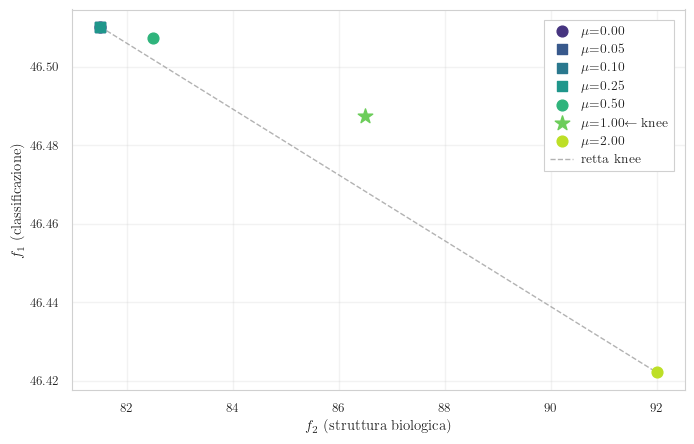

Salvato: knapsack_outputs/knapsack_sweep_diagnostics.pdf


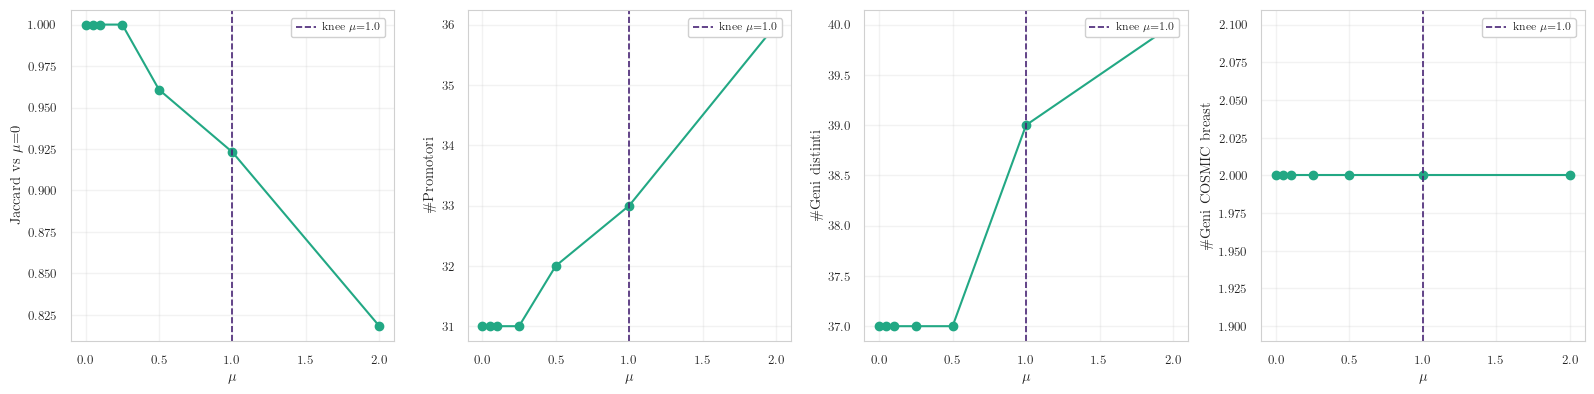

Salvato: knapsack_outputs/knapsack_wcosmic_sweep.pdf


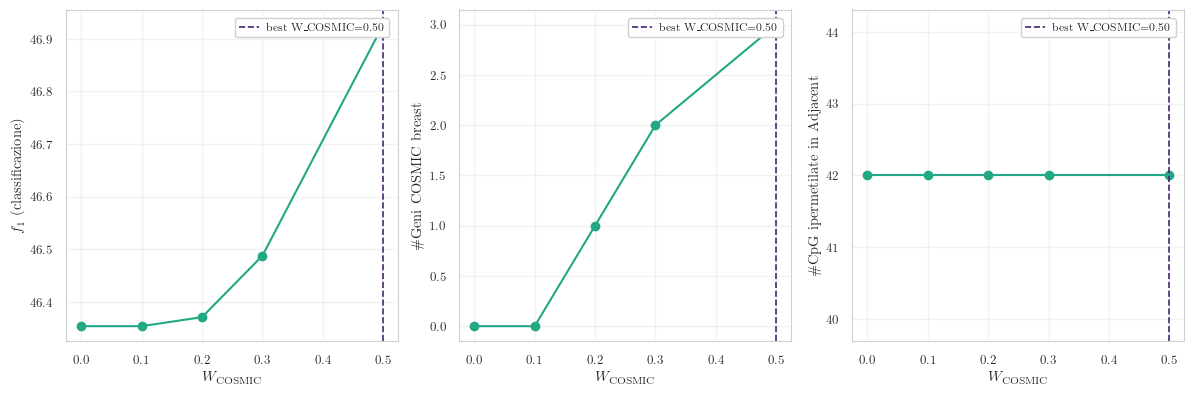

Salvato CSV: knapsack_outputs/knapsack_sweep_summary.csv

STEP 15 — Evaluation separazione (50 CpG finali)

  [Normal vs Adjacent (test)]  n=19 (0=10, 1=9)
  Silhouette    : 0.0288
  AUC CV5       : 0.4500 ± 0.3317
  mean|ΔM|      : 0.4991
  PCA PC1       : 0.310

  [Normal vs Tumor]  n=315 (0=10, 1=305)
  Silhouette    : 0.0958
  AUC CV5       : 0.9918 ± 0.0104
  mean|ΔM|      : 1.5935
  PCA PC1       : 0.263

STEP 16 — Confronto μ=0 vs set finale
                                      μ=0     finale
f1                                46.5102    46.9273
f2                                81.5000    86.5000
n_promoter                             31         34
n_island                               32         33
n_genes                                37         39
n_cosmic                                2          3
n_hyper                                41         42
Jaccard(mu0, finale)               0.8868

OUTPUT FINALE
  selected_cpgs_final : 50 CpG
  knee_mu             : 1.0
  best_

In [59]:
# ============================================================
# CpG KNAPSACK — MILP bi-obiettivo con sweep su μ  [v2]
#
# MODIFICHE rispetto a v1:
#   1) W_COSMIC: prior COSMIC breast cancer nel value di f1
#      v_i = W_COEF*c̃_i + W_DM*d̃_i + W_SCORE*s̃_i + W_COSMIC*is_cosmic_i
#      → sweep secondario su W_COSMIC con μ fissato al knee
#   2) MIN_HYPER: vincolo C8 che impone almeno MIN_HYPER CpG
#      ipERmetilate in Adjacent (coef_SVM > 0)
#   3) EVAL_TUMOR: flag per attivare/disattivare la valutazione
#      Normal vs Tumor (default False: studio è Normal vs Adjacent)
#
# Modello:
#   max  f1(x) + μ * f2_hat(x, y)
#   f1(x)   = Σ v_i * x_i      v_i = W_COEF*c̃ + W_DM*d̃ + W_SCORE*s̃ + W_COSMIC*cosmic_i
#   f2(x,y) = Σ_{i∈P} x_i  +  Σ_{i∈L} x_i  +  η * Σ_g y_g
#   f2_hat  = f2 / (K*(2+η))
#
# Vincoli hard:
#   C1: Σ x_i = K
#   C2: x_i + x_j ≤ 1        ∀ (i,j): |r_ij| ≥ CORR_THR
#   C3: Σ_{chr=c} x_i ≤ CHR_MAX
#   C4: Σ_{i∈A} x_i ≥ K_A*   (adattivo: min(K_A_NOMINAL, |A∩I|))
#   C5: x_i ≤ y_g             ∀ i: gene(i)=g
#   C6: Σ_{gene=g} x_i ≤ 2   ∀ g
#   C7: Σ_g y_g ≥ G_min*      (adattivo: min(G_MIN_NOMINAL, |G|))
#   C8: Σ_{coef>0} x_i ≥ MIN_HYPER   [NUOVO]
#
# Sweep principale: μ ∈ MU_GRID  (con W_COSMIC fissato)
# Sweep secondario: W_COSMIC ∈ W_COSMIC_GRID  (con μ=knee)
#
# Dipendenze nello scope (dal notebook):
#   final_cpgs, cpg_cols_current, M_train, M_test, y_train, y_test
#   step3_stats, cpg_candidates, poolA_cpgs, poolB_cpgs
#   cpg_to_chr, svm_pipe, man (manifest DataFrame già caricato)
#   apply_thesis_style, place_legend  (opzionale, per i plot)
# ============================================================

import numpy as np
import pandas as pd
import polars as pl
import pulp
import csv
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA

# ─────────────────────────────────────────────────────────────
# CONFIG — modifica qui
# ─────────────────────────────────────────────────────────────
BETA_PATH     = "/kaggle/input/datasets/rovieramariella/gse69914-parquet/GSE69914.parquet"
CGC_PATH      = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"

ID_COL        = "id_tissue"
LABEL_COL     = "label"
LABELS_ALL    = [0, 1, 2]           # 0=Normal, 1=Adjacent, 2=Tumor

K             = 50                  # CpG da selezionare
N_POOL        = 5000                # top-N da final_cpgs per |coef|
CHR_MAX       = 10                  # C3: max CpG per cromosoma
CORR_THR      = 0.85                # C2: soglia correlazione conflict edges
ETA           = 0.5                 # peso geni distinti in f2

# Pesi f1 (sommano a 1 senza COSMIC; COSMIC è bonus additivo)
W_COEF        = 0.5                 # peso |coef_SVM|
W_DM          = 0.2                 # peso |ΔM|
W_SCORE       = 0.3                 # peso RSKF score (invertito)

# [NUOVO] Prior COSMIC breast cancer nel value
# Sweep secondario su questo parametro (vedi STEP 10b)
W_COSMIC      = 0.3                 # valore usato nello sweep principale μ
W_COSMIC_GRID = [0.0, 0.1, 0.2, 0.3, 0.5]   # sweep secondario (μ fissato al knee)

# Vincoli
K_A_NOMINAL   = 25                  # C4: min Pool A (adattivo)
G_MIN_NOMINAL = 25                  # C7: min geni distinti (adattivo)
MAX_PER_GENE  = 2                   # C6: max CpG per gene

# [NUOVO] C8: min CpG ipERmetilate in Adjacent (coef_SVM > 0)
# Metti 0 per disattivare
MIN_HYPER     = 15

# Sweep principale μ
MU_GRID       = [0.0, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0]

# [NUOVO] Evaluation Normal vs Tumor: False = solo Normal vs Adjacent
EVAL_TUMOR    = True

CBC_TIME_LIMIT = 120               # secondi per ogni solve
EPS_M          = 1e-6
RANDOM_STATE   = 42

OUTDIR = Path("./knapsack_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────
def beta_to_m(b, eps=EPS_M):
    b = np.clip(b, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def rank_norm_asc(v):
    """Rank normalizzato [0,1]: valore più alto → rank più alto."""
    v = np.asarray(v, float)
    v2 = v.copy()
    if np.isnan(v2).any():
        v2 = np.where(np.isnan(v2), np.nanmin(v2) - 1.0, v2)
    r = np.argsort(np.argsort(v2))
    return r / max(1, len(v2) - 1)

def rank_norm_desc(v):
    """Rank normalizzato: valore più basso → rank più alto."""
    return 1.0 - rank_norm_asc(v)

def parse_first_gene(g):
    """
    Estrae il primo gene dal campo manifest (es. "BRCA1;TP53" → "BRCA1").
    Restituisce None se intergenico o NaN.
    """
    if g is None:
        return None
    s = str(g).strip()
    if s == "" or s.lower() == "nan":
        return None
    for sep in [";", ","]:
        if sep in s:
            s = s.split(sep)[0].strip()
            break
    return s if s != "" else None

def in_promoter(feat):
    if feat is None:
        return False
    s = str(feat)
    return any(k in s for k in ["TSS200", "TSS1500", "1stExon", "5'UTR", "5UTR"])

def in_island(ctx):
    if ctx is None:
        return False
    s = str(ctx)
    return "Island" in s and "Shore" not in s and "Shelf" not in s

def jaccard(s1, s2):
    s1, s2 = set(s1), set(s2)
    if len(s1 | s2) == 0:
        return 1.0
    return len(s1 & s2) / len(s1 | s2)

def knee_index(f1_vals, f2_vals):
    """
    Distanza massima dalla retta (μ=0) → (punto con f2 massimo osservato).
    Ignora punti saturati (f2 identico al precedente).
    """
    f1 = np.array(f1_vals, float)
    f2 = np.array(f2_vals, float)

    valid = np.ones(len(f2), dtype=bool)
    for i in range(1, len(f2)):
        if f2[i] == f2[i - 1]:
            valid[i] = False
    idx_v = np.where(valid)[0]
    if len(idx_v) < 2:
        return 0

    f1_n = (f1[idx_v] - f1[idx_v].min()) / max(f1[idx_v].max() - f1[idx_v].min(), 1e-12)
    f2_n = (f2[idx_v] - f2[idx_v].min()) / max(f2[idx_v].max() - f2[idx_v].min(), 1e-12)

    p0 = np.array([f2_n[0],  f1_n[0]])
    p1 = np.array([f2_n[-1], f1_n[-1]])
    d  = p1 - p0
    d_norm = d / max(np.linalg.norm(d), 1e-12)

    dists = [
        np.linalg.norm((np.array([f2_n[i], f1_n[i]]) - p0)
                       - np.dot(np.array([f2_n[i], f1_n[i]]) - p0, d_norm) * d_norm)
        for i in range(len(idx_v))
    ]
    return int(idx_v[np.argmax(dists)])

def eval_pair(name, X, ybin):
    """Valuta separazione tra due gruppi sulle CpG selezionate."""
    out = {}
    n0, n1 = int((ybin == 0).sum()), int((ybin == 1).sum())
    print(f"\n  [{name}]  n={X.shape[0]} (0={n0}, 1={n1})")
    if X.shape[0] < 10 or n0 == 0 or n1 == 0:
        print("  Campioni insufficienti.")
        return out

    try:
        out["silhouette"] = float(silhouette_score(X, ybin, metric="euclidean"))
        print(f"  Silhouette    : {out['silhouette']:.4f}")
    except Exception as e:
        out["silhouette"] = None
        print(f"  Silhouette    : N/A ({e})")

    try:
        Xsc  = StandardScaler().fit_transform(X)
        lr   = LogisticRegression(C=1.0, class_weight="balanced",
                                  max_iter=2000, random_state=RANDOM_STATE)
        n_cv = min(5, n0, n1)
        aucs = cross_val_score(lr, Xsc, ybin, cv=n_cv, scoring="roc_auc")
        out["auc_mean"] = float(aucs.mean())
        out["auc_std"]  = float(aucs.std())
        print(f"  AUC CV{n_cv}       : {out['auc_mean']:.4f} ± {out['auc_std']:.4f}")
    except Exception as e:
        out["auc_mean"] = out["auc_std"] = None
        print(f"  AUC CV        : N/A ({e})")

    m0, m1 = X[ybin == 0].mean(0), X[ybin == 1].mean(0)
    out["mean_abs_dM"] = float(np.abs(m1 - m0).mean())
    print(f"  mean|ΔM|      : {out['mean_abs_dM']:.4f}")

    try:
        pca = PCA(n_components=2, random_state=RANDOM_STATE)
        pca.fit(StandardScaler().fit_transform(X))
        out["pca_pc1"] = float(pca.explained_variance_ratio_[0])
        print(f"  PCA PC1       : {out['pca_pc1']:.3f}")
    except:
        out["pca_pc1"] = None

    return out


# ─────────────────────────────────────────────────────────────
# STEP 1 — Estrai coef SVM dalle final_cpgs
# ─────────────────────────────────────────────────────────────
print("=" * 70)
print("STEP 1 — Estrazione coef SVM")
print("=" * 70)

cols_all  = np.array(cpg_cols_current, dtype=object)
col_to_j  = {c: j for j, c in enumerate(cols_all.tolist())}
final_arr = np.array(final_cpgs, dtype=object)

raw_coef = np.array(svm_pipe.named_steps['svm'].coef_[0], dtype=float)
assert raw_coef.size == final_arr.size, (
    f"coef size {raw_coef.size} != final_cpgs size {final_arr.size}. "
    "Assicurati che svm_pipe sia fittato su X_train[:, final_cpgs]."
)
coef_final = raw_coef

print(f"final_cpgs        : {final_arr.size}")
print(f"coef range        : [{coef_final.min():.4f}, {coef_final.max():.4f}]")
print(f"  pos (ipermet.)  : {(coef_final > 0).sum()}")
print(f"  neg (ipomet.)   : {(coef_final < 0).sum()}")

# ─────────────────────────────────────────────────────────────
# STEP 2 — Carica M_all per evaluation (solo se EVAL_TUMOR=True)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 2 — Caricamento dati{'  [EVAL_TUMOR=True]' if EVAL_TUMOR else '  [solo Normal+Adjacent]'}")
print("=" * 70)

if EVAL_TUMOR:
    beta_all = (
        pl.read_parquet(BETA_PATH)
        .filter(pl.col(LABEL_COL).is_in(LABELS_ALL))
    )
else:
    beta_all = (
        pl.read_parquet(BETA_PATH)
        .filter(pl.col(LABEL_COL).is_in([0, 1]))
    )

y_all  = beta_all.select(LABEL_COL).to_numpy().ravel().astype(int)
id_all = beta_all.select(ID_COL).to_numpy().ravel()

meta_cols_set    = {ID_COL, LABEL_COL}
cpg_cols_parquet = [c for c in beta_all.columns if c not in meta_cols_set]
common           = [c for c in cpg_cols_parquet if c in col_to_j]

M_all_beta   = beta_all.select(common).to_numpy().astype(np.float32)
M_all        = beta_to_m(M_all_beta).astype(np.float32)
col_to_j_all = {c: i for i, c in enumerate(common)}

print(f"M_all shape       : {M_all.shape}")
print(f"y_all distrib     : " + str({int(v): int((y_all == v).sum()) for v in np.unique(y_all)}))

# ─────────────────────────────────────────────────────────────
# STEP 3 — Allinea RSKF score e |ΔM| a final_cpgs
# ─────────────────────────────────────────────────────────────
cand_arr   = np.array(cpg_candidates, dtype=object)
cand_score = np.array(step3_stats["score"], dtype=float)
cand_absdM = np.array(step3_stats["abs_deltaM_full"], dtype=float)
cand_to_i  = {c: i for i, c in enumerate(cand_arr.tolist())}

score_final = np.array(
    [cand_score[cand_to_i[c]] if c in cand_to_i else np.nan for c in final_arr],
    dtype=float
)
absdM_final = np.array(
    [cand_absdM[cand_to_i[c]] if c in cand_to_i else np.nan for c in final_arr],
    dtype=float
)
n_miss = int(np.isnan(score_final).sum())
if n_miss > 0:
    print(f"⚠ {n_miss} CpG non in cpg_candidates — score=nan, penalizzate.")

# ─────────────────────────────────────────────────────────────
# STEP 4 — Pool top-N per |coef|
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 4 — Pool top-{N_POOL} per |coef_SVM|")
print("=" * 70)

order_coef = np.argsort(-np.abs(coef_final))
pool_idx   = order_coef[:N_POOL]

pool_cpgs  = final_arr[pool_idx]
pool_coef  = coef_final[pool_idx]
pool_score = score_final[pool_idx]
pool_absdM = absdM_final[pool_idx]

# rimuovi CpG non in M_train
valid_mask = np.array([c in col_to_j for c in pool_cpgs], dtype=bool)
if not valid_mask.all():
    print(f"  ⚠ Rimosse {(~valid_mask).sum()} CpG non in M_train.")
    pool_cpgs  = pool_cpgs[valid_mask]
    pool_coef  = pool_coef[valid_mask]
    pool_score = pool_score[valid_mask]
    pool_absdM = pool_absdM[valid_mask]

n_p = len(pool_cpgs)
print(f"Pool effettivo    : {n_p} CpG")
print(f"|coef| range      : [{np.abs(pool_coef).min():.4f}, {np.abs(pool_coef).max():.4f}]")

# ─────────────────────────────────────────────────────────────
# STEP 5 — Pool A / B
# ─────────────────────────────────────────────────────────────
_poolA_set = set(np.array(poolA_cpgs, dtype=object).tolist()) if poolA_cpgs is not None else set()
_poolB_set = set(np.array(poolB_cpgs, dtype=object).tolist()) if poolB_cpgs is not None else set()

poolA_in_pool = [c for c in pool_cpgs if c in _poolA_set]

# C4 adattivo
K_A_use = min(K_A_NOMINAL, len(poolA_in_pool))
print(f"Pool A nel pool   : {len(poolA_in_pool)}  →  K_A_use={K_A_use} (nominale {K_A_NOMINAL})")
if K_A_use < K_A_NOMINAL:
    print(f"  ⚠ K_A ridotto: solo {len(poolA_in_pool)} CpG Pool A nel pool.")

# ─────────────────────────────────────────────────────────────
# STEP 6 — Conflict edges (correlazione su M_train)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 6 — Conflict edges")
print("=" * 70)

jj_pool = np.array([col_to_j[c] for c in pool_cpgs], dtype=int)
Z = M_train[:, jj_pool].astype(np.float64)
Z = (Z - Z.mean(0)) / (Z.std(0, ddof=1) + 1e-12)
C_corr = (Z.T @ Z) / (Z.shape[0] - 1)

i_u, j_u = np.where(np.triu(np.abs(C_corr) >= CORR_THR, k=1))
conflict_pairs = list(zip(i_u.tolist(), j_u.tolist()))

tot_pairs = n_p * (n_p - 1) // 2
print(f"Conflict edges    : {len(conflict_pairs):,} / {tot_pairs:,} "
      f"({100*len(conflict_pairs)/max(1,tot_pairs):.3f}%) a |r|≥{CORR_THR}")

# ─────────────────────────────────────────────────────────────
# STEP 7 — Attributi genomici dal manifest
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 7 — Attributi genomici + COSMIC prior")
print("=" * 70)

# usa 'man' già caricato nel notebook
man_sub = man.loc[
    man["IlmnID"].isin(pool_cpgs.tolist()),
    ["IlmnID", "UCSC_RefGene_Name", "UCSC_RefGene_Group", "Relation_to_UCSC_CpG_Island"]
].copy()
man_sub["IlmnID"] = man_sub["IlmnID"].astype(str)

cpg_gene_dict   = dict(zip(man_sub["IlmnID"], man_sub["UCSC_RefGene_Name"].fillna("")))
cpg_feat_dict   = dict(zip(man_sub["IlmnID"], man_sub["UCSC_RefGene_Group"].fillna("")))
cpg_island_dict = dict(zip(man_sub["IlmnID"], man_sub["Relation_to_UCSC_CpG_Island"].fillna("")))

chr_arr   = np.array([cpg_to_chr.get(c, "")                         for c in pool_cpgs], dtype=object)
gene_arr  = np.array([parse_first_gene(cpg_gene_dict.get(c, None))  for c in pool_cpgs], dtype=object)
is_prom   = np.array([in_promoter(cpg_feat_dict.get(c, ""))         for c in pool_cpgs], dtype=int)
is_island = np.array([in_island(cpg_island_dict.get(c, ""))         for c in pool_cpgs], dtype=int)

# geni annotati (per C5-C7)
genes_pool = sorted({g for g in gene_arr.tolist() if g is not None})

# C7 adattivo
G_min_use = min(G_MIN_NOMINAL, len(genes_pool))

# ── [NUOVO] Prior COSMIC breast cancer ──────────────────────
cgc = pd.read_csv(CGC_PATH, sep="\t")
mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
COSMIC_BREAST_GENES = set(cgc.loc[mask_breast, "GENE_SYMBOL"].astype(str))

is_cosmic = np.array(
    [1.0 if (gene_arr[i] is not None and gene_arr[i] in COSMIC_BREAST_GENES) else 0.0
     for i in range(n_p)],
    dtype=float
)

# ── [NUOVO] Flag ipERmetilazione (coef_SVM > 0 = ipermet. in Adjacent)
is_hyper = np.array([1 if pool_coef[i] > 0 else 0 for i in range(n_p)], dtype=int)

print(f"CpG con promotore : {is_prom.sum()}")
print(f"CpG in island     : {is_island.sum()}")
print(f"Geni distinti pool: {len(genes_pool)}  →  G_min_use={G_min_use} (nominale {G_MIN_NOMINAL})")
print(f"Geni COSMIC breast: {len(COSMIC_BREAST_GENES)}")
print(f"CpG COSMIC nel pool: {int(is_cosmic.sum())}  "
      f"({100*is_cosmic.mean():.1f}% del pool)")
print(f"CpG ipermet. pool : {is_hyper.sum()}  (coef>0)")
print(f"CpG ipomet. pool  : {(1-is_hyper).sum()}  (coef<0)")

if MIN_HYPER > is_hyper.sum():
    print(f"  ⚠ MIN_HYPER={MIN_HYPER} > CpG ipermet. nel pool ({is_hyper.sum()}). "
          f"Abbassa MIN_HYPER o aumenta N_POOL.")

# upper bound deterministico di f2
F2_NORM = float(K * (2 + ETA))

# ─────────────────────────────────────────────────────────────
# STEP 8 — Funzione valore f1 (rank-normalizzata sul pool fisso)
#
# [MODIFICATO] v_i = W_COEF*c̃ + W_DM*d̃ + W_SCORE*s̃ + W_COSMIC*cosmic_i
# I rank sono calcolati sul pool fisso → non confrontabili tra run diverse.
# W_COSMIC è bonus additivo (non entra nella normalizzazione dei pesi).
# ─────────────────────────────────────────────────────────────
def compute_value(w_cosmic):
    r_coef  = rank_norm_asc(np.abs(pool_coef))
    r_dM    = rank_norm_asc(pool_absdM)
    r_score = rank_norm_desc(pool_score)
    return W_COEF * r_coef + W_DM * r_dM + W_SCORE * r_score + w_cosmic * is_cosmic

# value per lo sweep principale (W_COSMIC fissato)
value_main = compute_value(W_COSMIC)

print(f"\nf1 value range    : [{value_main.min():.4f}, {value_main.max():.4f}]  (W_COSMIC={W_COSMIC})")
print(f"f2 norm factor    : {F2_NORM:.1f}")

# ─────────────────────────────────────────────────────────────
# STEP 9 — Funzione MILP
# ─────────────────────────────────────────────────────────────
def solve_milp(mu: float, value: np.ndarray, label: str = ""):
    """
    Risolve il MILP per un dato (μ, value).
    Restituisce dict con risultati oppure None se infeasible.
    """
    prob = pulp.LpProblem(f"CpG_Knapsack_{label}_mu{mu:.3f}", pulp.LpMaximize)

    x   = [pulp.LpVariable(f"x_{i}", cat="Binary") for i in range(n_p)]
    y_g = {g: pulp.LpVariable(f"yg_{i}", cat="Binary") for i, g in enumerate(genes_pool)}

    # ── Obiettivo ────────────────────────────────────────────
    f1_expr = pulp.lpSum(float(value[i]) * x[i] for i in range(n_p))
    f2_expr = (
        pulp.lpSum(x[i] for i in range(n_p) if is_prom[i])
        + pulp.lpSum(x[i] for i in range(n_p) if is_island[i])
        + ETA * pulp.lpSum(y_g[g] for g in genes_pool)
    )
    f2_hat = f2_expr / F2_NORM
    prob  += f1_expr + mu * f2_hat

    # ── C1: cardinalità ──────────────────────────────────────
    prob += pulp.lpSum(x) == K, "C1"

    # ── C2: conflict edges ───────────────────────────────────
    for idx, (i, j) in enumerate(conflict_pairs):
        prob += x[i] + x[j] <= 1, f"C2_{idx}"

    # ── C3: max per cromosoma ────────────────────────────────
    for ch in sorted(set(chr_arr.tolist()) - {""}):
        prob += (
            pulp.lpSum(x[i] for i in range(n_p) if chr_arr[i] == ch)
            <= CHR_MAX, f"C3_{ch}"
        )

    # ── C4: Pool A min (adattivo) ────────────────────────────
    if K_A_use > 0 and len(_poolA_set) > 0:
        prob += (
            pulp.lpSum(x[i] for i in range(n_p) if pool_cpgs[i] in _poolA_set)
            >= K_A_use, "C4"
        )

    # ── C5: link CpG → gene ──────────────────────────────────
    for i in range(n_p):
        g = gene_arr[i]
        if g is not None and g in y_g:
            prob += x[i] <= y_g[g], f"C5_{i}"

    # ── C6: max CpG per gene ─────────────────────────────────
    for g in genes_pool:
        idx_g = [i for i in range(n_p) if gene_arr[i] == g]
        if idx_g:
            prob += pulp.lpSum(x[i] for i in idx_g) <= MAX_PER_GENE, f"C6_{g}"

    # ── C7: min geni distinti (adattivo) ─────────────────────
    if G_min_use > 0:
        prob += pulp.lpSum(y_g[g] for g in genes_pool) >= G_min_use, "C7"

    # ── C8 [NUOVO]: min CpG ipERmetilate in Adjacent ─────────
    if MIN_HYPER > 0:
        n_hyper_in_pool = int(is_hyper.sum())
        if n_hyper_in_pool >= MIN_HYPER:
            prob += (
                pulp.lpSum(x[i] for i in range(n_p) if is_hyper[i])
                >= MIN_HYPER, "C8_hyper_min"
            )
        else:
            print(f"  ⚠ C8 disattivato: solo {n_hyper_in_pool} CpG ipermet. nel pool < MIN_HYPER={MIN_HYPER}")

    # ── Solve ────────────────────────────────────────────────
    solver     = pulp.PULP_CBC_CMD(msg=False, timeLimit=CBC_TIME_LIMIT)
    status     = prob.solve(solver)
    status_str = pulp.LpStatus.get(status, str(status))
    obj_val    = pulp.value(prob.objective)

    if obj_val is None or status_str not in ["Optimal", "Feasible"]:
        print(f"  [{label} μ={mu:.3f}] Status={status_str} — INFEASIBLE")
        return None

    sel_idx = np.array([i for i in range(n_p) if (pulp.value(x[i]) or 0) > 0.5], dtype=int)
    if sel_idx.size != K:
        print(f"  [{label} μ={mu:.3f}] Selezionato {sel_idx.size}/{K} — SKIP")
        return None

    selected = pool_cpgs[sel_idx].tolist()

    f1_val = float(sum(value[i] for i in sel_idx))
    f2_val = float(
        is_prom[sel_idx].sum()
        + is_island[sel_idx].sum()
        + ETA * len({gene_arr[i] for i in sel_idx if gene_arr[i] is not None})
    )
    f2_hat_val = f2_val / F2_NORM
    n_cosmic   = int(is_cosmic[sel_idx].sum())
    n_hyper_sel= int(is_hyper[sel_idx].sum())

    return {
        "status":      status_str,
        "f1":          f1_val,
        "f2":          f2_val,
        "f2_hat":      f2_hat_val,
        "n_promoter":  int(is_prom[sel_idx].sum()),
        "n_island":    int(is_island[sel_idx].sum()),
        "n_genes":     len({gene_arr[i] for i in sel_idx if gene_arr[i] is not None}),
        "n_cosmic":    n_cosmic,
        "n_hyper":     n_hyper_sel,
        "n_hypo":      K - n_hyper_sel,
        "selected":    selected,
        "sel_idx":     sel_idx,
    }


# ─────────────────────────────────────────────────────────────
# STEP 10a — Sweep principale su μ (W_COSMIC fissato)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 10a — Sweep μ  (W_COSMIC={W_COSMIC} fissato)")
print("=" * 70)

sweep_results = []
sel_mu0       = None

for mu in MU_GRID:
    print(f"\n[μ={mu:.3f}] Solving...")
    res = solve_milp(mu, value_main, label="main")
    if res is None:
        sweep_results.append({"mu": mu, "f1": np.nan, "f2": np.nan,
                               "f2_hat": np.nan, "status": "FAILED",
                               "jaccard_vs_0": np.nan, "saturated": False,
                               "n_promoter": np.nan, "n_island": np.nan,
                               "n_genes": np.nan, "n_cosmic": np.nan,
                               "n_hyper": np.nan, "selected": []})
        continue

    if mu == 0.0:
        sel_mu0 = res["selected"]

    jacc = jaccard(res["selected"], sel_mu0) if sel_mu0 else 1.0
    delta = (mu * res["f2_hat"]) / max(res["f1"], 1e-12)

    sat = (len(sweep_results) > 0
           and not np.isnan(sweep_results[-1].get("f2", np.nan))
           and res["f2"] == sweep_results[-1]["f2"])

    row = {"mu": mu, **res, "jaccard_vs_0": jacc, "delta": delta, "saturated": sat}
    sweep_results.append(row)

    print(f"  Status     : {res['status']}")
    print(f"  f1         : {res['f1']:.4f}")
    print(f"  f2         : {res['f2']:.4f}  (f2_hat={res['f2_hat']:.4f})")
    print(f"  Δ(bio/clf) : {delta:.4f}")
    print(f"  Jaccard(0) : {jacc:.4f}")
    print(f"  Promotori  : {res['n_promoter']}  |  Islands: {res['n_island']}  |  Geni: {res['n_genes']}")
    print(f"  COSMIC     : {res['n_cosmic']}  |  Ipermet: {res['n_hyper']}  |  Ipomet: {res['n_hypo']}")
    print(f"  Saturato   : {sat}")

# ─────────────────────────────────────────────────────────────
# STEP 11 — Selezione knee
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 11 — Selezione knee")
print("=" * 70)

valid_res = [r for r in sweep_results if not np.isnan(r["f1"])]
f1_vals   = [r["f1"] for r in valid_res]
f2_vals   = [r["f2"] for r in valid_res]

k_idx    = knee_index(f1_vals, f2_vals)
knee_res = valid_res[k_idx]
knee_mu  = knee_res["mu"]

print(f"Knee selezionato  : μ = {knee_mu:.3f}")
print(f"  f1              : {knee_res['f1']:.4f}")
print(f"  f2              : {knee_res['f2']:.4f}  (f2_hat={knee_res['f2_hat']:.4f})")
print(f"  Jaccard vs μ=0  : {knee_res['jaccard_vs_0']:.4f}")
print(f"  Promotori       : {knee_res['n_promoter']}")
print(f"  Islands         : {knee_res['n_island']}")
print(f"  Geni distinti   : {knee_res['n_genes']}")
print(f"  COSMIC breast   : {knee_res['n_cosmic']}")
print(f"  Ipermet./Ipomet.: {knee_res['n_hyper']} / {knee_res['n_hypo']}")

selected_cpgs_final = knee_res["selected"]
print(f"\nSet provvisorio (knee, sweep μ): {len(selected_cpgs_final)} CpG")

# ─────────────────────────────────────────────────────────────
# STEP 10b — Sweep secondario su W_COSMIC (μ fissato al knee)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 10b — Sweep W_COSMIC  (μ={knee_mu} fissato)")
print("=" * 70)

cosmic_sweep_results = []

for wc in W_COSMIC_GRID:
    print(f"\n[W_COSMIC={wc:.2f}] Solving...")
    val_wc = compute_value(wc)
    res    = solve_milp(knee_mu, val_wc, label=f"cosmic{wc:.2f}")
    if res is None:
        cosmic_sweep_results.append({
            "w_cosmic": wc, "f1": np.nan, "f2": np.nan,
            "n_cosmic": np.nan, "n_hyper": np.nan, "status": "FAILED", "selected": []
        })
        continue

    jacc_vs_wc0 = jaccard(res["selected"],
                          next((r["selected"] for r in cosmic_sweep_results
                                if r.get("w_cosmic") == 0.0 and r["selected"]), []))

    row = {"w_cosmic": wc, **res, "jaccard_vs_wc0": jacc_vs_wc0}
    cosmic_sweep_results.append(row)

    print(f"  f1         : {res['f1']:.4f}")
    print(f"  f2         : {res['f2']:.4f}")
    print(f"  COSMIC     : {res['n_cosmic']}  |  Ipermet: {res['n_hyper']}  |  Ipomet: {res['n_hypo']}")
    print(f"  Jaccard(wc=0): {jacc_vs_wc0:.4f}")

# Scegli W_COSMIC migliore: massimo n_cosmic a parità di f1 ≥ f1(wc=0)*0.999
wc_valid = [r for r in cosmic_sweep_results if not np.isnan(r.get("f1", np.nan))]
if wc_valid:
    f1_wc0 = next((r["f1"] for r in wc_valid if r["w_cosmic"] == 0.0), wc_valid[0]["f1"])
    candidates_wc = [r for r in wc_valid if r["f1"] >= f1_wc0 * 0.999]
    best_wc_res   = max(candidates_wc, key=lambda r: r["n_cosmic"]) if candidates_wc else wc_valid[-1]
    best_w_cosmic = best_wc_res["w_cosmic"]
    selected_cpgs_final = best_wc_res["selected"]

    print(f"\nW_COSMIC ottimale : {best_w_cosmic:.2f}")
    print(f"  COSMIC breast   : {best_wc_res['n_cosmic']}")
    print(f"  f1              : {best_wc_res['f1']:.4f}  (perdita vs wc=0: "
          f"{100*(f1_wc0 - best_wc_res['f1'])/max(f1_wc0,1e-12):.3f}%)")
    print(f"\nSet finale (knee + best W_COSMIC): {len(selected_cpgs_final)} CpG")
else:
    best_w_cosmic = W_COSMIC
    print("⚠ Sweep W_COSMIC fallito — uso il set del knee μ.")

# ─────────────────────────────────────────────────────────────
# STEP 12 — Plot curva di trade-off (sweep μ)
# ─────────────────────────────────────────────────────────────
try:
    apply_thesis_style(use_tex=True, legend_position="upper right")
except:
    pass

cmap = plt.cm.viridis

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = cmap(np.linspace(0.15, 0.9, len(valid_res)))

for r, col in zip(valid_res, colors):
    marker = "*" if r["mu"] == knee_mu else ("s" if r.get("saturated") else "o")
    size   = 120 if r["mu"] == knee_mu else 60
    ax.scatter(r["f2"], r["f1"], color=col, marker=marker, s=size, zorder=3,
               label=f"$\mu$={r['mu']:.2f}" + ("$\leftarrow $ knee" if r["mu"] == knee_mu else ""))

p0 = np.array([f2_vals[0],  f1_vals[0]])
p1 = np.array([max(f2_vals), f1_vals[np.argmax(f2_vals)]])
ax.plot([p0[0], p1[0]], [p0[1], p1[1]], "--", color="gray", linewidth=1.0, alpha=0.6, label="retta knee")

ax.set_xlabel(r"$f_2$ (struttura biologica)")
ax.set_ylabel(r"$f_1$ (classificazione)")
try:
    place_legend(ax)
except:
    ax.legend(fontsize=8, ncol=2)

fig.tight_layout()
fig.savefig(OUTDIR / "knapsack_tradeoff_curve.pdf", dpi=300, bbox_inches="tight")
print(f"\nSalvato: {OUTDIR}/knapsack_tradeoff_curve.pdf")
plt.show()

# ─────────────────────────────────────────────────────────────
# STEP 13 — Plot diagnostiche sweep μ
# ─────────────────────────────────────────────────────────────
mu_ax = [r["mu"] for r in valid_res]

fig2, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax_i, (key, label) in zip(axes, [
    ("jaccard_vs_0", "Jaccard vs $\mu$=0"),
    ("n_promoter",   "\#Promotori"),
    ("n_genes",      "\#Geni distinti"),
    ("n_cosmic",     "\#Geni COSMIC breast"),   # [NUOVO]
]):
    vals = [r[key] for r in valid_res]
    ax_i.plot(mu_ax, vals, marker="o", color=cmap(0.6), linewidth=1.5)
    ax_i.axvline(knee_mu, linestyle="--", color=cmap(0.1), linewidth=1.2,
                 label=f"knee $\mu$={knee_mu}")
    ax_i.set_xlabel(r"$\mu$")
    ax_i.set_ylabel(label)
    ax_i.legend(fontsize=8)

fig2.tight_layout()
fig2.savefig(OUTDIR / "knapsack_sweep_diagnostics.pdf", dpi=300, bbox_inches="tight")
print(f"Salvato: {OUTDIR}/knapsack_sweep_diagnostics.pdf")
plt.show()

# ─────────────────────────────────────────────────────────────
# STEP 13b — Plot sweep W_COSMIC  [NUOVO]
# ─────────────────────────────────────────────────────────────
if len(wc_valid) >= 2:
    fig3, axes3 = plt.subplots(1, 3, figsize=(12, 4))
    wc_ax = [r["w_cosmic"] for r in wc_valid]

    for ax_i, (key, label) in zip(axes3, [
        ("f1",       "$f_1$ (classificazione)"),
        ("n_cosmic", "\#Geni COSMIC breast"),
        ("n_hyper",  "\#CpG ipermetilate in Adjacent"),
    ]):
        vals = [r[key] for r in wc_valid]
        ax_i.plot(wc_ax, vals, marker="o", color=cmap(0.6), linewidth=1.5)
        ax_i.axvline(best_w_cosmic, linestyle="--", color=cmap(0.1), linewidth=1.2,
                     label=f"best W_COSMIC={best_w_cosmic:.2f}")
        ax_i.set_xlabel(r"$W_{\rm COSMIC}$")
        ax_i.set_ylabel(label)
        ax_i.legend(fontsize=8)

    fig3.tight_layout()
    fig3.savefig(OUTDIR / "knapsack_wcosmic_sweep.pdf", dpi=300, bbox_inches="tight")
    print(f"Salvato: {OUTDIR}/knapsack_wcosmic_sweep.pdf")
    plt.show()

# ─────────────────────────────────────────────────────────────
# STEP 14 — Salva CSV summary sweep μ
# ─────────────────────────────────────────────────────────────
csv_path = OUTDIR / "knapsack_sweep_summary.csv"
fieldnames = ["mu", "status", "f1", "f2", "f2_hat", "delta",
              "jaccard_vs_0", "n_promoter", "n_island", "n_genes",
              "n_cosmic", "n_hyper", "n_hypo", "saturated"]

with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for r in sweep_results:
        writer.writerow({k: r.get(k, "") for k in fieldnames})

print(f"Salvato CSV: {csv_path}")

# ─────────────────────────────────────────────────────────────
# STEP 15 — Valutazione separazione sulle 50 CpG finali
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 15 — Evaluation separazione (50 CpG finali)")
print("=" * 70)

jj_test = np.array([col_to_j[c]     for c in selected_cpgs_final if c in col_to_j],     dtype=int)
jj_eval = np.array([col_to_j_all[c] for c in selected_cpgs_final if c in col_to_j_all], dtype=int)

eval_results_final = {}

# Normal vs Adjacent — solo test set (no leakage)
mask_na = np.isin(y_test, [0, 1])
X_na    = M_test[mask_na][:, jj_test]
y_na    = (y_test[mask_na] == 1).astype(int)
eval_results_final["Normal_vs_Adjacent_test"] = eval_pair("Normal vs Adjacent (test)", X_na, y_na)

# Normal vs Tumor — opzionale
if EVAL_TUMOR:
    mask_tum     = (y_all == 2)
    mask_norm_te = (y_test == 0)
    if mask_tum.sum() > 0:
        X_tum  = M_all[mask_tum][:, jj_eval]
        X_norm = M_test[mask_norm_te][:, jj_test]
        X_nt   = np.vstack([X_norm, X_tum])
        y_nt   = np.array([0] * X_norm.shape[0] + [1] * X_tum.shape[0], dtype=int)
        eval_results_final["Normal_vs_Tumor"] = eval_pair("Normal vs Tumor", X_nt, y_nt)
    else:
        print("  [Normal vs Tumor] Nessun campione Tumor nel parquet caricato.")

# ─────────────────────────────────────────────────────────────
# STEP 16 — Confronto μ=0 vs finale
# ─────────────────────────────────────────────────────────────
res_mu0 = next((r for r in valid_res if r["mu"] == 0.0), None)
if res_mu0 and sel_mu0:
    print("\n" + "=" * 70)
    print("STEP 16 — Confronto μ=0 vs set finale")
    print("=" * 70)

    fin = best_wc_res if wc_valid else knee_res
    print(f"{'':30s} {'μ=0':>10s} {'finale':>10s}")
    print(f"{'f1':30s} {res_mu0['f1']:>10.4f} {fin['f1']:>10.4f}")
    print(f"{'f2':30s} {res_mu0['f2']:>10.4f} {fin['f2']:>10.4f}")
    print(f"{'n_promoter':30s} {res_mu0['n_promoter']:>10} {fin['n_promoter']:>10}")
    print(f"{'n_island':30s} {res_mu0['n_island']:>10} {fin['n_island']:>10}")
    print(f"{'n_genes':30s} {res_mu0['n_genes']:>10} {fin['n_genes']:>10}")
    print(f"{'n_cosmic':30s} {res_mu0['n_cosmic']:>10} {fin['n_cosmic']:>10}")
    print(f"{'n_hyper':30s} {res_mu0['n_hyper']:>10} {fin['n_hyper']:>10}")
    print(f"{'Jaccard(mu0, finale)':30s} {jaccard(sel_mu0, selected_cpgs_final):>10.4f}")

# ─────────────────────────────────────────────────────────────
# OUTPUT FINALE
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("OUTPUT FINALE")
print("=" * 70)
print(f"  selected_cpgs_final : {len(selected_cpgs_final)} CpG")
print(f"  knee_mu             : {knee_mu}")
print(f"  best_w_cosmic       : {best_w_cosmic}")
print(f"  sweep_results       : lista sweep μ")
print(f"  cosmic_sweep_results: lista sweep W_COSMIC")
print(f"  eval_results_final  : metriche separazione")
print(f"  OUTDIR              : {OUTDIR}")
print("=" * 70)

In [62]:
import pandas as pd
from pathlib import Path

# --- PATH ---
CGC_PATH = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"

# Manifest EPIC (se sei su EPIC). Se stai su 450K, cambia manifest.
MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/humanmethylation450-15017482-v1-2-manifest/humanmethylation450_15017482_v1-2_manifest.csv"

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

# --- INPUT: 50 CpG dalla FS ---
selected_cpgs = [str(x) for x in list(selected_cpgs_final )]
print(f"Selected CpG: {len(selected_cpgs)}")

# --- LOAD COSMIC ---
cgc = pd.read_csv(CGC_PATH, sep="\t")

# --- FILTER BREAST (SOMATIC) ---
mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
cgc_breast = cgc.loc[mask_breast].copy()
genes_cgc_breast = set(cgc_breast["GENE_SYMBOL"].astype(str))

print(f"Geni COSMIC breast: {len(genes_cgc_breast)}")

# ============================================================
# CpG -> GENE(S) dal manifest
# ============================================================

def read_illumina_manifest_csv(path: str) -> pd.DataFrame:
    # trova header vero (riga che contiene IlmnID)
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if "IlmnID" in line.split(","):
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Manifest header not found (no 'IlmnID' line detected).")

    df = pd.read_csv(
        path,
        sep=",",
        header=header_idx,
        engine="python",
        on_bad_lines="skip",
    )
    df.columns = [c.strip() for c in df.columns]
    df = df.dropna(axis=1, how="all")
    return df

man = read_illumina_manifest_csv(MANIFEST_PATH)

# colonne standard EPIC: IlmnID e UCSC_RefGene_Name
if "IlmnID" not in man.columns:
    raise ValueError(f"Colonna IlmnID non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")
if "UCSC_RefGene_Name" not in man.columns:
    raise ValueError(f"Colonna UCSC_RefGene_Name non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")

# subset alle 50 CpG
m50 = man.loc[man["IlmnID"].isin(selected_cpgs), ["IlmnID", "UCSC_RefGene_Name"]].copy()
missing = sorted(set(selected_cpgs) - set(m50["IlmnID"].astype(str)))
print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs)}")
if missing:
    print(f"ATTENZIONE: CpG mancanti nel manifest: {len(missing)} (mostro max 15): {missing[:15]}")
    print("Se sono tante, stai usando il manifest sbagliato (EPIC vs 450K).")

# explode geni (campo separato da ';')
m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].astype(str).str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni associati alle 50 CpG (unique): {len(genes_50)}")

# salva mapping CpG->gene
m50.rename(columns={"IlmnID": "CpG"}).to_csv(OUTDIR / "cpg50_to_genes.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'cpg50_to_genes.tsv'}")

# ============================================================
# INTERSECTION: (GENES from 50 CpGs) ∩ (COSMIC breast)
# ============================================================

genes_overlap = sorted(genes_50 & genes_cgc_breast)
print(f"Geni in comune (genes_50CpG ∩ COSMIC breast): {len(genes_overlap)}")

# --- TABELLINA FINALE (gene-level, come il tuo) ---
table = (
    cgc_breast[cgc_breast["GENE_SYMBOL"].astype(str).isin(genes_overlap)]
    [["GENE_SYMBOL", "ROLE_IN_CANCER", "TIER", "TUMOUR_TYPES_SOMATIC"]]
    .drop_duplicates()
    .sort_values("GENE_SYMBOL")
)

display(table)

# opzionale: salva
table.to_csv(OUTDIR / "genes_overlap_COSMIC_breast_from_50cpg.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'genes_overlap_COSMIC_breast_from_50cpg.tsv'}")


Selected CpG: 50
Geni COSMIC breast: 44
CpG trovate nel manifest: 50 / 50
Geni associati alle 50 CpG (unique): 41
Saved: post_fs_annotation/cpg50_to_genes.tsv
Geni in comune (genes_50CpG ∩ COSMIC breast): 3


,GENE_SYMBOL,ROLE_IN_CANCER,TIER,TUMOUR_TYPES_SOMATIC
50,BARD1,TSG,1,breast cancer
74,BRCA2,TSG,1,"breast, ovarian, pancreatic"
399,MAP2K4,"oncogene, TSG",1,"pancreatic, breast, colorectal"


Saved: post_fs_annotation/genes_overlap_COSMIC_breast_from_50cpg.tsv


In [64]:
# ============================================================
# ANNOTAZIONE 50 CpG — cella unica
# Richiede nello scope:
#   - selected_cpgs   : list di 50 CpG
#   - final_cpgs      : array 5000 CpG
#   - final_arr       : np.array delle 5000 CpG (allineato a coef_final)
#   - coef_final      : np.array dei coef SVM (allineato a final_arr)
#   - man             : DataFrame manifest già caricato
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

selected_cpgs_list = [str(x) for x in list(selected_cpgs_final )]
coef_map = dict(zip(final_arr.tolist(), coef_final.tolist()))

# ── 1. CpG -> gene dal manifest ──
m50 = man.loc[
    man["IlmnID"].isin(selected_cpgs_list),
    ["IlmnID", "UCSC_RefGene_Name"]
].copy()

print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs_list)}")
missing = set(selected_cpgs_list) - set(m50["IlmnID"].astype(str))
if missing:
    print(f"CpG NON trovate ({len(missing)}): {list(missing)[:10]}")
    print("Se sono molte -> manifest sbagliato (450K su dati EPIC)")

m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()
m50 = m50.rename(columns={"IlmnID": "CpG"})
m50["coef_svm"]  = m50["CpG"].map(coef_map)
m50["direction"] = m50["coef_svm"].apply(
    lambda x: "hypermethylated_in_adj" if (x is not None and x > 0)
              else "hypomethylated_in_adj" if (x is not None and x < 0)
              else "unknown"
)

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni unici associati alle 50 CpG: {len(genes_50)}")

# ── 2. Overlap con geni noti nel field cancerization ──
known_field_genes = {
    # lista originale
    'RASSF1', 'CDH1', 'APC', 'BRCA1', 'BRCA2',
    'CDKN2A', 'MLH1', 'GSTP1', 'DAPK1', 'RUNX3',
    'SFRP1', 'SFRP2', 'SFRP4', 'SFRP5', 'WIF1', 'DKK1', 'DKK3',
    'HOXA5', 'HOXA9', 'HOXA10', 'HOXB13',
    'TBX2', 'TBX3', 'TBX5',
    'TWIST1', 'TWIST2', 'SNAI1', 'SNAI2', 'ZEB1', 'ZEB2',
    'SLIT2', 'ROBO1', 'PCDH10', 'NDRG2',
    # aggiunte dai risultati
    'YAP1', 'KMT2A', 'XPC',        # dataset 2
    'DAB2IP', 'CCND2', 'RBPJ',     # dataset 3
    'DACT2', 'SMPD3',
}

hits = genes_50 & known_field_genes
print(f"\nGeni noti nel field cancerization: {len(hits)}")
if hits:
    print(f"  {sorted(hits)}")
    hits_df = m50[m50["GENE_SYMBOL"].isin(hits)][
        ["CpG", "GENE_SYMBOL", "direction", "coef_svm"]
    ].drop_duplicates().sort_values("GENE_SYMBOL")
    print(hits_df.to_string(index=False))
else:
    print("  Nessun gene noto trovato.")

# ── 3. Tabella completa per tesi ──
table_full = (
    m50[["CpG", "GENE_SYMBOL", "direction", "coef_svm"]]
    .drop_duplicates()
    .sort_values(["direction", "coef_svm"], ascending=[True, False])
)
print(f"\nTabella completa ({len(table_full)} righe):")
print(table_full.to_string(index=False))
table_full.to_csv(OUTDIR / "50cpg_annotated.tsv", sep="\t", index=False)
print(f"\nSalvato: {OUTDIR / '50cpg_annotated.tsv'}")

# ── 4. Sommario direzioni ──
n_hyper = (m50["direction"] == "hypermethylated_in_adj").sum()
n_hypo  = (m50["direction"] == "hypomethylated_in_adj").sum()
print(f"\nHypermethylated in Adjacent : {n_hyper}")
print(f"Hypomethylated in Adjacent  : {n_hypo}")

CpG trovate nel manifest: 50 / 50
Geni unici associati alle 50 CpG: 41

Geni noti nel field cancerization: 4
  ['BRCA2', 'CCND2', 'DACT2', 'RBPJ']
       CpG GENE_SYMBOL              direction  coef_svm
cg26458617       BRCA2 hypermethylated_in_adj  0.007303
cg17296482       CCND2 hypermethylated_in_adj  0.009458
cg18566594       CCND2 hypermethylated_in_adj  0.011732
cg05070558       DACT2 hypermethylated_in_adj  0.012221
cg22002629        RBPJ hypermethylated_in_adj  0.011967

Tabella completa (43 righe):
       CpG GENE_SYMBOL              direction  coef_svm
cg06509239        OSR1 hypermethylated_in_adj  0.018301
cg07062130      RPL10L hypermethylated_in_adj  0.017933
cg16262614          TF hypermethylated_in_adj  0.017157
cg05070558       DACT2 hypermethylated_in_adj  0.012221
cg08774368       CHST2 hypermethylated_in_adj  0.012082
cg22002629        RBPJ hypermethylated_in_adj  0.011967
cg18566594       CCND2 hypermethylated_in_adj  0.011732
cg27112264      ZNF814 hypermethylated_

In [ ]:
###########################################

In [55]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

result = permutation_importance(
    BEST_KNN_FIXED,
    X_test,
    y_test,
    n_repeats=20,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

importances = result.importances_mean

In [74]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    BEST_KNN_FIXED,
    X_test,
    y_test,
    n_repeats=20,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

importances = result.importances_mean
print(importances.shape, np.nanmin(importances), np.nanmax(importances))

(5000,) -0.010555555555555412 0.0050000000000000825


In [91]:
print(importances)

[0. 0. 0. ... 0. 0. 0.]


In [57]:

def read_illumina_manifest_csv(path: str) -> pd.DataFrame:
    # trova header vero (riga che contiene IlmnID)
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if "IlmnID" in line.split(","):
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Manifest header not found (no 'IlmnID' line detected).")

    df = pd.read_csv(
        path,
        sep=",",
        header=header_idx,
        engine="python",
        on_bad_lines="skip",
    )
    df.columns = [c.strip() for c in df.columns]
    df = df.dropna(axis=1, how="all")
    return df

man = read_illumina_manifest_csv(MANIFEST_PATH)

STEP 1 — Estrazione coef SVM
final_cpgs        : 5000
coef range        : [-0.0106, 0.0050]
  pos (ipermet.)  : 250
  neg (ipomet.)   : 24

STEP 2 — Caricamento M_all (label 0,1,2)
M_all shape       : (397, 148352)
y_all distrib     : {0: 50, 1: 42, 2: 305}

STEP 4 — Pool top-5000 per |coef_SVM|
Pool effettivo    : 5000 CpG
|coef| range      : [0.0000, 0.0106]
Pool A nel pool   : 1205  →  K_A_use = 25  (nominale 25)

STEP 6 — Conflict edges (correlazione su M_train)
Conflict edges    : 65 / 12,497,500 (0.00%) a |r|≥0.85

STEP 7 — Attributi genomici dal manifest
CpG con promotore : 2291
CpG in island     : 2151
Geni distinti pool: 2578  →  G_min_use = 25  (nominale 25)

f1 value range    : [0.1098, 0.9774]
f2 norm factor    : 125.0  (K×(2+η) = 50×2.5)

STEP 10 — Sweep μ

[μ=0.000] Solving MILP...
  Status     : Optimal
  f1         : 47.3750
  f2         : 87.0000  (f2_hat=0.6960)
  Δ(bio/clf) : 0.0000
  Jaccard(0) : 1.0000
  Promotori  : 31  |  Islands: 37  |  Geni: 38
  Saturato   : F

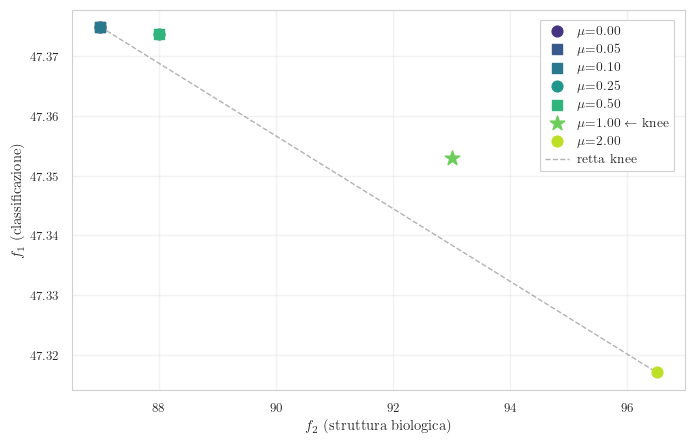

Salvato diagnostiche: knapsack_outputs/knapsack_sweep_diagnostics.pdf


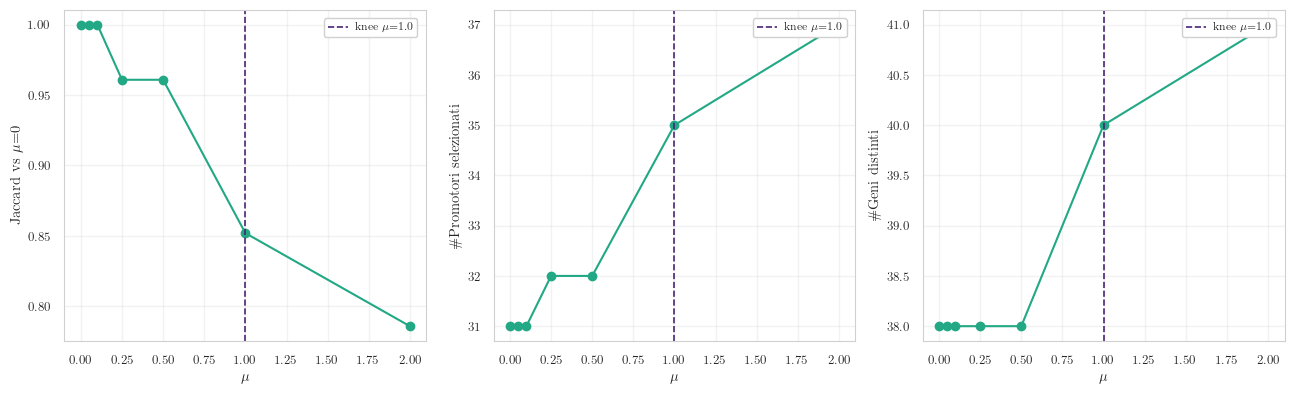

Salvato CSV sweep: knapsack_outputs/knapsack_sweep_summary.csv

STEP 15 — Evaluation separazione (50 CpG knee)

  [Normal vs Adjacent (test)]  n=19 (0=10, 1=9)
  Silhouette    : 0.0481
  AUC CV5       : 0.7500 ± 0.2236
  mean|ΔM|      : 0.6003
  PCA PC1       : 0.434

  [Normal vs Tumor]  n=315 (0=10, 1=305)
  Silhouette    : 0.1610
  AUC CV5       : 0.9984 ± 0.0033
  mean|ΔM|      : 1.9952
  PCA PC1       : 0.331

STEP 16 — Confronto μ=0 (pura classificazione) vs knee
                                      μ=0       knee
f1                                47.3750    47.3530
f2                                87.0000    93.0000
n_promoter                             31         35
n_island                               37         38
n_genes                                38         40
Jaccard(mu0, knee)                 0.8519

OUTPUT FINALE
  selected_cpgs_final : 50 CpG (knee, μ=1.0)
  sweep_results       : lista con tutte le run
  eval_results_final  : metriche separazione
  OUTDIR      

In [92]:
##### NUOVO MODELLO DELLO ZAIMO
# ============================================================
# CpG KNAPSACK — MILP bi-obiettivo con sweep su μ
#
# Modello:
#   max  f1(x) + μ * f2_hat(x, y)
#
#   f1(x)     = Σ v_i * x_i       (classificazione)
#              v_i = 0.5*c̃_i + 0.2*d̃_i + 0.3*s̃_i
#
#   f2(x,y)   = Σ_{i∈P} x_i       (promotori)
#             + Σ_{i∈L} x_i        (CpG islands)
#             + 0.5 * Σ_g y_g      (geni distinti)
#
#   f2_hat    = f2 / (K * (2 + 0.5))  ∈ [0, 1]
#
# Vincoli hard:
#   C1: Σ x_i = K
#   C2: x_i + x_j ≤ 1   ∀ (i,j) ∈ E  (conflict edges, |r| ≥ 0.85)
#   C3: Σ_{chr=c} x_i ≤ 10   ∀ c
#   C4: Σ_{i∈A} x_i ≥ K_A*  (adattivo: min(25, |A ∩ I|))
#   C5: x_i ≤ y_g   ∀ i: gene(i)=g
#   C6: Σ_{gene=g} x_i ≤ 2   ∀ g
#   C7: Σ_g y_g ≥ G_min*  (adattivo: min(25, |G|))
#
# Sweep μ ∈ {0, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0}
# Knee: distanza massima dalla retta (μ=0) → (max f2 osservato)
#
# Dipendenze nello scope (dal notebook):
#   final_cpgs, cpg_cols_current, M_train, M_test, y_train, y_test
#   step3_stats, cpg_candidates, poolA_cpgs, poolB_cpgs
#   cpg_to_chr, svm_pipe, man (manifest DataFrame)
#   apply_thesis_style, place_legend  (opzionale, per i plot)
# ============================================================

import numpy as np
import pandas as pd
import polars as pl
import pulp
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import silhouette_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA

# ─────────────────────────────────────────────────────────────
# CONFIG — modifica qui
# ─────────────────────────────────────────────────────────────
BETA_PATH    = "/kaggle/input/datasets/rovieramariella/gse69914-parquet/GSE69914.parquet"
ID_COL       = "id_tissue"
LABEL_COL    = "label"
LABELS_ALL   = [0, 1, 2]           # 0=Normal, 1=Adjacent, 2=Tumor

K            = 50                  # CpG da selezionare
N_POOL       = 5000                # top-N da final_cpgs per |coef|
CHR_MAX      = 10                  # C3: max CpG per cromosoma
CORR_THR     = 0.85                # C2: soglia correlazione conflict edges
ETA          = 0.5                 # peso geni in f2

W_COEF       = 0.5                 # peso |coef_SVM| in f1
W_DM         = 0.2                 # peso |ΔM| in f1 (abbassato per rischio doppio conteggio)
W_SCORE      = 0.3                 # peso RSKF score in f1

K_A_NOMINAL  = 25                  # C4: min Pool A (adattivo)
G_MIN_NOMINAL= 25                  # C7: min geni distinti (adattivo)
MAX_PER_GENE = 2                   # C6: max CpG per gene

CBC_TIME_LIMIT = 120               # secondi per ogni solve

MU_GRID = [0.0, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0]

EPS_M    = 1e-6
RANDOM_STATE = 42

OUTDIR = Path("./knapsack_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────
def beta_to_m(b, eps=EPS_M):
    b = np.clip(b, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def rank_norm_asc(v):
    """Rank normalizzato in [0,1]: valore più alto → rank più alto."""
    v = np.asarray(v, float)
    v2 = v.copy()
    if np.isnan(v2).any():
        v2 = np.where(np.isnan(v2), np.nanmin(v2) - 1.0, v2)
    r = np.argsort(np.argsort(v2))
    n = len(v2)
    return r / max(1, n - 1)

def rank_norm_desc(v):
    """Rank normalizzato: valore più basso → rank più alto."""
    return 1.0 - rank_norm_asc(v)

def parse_first_gene(g):
    """
    Estrae il primo gene dal campo manifest (es. "BRCA1;TP53" → "BRCA1").
    Restituisce None se intergenico o NaN.
    """
    if g is None:
        return None
    s = str(g).strip()
    if s == "" or s.lower() == "nan":
        return None
    for sep in [";", ","]:
        if sep in s:
            s = s.split(sep)[0].strip()
            break
    return s if s != "" else None

def in_promoter(feat):
    """True se il contesto genomico è promotoriale."""
    if feat is None:
        return False
    s = str(feat)
    return any(k in s for k in ["TSS200", "TSS1500", "1stExon", "5'UTR", "5UTR"])

def in_island(ctx):
    """True se il contesto è CpG Island."""
    if ctx is None:
        return False
    return "Island" in str(ctx) and "Shore" not in str(ctx) and "Shelf" not in str(ctx)

def jaccard(s1, s2):
    s1, s2 = set(s1), set(s2)
    if len(s1 | s2) == 0:
        return 1.0
    return len(s1 & s2) / len(s1 | s2)

def knee_index(f1_vals, f2_vals):
    """
    Distanza massima dalla retta che congiunge
    il punto con f2 minimo (μ=0) e quello con f2 massimo.
    Ignora i punti saturati (f2 identico al precedente).
    """
    f1 = np.array(f1_vals, float)
    f2 = np.array(f2_vals, float)

    # punti non saturati
    valid = np.ones(len(f2), dtype=bool)
    for i in range(1, len(f2)):
        if f2[i] == f2[i - 1]:
            valid[i] = False
    idx_v = np.where(valid)[0]
    if len(idx_v) < 2:
        return 0

    # normalizza in [0,1] × [0,1]
    f1_n = (f1[idx_v] - f1[idx_v].min()) / max(f1[idx_v].max() - f1[idx_v].min(), 1e-12)
    f2_n = (f2[idx_v] - f2[idx_v].min()) / max(f2[idx_v].max() - f2[idx_v].min(), 1e-12)

    # retta da primo a ultimo punto valido
    p0 = np.array([f2_n[0],  f1_n[0]])
    p1 = np.array([f2_n[-1], f1_n[-1]])
    d  = p1 - p0
    d_norm = d / max(np.linalg.norm(d), 1e-12)

    dists = []
    for i in range(len(idx_v)):
        p = np.array([f2_n[i], f1_n[i]])
        dists.append(np.linalg.norm((p - p0) - np.dot(p - p0, d_norm) * d_norm))

    return int(idx_v[np.argmax(dists)])


# ─────────────────────────────────────────────────────────────
# STEP 1 — Estrai coef SVM dalle 5000 CpG
# ─────────────────────────────────────────────────────────────
print("=" * 70)
print("STEP 1 — Estrazione coef SVM")
print("=" * 70)

cols_all = np.array(cpg_cols_current, dtype=object)
col_to_j = {c: j for j, c in enumerate(cols_all.tolist())}

final_arr = np.array(final_cpgs, dtype=object)

raw_coef = importances
coef_final = raw_coef

print(f"final_cpgs        : {final_arr.size}")
print(f"coef range        : [{coef_final.min():.4f}, {coef_final.max():.4f}]")
print(f"  pos (ipermet.)  : {(coef_final > 0).sum()}")
print(f"  neg (ipomet.)   : {(coef_final < 0).sum()}")

# ─────────────────────────────────────────────────────────────
# STEP 2 — Carica M_all (norm+adj+tum) per evaluation
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 2 — Caricamento M_all (label 0,1,2)")
print("=" * 70)

beta_all = (
    pl.read_parquet(BETA_PATH)
    .filter(pl.col(LABEL_COL).is_in(LABELS_ALL))
)
y_all  = beta_all.select(LABEL_COL).to_numpy().ravel().astype(int)
id_all = beta_all.select(ID_COL).to_numpy().ravel()

meta_cols_set   = {ID_COL, LABEL_COL}
cpg_cols_parquet = [c for c in beta_all.columns if c not in meta_cols_set]

common       = [c for c in cpg_cols_parquet if c in col_to_j]
M_all_beta   = beta_all.select(common).to_numpy().astype(np.float32)
M_all        = beta_to_m(M_all_beta).astype(np.float32)
col_to_j_all = {c: i for i, c in enumerate(common)}

print(f"M_all shape       : {M_all.shape}")
print(f"y_all distrib     : " + str({int(v): int((y_all == v).sum()) for v in np.unique(y_all)}))

# ─────────────────────────────────────────────────────────────
# STEP 3 — Allinea RSKF score e |ΔM| a final_cpgs
# ─────────────────────────────────────────────────────────────
cand_arr   = np.array(cpg_candidates, dtype=object)
cand_score = np.array(step3_stats["score"], dtype=float)
cand_absdM = np.array(step3_stats["abs_deltaM_full"], dtype=float)
cand_to_i  = {c: i for i, c in enumerate(cand_arr.tolist())}

score_final = np.array(
    [cand_score[cand_to_i[c]] if c in cand_to_i else np.nan for c in final_arr],
    dtype=float
)
absdM_final = np.array(
    [cand_absdM[cand_to_i[c]] if c in cand_to_i else np.nan for c in final_arr],
    dtype=float
)
n_miss = int(np.isnan(score_final).sum())
if n_miss > 0:
    print(f"⚠ {n_miss} CpG non trovate in cpg_candidates (score=nan, penalizzate).")

# ─────────────────────────────────────────────────────────────
# STEP 4 — Costruisci pool top-N per |coef|
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 4 — Pool top-{N_POOL} per |coef_SVM|")
print("=" * 70)

order_coef = np.argsort(-np.abs(coef_final))
pool_idx   = order_coef[:N_POOL]

pool_cpgs  = final_arr[pool_idx]
pool_coef  = coef_final[pool_idx]
pool_score = score_final[pool_idx]
pool_absdM = absdM_final[pool_idx]

# rimuovi CpG non presenti in M_train
valid_mask = np.array([c in col_to_j for c in pool_cpgs], dtype=bool)
if not valid_mask.all():
    n_drop = (~valid_mask).sum()
    print(f"  ⚠ Rimosse {n_drop} CpG non presenti in M_train.")
    pool_cpgs  = pool_cpgs[valid_mask]
    pool_coef  = pool_coef[valid_mask]
    pool_score = pool_score[valid_mask]
    pool_absdM = pool_absdM[valid_mask]

n_p = len(pool_cpgs)
print(f"Pool effettivo    : {n_p} CpG")
print(f"|coef| range      : [{np.abs(pool_coef).min():.4f}, {np.abs(pool_coef).max():.4f}]")

# ─────────────────────────────────────────────────────────────
# STEP 5 — Pool A / B nel pool
# ─────────────────────────────────────────────────────────────
_poolA_set = set(np.array(poolA_cpgs, dtype=object).tolist()) if poolA_cpgs is not None else set()
_poolB_set = set(np.array(poolB_cpgs, dtype=object).tolist()) if poolB_cpgs is not None else set()

poolA_in_pool = [c for c in pool_cpgs if c in _poolA_set]
poolB_in_pool = [c for c in pool_cpgs if c in _poolB_set]

# C4 adattivo
K_A_use = min(K_A_NOMINAL, len(poolA_in_pool))
print(f"Pool A nel pool   : {len(poolA_in_pool)}  →  K_A_use = {K_A_use}  (nominale {K_A_NOMINAL})")
if K_A_use < K_A_NOMINAL:
    print(f"  ⚠ K_A ridotto: solo {len(poolA_in_pool)} CpG Pool A nel pool top-{N_POOL}.")

# ─────────────────────────────────────────────────────────────
# STEP 6 — Conflict edges (correlazione su M_train)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 6 — Conflict edges (correlazione su M_train)")
print("=" * 70)

jj_pool = np.array([col_to_j[c] for c in pool_cpgs], dtype=int)
Z = M_train[:, jj_pool].astype(np.float64)
Z = (Z - Z.mean(0)) / (Z.std(0, ddof=1) + 1e-12)
C_corr = (Z.T @ Z) / (Z.shape[0] - 1)

i_u, j_u = np.where(np.triu(np.abs(C_corr) >= CORR_THR, k=1))
conflict_pairs = list(zip(i_u.tolist(), j_u.tolist()))

tot_pairs = n_p * (n_p - 1) // 2
print(f"Conflict edges    : {len(conflict_pairs):,} / {tot_pairs:,} "
      f"({100*len(conflict_pairs)/max(1,tot_pairs):.2f}%) a |r|≥{CORR_THR}")

# ─────────────────────────────────────────────────────────────
# STEP 7 — Attributi genomici dal manifest
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 7 — Attributi genomici dal manifest")
print("=" * 70)

# Usa il manifest 'man' già caricato nel notebook (cella 35/38)
# Colonne attese: IlmnID, UCSC_RefGene_Name, UCSC_RefGene_Group, Relation_to_UCSC_CpG_Island

man_sub = man.loc[
    man["IlmnID"].isin(pool_cpgs.tolist()),
    ["IlmnID", "UCSC_RefGene_Name", "UCSC_RefGene_Group", "Relation_to_UCSC_CpG_Island"]
].copy()
man_sub["IlmnID"] = man_sub["IlmnID"].astype(str)

# dizionari rapidi
cpg_gene_dict   = dict(zip(man_sub["IlmnID"], man_sub["UCSC_RefGene_Name"].fillna("")))
cpg_feat_dict   = dict(zip(man_sub["IlmnID"], man_sub["UCSC_RefGene_Group"].fillna("")))
cpg_island_dict = dict(zip(man_sub["IlmnID"], man_sub["Relation_to_UCSC_CpG_Island"].fillna("")))

# array per il pool
chr_arr    = np.array([cpg_to_chr.get(c, "") for c in pool_cpgs], dtype=object)
gene_arr   = np.array([parse_first_gene(cpg_gene_dict.get(c, None)) for c in pool_cpgs], dtype=object)
is_prom    = np.array([in_promoter(cpg_feat_dict.get(c, ""))   for c in pool_cpgs], dtype=int)
is_island  = np.array([in_island(cpg_island_dict.get(c, ""))   for c in pool_cpgs], dtype=int)

# geni annotati (solo non-None)
genes_pool = sorted({g for g in gene_arr.tolist() if g is not None})

# C7 adattivo
G_min_use = min(G_MIN_NOMINAL, len(genes_pool))
print(f"CpG con promotore : {is_prom.sum()}")
print(f"CpG in island     : {is_island.sum()}")
print(f"Geni distinti pool: {len(genes_pool)}  →  G_min_use = {G_min_use}  (nominale {G_MIN_NOMINAL})")

# ─────────────────────────────────────────────────────────────
# STEP 8 — Funzione valore f1 (rank-normalizzata, pool fisso)
# ─────────────────────────────────────────────────────────────
r_coef  = rank_norm_asc(np.abs(pool_coef))
r_dM    = rank_norm_asc(pool_absdM)
r_score = rank_norm_desc(pool_score)

value   = W_COEF * r_coef + W_DM * r_dM + W_SCORE * r_score

F2_NORM = float(K * (2 + ETA))  # upper bound deterministico di f2

print(f"\nf1 value range    : [{value.min():.4f}, {value.max():.4f}]")
print(f"f2 norm factor    : {F2_NORM:.1f}  (K×(2+η) = {K}×{2+ETA})")

# ─────────────────────────────────────────────────────────────
# STEP 9 — Funzione MILP per un dato μ
# ─────────────────────────────────────────────────────────────

def solve_milp(mu: float):
    """
    Risolve il MILP per un dato μ.
    Restituisce (selected_cpgs, f1_val, f2_val, status_str) oppure None se infeasible.
    """
    prob = pulp.LpProblem(f"CpG_Knapsack_mu{mu:.3f}", pulp.LpMaximize)

    # variabili CpG
    x = [pulp.LpVariable(f"x_{i}", cat="Binary") for i in range(n_p)]

    # variabili gene (y_g ∈ {0,1})
    y_g = {g: pulp.LpVariable(f"yg_{g.replace('-','_')}", cat="Binary") for g in genes_pool}

    # ── Obiettivo ──────────────────────────────────────────────
    f1_expr = pulp.lpSum(float(value[i]) * x[i] for i in range(n_p))
    f2_expr = (
        pulp.lpSum(x[i] for i in range(n_p) if is_prom[i])
        + pulp.lpSum(x[i] for i in range(n_p) if is_island[i])
        + ETA * pulp.lpSum(y_g[g] for g in genes_pool)
    )
    f2_hat  = f2_expr / F2_NORM

    prob += f1_expr + mu * f2_hat

    # ── C1: cardinalità ────────────────────────────────────────
    prob += pulp.lpSum(x) == K, "C1_cardinality"

    # ── C2: conflict edges ──────────────────────────────────────
    for idx, (i, j) in enumerate(conflict_pairs):
        prob += x[i] + x[j] <= 1, f"C2_conf_{idx}"

    # ── C3: max per cromosoma ───────────────────────────────────
    for ch in sorted(set(chr_arr.tolist()) - {""}):
        prob += pulp.lpSum(x[i] for i in range(n_p) if chr_arr[i] == ch) <= CHR_MAX, f"C3_chr_{ch}"

    # ── C4: Pool A min (adattivo) ────────────────────────────────
    if K_A_use > 0 and len(_poolA_set) > 0:
        prob += (
            pulp.lpSum(x[i] for i in range(n_p) if pool_cpgs[i] in _poolA_set)
            >= K_A_use, "C4_poolA_min"
        )

    # ── C5: link CpG → gene ─────────────────────────────────────
    for i in range(n_p):
        g = gene_arr[i]
        if g is not None and g in y_g:
            prob += x[i] <= y_g[g], f"C5_link_{i}"

    # ── C6: max CpG per gene ─────────────────────────────────────
    for g in genes_pool:
        idx_g = [i for i in range(n_p) if gene_arr[i] == g]
        if len(idx_g) > 0:
            prob += pulp.lpSum(x[i] for i in idx_g) <= MAX_PER_GENE, f"C6_maxgene_{g}"

    # ── C7: min geni distinti (adattivo) ─────────────────────────
    if G_min_use > 0:
        prob += pulp.lpSum(y_g[g] for g in genes_pool) >= G_min_use, "C7_min_genes"

    # ── Solve ────────────────────────────────────────────────────
    solver = pulp.PULP_CBC_CMD(msg=False, timeLimit=CBC_TIME_LIMIT)
    status = prob.solve(solver)
    status_str = pulp.LpStatus.get(status, str(status))

    obj_val = pulp.value(prob.objective)
    if obj_val is None or status_str not in ["Optimal", "Feasible"]:
        print(f"  [μ={mu:.3f}] Status={status_str} — INFEASIBLE/FAILED")
        return None

    sel_idx_milp = np.array([i for i in range(n_p) if (pulp.value(x[i]) or 0) > 0.5], dtype=int)
    if sel_idx_milp.size != K:
        print(f"  [μ={mu:.3f}] MILP ha selezionato {sel_idx_milp.size}/{K} — SKIP")
        return None

    # valori obiettivo reali
    f1_val  = float(sum(value[i] for i in sel_idx_milp))
    f2_val  = float(
        is_prom[sel_idx_milp].sum()
        + is_island[sel_idx_milp].sum()
        + ETA * len({gene_arr[i] for i in sel_idx_milp if gene_arr[i] is not None})
    )

    selected = pool_cpgs[sel_idx_milp].tolist()
    return selected, f1_val, f2_val, status_str, sel_idx_milp


# ─────────────────────────────────────────────────────────────
# STEP 10 — Sweep su μ
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 10 — Sweep μ")
print("=" * 70)

sweep_results = []
sel_mu0 = None   # set a μ=0 per Jaccard

for mu in MU_GRID:
    print(f"\n[μ={mu:.3f}] Solving MILP...")
    result = solve_milp(mu)
    if result is None:
        sweep_results.append({
            "mu": mu, "status": "FAILED",
            "f1": np.nan, "f2": np.nan, "f2_hat": np.nan,
            "delta": np.nan, "jaccard_vs_0": np.nan,
            "n_promoter": np.nan, "n_island": np.nan, "n_genes": np.nan,
            "selected": []
        })
        continue

    selected, f1_val, f2_val, status_str, sel_idx_milp = result

    if mu == 0.0:
        sel_mu0 = selected

    f2_hat_val = f2_val / F2_NORM
    delta_val  = (mu * f2_hat_val) / max(f1_val, 1e-12)
    jacc       = jaccard(selected, sel_mu0) if sel_mu0 is not None else 1.0

    n_prom  = int(is_prom[sel_idx_milp].sum())
    n_isl   = int(is_island[sel_idx_milp].sum())
    n_genes = len({gene_arr[i] for i in sel_idx_milp if gene_arr[i] is not None})

    # flag saturazione
    sat = False
    if len(sweep_results) > 0 and not np.isnan(sweep_results[-1]["f2"]):
        sat = (f2_val == sweep_results[-1]["f2"])

    sweep_results.append({
        "mu": mu, "status": status_str,
        "f1": f1_val, "f2": f2_val, "f2_hat": f2_hat_val,
        "delta": delta_val, "jaccard_vs_0": jacc,
        "n_promoter": n_prom, "n_island": n_isl, "n_genes": n_genes,
        "saturated": sat,
        "selected": selected
    })

    print(f"  Status     : {status_str}")
    print(f"  f1         : {f1_val:.4f}")
    print(f"  f2         : {f2_val:.4f}  (f2_hat={f2_hat_val:.4f})")
    print(f"  Δ(bio/clf) : {delta_val:.4f}")
    print(f"  Jaccard(0) : {jacc:.4f}")
    print(f"  Promotori  : {n_prom}  |  Islands: {n_isl}  |  Geni: {n_genes}")
    print(f"  Saturato   : {sat}")

# ─────────────────────────────────────────────────────────────
# STEP 11 — Selezione knee e diagnostiche
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 11 — Selezione knee")
print("=" * 70)

valid_res = [r for r in sweep_results if not np.isnan(r["f1"])]
f1_vals   = [r["f1"] for r in valid_res]
f2_vals   = [r["f2"] for r in valid_res]
mu_vals   = [r["mu"] for r in valid_res]

knee_idx   = knee_index(f1_vals, f2_vals)
knee_res   = valid_res[knee_idx]
knee_mu    = knee_res["mu"]

print(f"Knee selezionato  : μ = {knee_mu:.3f}")
print(f"  f1              : {knee_res['f1']:.4f}")
print(f"  f2              : {knee_res['f2']:.4f}  (f2_hat={knee_res['f2_hat']:.4f})")
print(f"  Jaccard vs μ=0  : {knee_res['jaccard_vs_0']:.4f}")
print(f"  Promotori       : {knee_res['n_promoter']}")
print(f"  Islands         : {knee_res['n_island']}")
print(f"  Geni distinti   : {knee_res['n_genes']}")

selected_cpgs_final = knee_res["selected"]
print(f"\nSet finale (knee) : {len(selected_cpgs_final)} CpG")

# ─────────────────────────────────────────────────────────────
# STEP 12 — Plot curva di trade-off
# ─────────────────────────────────────────────────────────────
try:
    apply_thesis_style(use_tex=True, legend_position="upper right")
except:
    pass

fig, ax = plt.subplots(figsize=(7, 4.5))

cmap = plt.cm.viridis
colors = cmap(np.linspace(0.15, 0.9, len(valid_res)))

for i, (r, col) in enumerate(zip(valid_res, colors)):
    marker = "*" if r["mu"] == knee_mu else ("s" if r.get("saturated") else "o")
    size   = 120 if r["mu"] == knee_mu else 60
    ax.scatter(r["f2"], r["f1"], color=col, marker=marker, s=size, zorder=3,
               label=f"$\mu$={r['mu']:.2f}" + (" $\leftarrow $ knee" if r["mu"] == knee_mu else ""))

# retta (μ=0) → (max f2 osservato)
p0 = np.array([f2_vals[0],  f1_vals[0]])
p1 = np.array([max(f2_vals), f1_vals[np.argmax(f2_vals)]])
ax.plot([p0[0], p1[0]], [p0[1], p1[1]], "--", color="gray", linewidth=1.0,
        alpha=0.6, label="retta knee")

ax.set_xlabel(r"$f_2$ (struttura biologica)")
ax.set_ylabel(r"$f_1$ (classificazione)")

try:
    place_legend(ax)
except:
    ax.legend(fontsize=8, ncol=2)

fig.tight_layout()
pdf_path = OUTDIR / "knapsack_tradeoff_curve.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"\nSalvato plot: {pdf_path}")
plt.show()

# ─────────────────────────────────────────────────────────────
# STEP 13 — Plot diagnostiche sweep (Jaccard, #promoter, #genes)
# ─────────────────────────────────────────────────────────────
fig2, axes = plt.subplots(1, 3, figsize=(13, 4))
mu_ax = [r["mu"] for r in valid_res]

for ax_i, (key, label) in zip(axes, [
    ("jaccard_vs_0", "Jaccard vs $\mu$=0"),
    ("n_promoter",   "\#Promotori selezionati"),
    ("n_genes",      "\#Geni distinti"),
]):
    vals = [r[key] for r in valid_res]
    ax_i.plot(mu_ax, vals, marker="o", color=cmap(0.6), linewidth=1.5)
    ax_i.axvline(knee_mu, linestyle="--", color=cmap(0.1), linewidth=1.2, label=f"knee $\mu$={knee_mu}")
    ax_i.set_xlabel(r"$\mu$")
    ax_i.set_ylabel(label)
    ax_i.legend(fontsize=8)

fig2.tight_layout()
pdf2 = OUTDIR / "knapsack_sweep_diagnostics.pdf"
fig2.savefig(pdf2, dpi=300, bbox_inches="tight")
print(f"Salvato diagnostiche: {pdf2}")
plt.show()

# ─────────────────────────────────────────────────────────────
# STEP 14 — Salva sweep summary CSV
# ─────────────────────────────────────────────────────────────
import csv

csv_path = OUTDIR / "knapsack_sweep_summary.csv"
fieldnames = ["mu", "status", "f1", "f2", "f2_hat", "delta",
              "jaccard_vs_0", "n_promoter", "n_island", "n_genes", "saturated"]

with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for r in sweep_results:
        writer.writerow({k: r.get(k, "") for k in fieldnames})

print(f"Salvato CSV sweep: {csv_path}")

# ─────────────────────────────────────────────────────────────
# STEP 15 — Valutazione separazione sulle 50 CpG (knee)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 15 — Evaluation separazione (50 CpG knee)")
print("=" * 70)

# allineamento indici
jj_test = np.array([col_to_j[c]     for c in selected_cpgs_final if c in col_to_j],     dtype=int)
jj_eval = np.array([col_to_j_all[c] for c in selected_cpgs_final if c in col_to_j_all], dtype=int)

def eval_pair(name, X, ybin):
    out = {}
    n0, n1 = int((ybin == 0).sum()), int((ybin == 1).sum())
    print(f"\n  [{name}]  n={X.shape[0]} (0={n0}, 1={n1})")
    if X.shape[0] < 10 or n0 == 0 or n1 == 0:
        print("  Campioni insufficienti.")
        return out

    try:
        out["silhouette"] = float(silhouette_score(X, ybin, metric="euclidean"))
        print(f"  Silhouette    : {out['silhouette']:.4f}")
    except Exception as e:
        out["silhouette"] = None
        print(f"  Silhouette    : N/A ({e})")

    try:
        Xsc  = StandardScaler().fit_transform(X)
        lr   = LogisticRegression(C=1.0, class_weight="balanced",
                                  max_iter=2000, random_state=RANDOM_STATE)
        n_cv = min(5, n0, n1)
        aucs = cross_val_score(lr, Xsc, ybin, cv=n_cv, scoring="roc_auc")
        out["auc_mean"] = float(aucs.mean())
        out["auc_std"]  = float(aucs.std())
        print(f"  AUC CV{n_cv}       : {out['auc_mean']:.4f} ± {out['auc_std']:.4f}")
    except Exception as e:
        out["auc_mean"] = out["auc_std"] = None
        print(f"  AUC CV        : N/A ({e})")

    m0, m1 = X[ybin == 0].mean(0), X[ybin == 1].mean(0)
    out["mean_abs_dM"] = float(np.abs(m1 - m0).mean())
    print(f"  mean|ΔM|      : {out['mean_abs_dM']:.4f}")

    try:
        pca = PCA(n_components=2, random_state=RANDOM_STATE)
        pca.fit(StandardScaler().fit_transform(X))
        out["pca_pc1"] = float(pca.explained_variance_ratio_[0])
        print(f"  PCA PC1       : {out['pca_pc1']:.3f}")
    except:
        out["pca_pc1"] = None

    return out

eval_results_final = {}

# Normal vs Adjacent (solo test set — no leakage)
mask_na = np.isin(y_test, [0, 1])
X_na    = M_test[mask_na][:, jj_test]
y_na    = (y_test[mask_na] == 1).astype(int)
eval_results_final["Normal_vs_Adjacent_test"] = eval_pair("Normal vs Adjacent (test)", X_na, y_na)

# Normal vs Tumor (test normals + tutti i tumor)
mask_tum      = (y_all == 2)
mask_norm_te  = (y_test == 0)
X_tum  = M_all[mask_tum][:, jj_eval]
X_norm = M_test[mask_norm_te][:, jj_test]
X_nt   = np.vstack([X_norm, X_tum])
y_nt   = np.array([0] * X_norm.shape[0] + [1] * X_tum.shape[0], dtype=int)
eval_results_final["Normal_vs_Tumor"] = eval_pair("Normal vs Tumor", X_nt, y_nt)

# ─────────────────────────────────────────────────────────────
# STEP 16 — Confronto μ=0 vs knee (se diversi)
# ─────────────────────────────────────────────────────────────
if knee_mu != 0.0 and sel_mu0 is not None:
    print("\n" + "=" * 70)
    print("STEP 16 — Confronto μ=0 (pura classificazione) vs knee")
    print("=" * 70)

    res_mu0 = next(r for r in valid_res if r["mu"] == 0.0)

    print(f"{'':30s} {'μ=0':>10s} {'knee':>10s}")
    print(f"{'f1':30s} {res_mu0['f1']:>10.4f} {knee_res['f1']:>10.4f}")
    print(f"{'f2':30s} {res_mu0['f2']:>10.4f} {knee_res['f2']:>10.4f}")
    print(f"{'n_promoter':30s} {res_mu0['n_promoter']:>10} {knee_res['n_promoter']:>10}")
    print(f"{'n_island':30s} {res_mu0['n_island']:>10} {knee_res['n_island']:>10}")
    print(f"{'n_genes':30s} {res_mu0['n_genes']:>10} {knee_res['n_genes']:>10}")
    print(f"{'Jaccard(mu0, knee)':30s} {jaccard(sel_mu0, selected_cpgs_final):>10.4f}")

# ─────────────────────────────────────────────────────────────
# OUTPUT FINALE
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("OUTPUT FINALE")
print("=" * 70)
print(f"  selected_cpgs_final : {len(selected_cpgs_final)} CpG (knee, μ={knee_mu})")
print(f"  sweep_results       : lista con tutte le run")
print(f"  eval_results_final  : metriche separazione")
print(f"  OUTDIR              : {OUTDIR}")
print("=" * 70)

# dopo run con W_COSMIC=0
selected_cpgs_no_cosmic = selected_cpgs_final.copy()

STEP 1 — Estrazione coef SVM
final_cpgs        : 5000
coef range        : [-0.0106, 0.0050]
  pos (ipermet.)  : 250
  neg (ipomet.)   : 24

STEP 2 — Caricamento dati  [EVAL_TUMOR=True]
M_all shape       : (397, 148352)
y_all distrib     : {0: 50, 1: 42, 2: 305}

STEP 4 — Pool top-5000 per |coef_SVM|
Pool effettivo    : 5000 CpG
|coef| range      : [0.0000, 0.0106]
Pool A nel pool   : 1205  →  K_A_use=25 (nominale 25)

STEP 6 — Conflict edges
Conflict edges    : 65 / 12,497,500 (0.001%) a |r|≥0.85

STEP 7 — Attributi genomici + COSMIC prior
CpG con promotore : 2291
CpG in island     : 2151
Geni distinti pool: 2578  →  G_min_use=25 (nominale 25)
Geni COSMIC breast: 44
CpG COSMIC nel pool: 6  (0.1% del pool)
CpG ipermet. pool : 250  (coef>0)
CpG ipomet. pool  : 4750  (coef<0)

f1 value range    : [0.1098, 1.0548]  (W_COSMIC=0.3)
f2 norm factor    : 125.0

STEP 10a — Sweep μ  (W_COSMIC=0.3 fissato)

[μ=0.000] Solving...
  Status     : Optimal
  f1         : 47.5299
  f2         : 86.0000  

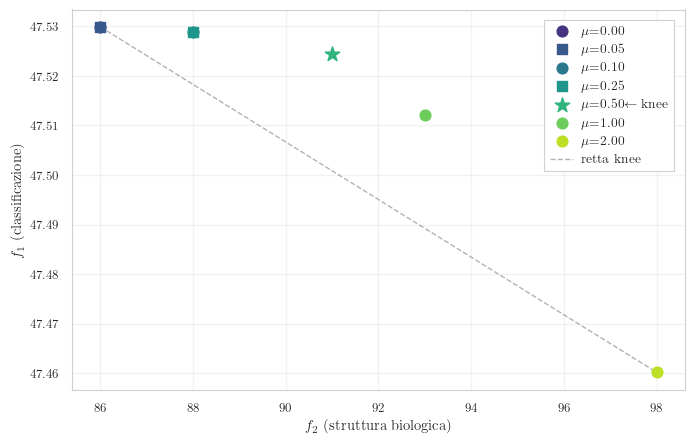

Salvato: knapsack_outputs/knapsack_sweep_diagnostics.pdf


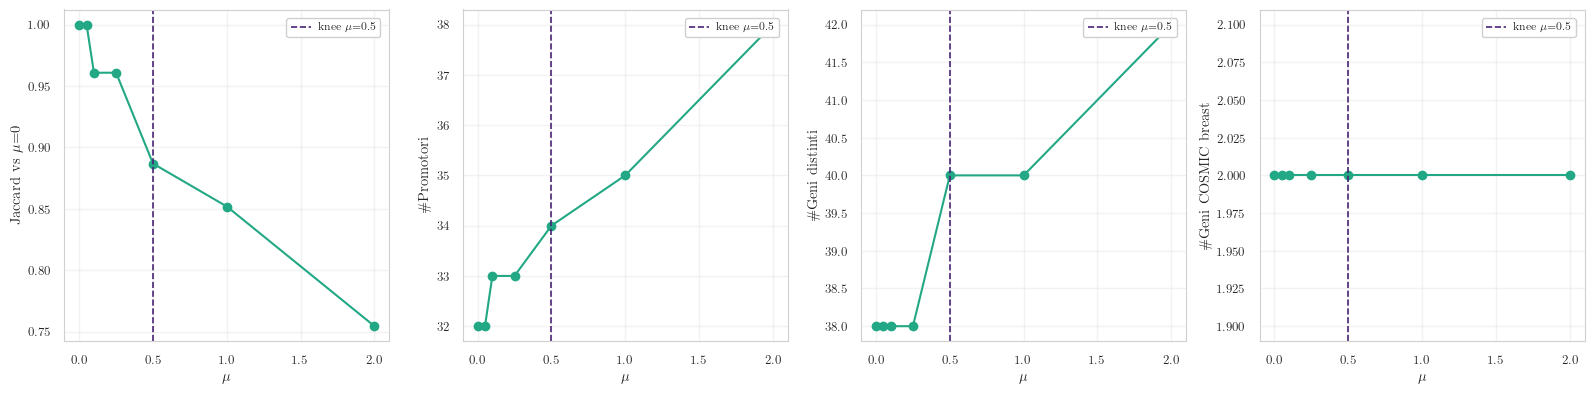

Salvato: knapsack_outputs/knapsack_wcosmic_sweep.pdf


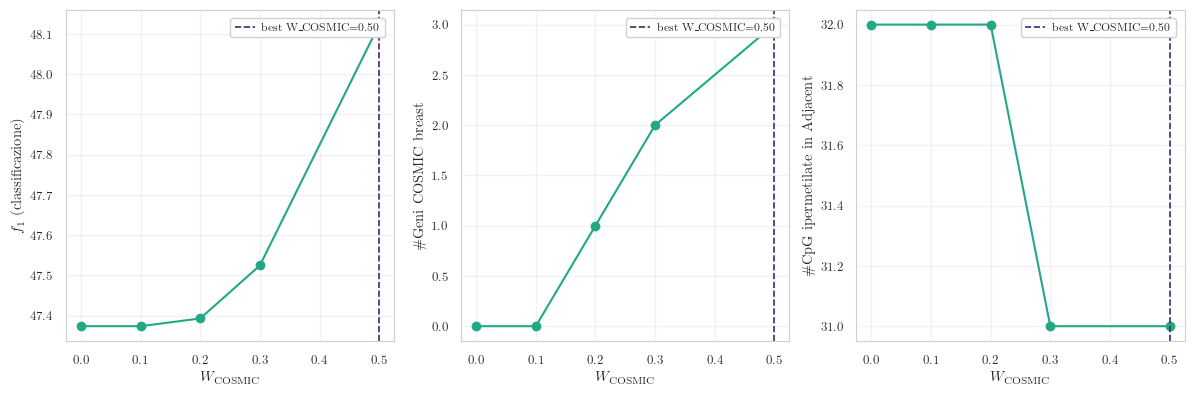

Salvato CSV: knapsack_outputs/knapsack_sweep_summary.csv

STEP 15 — Evaluation separazione (50 CpG finali)

  [Normal vs Adjacent (test)]  n=19 (0=10, 1=9)
  Silhouette    : 0.0429
  AUC CV5       : 0.6000 ± 0.2000
  mean|ΔM|      : 0.5637
  PCA PC1       : 0.398

  [Normal vs Tumor]  n=315 (0=10, 1=305)
  Silhouette    : 0.1457
  AUC CV5       : 0.9984 ± 0.0033
  mean|ΔM|      : 1.8883
  PCA PC1       : 0.317

STEP 16 — Confronto μ=0 vs set finale
                                      μ=0     finale
f1                                47.5299    48.1227
f2                                86.0000    91.0000
n_promoter                             32         34
n_island                               35         37
n_genes                                38         40
n_cosmic                                2          3
n_hyper                                32         31
Jaccard(mu0, finale)               0.8868

OUTPUT FINALE
  selected_cpgs_final : 50 CpG
  knee_mu             : 0.5
  best_

In [106]:
# ============================================================
# CpG KNAPSACK — MILP bi-obiettivo con sweep su μ  [v2]
#
# MODIFICHE rispetto a v1:
#   1) W_COSMIC: prior COSMIC breast cancer nel value di f1
#      v_i = W_COEF*c̃_i + W_DM*d̃_i + W_SCORE*s̃_i + W_COSMIC*is_cosmic_i
#      → sweep secondario su W_COSMIC con μ fissato al knee
#   2) MIN_HYPER: vincolo C8 che impone almeno MIN_HYPER CpG
#      ipERmetilate in Adjacent (coef_SVM > 0)
#   3) EVAL_TUMOR: flag per attivare/disattivare la valutazione
#      Normal vs Tumor (default False: studio è Normal vs Adjacent)
#
# Modello:
#   max  f1(x) + μ * f2_hat(x, y)
#   f1(x)   = Σ v_i * x_i      v_i = W_COEF*c̃ + W_DM*d̃ + W_SCORE*s̃ + W_COSMIC*cosmic_i
#   f2(x,y) = Σ_{i∈P} x_i  +  Σ_{i∈L} x_i  +  η * Σ_g y_g
#   f2_hat  = f2 / (K*(2+η))
#
# Vincoli hard:
#   C1: Σ x_i = K
#   C2: x_i + x_j ≤ 1        ∀ (i,j): |r_ij| ≥ CORR_THR
#   C3: Σ_{chr=c} x_i ≤ CHR_MAX
#   C4: Σ_{i∈A} x_i ≥ K_A*   (adattivo: min(K_A_NOMINAL, |A∩I|))
#   C5: x_i ≤ y_g             ∀ i: gene(i)=g
#   C6: Σ_{gene=g} x_i ≤ 2   ∀ g
#   C7: Σ_g y_g ≥ G_min*      (adattivo: min(G_MIN_NOMINAL, |G|))
#   C8: Σ_{coef>0} x_i ≥ MIN_HYPER   [NUOVO]
#
# Sweep principale: μ ∈ MU_GRID  (con W_COSMIC fissato)
# Sweep secondario: W_COSMIC ∈ W_COSMIC_GRID  (con μ=knee)
#
# Dipendenze nello scope (dal notebook):
#   final_cpgs, cpg_cols_current, M_train, M_test, y_train, y_test
#   step3_stats, cpg_candidates, poolA_cpgs, poolB_cpgs
#   cpg_to_chr, svm_pipe, man (manifest DataFrame già caricato)
#   apply_thesis_style, place_legend  (opzionale, per i plot)
# ============================================================

import numpy as np
import pandas as pd
import polars as pl
import pulp
import csv
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA

# ─────────────────────────────────────────────────────────────
# CONFIG — modifica qui
# ─────────────────────────────────────────────────────────────
BETA_PATH     = "/kaggle/input/datasets/rovieramariella/gse69914-parquet/GSE69914.parquet"
CGC_PATH      = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"

ID_COL        = "id_tissue"
LABEL_COL     = "label"
LABELS_ALL    = [0, 1, 2]           # 0=Normal, 1=Adjacent, 2=Tumor

K             = 50                  # CpG da selezionare
N_POOL        = 5000                # top-N da final_cpgs per |coef|
CHR_MAX       = 10                  # C3: max CpG per cromosoma
CORR_THR      = 0.85                # C2: soglia correlazione conflict edges
ETA           = 0.5                 # peso geni distinti in f2

# Pesi f1 (sommano a 1 senza COSMIC; COSMIC è bonus additivo)
W_COEF        = 0.5                 # peso |coef_SVM|
W_DM          = 0.2                 # peso |ΔM|
W_SCORE       = 0.3                 # peso RSKF score (invertito)

# [NUOVO] Prior COSMIC breast cancer nel value
# Sweep secondario su questo parametro (vedi STEP 10b)
W_COSMIC      = 0.3                 # valore usato nello sweep principale μ
W_COSMIC_GRID = [0.0, 0.1, 0.2, 0.3, 0.5]   # sweep secondario (μ fissato al knee)

# Vincoli
K_A_NOMINAL   = 25                  # C4: min Pool A (adattivo)
G_MIN_NOMINAL = 25                  # C7: min geni distinti (adattivo)
MAX_PER_GENE  = 2                   # C6: max CpG per gene

# [NUOVO] C8: min CpG ipERmetilate in Adjacent (coef_SVM > 0)
# Metti 0 per disattivare
MIN_HYPER     = 15

# Sweep principale μ
MU_GRID       = [0.0, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0]

# [NUOVO] Evaluation Normal vs Tumor: False = solo Normal vs Adjacent
EVAL_TUMOR    = True

CBC_TIME_LIMIT = 120               # secondi per ogni solve
EPS_M          = 1e-6
RANDOM_STATE   = 42

OUTDIR = Path("./knapsack_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────
def beta_to_m(b, eps=EPS_M):
    b = np.clip(b, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def rank_norm_asc(v):
    """Rank normalizzato [0,1]: valore più alto → rank più alto."""
    v = np.asarray(v, float)
    v2 = v.copy()
    if np.isnan(v2).any():
        v2 = np.where(np.isnan(v2), np.nanmin(v2) - 1.0, v2)
    r = np.argsort(np.argsort(v2))
    return r / max(1, len(v2) - 1)

def rank_norm_desc(v):
    """Rank normalizzato: valore più basso → rank più alto."""
    return 1.0 - rank_norm_asc(v)

def parse_first_gene(g):
    """
    Estrae il primo gene dal campo manifest (es. "BRCA1;TP53" → "BRCA1").
    Restituisce None se intergenico o NaN.
    """
    if g is None:
        return None
    s = str(g).strip()
    if s == "" or s.lower() == "nan":
        return None
    for sep in [";", ","]:
        if sep in s:
            s = s.split(sep)[0].strip()
            break
    return s if s != "" else None

def in_promoter(feat):
    if feat is None:
        return False
    s = str(feat)
    return any(k in s for k in ["TSS200", "TSS1500", "1stExon", "5'UTR", "5UTR"])

def in_island(ctx):
    if ctx is None:
        return False
    s = str(ctx)
    return "Island" in s and "Shore" not in s and "Shelf" not in s

def jaccard(s1, s2):
    s1, s2 = set(s1), set(s2)
    if len(s1 | s2) == 0:
        return 1.0
    return len(s1 & s2) / len(s1 | s2)

def knee_index(f1_vals, f2_vals):
    """
    Distanza massima dalla retta (μ=0) → (punto con f2 massimo osservato).
    Ignora punti saturati (f2 identico al precedente).
    """
    f1 = np.array(f1_vals, float)
    f2 = np.array(f2_vals, float)

    valid = np.ones(len(f2), dtype=bool)
    for i in range(1, len(f2)):
        if f2[i] == f2[i - 1]:
            valid[i] = False
    idx_v = np.where(valid)[0]
    if len(idx_v) < 2:
        return 0

    f1_n = (f1[idx_v] - f1[idx_v].min()) / max(f1[idx_v].max() - f1[idx_v].min(), 1e-12)
    f2_n = (f2[idx_v] - f2[idx_v].min()) / max(f2[idx_v].max() - f2[idx_v].min(), 1e-12)

    p0 = np.array([f2_n[0],  f1_n[0]])
    p1 = np.array([f2_n[-1], f1_n[-1]])
    d  = p1 - p0
    d_norm = d / max(np.linalg.norm(d), 1e-12)

    dists = [
        np.linalg.norm((np.array([f2_n[i], f1_n[i]]) - p0)
                       - np.dot(np.array([f2_n[i], f1_n[i]]) - p0, d_norm) * d_norm)
        for i in range(len(idx_v))
    ]
    return int(idx_v[np.argmax(dists)])

def eval_pair(name, X, ybin):
    """Valuta separazione tra due gruppi sulle CpG selezionate."""
    out = {}
    n0, n1 = int((ybin == 0).sum()), int((ybin == 1).sum())
    print(f"\n  [{name}]  n={X.shape[0]} (0={n0}, 1={n1})")
    if X.shape[0] < 10 or n0 == 0 or n1 == 0:
        print("  Campioni insufficienti.")
        return out

    try:
        out["silhouette"] = float(silhouette_score(X, ybin, metric="euclidean"))
        print(f"  Silhouette    : {out['silhouette']:.4f}")
    except Exception as e:
        out["silhouette"] = None
        print(f"  Silhouette    : N/A ({e})")

    try:
        Xsc  = StandardScaler().fit_transform(X)
        lr   = LogisticRegression(C=1.0, class_weight="balanced",
                                  max_iter=2000, random_state=RANDOM_STATE)
        n_cv = min(5, n0, n1)
        aucs = cross_val_score(lr, Xsc, ybin, cv=n_cv, scoring="roc_auc")
        out["auc_mean"] = float(aucs.mean())
        out["auc_std"]  = float(aucs.std())
        print(f"  AUC CV{n_cv}       : {out['auc_mean']:.4f} ± {out['auc_std']:.4f}")
    except Exception as e:
        out["auc_mean"] = out["auc_std"] = None
        print(f"  AUC CV        : N/A ({e})")

    m0, m1 = X[ybin == 0].mean(0), X[ybin == 1].mean(0)
    out["mean_abs_dM"] = float(np.abs(m1 - m0).mean())
    print(f"  mean|ΔM|      : {out['mean_abs_dM']:.4f}")

    try:
        pca = PCA(n_components=2, random_state=RANDOM_STATE)
        pca.fit(StandardScaler().fit_transform(X))
        out["pca_pc1"] = float(pca.explained_variance_ratio_[0])
        print(f"  PCA PC1       : {out['pca_pc1']:.3f}")
    except:
        out["pca_pc1"] = None

    return out


# ─────────────────────────────────────────────────────────────
# STEP 1 — Estrai coef SVM dalle final_cpgs
# ─────────────────────────────────────────────────────────────
print("=" * 70)
print("STEP 1 — Estrazione coef SVM")
print("=" * 70)

cols_all  = np.array(cpg_cols_current, dtype=object)
col_to_j  = {c: j for j, c in enumerate(cols_all.tolist())}
final_arr = np.array(final_cpgs, dtype=object)

raw_coef = importances
coef_final = raw_coef

print(f"final_cpgs        : {final_arr.size}")
print(f"coef range        : [{coef_final.min():.4f}, {coef_final.max():.4f}]")
print(f"  pos (ipermet.)  : {(coef_final > 0).sum()}")
print(f"  neg (ipomet.)   : {(coef_final < 0).sum()}")

# ─────────────────────────────────────────────────────────────
# STEP 2 — Carica M_all per evaluation (solo se EVAL_TUMOR=True)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 2 — Caricamento dati{'  [EVAL_TUMOR=True]' if EVAL_TUMOR else '  [solo Normal+Adjacent]'}")
print("=" * 70)

if EVAL_TUMOR:
    beta_all = (
        pl.read_parquet(BETA_PATH)
        .filter(pl.col(LABEL_COL).is_in(LABELS_ALL))
    )
else:
    beta_all = (
        pl.read_parquet(BETA_PATH)
        .filter(pl.col(LABEL_COL).is_in([0, 1]))
    )

y_all  = beta_all.select(LABEL_COL).to_numpy().ravel().astype(int)
id_all = beta_all.select(ID_COL).to_numpy().ravel()

meta_cols_set    = {ID_COL, LABEL_COL}
cpg_cols_parquet = [c for c in beta_all.columns if c not in meta_cols_set]
common           = [c for c in cpg_cols_parquet if c in col_to_j]

M_all_beta   = beta_all.select(common).to_numpy().astype(np.float32)
M_all        = beta_to_m(M_all_beta).astype(np.float32)
col_to_j_all = {c: i for i, c in enumerate(common)}

print(f"M_all shape       : {M_all.shape}")
print(f"y_all distrib     : " + str({int(v): int((y_all == v).sum()) for v in np.unique(y_all)}))

# ─────────────────────────────────────────────────────────────
# STEP 3 — Allinea RSKF score e |ΔM| a final_cpgs
# ─────────────────────────────────────────────────────────────
cand_arr   = np.array(cpg_candidates, dtype=object)
cand_score = np.array(step3_stats["score"], dtype=float)
cand_absdM = np.array(step3_stats["abs_deltaM_full"], dtype=float)
cand_to_i  = {c: i for i, c in enumerate(cand_arr.tolist())}

score_final = np.array(
    [cand_score[cand_to_i[c]] if c in cand_to_i else np.nan for c in final_arr],
    dtype=float
)
absdM_final = np.array(
    [cand_absdM[cand_to_i[c]] if c in cand_to_i else np.nan for c in final_arr],
    dtype=float
)
n_miss = int(np.isnan(score_final).sum())
if n_miss > 0:
    print(f"⚠ {n_miss} CpG non in cpg_candidates — score=nan, penalizzate.")

# ─────────────────────────────────────────────────────────────
# STEP 4 — Pool top-N per |coef|
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 4 — Pool top-{N_POOL} per |coef_SVM|")
print("=" * 70)

order_coef = np.argsort(-np.abs(coef_final))
pool_idx   = order_coef[:N_POOL]

pool_cpgs  = final_arr[pool_idx]
pool_coef  = coef_final[pool_idx]
pool_score = score_final[pool_idx]
pool_absdM = absdM_final[pool_idx]

# rimuovi CpG non in M_train
valid_mask = np.array([c in col_to_j for c in pool_cpgs], dtype=bool)
if not valid_mask.all():
    print(f"  ⚠ Rimosse {(~valid_mask).sum()} CpG non in M_train.")
    pool_cpgs  = pool_cpgs[valid_mask]
    pool_coef  = pool_coef[valid_mask]
    pool_score = pool_score[valid_mask]
    pool_absdM = pool_absdM[valid_mask]

n_p = len(pool_cpgs)
print(f"Pool effettivo    : {n_p} CpG")
print(f"|coef| range      : [{np.abs(pool_coef).min():.4f}, {np.abs(pool_coef).max():.4f}]")

# ─────────────────────────────────────────────────────────────
# STEP 5 — Pool A / B
# ─────────────────────────────────────────────────────────────
_poolA_set = set(np.array(poolA_cpgs, dtype=object).tolist()) if poolA_cpgs is not None else set()
_poolB_set = set(np.array(poolB_cpgs, dtype=object).tolist()) if poolB_cpgs is not None else set()

poolA_in_pool = [c for c in pool_cpgs if c in _poolA_set]

# C4 adattivo
K_A_use = min(K_A_NOMINAL, len(poolA_in_pool))
print(f"Pool A nel pool   : {len(poolA_in_pool)}  →  K_A_use={K_A_use} (nominale {K_A_NOMINAL})")
if K_A_use < K_A_NOMINAL:
    print(f"  ⚠ K_A ridotto: solo {len(poolA_in_pool)} CpG Pool A nel pool.")

# ─────────────────────────────────────────────────────────────
# STEP 6 — Conflict edges (correlazione su M_train)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 6 — Conflict edges")
print("=" * 70)

jj_pool = np.array([col_to_j[c] for c in pool_cpgs], dtype=int)
Z = M_train[:, jj_pool].astype(np.float64)
Z = (Z - Z.mean(0)) / (Z.std(0, ddof=1) + 1e-12)
C_corr = (Z.T @ Z) / (Z.shape[0] - 1)

i_u, j_u = np.where(np.triu(np.abs(C_corr) >= CORR_THR, k=1))
conflict_pairs = list(zip(i_u.tolist(), j_u.tolist()))

tot_pairs = n_p * (n_p - 1) // 2
print(f"Conflict edges    : {len(conflict_pairs):,} / {tot_pairs:,} "
      f"({100*len(conflict_pairs)/max(1,tot_pairs):.3f}%) a |r|≥{CORR_THR}")

# ─────────────────────────────────────────────────────────────
# STEP 7 — Attributi genomici dal manifest
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 7 — Attributi genomici + COSMIC prior")
print("=" * 70)

# usa 'man' già caricato nel notebook
man_sub = man.loc[
    man["IlmnID"].isin(pool_cpgs.tolist()),
    ["IlmnID", "UCSC_RefGene_Name", "UCSC_RefGene_Group", "Relation_to_UCSC_CpG_Island"]
].copy()
man_sub["IlmnID"] = man_sub["IlmnID"].astype(str)

cpg_gene_dict   = dict(zip(man_sub["IlmnID"], man_sub["UCSC_RefGene_Name"].fillna("")))
cpg_feat_dict   = dict(zip(man_sub["IlmnID"], man_sub["UCSC_RefGene_Group"].fillna("")))
cpg_island_dict = dict(zip(man_sub["IlmnID"], man_sub["Relation_to_UCSC_CpG_Island"].fillna("")))

chr_arr   = np.array([cpg_to_chr.get(c, "")                         for c in pool_cpgs], dtype=object)
gene_arr  = np.array([parse_first_gene(cpg_gene_dict.get(c, None))  for c in pool_cpgs], dtype=object)
is_prom   = np.array([in_promoter(cpg_feat_dict.get(c, ""))         for c in pool_cpgs], dtype=int)
is_island = np.array([in_island(cpg_island_dict.get(c, ""))         for c in pool_cpgs], dtype=int)

# geni annotati (per C5-C7)
genes_pool = sorted({g for g in gene_arr.tolist() if g is not None})

# C7 adattivo
G_min_use = min(G_MIN_NOMINAL, len(genes_pool))

# ── [NUOVO] Prior COSMIC breast cancer ──────────────────────
cgc = pd.read_csv(CGC_PATH, sep="\t")
mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
COSMIC_BREAST_GENES = set(cgc.loc[mask_breast, "GENE_SYMBOL"].astype(str))

is_cosmic = np.array(
    [1.0 if (gene_arr[i] is not None and gene_arr[i] in COSMIC_BREAST_GENES) else 0.0
     for i in range(n_p)],
    dtype=float
)

# ── [NUOVO] Flag ipERmetilazione (coef_SVM > 0 = ipermet. in Adjacent)
is_hyper = np.array([1 if pool_coef[i] > 0 else 0 for i in range(n_p)], dtype=int)

print(f"CpG con promotore : {is_prom.sum()}")
print(f"CpG in island     : {is_island.sum()}")
print(f"Geni distinti pool: {len(genes_pool)}  →  G_min_use={G_min_use} (nominale {G_MIN_NOMINAL})")
print(f"Geni COSMIC breast: {len(COSMIC_BREAST_GENES)}")
print(f"CpG COSMIC nel pool: {int(is_cosmic.sum())}  "
      f"({100*is_cosmic.mean():.1f}% del pool)")
print(f"CpG ipermet. pool : {is_hyper.sum()}  (coef>0)")
print(f"CpG ipomet. pool  : {(1-is_hyper).sum()}  (coef<0)")

if MIN_HYPER > is_hyper.sum():
    print(f"  ⚠ MIN_HYPER={MIN_HYPER} > CpG ipermet. nel pool ({is_hyper.sum()}). "
          f"Abbassa MIN_HYPER o aumenta N_POOL.")

# upper bound deterministico di f2
F2_NORM = float(K * (2 + ETA))

# ─────────────────────────────────────────────────────────────
# STEP 8 — Funzione valore f1 (rank-normalizzata sul pool fisso)
#
# [MODIFICATO] v_i = W_COEF*c̃ + W_DM*d̃ + W_SCORE*s̃ + W_COSMIC*cosmic_i
# I rank sono calcolati sul pool fisso → non confrontabili tra run diverse.
# W_COSMIC è bonus additivo (non entra nella normalizzazione dei pesi).
# ─────────────────────────────────────────────────────────────
def compute_value(w_cosmic):
    r_coef  = rank_norm_asc(np.abs(pool_coef))
    r_dM    = rank_norm_asc(pool_absdM)
    r_score = rank_norm_desc(pool_score)
    return W_COEF * r_coef + W_DM * r_dM + W_SCORE * r_score + w_cosmic * is_cosmic

# value per lo sweep principale (W_COSMIC fissato)
value_main = compute_value(W_COSMIC)

print(f"\nf1 value range    : [{value_main.min():.4f}, {value_main.max():.4f}]  (W_COSMIC={W_COSMIC})")
print(f"f2 norm factor    : {F2_NORM:.1f}")

# ─────────────────────────────────────────────────────────────
# STEP 9 — Funzione MILP
# ─────────────────────────────────────────────────────────────
def solve_milp(mu: float, value: np.ndarray, label: str = ""):
    """
    Risolve il MILP per un dato (μ, value).
    Restituisce dict con risultati oppure None se infeasible.
    """
    prob = pulp.LpProblem(f"CpG_Knapsack_{label}_mu{mu:.3f}", pulp.LpMaximize)

    x   = [pulp.LpVariable(f"x_{i}", cat="Binary") for i in range(n_p)]
    y_g = {g: pulp.LpVariable(f"yg_{i}", cat="Binary") for i, g in enumerate(genes_pool)}

    # ── Obiettivo ────────────────────────────────────────────
    f1_expr = pulp.lpSum(float(value[i]) * x[i] for i in range(n_p))
    f2_expr = (
        pulp.lpSum(x[i] for i in range(n_p) if is_prom[i])
        + pulp.lpSum(x[i] for i in range(n_p) if is_island[i])
        + ETA * pulp.lpSum(y_g[g] for g in genes_pool)
    )
    f2_hat = f2_expr / F2_NORM
    prob  += f1_expr + mu * f2_hat

    # ── C1: cardinalità ──────────────────────────────────────
    prob += pulp.lpSum(x) == K, "C1"

    # ── C2: conflict edges ───────────────────────────────────
    for idx, (i, j) in enumerate(conflict_pairs):
        prob += x[i] + x[j] <= 1, f"C2_{idx}"

    # ── C3: max per cromosoma ────────────────────────────────
    for ch in sorted(set(chr_arr.tolist()) - {""}):
        prob += (
            pulp.lpSum(x[i] for i in range(n_p) if chr_arr[i] == ch)
            <= CHR_MAX, f"C3_{ch}"
        )

    # ── C4: Pool A min (adattivo) ────────────────────────────
    if K_A_use > 0 and len(_poolA_set) > 0:
        prob += (
            pulp.lpSum(x[i] for i in range(n_p) if pool_cpgs[i] in _poolA_set)
            >= K_A_use, "C4"
        )

    # ── C5: link CpG → gene ──────────────────────────────────
    for i in range(n_p):
        g = gene_arr[i]
        if g is not None and g in y_g:
            prob += x[i] <= y_g[g], f"C5_{i}"

    # ── C6: max CpG per gene ─────────────────────────────────
    for g in genes_pool:
        idx_g = [i for i in range(n_p) if gene_arr[i] == g]
        if idx_g:
            prob += pulp.lpSum(x[i] for i in idx_g) <= MAX_PER_GENE, f"C6_{g}"

    # ── C7: min geni distinti (adattivo) ─────────────────────
    if G_min_use > 0:
        prob += pulp.lpSum(y_g[g] for g in genes_pool) >= G_min_use, "C7"

    # ── C8 [NUOVO]: min CpG ipERmetilate in Adjacent ─────────
    if MIN_HYPER > 0:
        n_hyper_in_pool = int(is_hyper.sum())
        if n_hyper_in_pool >= MIN_HYPER:
            prob += (
                pulp.lpSum(x[i] for i in range(n_p) if is_hyper[i])
                >= MIN_HYPER, "C8_hyper_min"
            )
        else:
            print(f"  ⚠ C8 disattivato: solo {n_hyper_in_pool} CpG ipermet. nel pool < MIN_HYPER={MIN_HYPER}")

    # ── Solve ────────────────────────────────────────────────
    solver     = pulp.PULP_CBC_CMD(msg=False, timeLimit=CBC_TIME_LIMIT)
    status     = prob.solve(solver)
    status_str = pulp.LpStatus.get(status, str(status))
    obj_val    = pulp.value(prob.objective)

    if obj_val is None or status_str not in ["Optimal", "Feasible"]:
        print(f"  [{label} μ={mu:.3f}] Status={status_str} — INFEASIBLE")
        return None

    sel_idx = np.array([i for i in range(n_p) if (pulp.value(x[i]) or 0) > 0.5], dtype=int)
    if sel_idx.size != K:
        print(f"  [{label} μ={mu:.3f}] Selezionato {sel_idx.size}/{K} — SKIP")
        return None

    selected = pool_cpgs[sel_idx].tolist()

    f1_val = float(sum(value[i] for i in sel_idx))
    f2_val = float(
        is_prom[sel_idx].sum()
        + is_island[sel_idx].sum()
        + ETA * len({gene_arr[i] for i in sel_idx if gene_arr[i] is not None})
    )
    f2_hat_val = f2_val / F2_NORM
    n_cosmic   = int(is_cosmic[sel_idx].sum())
    n_hyper_sel= int(is_hyper[sel_idx].sum())

    return {
        "status":      status_str,
        "f1":          f1_val,
        "f2":          f2_val,
        "f2_hat":      f2_hat_val,
        "n_promoter":  int(is_prom[sel_idx].sum()),
        "n_island":    int(is_island[sel_idx].sum()),
        "n_genes":     len({gene_arr[i] for i in sel_idx if gene_arr[i] is not None}),
        "n_cosmic":    n_cosmic,
        "n_hyper":     n_hyper_sel,
        "n_hypo":      K - n_hyper_sel,
        "selected":    selected,
        "sel_idx":     sel_idx,
    }


# ─────────────────────────────────────────────────────────────
# STEP 10a — Sweep principale su μ (W_COSMIC fissato)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 10a — Sweep μ  (W_COSMIC={W_COSMIC} fissato)")
print("=" * 70)

sweep_results = []
sel_mu0       = None

for mu in MU_GRID:
    print(f"\n[μ={mu:.3f}] Solving...")
    res = solve_milp(mu, value_main, label="main")
    if res is None:
        sweep_results.append({"mu": mu, "f1": np.nan, "f2": np.nan,
                               "f2_hat": np.nan, "status": "FAILED",
                               "jaccard_vs_0": np.nan, "saturated": False,
                               "n_promoter": np.nan, "n_island": np.nan,
                               "n_genes": np.nan, "n_cosmic": np.nan,
                               "n_hyper": np.nan, "selected": []})
        continue

    if mu == 0.0:
        sel_mu0 = res["selected"]

    jacc = jaccard(res["selected"], sel_mu0) if sel_mu0 else 1.0
    delta = (mu * res["f2_hat"]) / max(res["f1"], 1e-12)

    sat = (len(sweep_results) > 0
           and not np.isnan(sweep_results[-1].get("f2", np.nan))
           and res["f2"] == sweep_results[-1]["f2"])

    row = {"mu": mu, **res, "jaccard_vs_0": jacc, "delta": delta, "saturated": sat}
    sweep_results.append(row)

    print(f"  Status     : {res['status']}")
    print(f"  f1         : {res['f1']:.4f}")
    print(f"  f2         : {res['f2']:.4f}  (f2_hat={res['f2_hat']:.4f})")
    print(f"  Δ(bio/clf) : {delta:.4f}")
    print(f"  Jaccard(0) : {jacc:.4f}")
    print(f"  Promotori  : {res['n_promoter']}  |  Islands: {res['n_island']}  |  Geni: {res['n_genes']}")
    print(f"  COSMIC     : {res['n_cosmic']}  |  Ipermet: {res['n_hyper']}  |  Ipomet: {res['n_hypo']}")
    print(f"  Saturato   : {sat}")

# ─────────────────────────────────────────────────────────────
# STEP 11 — Selezione knee
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 11 — Selezione knee")
print("=" * 70)

valid_res = [r for r in sweep_results if not np.isnan(r["f1"])]
f1_vals   = [r["f1"] for r in valid_res]
f2_vals   = [r["f2"] for r in valid_res]

k_idx    = knee_index(f1_vals, f2_vals)
knee_res = valid_res[k_idx]
knee_mu  = knee_res["mu"]

print(f"Knee selezionato  : μ = {knee_mu:.3f}")
print(f"  f1              : {knee_res['f1']:.4f}")
print(f"  f2              : {knee_res['f2']:.4f}  (f2_hat={knee_res['f2_hat']:.4f})")
print(f"  Jaccard vs μ=0  : {knee_res['jaccard_vs_0']:.4f}")
print(f"  Promotori       : {knee_res['n_promoter']}")
print(f"  Islands         : {knee_res['n_island']}")
print(f"  Geni distinti   : {knee_res['n_genes']}")
print(f"  COSMIC breast   : {knee_res['n_cosmic']}")
print(f"  Ipermet./Ipomet.: {knee_res['n_hyper']} / {knee_res['n_hypo']}")

selected_cpgs_final = knee_res["selected"]
print(f"\nSet provvisorio (knee, sweep μ): {len(selected_cpgs_final)} CpG")

# ─────────────────────────────────────────────────────────────
# STEP 10b — Sweep secondario su W_COSMIC (μ fissato al knee)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 10b — Sweep W_COSMIC  (μ={knee_mu} fissato)")
print("=" * 70)

cosmic_sweep_results = []

for wc in W_COSMIC_GRID:
    print(f"\n[W_COSMIC={wc:.2f}] Solving...")
    val_wc = compute_value(wc)
    res    = solve_milp(knee_mu, val_wc, label=f"cosmic{wc:.2f}")
    if res is None:
        cosmic_sweep_results.append({
            "w_cosmic": wc, "f1": np.nan, "f2": np.nan,
            "n_cosmic": np.nan, "n_hyper": np.nan, "status": "FAILED", "selected": []
        })
        continue

    jacc_vs_wc0 = jaccard(res["selected"],
                          next((r["selected"] for r in cosmic_sweep_results
                                if r.get("w_cosmic") == 0.0 and r["selected"]), []))

    row = {"w_cosmic": wc, **res, "jaccard_vs_wc0": jacc_vs_wc0}
    cosmic_sweep_results.append(row)

    print(f"  f1         : {res['f1']:.4f}")
    print(f"  f2         : {res['f2']:.4f}")
    print(f"  COSMIC     : {res['n_cosmic']}  |  Ipermet: {res['n_hyper']}  |  Ipomet: {res['n_hypo']}")
    print(f"  Jaccard(wc=0): {jacc_vs_wc0:.4f}")

# Scegli W_COSMIC migliore: massimo n_cosmic a parità di f1 ≥ f1(wc=0)*0.999
wc_valid = [r for r in cosmic_sweep_results if not np.isnan(r.get("f1", np.nan))]
if wc_valid:
    f1_wc0 = next((r["f1"] for r in wc_valid if r["w_cosmic"] == 0.0), wc_valid[0]["f1"])
    candidates_wc = [r for r in wc_valid if r["f1"] >= f1_wc0 * 0.999]
    best_wc_res   = max(candidates_wc, key=lambda r: r["n_cosmic"]) if candidates_wc else wc_valid[-1]
    best_w_cosmic = best_wc_res["w_cosmic"]
    selected_cpgs_final = best_wc_res["selected"]

    print(f"\nW_COSMIC ottimale : {best_w_cosmic:.2f}")
    print(f"  COSMIC breast   : {best_wc_res['n_cosmic']}")
    print(f"  f1              : {best_wc_res['f1']:.4f}  (perdita vs wc=0: "
          f"{100*(f1_wc0 - best_wc_res['f1'])/max(f1_wc0,1e-12):.3f}%)")
    print(f"\nSet finale (knee + best W_COSMIC): {len(selected_cpgs_final)} CpG")
else:
    best_w_cosmic = W_COSMIC
    print("⚠ Sweep W_COSMIC fallito — uso il set del knee μ.")

# ─────────────────────────────────────────────────────────────
# STEP 12 — Plot curva di trade-off (sweep μ)
# ─────────────────────────────────────────────────────────────
try:
    apply_thesis_style(use_tex=True, legend_position="upper right")
except:
    pass

cmap = plt.cm.viridis

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = cmap(np.linspace(0.15, 0.9, len(valid_res)))

for r, col in zip(valid_res, colors):
    marker = "*" if r["mu"] == knee_mu else ("s" if r.get("saturated") else "o")
    size   = 120 if r["mu"] == knee_mu else 60
    ax.scatter(r["f2"], r["f1"], color=col, marker=marker, s=size, zorder=3,
               label=f"$\mu$={r['mu']:.2f}" + ("$\leftarrow $ knee" if r["mu"] == knee_mu else ""))

p0 = np.array([f2_vals[0],  f1_vals[0]])
p1 = np.array([max(f2_vals), f1_vals[np.argmax(f2_vals)]])
ax.plot([p0[0], p1[0]], [p0[1], p1[1]], "--", color="gray", linewidth=1.0, alpha=0.6, label="retta knee")

ax.set_xlabel(r"$f_2$ (struttura biologica)")
ax.set_ylabel(r"$f_1$ (classificazione)")
try:
    place_legend(ax)
except:
    ax.legend(fontsize=8, ncol=2)

fig.tight_layout()
fig.savefig(OUTDIR / "knapsack_tradeoff_curve.pdf", dpi=300, bbox_inches="tight")
print(f"\nSalvato: {OUTDIR}/knapsack_tradeoff_curve.pdf")
plt.show()

# ─────────────────────────────────────────────────────────────
# STEP 13 — Plot diagnostiche sweep μ
# ─────────────────────────────────────────────────────────────
mu_ax = [r["mu"] for r in valid_res]

fig2, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax_i, (key, label) in zip(axes, [
    ("jaccard_vs_0", "Jaccard vs $\mu$=0"),
    ("n_promoter",   "\#Promotori"),
    ("n_genes",      "\#Geni distinti"),
    ("n_cosmic",     "\#Geni COSMIC breast"),   # [NUOVO]
]):
    vals = [r[key] for r in valid_res]
    ax_i.plot(mu_ax, vals, marker="o", color=cmap(0.6), linewidth=1.5)
    ax_i.axvline(knee_mu, linestyle="--", color=cmap(0.1), linewidth=1.2,
                 label=f"knee $\mu$={knee_mu}")
    ax_i.set_xlabel(r"$\mu$")
    ax_i.set_ylabel(label)
    ax_i.legend(fontsize=8)

fig2.tight_layout()
fig2.savefig(OUTDIR / "knapsack_sweep_diagnostics.pdf", dpi=300, bbox_inches="tight")
print(f"Salvato: {OUTDIR}/knapsack_sweep_diagnostics.pdf")
plt.show()

# ─────────────────────────────────────────────────────────────
# STEP 13b — Plot sweep W_COSMIC  [NUOVO]
# ─────────────────────────────────────────────────────────────
if len(wc_valid) >= 2:
    fig3, axes3 = plt.subplots(1, 3, figsize=(12, 4))
    wc_ax = [r["w_cosmic"] for r in wc_valid]

    for ax_i, (key, label) in zip(axes3, [
        ("f1",       "$f_1$ (classificazione)"),
        ("n_cosmic", "\#Geni COSMIC breast"),
        ("n_hyper",  "\#CpG ipermetilate in Adjacent"),
    ]):
        vals = [r[key] for r in wc_valid]
        ax_i.plot(wc_ax, vals, marker="o", color=cmap(0.6), linewidth=1.5)
        ax_i.axvline(best_w_cosmic, linestyle="--", color=cmap(0.1), linewidth=1.2,
                     label=f"best W_COSMIC={best_w_cosmic:.2f}")
        ax_i.set_xlabel(r"$W_{\rm COSMIC}$")
        ax_i.set_ylabel(label)
        ax_i.legend(fontsize=8)

    fig3.tight_layout()
    fig3.savefig(OUTDIR / "knapsack_wcosmic_sweep.pdf", dpi=300, bbox_inches="tight")
    print(f"Salvato: {OUTDIR}/knapsack_wcosmic_sweep.pdf")
    plt.show()

# ─────────────────────────────────────────────────────────────
# STEP 14 — Salva CSV summary sweep μ
# ─────────────────────────────────────────────────────────────
csv_path = OUTDIR / "knapsack_sweep_summary.csv"
fieldnames = ["mu", "status", "f1", "f2", "f2_hat", "delta",
              "jaccard_vs_0", "n_promoter", "n_island", "n_genes",
              "n_cosmic", "n_hyper", "n_hypo", "saturated"]

with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for r in sweep_results:
        writer.writerow({k: r.get(k, "") for k in fieldnames})

print(f"Salvato CSV: {csv_path}")

# ─────────────────────────────────────────────────────────────
# STEP 15 — Valutazione separazione sulle 50 CpG finali
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 15 — Evaluation separazione (50 CpG finali)")
print("=" * 70)

jj_test = np.array([col_to_j[c]     for c in selected_cpgs_final if c in col_to_j],     dtype=int)
jj_eval = np.array([col_to_j_all[c] for c in selected_cpgs_final if c in col_to_j_all], dtype=int)

eval_results_final = {}

# Normal vs Adjacent — solo test set (no leakage)
mask_na = np.isin(y_test, [0, 1])
X_na    = M_test[mask_na][:, jj_test]
y_na    = (y_test[mask_na] == 1).astype(int)
eval_results_final["Normal_vs_Adjacent_test"] = eval_pair("Normal vs Adjacent (test)", X_na, y_na)

# Normal vs Tumor — opzionale
if EVAL_TUMOR:
    mask_tum     = (y_all == 2)
    mask_norm_te = (y_test == 0)
    if mask_tum.sum() > 0:
        X_tum  = M_all[mask_tum][:, jj_eval]
        X_norm = M_test[mask_norm_te][:, jj_test]
        X_nt   = np.vstack([X_norm, X_tum])
        y_nt   = np.array([0] * X_norm.shape[0] + [1] * X_tum.shape[0], dtype=int)
        eval_results_final["Normal_vs_Tumor"] = eval_pair("Normal vs Tumor", X_nt, y_nt)
    else:
        print("  [Normal vs Tumor] Nessun campione Tumor nel parquet caricato.")

# ─────────────────────────────────────────────────────────────
# STEP 16 — Confronto μ=0 vs finale
# ─────────────────────────────────────────────────────────────
res_mu0 = next((r for r in valid_res if r["mu"] == 0.0), None)
if res_mu0 and sel_mu0:
    print("\n" + "=" * 70)
    print("STEP 16 — Confronto μ=0 vs set finale")
    print("=" * 70)

    fin = best_wc_res if wc_valid else knee_res
    print(f"{'':30s} {'μ=0':>10s} {'finale':>10s}")
    print(f"{'f1':30s} {res_mu0['f1']:>10.4f} {fin['f1']:>10.4f}")
    print(f"{'f2':30s} {res_mu0['f2']:>10.4f} {fin['f2']:>10.4f}")
    print(f"{'n_promoter':30s} {res_mu0['n_promoter']:>10} {fin['n_promoter']:>10}")
    print(f"{'n_island':30s} {res_mu0['n_island']:>10} {fin['n_island']:>10}")
    print(f"{'n_genes':30s} {res_mu0['n_genes']:>10} {fin['n_genes']:>10}")
    print(f"{'n_cosmic':30s} {res_mu0['n_cosmic']:>10} {fin['n_cosmic']:>10}")
    print(f"{'n_hyper':30s} {res_mu0['n_hyper']:>10} {fin['n_hyper']:>10}")
    print(f"{'Jaccard(mu0, finale)':30s} {jaccard(sel_mu0, selected_cpgs_final):>10.4f}")

# ─────────────────────────────────────────────────────────────
# OUTPUT FINALE
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("OUTPUT FINALE")
print("=" * 70)
print(f"  selected_cpgs_final : {len(selected_cpgs_final)} CpG")
print(f"  knee_mu             : {knee_mu}")
print(f"  best_w_cosmic       : {best_w_cosmic}")
print(f"  sweep_results       : lista sweep μ")
print(f"  cosmic_sweep_results: lista sweep W_COSMIC")
print(f"  eval_results_final  : metriche separazione")
print(f"  OUTDIR              : {OUTDIR}")
print("=" * 70)

# dopo run con W_COSMIC=best
selected_cpgs_with_cosmic = selected_cpgs_final.copy()

In [96]:
import pandas as pd
from pathlib import Path

# --- PATH ---
CGC_PATH = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"

# Manifest EPIC (se sei su EPIC). Se stai su 450K, cambia manifest.
MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/humanmethylation450-15017482-v1-2-manifest/humanmethylation450_15017482_v1-2_manifest.csv"

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

# --- INPUT: 50 CpG dalla FS ---
selected_cpgs = [str(x) for x in list(selected_cpgs_with_cosmic)]
print(f"Selected CpG: {len(selected_cpgs)}")

# --- LOAD COSMIC ---
cgc = pd.read_csv(CGC_PATH, sep="\t")

# --- FILTER BREAST (SOMATIC) ---
mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
cgc_breast = cgc.loc[mask_breast].copy()
genes_cgc_breast = set(cgc_breast["GENE_SYMBOL"].astype(str))

print(f"Geni COSMIC breast: {len(genes_cgc_breast)}")

# ============================================================
# CpG -> GENE(S) dal manifest
# ============================================================

def read_illumina_manifest_csv(path: str) -> pd.DataFrame:
    # trova header vero (riga che contiene IlmnID)
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if "IlmnID" in line.split(","):
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Manifest header not found (no 'IlmnID' line detected).")

    df = pd.read_csv(
        path,
        sep=",",
        header=header_idx,
        engine="python",
        on_bad_lines="skip",
    )
    df.columns = [c.strip() for c in df.columns]
    df = df.dropna(axis=1, how="all")
    return df

man = read_illumina_manifest_csv(MANIFEST_PATH)

# colonne standard EPIC: IlmnID e UCSC_RefGene_Name
if "IlmnID" not in man.columns:
    raise ValueError(f"Colonna IlmnID non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")
if "UCSC_RefGene_Name" not in man.columns:
    raise ValueError(f"Colonna UCSC_RefGene_Name non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")

# subset alle 50 CpG
m50 = man.loc[man["IlmnID"].isin(selected_cpgs), ["IlmnID", "UCSC_RefGene_Name"]].copy()
missing = sorted(set(selected_cpgs) - set(m50["IlmnID"].astype(str)))
print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs)}")
if missing:
    print(f"ATTENZIONE: CpG mancanti nel manifest: {len(missing)} (mostro max 15): {missing[:15]}")
    print("Se sono tante, stai usando il manifest sbagliato (EPIC vs 450K).")

# explode geni (campo separato da ';')
m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].astype(str).str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni associati alle 50 CpG (unique): {len(genes_50)}")

# salva mapping CpG->gene
m50.rename(columns={"IlmnID": "CpG"}).to_csv(OUTDIR / "cpg50_to_genes.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'cpg50_to_genes.tsv'}")

# ============================================================
# INTERSECTION: (GENES from 50 CpGs) ∩ (COSMIC breast)
# ============================================================

genes_overlap = sorted(genes_50 & genes_cgc_breast)
print(f"Geni in comune (genes_50CpG ∩ COSMIC breast): {len(genes_overlap)}")

# --- TABELLINA FINALE (gene-level, come il tuo) ---
table = (
    cgc_breast[cgc_breast["GENE_SYMBOL"].astype(str).isin(genes_overlap)]
    [["GENE_SYMBOL", "ROLE_IN_CANCER", "TIER", "TUMOUR_TYPES_SOMATIC"]]
    .drop_duplicates()
    .sort_values("GENE_SYMBOL")
)

display(table)

# opzionale: salva
table.to_csv(OUTDIR / "genes_overlap_COSMIC_breast_from_50cpg.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'genes_overlap_COSMIC_breast_from_50cpg.tsv'}")


Selected CpG: 50
Geni COSMIC breast: 44
CpG trovate nel manifest: 50 / 50
Geni associati alle 50 CpG (unique): 42
Saved: post_fs_annotation/cpg50_to_genes.tsv
Geni in comune (genes_50CpG ∩ COSMIC breast): 3


,GENE_SYMBOL,ROLE_IN_CANCER,TIER,TUMOUR_TYPES_SOMATIC
50,BARD1,TSG,1,breast cancer
74,BRCA2,TSG,1,"breast, ovarian, pancreatic"
399,MAP2K4,"oncogene, TSG",1,"pancreatic, breast, colorectal"


Saved: post_fs_annotation/genes_overlap_COSMIC_breast_from_50cpg.tsv


In [63]:
# ============================================================
# Compact gene-level table with list of CpGs per gene
# ============================================================

# aggregate CpGs per gene
cpgs_per_gene = (
    m50.rename(columns={"IlmnID": "CpG"})[["CpG", "GENE_SYMBOL"]]
    .drop_duplicates()
    .groupby("GENE_SYMBOL")["CpG"]
    .apply(lambda s: ";".join(sorted(set(s.astype(str)))))
    .reset_index()
    .rename(columns={"CpG": "CPGs"})
)

# overlap genes
genes_overlap = sorted(set(cpgs_per_gene["GENE_SYMBOL"]) & genes_cgc_breast)
print(f"Geni in comune (genes_50CpG ∩ COSMIC breast): {len(genes_overlap)}")

# cosmic info
cgc_cols = ["GENE_SYMBOL", "ROLE_IN_CANCER", "TIER", "TUMOUR_TYPES_SOMATIC"]
cgc_info = (
    cgc_breast[cgc_breast["GENE_SYMBOL"].astype(str).isin(genes_overlap)]
    [cgc_cols]
    .drop_duplicates()
)

# join gene-level info + CpGs list
table_gene = (
    cgc_info.merge(cpgs_per_gene, on="GENE_SYMBOL", how="left")
    .sort_values("GENE_SYMBOL")
    .reset_index(drop=True)
)

# reorder columns (CpGs near gene symbol)
table_gene = table_gene[["GENE_SYMBOL", "CPGs", "ROLE_IN_CANCER", "TIER", "TUMOUR_TYPES_SOMATIC"]]

display(table_gene)

table_gene.to_csv(OUTDIR / "genes_overlap_COSMIC_breast_from_50cpg_withCPGs.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'genes_overlap_COSMIC_breast_from_50cpg_withCPGs.tsv'}")

Geni in comune (genes_50CpG ∩ COSMIC breast): 3


,GENE_SYMBOL,CPGs,ROLE_IN_CANCER,TIER,TUMOUR_TYPES_SOMATIC
0,BARD1,cg08563601,TSG,1,breast cancer
1,BRCA2,cg26458617,TSG,1,"breast, ovarian, pancreatic"
2,MAP2K4,cg02746232,"oncogene, TSG",1,"pancreatic, breast, colorectal"


Saved: post_fs_annotation/genes_overlap_COSMIC_breast_from_50cpg_withCPGs.tsv


In [64]:
# ============================================================
# ANALISI DIFFERENZIALE: CpG selezionate CON vs SENZA prior COSMIC
#
# Prerequisiti nello scope:
#   selected_cpgs_no_cosmic  : lista 50 CpG dal MILP con W_COSMIC=0
#   selected_cpgs_with_cosmic: lista 50 CpG dal MILP con W_COSMIC>0
#   man                      : manifest DataFrame già caricato
#   coef_final               : coef SVM allineati a final_arr
#   final_arr                : np.ndarray final_cpgs
#   pool_cpgs, pool_absdM    : dal knapsack
#   M_test, y_test           : matrici test
#   col_to_j                 : dict CpG -> indice colonna in M_train/M_test
# ============================================================

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
from pathlib import Path

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ── STEP 0: rinomina i tuoi due set se non l'hai già fatto ──
# Dopo aver runnato il MILP con W_COSMIC=0.0, salva:
#   selected_cpgs_no_cosmic = selected_cpgs_final.copy()
# Dopo aver runnato con W_COSMIC=best, salva:
#   selected_cpgs_with_cosmic = selected_cpgs_final.copy()

set_no  = set(selected_cpgs_no_cosmic)
set_wc  = set(selected_cpgs_with_cosmic)

# ── STEP 1: insiemi ──
common       = set_no & set_wc          # CpG presenti in entrambi
only_no_cos  = set_no - set_wc          # CpG solo nel set senza COSMIC
                                        # → queste migliorano norm-adj
only_with_cos = set_wc - set_no         # CpG solo nel set con COSMIC
                                        # → queste migliorano norm-tum

print("=" * 60)
print("ANALISI DIFFERENZIALE CON vs SENZA prior COSMIC")
print("=" * 60)
print(f"CpG in comune          : {len(common)}")
print(f"Solo senza COSMIC      : {len(only_no_cos)}  ← migliorano norm-adj")
print(f"Solo con COSMIC        : {len(only_with_cos)} ← migliorano norm-tum")

# ── STEP 2: annota i due set differenziali con il manifest ──
def annotate_cpgs(cpg_list, man, coef_final, final_arr, pool_cpgs, pool_absdM):
    """Annota una lista di CpG con gene, direzione, coef, |ΔM|."""
    man_sub = man.copy()
    man_sub["IlmnID"] = man_sub["IlmnID"].astype(str).str.strip()
    man_sub = man_sub.set_index("IlmnID")

    final_arr = np.array(final_arr, dtype=object)
    coef_map  = {c: coef_final[i] for i, c in enumerate(final_arr)}

    pool_arr  = np.array(pool_cpgs, dtype=object)
    absdm_map = {c: pool_absdM[i] for i, c in enumerate(pool_arr)}

    rows = []
    for cpg in sorted(cpg_list):
        coef = coef_map.get(cpg, np.nan)
        absdm = absdm_map.get(cpg, np.nan)
        direction = ("hypermethylated_in_adj" if coef > 0
                     else "hypomethylated_in_adj" if coef < 0
                     else "unknown")
        genes = ""
        if cpg in man_sub.index:
            genes = str(man_sub.loc[cpg, "UCSC_RefGene_Name"]).strip()
            if genes.lower() == "nan":
                genes = ""
        rows.append({
            "CpG": cpg,
            "gene": genes,
            "direction": direction,
            "coef_svm": round(coef, 6),
            "abs_dM": round(absdm, 4) if not np.isnan(absdm) else np.nan,
        })
    return pd.DataFrame(rows)

df_only_no  = annotate_cpgs(only_no_cos,  man, coef_final, final_arr, pool_cpgs, pool_absdM)
df_only_wc  = annotate_cpgs(only_with_cos, man, coef_final, final_arr, pool_cpgs, pool_absdM)
df_common   = annotate_cpgs(common,        man, coef_final, final_arr, pool_cpgs, pool_absdM)

print(f"\n── CpG SOLO nel set senza COSMIC (migliorano norm-adj) ──")
print(df_only_no.to_string(index=False))

print(f"\n── CpG SOLO nel set con COSMIC (migliorano norm-tum) ──")
print(df_only_wc.to_string(index=False))

# ── STEP 3: valutazione AUC incrementale ──
# Domanda: le CpG "only_no_cos" da sole quanto AUC danno su norm-adj?
# Le CpG "only_with_cos" da sole quanto AUC danno su norm-tum?

def auc_subset(cpg_list, M_test, y_test, col_to_j, label_pair=(0,1)):
    """AUC con CV su un sottoinsieme di CpG su una coppia di label."""
    cpgs_valid = [c for c in cpg_list if c in col_to_j]
    if len(cpgs_valid) < 3:
        print(f"  Troppo poche CpG valide ({len(cpgs_valid)}) — skip")
        return None
    jj = np.array([col_to_j[c] for c in cpgs_valid], dtype=int)
    mask = np.isin(y_test, list(label_pair))
    X = M_test[mask][:, jj]
    y = (y_test[mask] == label_pair[1]).astype(int)
    if y.sum() == 0 or (y==0).sum() == 0:
        return None
    Xsc = StandardScaler().fit_transform(X)
    lr  = LogisticRegression(C=1.0, class_weight="balanced",
                             max_iter=1000, random_state=42)
    n_cv = min(5, int(y.sum()), int((y==0).sum()))
    if n_cv < 2:
        return None
    aucs = cross_val_score(lr, Xsc, y, cv=n_cv, scoring="roc_auc")
    return float(aucs.mean()), float(aucs.std()), len(cpgs_valid)

print("\n" + "=" * 60)
print("AUC INCREMENTALE per sottoinsieme")
print("=" * 60)

# CpG "solo no cosmic" su norm-adj
res = auc_subset(list(only_no_cos), M_test, y_test, col_to_j, label_pair=(0,1))
if res:
    print(f"CpG solo-no-COSMIC ({res[2]} CpG) → AUC norm-adj: {res[0]:.4f} ± {res[1]:.4f}")

# CpG "solo with cosmic" su norm-adj
res = auc_subset(list(only_with_cos), M_test, y_test, col_to_j, label_pair=(0,1))
if res:
    print(f"CpG solo-con-COSMIC ({res[2]} CpG) → AUC norm-adj: {res[0]:.4f} ± {res[1]:.4f}")

# CpG "solo no cosmic" su norm-tum (richiede M_all, y_all)
if "M_all" in globals() and "y_all" in globals():
    col_to_j_all = {c: i for i, c in enumerate([
        c for c in globals().get("common_cols", [])
    ])} if "common_cols" in globals() else col_to_j

    # norm dal test set + tum da M_all
    mask_tum  = (y_all == 2)
    mask_norm = (y_test == 0)
    X_norm = M_test[mask_norm]
    X_tum  = M_all[mask_tum]

    def auc_nt_subset(cpg_list, X_norm, X_tum, col_to_j, col_to_j_all):
        cpgs_n = [c for c in cpg_list if c in col_to_j]
        cpgs_t = [c for c in cpg_list if c in col_to_j_all]
        common_c = [c for c in cpgs_n if c in set(cpgs_t)]
        if len(common_c) < 3:
            return None
        jj_n = np.array([col_to_j[c] for c in common_c], dtype=int)
        jj_t = np.array([col_to_j_all[c] for c in common_c], dtype=int)
        X = np.vstack([X_norm[:, jj_n], X_tum[:, jj_t]])
        y = np.array([0]*X_norm.shape[0] + [1]*X_tum.shape[0])
        Xsc = StandardScaler().fit_transform(X)
        lr  = LogisticRegression(C=1.0, class_weight="balanced",
                                 max_iter=1000, random_state=42)
        n_cv = min(5, int((y==0).sum()), int((y==1).sum()))
        if n_cv < 2:
            return None
        aucs = cross_val_score(lr, Xsc, y, cv=n_cv, scoring="roc_auc")
        return float(aucs.mean()), float(aucs.std()), len(common_c)

    res = auc_nt_subset(list(only_no_cos), X_norm, X_tum, col_to_j, col_to_j_all)
    if res:
        print(f"CpG solo-no-COSMIC ({res[2]} CpG) → AUC norm-tum: {res[0]:.4f} ± {res[1]:.4f}")

    res = auc_nt_subset(list(only_with_cos), X_norm, X_tum, col_to_j, col_to_j_all)
    if res:
        print(f"CpG solo-con-COSMIC ({res[2]} CpG) → AUC norm-tum: {res[0]:.4f} ± {res[1]:.4f}")

# ── STEP 4: salva tabelle ──
df_only_no.to_csv(OUTDIR / "cpg_only_no_cosmic.tsv", sep="\t", index=False)
df_only_wc.to_csv(OUTDIR / "cpg_only_with_cosmic.tsv", sep="\t", index=False)
df_common.to_csv(OUTDIR / "cpg_common_both.tsv", sep="\t", index=False)

print(f"\nSalvati in {OUTDIR}:")
print("  cpg_only_no_cosmic.tsv   ← CpG che migliorano norm-adj")
print("  cpg_only_with_cosmic.tsv ← CpG che migliorano norm-tum")
print("  cpg_common_both.tsv      ← CpG stabili in entrambi i set")

ANALISI DIFFERENZIALE CON vs SENZA prior COSMIC
CpG in comune          : 46
Solo senza COSMIC      : 4  ← migliorano norm-adj
Solo con COSMIC        : 4 ← migliorano norm-tum

── CpG SOLO nel set senza COSMIC (migliorano norm-adj) ──
       CpG        gene              direction  coef_svm  abs_dM
cg04829946       PTF1A hypermethylated_in_adj  0.001389  0.4873
cg06747432 CCDC8;CCDC8 hypermethylated_in_adj  0.000556  0.5646
cg07629017      NPBWR1                unknown  0.000000  0.5488
cg18279094       FOXD3 hypermethylated_in_adj  0.001389  0.5738

── CpG SOLO nel set con COSMIC (migliorano norm-tum) ──
       CpG        gene direction  coef_svm  abs_dM
cg02746232      MAP2K4   unknown       0.0  0.4540
cg08563601       BARD1   unknown       0.0  0.3335
cg19306380 OBSCN;OBSCN   unknown       0.0  0.7155
cg26458617       BRCA2   unknown       0.0  0.4574

AUC INCREMENTALE per sottoinsieme
CpG solo-no-COSMIC (4 CpG) → AUC norm-adj: 0.7500 ± 0.2236
CpG solo-con-COSMIC (4 CpG) → AUC norm-a

In [65]:
# ============================================================
# ANNOTAZIONE 50 CpG — cella unica
# Richiede nello scope:
#   - selected_cpgs   : list di 50 CpG
#   - final_cpgs      : array 5000 CpG
#   - final_arr       : np.array delle 5000 CpG (allineato a coef_final)
#   - coef_final      : np.array dei coef SVM (allineato a final_arr)
#   - man             : DataFrame manifest già caricato
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

selected_cpgs_list = [str(x) for x in list(selected_cpgs_final )]
coef_map = dict(zip(final_arr.tolist(), coef_final.tolist()))

# ── 1. CpG -> gene dal manifest ──
m50 = man.loc[
    man["IlmnID"].isin(selected_cpgs_list),
    ["IlmnID", "UCSC_RefGene_Name"]
].copy()

print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs_list)}")
missing = set(selected_cpgs_list) - set(m50["IlmnID"].astype(str))
if missing:
    print(f"CpG NON trovate ({len(missing)}): {list(missing)[:10]}")
    print("Se sono molte -> manifest sbagliato (450K su dati EPIC)")

m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()
m50 = m50.rename(columns={"IlmnID": "CpG"})
m50["coef_svm"]  = m50["CpG"].map(coef_map)
m50["direction"] = m50["coef_svm"].apply(
    lambda x: "hypermethylated_in_adj" if (x is not None and x > 0)
              else "hypomethylated_in_adj" if (x is not None and x < 0)
              else "unknown"
)

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni unici associati alle 50 CpG: {len(genes_50)}")

# ── 2. Overlap con geni noti nel field cancerization ──
known_field_genes = {
    # lista originale
    'RASSF1', 'CDH1', 'APC', 'BRCA1', 'BRCA2',
    'CDKN2A', 'MLH1', 'GSTP1', 'DAPK1', 'RUNX3',
    'SFRP1', 'SFRP2', 'SFRP4', 'SFRP5', 'WIF1', 'DKK1', 'DKK3',
    'HOXA5', 'HOXA9', 'HOXA10', 'HOXB13',
    'TBX2', 'TBX3', 'TBX5',
    'TWIST1', 'TWIST2', 'SNAI1', 'SNAI2', 'ZEB1', 'ZEB2',
    'SLIT2', 'ROBO1', 'PCDH10', 'NDRG2',
    # aggiunte dai risultati
    'YAP1', 'KMT2A', 'XPC',        # dataset 2
    'DAB2IP', 'CCND2', 'RBPJ',     # dataset 3
    'DACT2', 'SMPD3',
}

hits = genes_50 & known_field_genes
print(f"\nGeni noti nel field cancerization: {len(hits)}")
if hits:
    print(f"  {sorted(hits)}")
    hits_df = m50[m50["GENE_SYMBOL"].isin(hits)][
        ["CpG", "GENE_SYMBOL", "direction", "coef_svm"]
    ].drop_duplicates().sort_values("GENE_SYMBOL")
    print(hits_df.to_string(index=False))
else:
    print("  Nessun gene noto trovato.")

# ── 3. Tabella completa per tesi ──
table_full = (
    m50[["CpG", "GENE_SYMBOL", "direction", "coef_svm"]]
    .drop_duplicates()
    .sort_values(["direction", "coef_svm"], ascending=[True, False])
)
print(f"\nTabella completa ({len(table_full)} righe):")
print(table_full.to_string(index=False))
table_full.to_csv(OUTDIR / "50cpg_annotated.tsv", sep="\t", index=False)
print(f"\nSalvato: {OUTDIR / '50cpg_annotated.tsv'}")

# ── 4. Sommario direzioni ──
n_hyper = (m50["direction"] == "hypermethylated_in_adj").sum()
n_hypo  = (m50["direction"] == "hypomethylated_in_adj").sum()
print(f"\nHypermethylated in Adjacent : {n_hyper}")
print(f"Hypomethylated in Adjacent  : {n_hypo}")

CpG trovate nel manifest: 50 / 50
Geni unici associati alle 50 CpG: 42

Geni noti nel field cancerization: 2
  ['BRCA2', 'RBPJ']
       CpG GENE_SYMBOL direction  coef_svm
cg26458617       BRCA2   unknown       0.0
cg22002629        RBPJ   unknown       0.0

Tabella completa (42 righe):
       CpG GENE_SYMBOL              direction  coef_svm
cg25547580     ONECUT2 hypermethylated_in_adj  0.002500
cg00830817    C11orf87 hypermethylated_in_adj  0.002222
cg22691736       MTRF1 hypermethylated_in_adj  0.001389
cg03946896      RNF220 hypermethylated_in_adj  0.000833
cg22282405      TFAP2B hypermethylated_in_adj  0.000833
cg18247055       SPAG6 hypermethylated_in_adj  0.000833
cg16419354     FAM163A hypermethylated_in_adj  0.000556
cg12608247   LOC643387 hypermethylated_in_adj  0.000556
cg12608247   LOC151174 hypermethylated_in_adj  0.000556
cg10623840      FAM43A hypermethylated_in_adj  0.000556
cg02693127    ARHGAP10 hypermethylated_in_adj  0.000556
cg10416963       PRDM5 hypermethylated_i

In [66]:
# ============================================================
# POST-FS ANNOTATION (COSMIC breast) + KNN permutation importances
#   - uses your selected CpGs (selected_cpgs_with_cosmic)
#   - adds KNN permutation importance for each CpG (if available)
#   - adds direction from ΔM (Adj - Normal) computed on TRAIN (NO leakage)
#   - exports:
#       1) cpg50_to_genes_with_importance.tsv  (CpG-level, exploded genes)
#       2) cpg50_summary.tsv                   (CpG-level collapsed genes)
#       3) genes_overlap_COSMIC_breast_from_50cpg.tsv (gene-level)
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# --- PATH ---
CGC_PATH = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"
MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/humanmethylation450-15017482-v1-2-manifest/humanmethylation450_15017482_v1-2_manifest.csv"

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

# --- INPUT: 50 CpG dalla FS ---
selected_cpgs = [str(x) for x in list(selected_cpgs_with_cosmic)]
print(f"Selected CpG: {len(selected_cpgs)}")

# ============================================================
# 0) OPTIONAL: attach KNN permutation importances + direction
#   Requirements in memory:
#     - importances : np.ndarray of length == len(cpg_cols_current) OR len(cpg_cols_5k)
#     - cpg_cols_current (or cpg_cols_5k) aligned to that importances vector
#     - X_train / y_train to compute ΔM (Adj - Normal) for direction
# ============================================================

importance_map = None
deltaM_map = None

# try to build importance_map if permutation importances exist
if "importances" in globals():
    imp = np.asarray(importances)
    # choose the aligned CpG column list
    cols_candidates = ["cpg_cols_current", "cpg_cols_5k", "final_cpgs", "cpg_cols_final", "cpg_cols_Xtrain"]
    cols_use = None
    for nm in cols_candidates:
        if nm in globals():
            cols_tmp = list(globals()[nm])
            if len(cols_tmp) == imp.shape[0]:
                cols_use = [str(x) for x in cols_tmp]
                print(f"[OK] importances aligned to: {nm} (len={len(cols_use)})")
                break
    if cols_use is None:
        print("[WARN] 'importances' found but no CpG list matches its length. Skipping importance_map.")
    else:
        importance_map = dict(zip(cols_use, imp.astype(float, copy=False)))

# compute ΔM direction map on TRAIN (Adj - Normal), NO leakage
if ("X_train" in globals()) and ("y_train" in globals()) and ("cpg_cols_current" in globals()):
    Xtr = np.asarray(X_train)
    ytr = np.asarray(y_train).ravel().astype(int)
    cols_tr = [str(x) for x in list(cpg_cols_current)]
    if Xtr.shape[1] == len(cols_tr):
        dM = Xtr[ytr == 1].mean(axis=0) - Xtr[ytr == 0].mean(axis=0)
        deltaM_map = dict(zip(cols_tr, dM.astype(float, copy=False)))
        print("[OK] deltaM_map computed from X_train/y_train and cpg_cols_current.")
    else:
        print("[WARN] X_train columns do not match cpg_cols_current length. Skipping deltaM_map.")
else:
    print("[WARN] Missing X_train/y_train/cpg_cols_current. Skipping deltaM_map.")

# --- LOAD COSMIC ---
cgc = pd.read_csv(CGC_PATH, sep="\t")

# --- FILTER BREAST (SOMATIC) ---
mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
cgc_breast = cgc.loc[mask_breast].copy()
genes_cgc_breast = set(cgc_breast["GENE_SYMBOL"].astype(str))
print(f"Geni COSMIC breast: {len(genes_cgc_breast)}")

# ============================================================
# CpG -> GENE(S) dal manifest
# ============================================================

def read_illumina_manifest_csv(path: str) -> pd.DataFrame:
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if "IlmnID" in line.split(","):
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Manifest header not found (no 'IlmnID' line detected).")

    df = pd.read_csv(
        path,
        sep=",",
        header=header_idx,
        engine="python",
        on_bad_lines="skip",
    )
    df.columns = [c.strip() for c in df.columns]
    df = df.dropna(axis=1, how="all")
    return df

man = read_illumina_manifest_csv(MANIFEST_PATH)

if "IlmnID" not in man.columns:
    raise ValueError(f"Colonna IlmnID non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")
if "UCSC_RefGene_Name" not in man.columns:
    raise ValueError(f"Colonna UCSC_RefGene_Name non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")

# subset alle 50 CpG
m50 = man.loc[man["IlmnID"].astype(str).isin(selected_cpgs), ["IlmnID", "UCSC_RefGene_Name"]].copy()
m50["IlmnID"] = m50["IlmnID"].astype(str)

missing = sorted(set(selected_cpgs) - set(m50["IlmnID"].astype(str)))
print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs)}")
if missing:
    print(f"ATTENZIONE: CpG mancanti nel manifest: {len(missing)} (mostro max 15): {missing[:15]}")
    print("Se sono tante, stai usando il manifest sbagliato (EPIC vs 450K).")

# explode geni (campo separato da ';')
m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].astype(str).str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()

# rename CpG column
m50 = m50.rename(columns={"IlmnID": "CpG"})

# attach importance + deltaM direction (if available)
if importance_map is not None:
    m50["importance_knn_auc_drop"] = m50["CpG"].map(importance_map)
else:
    m50["importance_knn_auc_drop"] = np.nan

if deltaM_map is not None:
    m50["deltaM_adj_minus_norm"] = m50["CpG"].map(deltaM_map)
else:
    m50["deltaM_adj_minus_norm"] = np.nan

m50["direction"] = m50["deltaM_adj_minus_norm"].apply(
    lambda x: "hypermethylated_in_adj" if (pd.notnull(x) and x > 0)
              else "hypomethylated_in_adj" if (pd.notnull(x) and x < 0)
              else "unknown"
)

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni associati alle 50 CpG (unique): {len(genes_50)}")

# save CpG->gene exploded mapping
out_map = OUTDIR / "cpg50_to_genes_with_importance.tsv"
m50.to_csv(out_map, sep="\t", index=False)
print(f"Saved: {out_map}")

# also save CpG-level summary (collapse genes per CpG)
m50_summary = (
    m50.groupby("CpG", as_index=False)
       .agg({
           "GENE_SYMBOL": lambda s: ";".join(sorted(set(map(str, s)))),
           "importance_knn_auc_drop": "first",
           "deltaM_adj_minus_norm": "first",
           "direction": "first",
       })
       .sort_values(["importance_knn_auc_drop", "CpG"], ascending=[False, True])
)
out_sum = OUTDIR / "cpg50_summary.tsv"
m50_summary.to_csv(out_sum, sep="\t", index=False)
print(f"Saved: {out_sum}")

# ============================================================
# INTERSECTION: (GENES from 50 CpGs) ∩ (COSMIC breast)
# ============================================================

genes_overlap = sorted(genes_50 & genes_cgc_breast)
print(f"Geni in comune (genes_50CpG ∩ COSMIC breast): {len(genes_overlap)}")

table = (
    cgc_breast[cgc_breast["GENE_SYMBOL"].astype(str).isin(genes_overlap)]
    [["GENE_SYMBOL", "ROLE_IN_CANCER", "TIER", "TUMOUR_TYPES_SOMATIC"]]
    .drop_duplicates()
    .sort_values("GENE_SYMBOL")
)

display(table)

out_overlap = OUTDIR / "genes_overlap_COSMIC_breast_from_50cpg.tsv"
table.to_csv(out_overlap, sep="\t", index=False)
print(f"Saved: {out_overlap}")

Selected CpG: 50
[OK] importances aligned to: cpg_cols_5k (len=5000)
[WARN] X_train columns do not match cpg_cols_current length. Skipping deltaM_map.
Geni COSMIC breast: 44
CpG trovate nel manifest: 50 / 50
Geni associati alle 50 CpG (unique): 42
Saved: post_fs_annotation/cpg50_to_genes_with_importance.tsv
Saved: post_fs_annotation/cpg50_summary.tsv
Geni in comune (genes_50CpG ∩ COSMIC breast): 3


,GENE_SYMBOL,ROLE_IN_CANCER,TIER,TUMOUR_TYPES_SOMATIC
50,BARD1,TSG,1,breast cancer
74,BRCA2,TSG,1,"breast, ovarian, pancreatic"
399,MAP2K4,"oncogene, TSG",1,"pancreatic, breast, colorectal"


Saved: post_fs_annotation/genes_overlap_COSMIC_breast_from_50cpg.tsv


In [67]:
# EXPORT selected_cpgs_with_cosmic -> CSV

import pandas as pd

# selected_cpgs_with_cosmic può essere: DataFrame / list[dict] / list / dict
obj = selected_cpgs_with_cosmic

if isinstance(obj, pd.DataFrame):
    df = obj.copy()

elif isinstance(obj, dict):
    # dict of columns or dict of records
    try:
        df = pd.DataFrame(obj)
    except ValueError:
        df = pd.DataFrame.from_dict(obj, orient="index").reset_index()

else:
    # list, np array, polars DF, ecc.
    try:
        df = pd.DataFrame(obj)
    except Exception as e:
        raise TypeError(f"Impossibile convertire selected_cpgs_with_cosmic in DataFrame: {type(obj)}") from e

# (opzionale) se hai colonne miste e vuoi una colonna 'cpg' come prima colonna
for c in ["cpg", "CpG", "cpg_id", "probe", "probe_id"]:
    if c in df.columns and c != df.columns[0]:
        cols = [c] + [x for x in df.columns if x != c]
        df = df[cols]
        break

out_path = "selected_cpgs_with_cosmic.csv"
df.to_csv(out_path, index=False)
print("Saved:", out_path, "| shape:", df.shape)

Saved: selected_cpgs_with_cosmic.csv | shape: (50, 1)


In [108]:
# ============================================================
# ANNOTAZIONE 50 CpG — cella unica (versione KNN)
#   - Usa permutation importance (KNN) al posto dei coef SVM
#   - Direction = segno di ΔM (Adj - Normal) su TRAIN (NO leakage)
#
# Richiede nello scope:
#   - selected_cpgs_final : list/array di 50 CpG (knee)
#   - man                 : DataFrame manifest già caricato (con IlmnID, UCSC_RefGene_Name)
#   - X_train, y_train    : (M-values) per calcolo ΔM direction
#   - cpg_cols_current     : lista CpG allineata alle colonne di X_train
#   - (opzionale) importances : permutation_importance.mean (allineato a cpg_cols_current)
#
# Output:
#   - post_fs_annotation/50cpg_annotated_knn.tsv
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 0) INPUT CpG list
# -----------------------------
selected_cpgs_list = [str(x) for x in list(selected_cpgs_final)]
print(f"Selected CpG: {len(selected_cpgs_list)}")

# -----------------------------
# 1) Build importance_map from permutation importances (if available)
# -----------------------------
importance_map = None
if "importances" in globals():
    imp = np.asarray(importances, dtype=float)
    if "cpg_cols_current" in globals() and len(cpg_cols_current) == imp.shape[0]:
        importance_map = dict(zip([str(x) for x in cpg_cols_current], imp.tolist()))
        print("[OK] importance_map from 'importances' aligned to cpg_cols_current.")
    else:
        print("[WARN] 'importances' exists but is not aligned with cpg_cols_current length. importance_map skipped.")
else:
    print("[WARN] 'importances' not found. importance_map skipped.")

# -----------------------------
# 2) Direction from ΔM (Adj - Normal) on TRAIN (NO leakage)
# -----------------------------
deltaM_map = None
if ("X_train" in globals()) and ("y_train" in globals()) and ("cpg_cols_current" in globals()):
    Xtr = np.asarray(X_train)
    ytr = np.asarray(y_train).ravel().astype(int)
    cols_tr = [str(x) for x in list(cpg_cols_current)]

    if Xtr.shape[1] == len(cols_tr):
        dM = Xtr[ytr == 1].mean(axis=0) - Xtr[ytr == 0].mean(axis=0)
        deltaM_map = dict(zip(cols_tr, dM.astype(float, copy=False).tolist()))
        print("[OK] deltaM_map computed from X_train/y_train (Adj-Normal).")
    else:
        print("[WARN] X_train shape does not match cpg_cols_current length. deltaM_map skipped.")
else:
    print("[WARN] Missing X_train/y_train/cpg_cols_current. deltaM_map skipped.")

# -----------------------------
# 3) CpG -> gene dal manifest
# -----------------------------
if "IlmnID" not in man.columns or "UCSC_RefGene_Name" not in man.columns:
    raise ValueError("Manifest 'man' must contain columns: IlmnID, UCSC_RefGene_Name")

m50 = man.loc[
    man["IlmnID"].astype(str).isin(selected_cpgs_list),
    ["IlmnID", "UCSC_RefGene_Name"]
].copy()
m50["IlmnID"] = m50["IlmnID"].astype(str)

print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs_list)}")
missing = sorted(set(selected_cpgs_list) - set(m50["IlmnID"].astype(str)))
if missing:
    print(f"CpG NON trovate ({len(missing)}): {missing[:10]}")
    print("Se sono molte -> manifest sbagliato (450K vs EPIC).")

# explode geni (campo separato da ';')
m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].astype(str).str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()

m50 = m50.rename(columns={"IlmnID": "CpG"})

# attach KNN importance (if available)
m50["importance_knn_auc_drop"] = m50["CpG"].map(importance_map) if importance_map is not None else np.nan

# attach ΔM and direction (if available)
m50["deltaM_adj_minus_norm"] = m50["CpG"].map(deltaM_map) if deltaM_map is not None else np.nan
m50["direction"] = m50["deltaM_adj_minus_norm"].apply(
    lambda x: "hypermethylated_in_adj" if (pd.notnull(x) and x > 0)
              else "hypomethylated_in_adj" if (pd.notnull(x) and x < 0)
              else "unknown"
)

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni unici associati alle 50 CpG: {len(genes_50)}")

# -----------------------------
# 4) Overlap con geni noti nel field cancerization
# -----------------------------
known_field_genes = {
    'RASSF1', 'CDH1', 'APC', 'BRCA1', 'BRCA2',
    'CDKN2A', 'MLH1', 'GSTP1', 'DAPK1', 'RUNX3',
    'SFRP1', 'SFRP2', 'SFRP4', 'SFRP5', 'WIF1', 'DKK1', 'DKK3',
    'HOXA5', 'HOXA9', 'HOXA10', 'HOXB13',
    'TBX2', 'TBX3', 'TBX5',
    'TWIST1', 'TWIST2', 'SNAI1', 'SNAI2', 'ZEB1', 'ZEB2',
    'SLIT2', 'ROBO1', 'PCDH10', 'NDRG2',
    'YAP1', 'KMT2A', 'XPC',
    'DAB2IP', 'CCND2', 'RBPJ',
    'DACT2', 'SMPD3',
}

hits = genes_50 & known_field_genes
print(f"\nGeni noti nel field cancerization: {len(hits)}")
if hits:
    print(f"  {sorted(hits)}")
    hits_df = (
        m50[m50["GENE_SYMBOL"].isin(hits)][
            ["CpG", "GENE_SYMBOL", "direction", "deltaM_adj_minus_norm", "importance_knn_auc_drop"]
        ]
        .drop_duplicates()
        .sort_values(["GENE_SYMBOL", "importance_knn_auc_drop"], ascending=[True, False])
    )
    print(hits_df.to_string(index=False))
else:
    print("  Nessun gene noto trovato.")

# -----------------------------
# 5) Tabella completa per tesi
# -----------------------------
table_full = (
    m50[["CpG", "GENE_SYMBOL", "direction", "deltaM_adj_minus_norm", "importance_knn_auc_drop"]]
    .drop_duplicates()
    .sort_values(
        ["direction", "importance_knn_auc_drop"],
        ascending=[True, False],
        na_position="last"
    )
)

print(f"\nTabella completa ({len(table_full)} righe):")
print(table_full.to_string(index=False))

out_path = OUTDIR / "50cpg_annotated_knn.tsv"
table_full.to_csv(out_path, sep="\t", index=False)
print(f"\nSalvato: {out_path}")

# -----------------------------
# 6) Sommario direzioni
# -----------------------------
n_hyper = int((m50["direction"] == "hypermethylated_in_adj").sum())
n_hypo  = int((m50["direction"] == "hypomethylated_in_adj").sum())
n_unk   = int((m50["direction"] == "unknown").sum())

print(f"\nHypermethylated in Adjacent : {n_hyper}")
print(f"Hypomethylated in Adjacent  : {n_hypo}")
print(f"Unknown direction           : {n_unk}")

Selected CpG: 50
[WARN] 'importances' exists but is not aligned with cpg_cols_current length. importance_map skipped.
[WARN] X_train shape does not match cpg_cols_current length. deltaM_map skipped.
CpG trovate nel manifest: 50 / 50
Geni unici associati alle 50 CpG: 42

Geni noti nel field cancerization: 2
  ['BRCA2', 'RBPJ']
       CpG GENE_SYMBOL direction  deltaM_adj_minus_norm  importance_knn_auc_drop
cg26458617       BRCA2   unknown                    NaN                      NaN
cg22002629        RBPJ   unknown                    NaN                      NaN

Tabella completa (42 righe):
       CpG GENE_SYMBOL direction  deltaM_adj_minus_norm  importance_knn_auc_drop
cg03946896      RNF220   unknown                    NaN                      NaN
cg08231710      MMP23A   unknown                    NaN                      NaN
cg08231710      MMP23B   unknown                    NaN                      NaN
cg16419354     FAM163A   unknown                    NaN                    

In [90]:
print("working")

working


In [95]:
import pandas as pd
from pathlib import Path

# --- PATH ---
CGC_PATH = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"

# Manifest EPIC (se sei su EPIC). Se stai su 450K, cambia manifest.
MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/humanmethylation450-15017482-v1-2-manifest/humanmethylation450_15017482_v1-2_manifest.csv"

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# INPUT: CpG ordinate per permutation importance (TOP-K)
#   - importances: np.array (result.importances_mean)
#   - prova a ricavare i nomi feature come:
#       1) X_test.columns (se DataFrame)
#       2) final_cpgs (se X_test è già tagliato su quelle)
#       3) selected_cpgs_with_cosmic (fallback come prima)
# ============================================================

TOPK = 50

if hasattr(X_test, "columns"):
    _feat = [str(c) for c in list(X_test.columns)]
elif "final_cpgs" in globals() and final_cpgs is not None and len(final_cpgs) == len(importances):
    _feat = [str(c) for c in list(final_cpgs)]
elif "selected_cpgs_with_cosmic" in globals() and selected_cpgs_with_cosmic is not None and len(selected_cpgs_with_cosmic) == len(importances):
    _feat = [str(c) for c in list(selected_cpgs_with_cosmic)]
else:
    raise ValueError(
        "Non posso associare importances alle CpG: servono i nomi delle colonne.\n"
        "Soluzioni:\n"
        "1) usa X_test come DataFrame (così ho X_test.columns), oppure\n"
        "2) passa una lista 'final_cpgs' (stesso ordine delle colonne usate nel KNN), oppure\n"
        "3) se X_test è già su selected_cpgs_with_cosmic, assicurati che len(selected_cpgs_with_cosmic)==len(importances)."
    )

if len(_feat) != len(importances):
    raise ValueError(f"Mismatch: len(importances)={len(importances)} ma len(feature list)={len(_feat)}")

imp = pd.Series(importances, index=_feat, name="perm_auc_importance").sort_values(ascending=False)

selected_cpgs = imp.head(TOPK).index.astype(str).tolist()
print(f"Selected CpG: {len(selected_cpgs)}")

# --- LOAD COSMIC ---
cgc = pd.read_csv(CGC_PATH, sep="\t")

# --- FILTER BREAST (SOMATIC) ---
mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
cgc_breast = cgc.loc[mask_breast].copy()
genes_cgc_breast = set(cgc_breast["GENE_SYMBOL"].astype(str))

print(f"Geni COSMIC breast: {len(genes_cgc_breast)}")

# ============================================================
# CpG -> GENE(S) dal manifest
# ============================================================

def read_illumina_manifest_csv(path: str) -> pd.DataFrame:
    # trova header vero (riga che contiene IlmnID)
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if "IlmnID" in line.split(","):
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Manifest header not found (no 'IlmnID' line detected).")

    df = pd.read_csv(
        path,
        sep=",",
        header=header_idx,
        engine="python",
        on_bad_lines="skip",
    )
    df.columns = [c.strip() for c in df.columns]
    df = df.dropna(axis=1, how="all")
    return df

man = read_illumina_manifest_csv(MANIFEST_PATH)

# colonne standard EPIC: IlmnID e UCSC_RefGene_Name
if "IlmnID" not in man.columns:
    raise ValueError(f"Colonna IlmnID non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")
if "UCSC_RefGene_Name" not in man.columns:
    raise ValueError(f"Colonna UCSC_RefGene_Name non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")

# subset alle 50 CpG
m50 = man.loc[man["IlmnID"].isin(selected_cpgs), ["IlmnID", "UCSC_RefGene_Name"]].copy()
missing = sorted(set(selected_cpgs) - set(m50["IlmnID"].astype(str)))
print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs)}")
if missing:
    print(f"ATTENZIONE: CpG mancanti nel manifest: {len(missing)} (mostro max 15): {missing[:15]}")
    print("Se sono tante, stai usando il manifest sbagliato (EPIC vs 450K).")

# explode geni (campo separato da ';')
m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].astype(str).str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni associati alle 50 CpG (unique): {len(genes_50)}")

# salva mapping CpG->gene
m50.rename(columns={"IlmnID": "CpG"}).to_csv(OUTDIR / "cpg50_to_genes.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'cpg50_to_genes.tsv'}")

# ============================================================
# INTERSECTION: (GENES from 50 CpGs) ∩ (COSMIC breast)
# ============================================================

genes_overlap = sorted(genes_50 & genes_cgc_breast)
print(f"Geni in comune (genes_50CpG ∩ COSMIC breast): {len(genes_overlap)}")

# --- TABELLINA FINALE (gene-level, come il tuo) ---
table = (
    cgc_breast[cgc_breast["GENE_SYMBOL"].astype(str).isin(genes_overlap)]
    [["GENE_SYMBOL", "ROLE_IN_CANCER", "TIER", "TUMOUR_TYPES_SOMATIC"]]
    .drop_duplicates()
    .sort_values("GENE_SYMBOL")
)

display(table)

# opzionale: salva
table.to_csv(OUTDIR / "genes_overlap_COSMIC_breast_from_50cpg.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'genes_overlap_COSMIC_breast_from_50cpg.tsv'}")

Selected CpG: 50
Geni COSMIC breast: 44
CpG trovate nel manifest: 50 / 50
Geni associati alle 50 CpG (unique): 34
Saved: post_fs_annotation/cpg50_to_genes.tsv
Geni in comune (genes_50CpG ∩ COSMIC breast): 0


,GENE_SYMBOL,ROLE_IN_CANCER,TIER,TUMOUR_TYPES_SOMATIC


Saved: post_fs_annotation/genes_overlap_COSMIC_breast_from_50cpg.tsv


In [107]:
import pandas as pd
import numpy as np
from pathlib import Path

# --- PATH ---
CGC_PATH = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"

# Manifest EPIC (se sei su EPIC). Se stai su 450K, cambia manifest.
MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/humanmethylation450-15017482-v1-2-manifest/humanmethylation450_15017482_v1-2_manifest.csv"

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

# --- INPUT: 50 CpG dalla FS ---
selected_cpgs = [str(x) for x in list(selected_cpgs_with_cosmic)]
print(f"Selected CpG: {len(selected_cpgs)}")

# ============================================================
# DIREZIONE METILAZIONE Adj vs Normal (Δmean, sul TRAIN)
#   Assunzione labels: 0=Normal, 1=Adj
#   Usa X_train/y_train (stesso spazio feature di selected_cpgs_with_cosmic)
# ============================================================
# X_train: (n_samples, n_features) numpy
# final_cpgs: lista CpG nello stesso ordine delle colonne di X_train
name_to_idx = {c: i for i, c in enumerate(final_cpgs)}
idx = [name_to_idx[c] for c in selected_cpgs_with_cosmic if c in name_to_idx]

X_train = X_train[:, idx]
print("X_train_sel:", X_train.shape)
if not ("X_train" in globals() and "y_train" in globals()):
    raise ValueError("Servono X_train e y_train in memoria per calcolare la direzione (Adj vs Normal).")

y_train_arr = np.asarray(y_train)

mask_adj = (y_train_arr == 1)
mask_norm = (y_train_arr == 0)

if mask_adj.sum() == 0 or mask_norm.sum() == 0:
    raise ValueError(f"y_train non contiene entrambe le classi 0/1: counts={np.unique(y_train_arr, return_counts=True)}")

# Ricavo feature names coerenti con X_train
if hasattr(X_train, "columns"):
    feat_names = [str(c) for c in list(X_train.columns)]
else:
    # fallback: se X_train è numpy, devo avere la lista delle feature
    # qui uso selected_cpgs_with_cosmic come "feature list" (come nel tuo caso precedente)
    feat_names = [str(x) for x in list(selected_cpgs_with_cosmic)]
    print(len(feat_names))
    print(X_train.shape[1])
    if X_train.shape[1] != len(feat_names):
        raise ValueError(
            f"Non posso mappare X_train numpy alle CpG: X_train.shape[1]={X_train.shape[1]} "
            f"ma len(selected_cpgs_with_cosmic)={len(feat_names)}"
        )

# Calcolo delta (Adj - Normal)
if hasattr(X_train, "loc"):  # DataFrame
    mu_adj = X_train.loc[mask_adj].mean(axis=0)
    mu_norm = X_train.loc[mask_norm].mean(axis=0)
    deltaM = (mu_adj - mu_norm).astype(float)
    deltaM = deltaM.rename("delta_adj_minus_normal")
    delta_df = deltaM.reset_index()
    delta_df.columns = ["CpG", "delta_adj_minus_normal"]
else:  # numpy
    mu_adj = X_train[mask_adj].mean(axis=0)
    mu_norm = X_train[mask_norm].mean(axis=0)
    delta_df = pd.DataFrame({
        "CpG": feat_names,
        "delta_adj_minus_normal": (mu_adj - mu_norm).astype(float)
    })

delta_df["Direction_Adj"] = np.where(
    delta_df["delta_adj_minus_normal"] > 0,
    "Hypermethylated_in_Adj",
    "Hypomethylated_in_Adj"
)

# tengo solo le CpG selezionate (50)
delta_df = delta_df[delta_df["CpG"].isin(selected_cpgs)].copy()

# --- LOAD COSMIC ---
cgc = pd.read_csv(CGC_PATH, sep="\t")

# --- FILTER BREAST (SOMATIC) ---
mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
cgc_breast = cgc.loc[mask_breast].copy()
genes_cgc_breast = set(cgc_breast["GENE_SYMBOL"].astype(str))
print(f"Geni COSMIC breast: {len(genes_cgc_breast)}")

# ============================================================
# CpG -> GENE(S) dal manifest
# ============================================================

def read_illumina_manifest_csv(path: str) -> pd.DataFrame:
    # trova header vero (riga che contiene IlmnID)
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if "IlmnID" in line.split(","):
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Manifest header not found (no 'IlmnID' line detected).")

    df = pd.read_csv(
        path,
        sep=",",
        header=header_idx,
        engine="python",
        on_bad_lines="skip",
    )
    df.columns = [c.strip() for c in df.columns]
    df = df.dropna(axis=1, how="all")
    return df

man = read_illumina_manifest_csv(MANIFEST_PATH)

if "IlmnID" not in man.columns:
    raise ValueError(f"Colonna IlmnID non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")
if "UCSC_RefGene_Name" not in man.columns:
    raise ValueError(f"Colonna UCSC_RefGene_Name non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")

# subset alle 50 CpG
m50 = man.loc[man["IlmnID"].isin(selected_cpgs), ["IlmnID", "UCSC_RefGene_Name"]].copy()
missing = sorted(set(selected_cpgs) - set(m50["IlmnID"].astype(str)))
print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs)}")
if missing:
    print(f"ATTENZIONE: CpG mancanti nel manifest: {len(missing)} (mostro max 15): {missing[:15]}")
    print("Se sono tante, stai usando il manifest sbagliato (EPIC vs 450K).")

# explode geni (campo separato da ';')
m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].astype(str).str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni associati alle 50 CpG (unique): {len(genes_50)}")

# salva mapping CpG->gene
m50.rename(columns={"IlmnID": "CpG"}).to_csv(OUTDIR / "cpg50_to_genes.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'cpg50_to_genes.tsv'}")

# ============================================================
# INTERSECTION: (GENES from 50 CpGs) ∩ (COSMIC breast)
# ============================================================

genes_overlap = sorted(genes_50 & genes_cgc_breast)
print(f"Geni in comune (genes_50CpG ∩ COSMIC breast): {len(genes_overlap)}")

# ============================================================
# TABELLA FINALE: CpG + gene + direzione Adj + info COSMIC
# ============================================================

m50_ext = m50.rename(columns={"IlmnID": "CpG"}).merge(delta_df, on="CpG", how="left")
m50_overlap = m50_ext[m50_ext["GENE_SYMBOL"].astype(str).isin(genes_overlap)].copy()

table = (
    m50_overlap.merge(
        cgc_breast,
        on="GENE_SYMBOL",
        how="left"
    )
    [["CpG", "GENE_SYMBOL", "delta_adj_minus_normal", "Direction_Adj", "ROLE_IN_CANCER", "TIER", "TUMOUR_TYPES_SOMATIC"]]
    .drop_duplicates()
    .sort_values(["GENE_SYMBOL", "CpG"])
)

display(table)

# opzionale: salva
table.to_csv(OUTDIR / "cpg50_genes_overlap_COSMIC_breast_with_direction.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'cpg50_genes_overlap_COSMIC_breast_with_direction.tsv'}")

Selected CpG: 50
X_train_sel: (73, 50)
50
50
Geni COSMIC breast: 44
CpG trovate nel manifest: 50 / 50
Geni associati alle 50 CpG (unique): 42
Saved: post_fs_annotation/cpg50_to_genes.tsv
Geni in comune (genes_50CpG ∩ COSMIC breast): 3


,CpG,GENE_SYMBOL,delta_adj_minus_normal,Direction_Adj,ROLE_IN_CANCER,TIER,TUMOUR_TYPES_SOMATIC
0,cg08563601,BARD1,0.379845,Hypermethylated_in_Adj,TSG,1,breast cancer
1,cg26458617,BRCA2,-0.209040,Hypomethylated_in_Adj,TSG,1,"breast, ovarian, pancreatic"
2,cg02746232,MAP2K4,0.039387,Hypermethylated_in_Adj,"oncogene, TSG",1,"pancreatic, breast, colorectal"


Saved: post_fs_annotation/cpg50_genes_overlap_COSMIC_breast_with_direction.tsv


In [111]:
# ============================================================
# ANNOTAZIONE 50 CpG — versione coerente con selected_cpgs_with_cosmic
#   - X_train è numpy e già allineato a selected_cpgs_with_cosmic
#   - Direction = ΔM (Adj - Normal) su TRAIN
#   - Importances opzionale (stesso ordine di selected_cpgs_with_cosmic)
#   - Overlap con geni noti nel field cancerization (KEEP)
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 0) INPUT CpG list (ORDINE = colonne di X_train)
# -----------------------------
selected_cpgs_list = [str(x) for x in list(selected_cpgs_with_cosmic)]
print(f"Selected CpG: {len(selected_cpgs_list)}")

Xtr = np.asarray(X_train)
ytr = np.asarray(y_train).ravel().astype(int)

if Xtr.ndim != 2:
    raise ValueError(f"X_train deve essere 2D. Trovato: X_train.ndim={Xtr.ndim}")

if Xtr.shape[1] != len(selected_cpgs_list):
    raise ValueError(
        f"Mismatch: X_train.shape[1]={Xtr.shape[1]} "
        f"ma len(selected_cpgs_with_cosmic)={len(selected_cpgs_list)}.\n"
        "X_train NON è allineato a selected_cpgs_with_cosmic."
    )

# -----------------------------
# 1) IMPORTANCE MAP (se disponibile)
# -----------------------------
importance_map = None
if "importances" in globals() and importances is not None:
    imp = np.asarray(importances).ravel().astype(float)
    if imp.shape[0] == len(selected_cpgs_list):
        importance_map = dict(zip(selected_cpgs_list, imp.tolist()))
        print("[OK] importance_map creato.")
    else:
        print(
            f"[WARN] importances length ({imp.shape[0]}) != len(selected_cpgs_with_cosmic) ({len(selected_cpgs_list)}). "
            "importance_map ignorato."
        )
else:
    print("[WARN] importances non presente. importance_map ignorato.")

# -----------------------------
# 2) ΔM direction (Adj - Normal) su TRAIN
# -----------------------------
if (ytr == 0).sum() == 0 or (ytr == 1).sum() == 0:
    raise ValueError("y_train deve contenere entrambe le classi 0 (Normal) e 1 (Adj).")

dM = Xtr[ytr == 1].mean(axis=0) - Xtr[ytr == 0].mean(axis=0)

delta_df = pd.DataFrame({
    "CpG": selected_cpgs_list,
    "deltaM_adj_minus_norm": dM.astype(float)
})

delta_df["direction"] = np.where(
    delta_df["deltaM_adj_minus_norm"] > 0,
    "hypermethylated_in_adj",
    np.where(delta_df["deltaM_adj_minus_norm"] < 0,
             "hypomethylated_in_adj",
             "unknown")
)

print("[OK] ΔM direction calcolato.")

# -----------------------------
# 3) CpG -> gene dal manifest
# -----------------------------
if "IlmnID" not in man.columns or "UCSC_RefGene_Name" not in man.columns:
    raise ValueError("Manifest deve contenere: IlmnID, UCSC_RefGene_Name")

m50 = man.loc[
    man["IlmnID"].astype(str).isin(selected_cpgs_list),
    ["IlmnID", "UCSC_RefGene_Name"]
].copy()

m50["IlmnID"] = m50["IlmnID"].astype(str)

print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs_list)}")

missing = sorted(set(selected_cpgs_list) - set(m50["IlmnID"].astype(str)))
if missing:
    print(f"CpG NON trovate nel manifest ({len(missing)}): {missing[:10]}")
    print("Se sono molte -> manifest sbagliato (450K vs EPIC).")

# explode geni
m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].astype(str).str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()

m50 = m50.rename(columns={"IlmnID": "CpG"})

# merge ΔM + direction
m50 = m50.merge(delta_df, on="CpG", how="left")

# attach importance (opzionale)
m50["importance_knn_auc"] = m50["CpG"].map(importance_map) if importance_map is not None else np.nan

# -----------------------------
# 4) Overlap con geni noti nel field cancerization
# -----------------------------
known_field_genes = {
    'RASSF1', 'CDH1', 'APC', 'BRCA1', 'BRCA2',
    'CDKN2A', 'MLH1', 'GSTP1', 'DAPK1', 'RUNX3',
    'SFRP1', 'SFRP2', 'SFRP4', 'SFRP5', 'WIF1', 'DKK1', 'DKK3',
    'HOXA5', 'HOXA9', 'HOXA10', 'HOXB13',
    'TBX2', 'TBX3', 'TBX5',
    'TWIST1', 'TWIST2', 'SNAI1', 'SNAI2', 'ZEB1', 'ZEB2',
    'SLIT2', 'ROBO1', 'PCDH10', 'NDRG2',
    'YAP1', 'KMT2A', 'XPC',
    'DAB2IP', 'CCND2', 'RBPJ',
    'DACT2', 'SMPD3',
}

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
hits = genes_50 & known_field_genes

print(f"\nGeni noti nel field cancerization: {len(hits)}")
if hits:
    print(f"  {sorted(hits)}")
    hits_df = (
        m50[m50["GENE_SYMBOL"].isin(hits)][
            ["CpG", "GENE_SYMBOL", "direction", "deltaM_adj_minus_norm", "importance_knn_auc"]
        ]
        .drop_duplicates()
        .sort_values(["GENE_SYMBOL", "importance_knn_auc"], ascending=[True, False], na_position="last")
    )
    print(hits_df.to_string(index=False))
else:
    print("  Nessun gene noto trovato.")

# -----------------------------
# 5) Tabella finale completa
# -----------------------------
table_full = (
    m50[["CpG", "GENE_SYMBOL", "direction", "deltaM_adj_minus_norm", "importance_knn_auc"]]
    .drop_duplicates()
    .sort_values(
        ["direction", "importance_knn_auc"],
        ascending=[True, False],
        na_position="last"
    )
)

print(f"\nTabella finale ({len(table_full)} righe):")
print(table_full.to_string(index=False))

out_path = OUTDIR / "50cpg_annotated_knn.tsv"
table_full.to_csv(out_path, sep="\t", index=False)
print(f"\nSalvato: {out_path}")

# -----------------------------
# 6) Sommario direzioni
# -----------------------------
print("\nSummary direction:")
print(table_full["direction"].value_counts())

Selected CpG: 50
[WARN] importances length (5000) != len(selected_cpgs_with_cosmic) (50). importance_map ignorato.
[OK] ΔM direction calcolato.
CpG trovate nel manifest: 50 / 50

Geni noti nel field cancerization: 2
  ['BRCA2', 'RBPJ']
       CpG GENE_SYMBOL              direction  deltaM_adj_minus_norm  importance_knn_auc
cg26458617       BRCA2  hypomethylated_in_adj               -0.20904                 NaN
cg22002629        RBPJ hypermethylated_in_adj                0.61222                 NaN

Tabella finale (42 righe):
       CpG GENE_SYMBOL              direction  deltaM_adj_minus_norm  importance_knn_auc
cg08231710      MMP23A hypermethylated_in_adj               0.088472                 NaN
cg08231710      MMP23B hypermethylated_in_adj               0.088472                 NaN
cg16419354     FAM163A hypermethylated_in_adj               0.217289                 NaN
cg08563601       BARD1 hypermethylated_in_adj               0.379845                 NaN
cg12608247   LOC643387 h